## Read data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp -r /content/drive/MyDrive/Thesis_Data/0111/seed_11/test/images /content/seed_11_test_images
!cp -r /content/drive/MyDrive/Thesis_Data/0111/seed_22/test/images /content/seed_22_test_images
!cp -r /content/drive/MyDrive/Thesis_Data/0111/seed_33/test/images /content/seed_33_test_images
!cp -r /content/drive/MyDrive/Thesis_Data/0111/seed_44/test/images /content/seed_44_test_images
!cp -r /content/drive/MyDrive/Thesis_Data/0111/seed_55/test/images /content/seed_55_test_images
!cp -r /content/drive/MyDrive/Thesis_Data/0111/seed_11/valid/images /content/seed_11_valid_images
!cp -r /content/drive/MyDrive/Thesis_Data/0111/seed_22/valid/images /content/seed_22_valid_images
!cp -r /content/drive/MyDrive/Thesis_Data/0111/seed_33/valid/images /content/seed_33_valid_images
!cp -r /content/drive/MyDrive/Thesis_Data/0111/seed_44/valid/images /content/seed_44_valid_images
!cp -r /content/drive/MyDrive/Thesis_Data/0111/seed_55/valid/images /content/seed_55_valid_images
!cp -r /content/drive/MyDrive/Thesis_Data/0111/color_ft_data /content/color_ft_data

In [ ]:
!cp -r /content/drive/MyDrive/Thesis_Data/0111/seed_11/train/images /content/seed_11_train_images
!cp -r /content/drive/MyDrive/Thesis_Data/0111/seed_22/train/images /content/seed_22_train_images
!cp -r /content/drive/MyDrive/Thesis_Data/0111/seed_33/train/images /content/seed_33_train_images
!cp -r /content/drive/MyDrive/Thesis_Data/0111/seed_44/train/images /content/seed_44_train_images
!cp -r /content/drive/MyDrive/Thesis_Data/0111/seed_55/train/images /content/seed_55_train_images

## Check env

In [ ]:
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import torch, clip
from PIL import Image
from pathlib import Path
from tqdm import __version__ as tqdm_version, tqdm

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("clip:", clip.__version__ if hasattr(clip, "__version__") else "ok")
print("Pillow:", Image.__version__)
print("tqdm:", tqdm_version)

# tiny CLIP smoke test
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
text = clip.tokenize(["a red dress", "a blue shoe"]).to(device)
with torch.no_grad():
    text_features = model.encode_text(text)
print("CLIP text_features shape:", text_features.shape)

torch: 2.9.0+cu126
cuda available: True
clip: ok
Pillow: 11.3.0
tqdm: 4.67.1


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 269MiB/s]


CLIP text_features shape: torch.Size([2, 512])


### CLIP

In [ ]:
# -----------------------------
# Precompute text features (cached once)
# -----------------------------
@torch.inference_mode()
def encode_text_features():
    text_feats = {}
    for attr in SINGLE_ATTRS + MULTI_ATTRS:
        labels = label_lib[attr]
        texts = [t.format(label=l) for l in labels for t in PROMPTS[attr]]
        tokens = clip.tokenize(texts).to(device)

        if device == "cuda":
            with torch.cuda.amp.autocast(dtype=torch.float16):
                feats = model.encode_text(tokens)
        else:
            feats = model.encode_text(tokens)

        feats = feats / feats.norm(dim=-1, keepdim=True)
        text_feats[attr] = feats
    return text_feats

text_features = encode_text_features()


# -----------------------------
# Batch inference
# -----------------------------
def list_images(image_dir: Path):
    paths = []
    for p in image_dir.iterdir():
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            paths.append(p)
    return sorted(paths)

@torch.inference_mode()
def classify_batch(image_paths, text_feats):
    images = [preprocess(Image.open(p).convert("RGB")) for p in image_paths]
    image_tensor = torch.stack(images).to(device, non_blocking=True)

    if device == "cuda":
        with torch.cuda.amp.autocast(dtype=torch.float16):
            image_features = model.encode_image(image_tensor)
    else:
        image_features = model.encode_image(image_tensor)

    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    batch_results = []
    for i, img_path in enumerate(image_paths):
        res = {"image_file": Path(img_path).stem}
        img_feat = image_features[i : i + 1]

        for attr in SINGLE_ATTRS + MULTI_ATTRS:
            labels = label_lib[attr]
            txt_feat = text_feats[attr]

            logits = img_feat @ txt_feat.T
            logits = logits.view(1, len(labels), len(PROMPTS[attr])).mean(dim=2)
            probs = logits.softmax(dim=-1).detach().cpu().numpy()[0]

            if attr in SINGLE_ATTRS:
                res[attr] = labels[int(probs.argmax())]
            else:
                chosen = [labels[j] for j, p in enumerate(probs) if p >= THRESHOLD[attr]]
                if not chosen:
                    chosen = [labels[int(probs.argmax())]]
                res[attr] = str(chosen)

        batch_results.append(res)

    return batch_results


# -----------------------------
# Evaluation helpers
# -----------------------------
def is_missing(x):
    if pd.isna(x):
        return True
    if isinstance(x, str) and x.strip() == "":
        return True
    return False

def parse_list_cell(x):
    if is_missing(x):
        return []
    if isinstance(x, list):
        return [str(v).strip() for v in x]
    s = str(x).strip()
    if s == "[]":
        return []
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(t).strip().strip("'").strip('"') for t in v]
        return [str(v).strip()]
    except Exception:
        return [t.strip() for t in s.split(",") if t.strip()]

# Text embedding cache for semantic similarity
_embed_cache = {}

@torch.inference_mode()
def embed_text_batch(texts):
    if len(texts) == 0:
        return None
    toks = clip.tokenize(texts).to(device)
    if device == "cuda":
        with torch.cuda.amp.autocast(dtype=torch.float16):
            feats = model.encode_text(toks)
    else:
        feats = model.encode_text(toks)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats

def get_text_embed(label: str):
    key = str(label).strip().lower()
    if key == "":
        return None
    if key not in _embed_cache:
        _embed_cache[key] = embed_text_batch([key])
    return _embed_cache[key]

def semantic_sim_single(gt_label: str, pred_label: str) -> float:
    a = get_text_embed(gt_label)
    b = get_text_embed(pred_label)
    if a is None or b is None:
        return float("nan")
    return float((a @ b.T).item())

def semantic_sim_multilabel(gt_labels, pred_labels) -> float:
    gt_labels = [g for g in gt_labels if str(g).strip()]
    pred_labels = [p for p in pred_labels if str(p).strip()]
    if len(gt_labels) == 0:
        return float("nan")
    if len(pred_labels) == 0:
        return 0.0

    gt_feats = torch.cat([get_text_embed(g) for g in gt_labels], dim=0)
    pr_feats = torch.cat([get_text_embed(p) for p in pred_labels], dim=0)
    sims = gt_feats @ pr_feats.T
    return float(sims.max(dim=1).values.mean().item())

def relaxed_match(a, b):
    return 1.0 if (set(a) & set(b)) else 0.0


def evaluate_one_seed(gt_csv: Path, pred_csv: Path):
    gt = pd.read_csv(gt_csv)
    pred = pd.read_csv(pred_csv)

    needed = ["image_file"] + SINGLE_ATTRS + MULTI_ATTRS
    for c in needed:
        if c not in gt.columns:
            raise ValueError(f"GT missing column: {c}")
        if c not in pred.columns:
            raise ValueError(f"Pred missing column: {c}")

    df = gt.merge(pred, on="image_file", suffixes=("_gt", "_pred"), how="inner")

    seed_report = {"single": {}, "multi": {}}

    # Single-label metrics
    for attr in SINGLE_ATTRS:
        gcol, pcol = f"{attr}_gt", f"{attr}_pred"
        mask = ~df[gcol].apply(is_missing)
        if mask.sum() == 0:
            continue

        y_true = df.loc[mask, gcol].astype(str).tolist()
        y_pred = df.loc[mask, pcol].astype(str).tolist()

        acc = accuracy_score(y_true, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )

        sems = [semantic_sim_single(t, p) for t, p in zip(y_true, y_pred)]
        sems = [s for s in sems if not np.isnan(s)]
        sem_mean = float(np.mean(sems)) if sems else float("nan")

        seed_report["single"][attr] = {
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "semantic_similarity_clip": float(sem_mean),
        }

    # Multi-label metrics
    for attr in MULTI_ATTRS:
        gcol, pcol = f"{attr}_gt", f"{attr}_pred"
        gt_lists = df[gcol].apply(parse_list_cell)
        pr_lists = df[pcol].apply(parse_list_cell)

        mask = gt_lists.apply(lambda x: len(x) > 0)
        if mask.sum() == 0:
            continue

        gtv = gt_lists[mask].tolist()
        prv = pr_lists[mask].tolist()

        relaxed = float(np.mean([relaxed_match(g, p) for g, p in zip(gtv, prv)]))
        sems = [semantic_sim_multilabel(g, p) for g, p in zip(gtv, prv)]
        sems = [s for s in sems if not np.isnan(s)]
        sem = float(np.mean(sems)) if sems else float("nan")

        seed_report["multi"][attr] = {
            "relaxed_match_acc": relaxed,
            "semantic_similarity_clip": sem,
        }

    return seed_report


# -----------------------------
# Run all seeds
# -----------------------------
def run_seed(seed: int):
    """
    Run CLIP inference on the staged local test images and evaluate against GT CSV on Drive.
    """
    gt_csv = DRIVE_BASE_DIR / f"seed_{seed}/test/test.csv"
    test_img_dir = Path(f"/content/seed_{seed}_test_images")

    seed_dir = BASE_DIR / f"seed_{seed}"

    # Ground truth stays on Drive
    gt_csv = seed_dir / "test" / "test.csv"
    if not gt_csv.exists():
        raise FileNotFoundError(f"Missing GT test.csv: {gt_csv}")

    # Stage test images to local /content
    test_img_dir = stage_test_images(seed)

    pred_csv = OUT_DIR / f"clip_seed_{seed}.csv"

    image_paths = list_images(test_img_dir)
    if len(image_paths) == 0:
        raise RuntimeError(f"No images found in: {test_img_dir}")

    rows = []
    for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc=f"Seed {seed} | Classifying"):
        batch = image_paths[i : i + BATCH_SIZE]
        rows.extend(classify_batch(batch, text_features))

    header = ["image_file"] + SINGLE_ATTRS + MULTI_ATTRS
    with pred_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=header)
        writer.writeheader()
        writer.writerows(rows)

    report = evaluate_one_seed(gt_csv=gt_csv, pred_csv=pred_csv)

    # Optional: remove staged images to save local disk space
    # shutil.rmtree(test_img_dir)

    return pred_csv, report



all_reports = {}
per_seed_acc_summary = []

for s in SEEDS:
    pred_path, rep = run_seed(s)
    all_reports[s] = rep

    # You can choose what "overall accuracy" means.
    # Here we take the mean of single-label accuracies across category + sub_category.
    single_accs = []
    for attr in SINGLE_ATTRS:
        if attr in rep["single"]:
            single_accs.append(rep["single"][attr]["accuracy"])
    overall_single_acc = float(np.mean(single_accs)) if single_accs else float("nan")

    per_seed_acc_summary.append(overall_single_acc)

    print(f"\n===== Seed {s} Results =====")
    print(f"Pred CSV: {pred_path}")
    for attr in SINGLE_ATTRS:
        if attr in rep["single"]:
            m = rep["single"][attr]
            print(f"{attr}: acc={m['accuracy']:.4f}, prec={m['precision']:.4f}, rec={m['recall']:.4f}, f1={m['f1']:.4f}, sem_sim={m['semantic_similarity_clip']:.4f}")

    for attr in MULTI_ATTRS:
        if attr in rep["multi"]:
            m = rep["multi"][attr]
            print(f"{attr}: relaxed={m['relaxed_match_acc']:.4f}, sem_sim={m['semantic_similarity_clip']:.4f}")

    print(f"Overall single-label acc (mean of category/sub_category): {overall_single_acc:.4f}")


# -----------------------------
# Aggregate mean ± std across seeds
# -----------------------------
vals = np.array([v for v in per_seed_acc_summary if not np.isnan(v)], dtype=float)
mean_acc = float(vals.mean()) if len(vals) else float("nan")
std_acc = float(vals.std(ddof=1)) if len(vals) > 1 else float("nan")

print("\n===== Aggregate over 5 seeds =====")
print(f"Overall single-label acc: mean={mean_acc:.4f}, std={std_acc:.4f}")

# Save a JSON report for reproducibility
report_path = OUT_DIR / "clip_5seeds_report.json"
with report_path.open("w", encoding="utf-8") as f:
    json.dump(
        {
            "model": MODEL_NAME,
            "seeds": SEEDS,
            "per_seed_overall_single_acc": per_seed_acc_summary,
            "aggregate_overall_single_acc_mean": mean_acc,
            "aggregate_overall_single_acc_std": std_acc,
            "detailed_reports": all_reports,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

print(f"Saved report: {report_path}")

torch: 2.9.0+cu126
cuda available: True
gpu: NVIDIA A100-SXM4-40GB


/tmp/ipython-input-2020318270.py:109: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16):


KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd

def fmt_mean_std(values, decimals=3):
    """values: list[float]; return 'mean ± std' or '-'"""
    values = [v for v in values if v is not None and not (isinstance(v, float) and np.isnan(v))]
    if len(values) == 0:
        return "-"
    arr = np.array(values, dtype=float)
    mean = arr.mean()
    std = arr.std(ddof=1) if len(arr) > 1 else 0.0
    return f"{mean:.{decimals}f} ± {std:.{decimals}f}"

def build_summary_table(all_reports, method_name="CLIP", decimals=3):
    """
    all_reports: dict[seed] = {"single": {...}, "multi": {...}}
    Returns a DataFrame formatted like your screenshot, but values are mean±std strings.
    """
    rows = []

    # -------- Single-Label --------
    # category
    for attr_display, attr_key in [("Category", "category"), ("Subcategory", "sub_category")]:
        metrics = {"accuracy": [], "precision": [], "recall": [], "f1": [], "semantic_similarity_clip": []}
        for seed, rep in all_reports.items():
            if attr_key in rep.get("single", {}):
                m = rep["single"][attr_key]
                for k in metrics:
                    metrics[k].append(m.get(k, np.nan))
            else:
                for k in metrics:
                    metrics[k].append(np.nan)

        rows.append({
            "Method": method_name,
            "Attribute Type": "Single-Label",
            "Attributes": attr_display,
            "Accuracy": fmt_mean_std(metrics["accuracy"], decimals),
            "Precision": fmt_mean_std(metrics["precision"], decimals),
            "Recall": fmt_mean_std(metrics["recall"], decimals),
            "F1": fmt_mean_std(metrics["f1"], decimals),
            "Relaxed Match": "-",
            "Semantic Similarity": fmt_mean_std(metrics["semantic_similarity_clip"], decimals),
        })

    # -------- Multi-Label --------
    for attr_display, attr_key in [("Color", "color"), ("Material", "material"), ("Pattern", "pattern")]:
        metrics = {"relaxed_match_acc": [], "semantic_similarity_clip": []}
        for seed, rep in all_reports.items():
            if attr_key in rep.get("multi", {}):
                m = rep["multi"][attr_key]
                for k in metrics:
                    metrics[k].append(m.get(k, np.nan))
            else:
                for k in metrics:
                    metrics[k].append(np.nan)

        rows.append({
            "Method": method_name,
            "Attribute Type": "Multi-Label",
            "Attributes": attr_display,
            "Accuracy": "-",
            "Precision": "-",
            "Recall": "-",
            "F1": "-",
            "Relaxed Match": fmt_mean_std(metrics["relaxed_match_acc"], decimals),
            "Semantic Similarity": fmt_mean_std(metrics["semantic_similarity_clip"], decimals),
        })

    df_summary = pd.DataFrame(rows, columns=[
        "Method", "Attribute Type", "Attributes",
        "Accuracy", "Precision", "Recall", "F1",
        "Relaxed Match", "Semantic Similarity"
    ])
    return df_summary

df_summary = build_summary_table(all_reports, method_name="CLIP", decimals=3)

print("\n===== Aggregate over 5 seeds (mean ± std) =====")
print(df_summary.to_string(index=False))



===== Aggregate over 5 seeds (mean ± std) =====
Method Attribute Type  Attributes      Accuracy     Precision        Recall            F1 Relaxed Match Semantic Similarity
  CLIP   Single-Label    Category 0.624 ± 0.007 0.655 ± 0.008 0.658 ± 0.007 0.572 ± 0.006             -       0.936 ± 0.002
  CLIP   Single-Label Subcategory 0.270 ± 0.003 0.246 ± 0.004 0.307 ± 0.011 0.196 ± 0.004             -       0.882 ± 0.001
  CLIP    Multi-Label       Color             -             -             -             - 0.003 ± 0.001       0.738 ± 0.001
  CLIP    Multi-Label    Material             -             -             -             - 0.002 ± 0.001       0.744 ± 0.000
  CLIP    Multi-Label     Pattern             -             -             -             - 0.004 ± 0.001       0.707 ± 0.002


### FashionCLIP

In [ ]:
!pip install fashion-clip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 12.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 127.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 84.5 MB/s eta 0:00:00
  Created wheel for annoy: filename=annoy-1.17.3-cp312-cp312-linux_x86_64.whl size=549280 sha256=6c045038f4620cf6c17cd3ec21c17f25567b04a58820f3bc41b60218afd7f23e
  Stored in directory: /root/.cache/pip/wheels/db/b9/53/a3b2d1fe1743abadddec6aa541294b24fdbc39d7800bc57311
Successfully built annoy


In [ ]:
import json
import csv
import ast
import shutil
from pathlib import Path
from PIL import Image

import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from fashion_clip.fashion_clip import FashionCLIP


# -----------------------------
# Config (Colab + Google Drive)
# -----------------------------
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
LOCAL_BASE_DIR = Path("/content")

SEEDS = [11, 22, 33, 44, 55]

LABEL_LIB_PATH = DRIVE_BASE_DIR / "label_library.json"
OUT_DIR = DRIVE_BASE_DIR / "Fashionclip_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SINGLE_ATTRS = ["category", "sub_category"]
MULTI_ATTRS = ["color", "material", "pattern"]

TOPK = {"color": 3, "material": 3, "pattern": 2}
THRESH = {"color": 0.3, "material": 0.3, "pattern": 0.5}

PROMPTS = {
    "category": ["a photo of a {label} item", "a fashion photo of {label}"],
    "sub_category": ["a {label}", "a {label} garment"],
    "color": ["{label} color", "a {label} colored item"],
    "material": ["made of {label}", "a {label} material garment"],
    "pattern": ["{label} pattern", "a {label} print"],
}


# -----------------------------
# Helpers
# -----------------------------
def l2norm(x: np.ndarray) -> np.ndarray:
    n = np.linalg.norm(x, axis=-1, keepdims=True) + 1e-12
    return x / n

def stage_test_images(seed: int) -> Path:
    """
    Copy test images for one seed from Google Drive to local /content for faster I/O.
    """
    src = DRIVE_BASE_DIR / f"seed_{seed}" / "test" / "images"
    dst = LOCAL_BASE_DIR / f"seed_{seed}_test_images"

    if not src.exists():
        raise FileNotFoundError(f"Missing test images directory: {src}")

    if dst.exists():
        shutil.rmtree(dst)

    shutil.copytree(src, dst)
    return dst

def is_missing(x):
    return (pd.isna(x)) or (isinstance(x, str) and x.strip() == "")

def parse_list_cell(x):
    if is_missing(x):
        return []
    if isinstance(x, list):
        return [str(v).strip() for v in x]
    s = str(x).strip()
    if s == "[]":
        return []
    try:
        v = json.loads(s)
        if isinstance(v, list):
            return [str(t).strip() for t in v]
    except Exception:
        pass
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(t).strip().strip("'").strip('"') for t in v]
    except Exception:
        pass
    return [t.strip() for t in s.split(",") if t.strip()]

def relaxed_match(a, b):
    return 1.0 if (set(a) & set(b)) else 0.0


# -----------------------------
# Load label library (Drive)
# -----------------------------
if not LABEL_LIB_PATH.exists():
    raise FileNotFoundError(f"label_library.json not found: {LABEL_LIB_PATH}")

with LABEL_LIB_PATH.open("r", encoding="utf-8-sig") as f:
    label_lib = json.load(f)

for k in SINGLE_ATTRS + MULTI_ATTRS:
    if k not in label_lib:
        raise ValueError(f"label_library.json missing key: {k}")


# -----------------------------
# Initialize FashionCLIP
# -----------------------------
fclip = FashionCLIP("fashion-clip")


# -----------------------------
# Precompute text features (once)
# -----------------------------
def encode_text_features():
    text_feats = {}
    text_meta = {}
    for attr in SINGLE_ATTRS + MULTI_ATTRS:
        labels = label_lib[attr]
        texts = [t.format(label=l) for l in labels for t in PROMPTS[attr]]
        feats = fclip.encode_text(texts, batch_size=256)  # np.ndarray [L*T, D]
        feats = l2norm(feats)
        text_feats[attr] = feats
        text_meta[attr] = {"labels": labels, "T": len(PROMPTS[attr])}
    return text_feats, text_meta

text_feats, text_meta = encode_text_features()


# -----------------------------
# Inference
# -----------------------------
def classify_batch(image_paths):
    pil_images = [Image.open(p).convert("RGB") for p in image_paths]
    img_feats = fclip.encode_images(pil_images, batch_size=32)  # np.ndarray [B, D]
    img_feats = l2norm(img_feats)

    results = []
    for i, p in enumerate(image_paths):
        res = {"image_id": Path(p).stem}
        img = img_feats[i : i + 1]

        for attr in SINGLE_ATTRS + MULTI_ATTRS:
            labels = text_meta[attr]["labels"]
            T = text_meta[attr]["T"]
            txt = text_feats[attr]

            sims = (img @ txt.T).reshape(1, len(labels), T).mean(axis=2)[0]  # [L]

            if attr in SINGLE_ATTRS:
                res[attr] = labels[int(np.argmax(sims))]
            else:
                passed_idx = [j for j, sc in enumerate(sims) if sc >= THRESH[attr]]
                if not passed_idx:
                    passed_idx = [int(np.argmax(sims))]
                passed_idx = sorted(passed_idx, key=lambda j: float(sims[j]), reverse=True)[:TOPK[attr]]
                res[attr] = json.dumps([labels[j] for j in passed_idx], ensure_ascii=False)

        results.append(res)

    return results


# -----------------------------
# Evaluation (with cached label embeddings)
# -----------------------------
def build_label_embedding_cache(df: pd.DataFrame):
    all_labels = set()

    for a in SINGLE_ATTRS:
        all_labels.update(df[f"{a}_gt"].dropna().astype(str).str.strip())
        all_labels.update(df[f"{a}_pred"].dropna().astype(str).str.strip())

    for a in MULTI_ATTRS:
        all_labels.update(t for row in df[f"{a}_gt"].apply(parse_list_cell) for t in row)
        all_labels.update(t for row in df[f"{a}_pred"].apply(parse_list_cell) for t in row)

    all_labels = sorted({s.strip() for s in all_labels if isinstance(s, str) and s.strip()})

    if len(all_labels) == 0:
        return {}, all_labels

    label_embs = fclip.encode_text(all_labels, batch_size=256)
    label_embs = l2norm(label_embs)
    emb_map = {lab: label_embs[i : i + 1] for i, lab in enumerate(all_labels)}
    return emb_map, all_labels

def cosine_pair(emb_map, a: str, b: str) -> float:
    va = emb_map.get((a or "").strip(), None)
    vb = emb_map.get((b or "").strip(), None)
    if va is None or vb is None:
        return np.nan
    return float(va @ vb.T)

def sim_multilabel(emb_map, gt_list, pr_list) -> float:
    gt = [g for g in gt_list if str(g).strip()]
    pr = [p for p in pr_list if str(p).strip()]
    if len(gt) == 0:
        return np.nan
    if len(pr) == 0:
        return 0.0

    g_vecs = [emb_map.get(str(g).strip(), None) for g in gt]
    p_vecs = [emb_map.get(str(p).strip(), None) for p in pr]
    g_vecs = [v for v in g_vecs if v is not None]
    p_vecs = [v for v in p_vecs if v is not None]

    if len(g_vecs) == 0:
        return np.nan
    if len(p_vecs) == 0:
        return 0.0

    G = np.vstack(g_vecs)
    P = np.vstack(p_vecs)
    sims = G @ P.T
    return float(np.mean(np.max(sims, axis=1)))

def evaluate_one_seed(gt_csv: Path, pred_csv: Path):
    gt = pd.read_csv(gt_csv, encoding="utf-8-sig")
    pred = pd.read_csv(pred_csv, encoding="utf-8-sig")

    needed = ["image_id"] + SINGLE_ATTRS + MULTI_ATTRS
    for c in needed:
        if c not in gt.columns:
            raise ValueError(f"GT missing column: {c}")
        if c not in pred.columns:
            raise ValueError(f"PRED missing column: {c}")

    df = gt.merge(pred, on="image_id", suffixes=("_gt", "_pred"), how="inner")
    if len(df) == 0:
        raise ValueError("No overlapping rows by image_id.")

    emb_map, _ = build_label_embedding_cache(df)

    seed_report = {"single": {}, "multi": {}}

    for attr in SINGLE_ATTRS:
        gcol, pcol = f"{attr}_gt", f"{attr}_pred"
        mask = ~df[gcol].apply(is_missing)
        if mask.sum() == 0:
            continue

        y_true = df.loc[mask, gcol].astype(str).tolist()
        y_pred = df.loc[mask, pcol].astype(str).tolist()

        acc = accuracy_score(y_true, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )

        sems = [cosine_pair(emb_map, t, p) for t, p in zip(y_true, y_pred)]
        sems = [s for s in sems if not np.isnan(s)]
        sem = float(np.mean(sems)) if sems else float("nan")

        seed_report["single"][attr] = {
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "semantic_similarity_fclip": float(sem),
        }

    for attr in MULTI_ATTRS:
        gcol, pcol = f"{attr}_gt", f"{attr}_pred"
        gt_lists = df[gcol].apply(parse_list_cell)
        pr_lists = df[pcol].apply(parse_list_cell)

        mask = gt_lists.apply(lambda x: len(x) > 0)
        if mask.sum() == 0:
            continue

        gtv = gt_lists[mask].tolist()
        prv = pr_lists[mask].tolist()

        relaxed = float(np.mean([relaxed_match(g, p) for g, p in zip(gtv, prv)]))
        sems = [sim_multilabel(emb_map, g, p) for g, p in zip(gtv, prv)]
        sems = [s for s in sems if not np.isnan(s)]
        sem = float(np.mean(sems)) if sems else float("nan")

        seed_report["multi"][attr] = {
            "relaxed_match_acc": relaxed,
            "semantic_similarity_fclip": sem,
        }

    return seed_report


# -----------------------------
# Run all seeds (test only) + aggregate mean±std
# -----------------------------
def run_seed(seed: int):
    gt_csv = DRIVE_BASE_DIR / f"seed_{seed}" / "test" / "test.csv"
    if not gt_csv.exists():
        raise FileNotFoundError(f"Missing GT test.csv: {gt_csv}")

    test_img_dir = stage_test_images(seed)
    pred_csv = OUT_DIR / f"fashion_clip_seed_{seed}.csv"

    image_paths = sorted(list(test_img_dir.glob("*.jpg")))
    if len(image_paths) == 0:
        raise RuntimeError(f"No .jpg images found in: {test_img_dir}")

    rows = []
    batch_size = 16
    for i in tqdm(range(0, len(image_paths), batch_size), desc=f"Seed {seed} | Classifying (FashionCLIP)"):
        batch = image_paths[i : i + batch_size]
        rows.extend(classify_batch(batch))

    header = ["image_id"] + SINGLE_ATTRS + MULTI_ATTRS
    with pred_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=header)
        writer.writeheader()
        writer.writerows(rows)

    report = evaluate_one_seed(gt_csv=gt_csv, pred_csv=pred_csv)
    return pred_csv, report


all_reports = {}
per_seed_acc_summary = []

for s in SEEDS:
    pred_path, rep = run_seed(s)
    all_reports[s] = rep

    single_accs = []
    for attr in SINGLE_ATTRS:
        if attr in rep["single"]:
            single_accs.append(rep["single"][attr]["accuracy"])
    overall_single_acc = float(np.mean(single_accs)) if single_accs else float("nan")
    per_seed_acc_summary.append(overall_single_acc)

    print(f"\n===== Seed {s} Results (FashionCLIP) =====")
    print(f"Pred CSV: {pred_path}")

    for attr in SINGLE_ATTRS:
        if attr in rep["single"]:
            m = rep["single"][attr]
            print(
                f"{attr}: acc={m['accuracy']:.4f}, prec={m['precision']:.4f}, "
                f"rec={m['recall']:.4f}, f1={m['f1']:.4f}, sem_sim={m['semantic_similarity_fclip']:.4f}"
            )

    for attr in MULTI_ATTRS:
        if attr in rep["multi"]:
            m = rep["multi"][attr]
            print(f"{attr}: relaxed={m['relaxed_match_acc']:.4f}, sem_sim={m['semantic_similarity_fclip']:.4f}")

    print(f"Overall single-label acc (mean of category/sub_category): {overall_single_acc:.4f}")


vals = np.array([v for v in per_seed_acc_summary if not np.isnan(v)], dtype=float)
mean_acc = float(vals.mean()) if len(vals) else float("nan")
std_acc = float(vals.std(ddof=1)) if len(vals) > 1 else float("nan")

print("\n===== Aggregate over 5 seeds (FashionCLIP) =====")
print(f"Overall single-label acc: mean={mean_acc:.4f}, std={std_acc:.4f}")

report_path = OUT_DIR / "fashion_clip_5seeds_report.json"
with report_path.open("w", encoding="utf-8") as f:
    json.dump(
        {
            "model": "fashion-clip",
            "seeds": SEEDS,
            "per_seed_overall_single_acc": per_seed_acc_summary,
            "aggregate_overall_single_acc_mean": mean_acc,
            "aggregate_overall_single_acc_std": std_acc,
            "detailed_reports": all_reports,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

print(f"Saved report: {report_path}")

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

1it [00:00, 58.75it/s]


Map:   0%|          | 0/198 [00:00<?, ? examples/s]

1it [00:00,  9.30it/s]


Map:   0%|          | 0/5308 [00:00<?, ? examples/s]

...


===== Seed 44 Results (FashionCLIP) =====
Pred CSV: /content/drive/MyDrive/Thesis_Data/0111/Fashionclip_results/fashion_clip_seed_44.csv
category: acc=0.8869, prec=0.8383, rec=0.8285, f1=0.8226, sem_sim=0.9719
sub_category: acc=0.5213, prec=0.3945, rec=0.4667, f1=0.3653, sem_sim=0.8910
color: relaxed=0.0208, sem_sim=0.6482
material: relaxed=0.0125, sem_sim=0.6519
pattern: relaxed=0.0069, sem_sim=0.6094
Overall single-label acc (mean of category/sub_category): 0.7041


1it [00:00,  9.23it/s]
1it [00:00,  9.38it/s]
1it [00:00,  9.54it/s]
1it [00:00,  9.51it/s]
1it [00:00,  9.30it/s]
1it [00:00,  9.45it/s]
1it [00:00,  9.34it/s]
1it [00:00,  9.11it/s]
1it [00:00,  9.45it/s]
1it [00:00,  9.79it/s]
1it [00:00,  9.30it/s]
1it [00:00,  9.12it/s]
1it [00:00,  9.42it/s]
1it [00:00,  9.73it/s]
1it [00:00,  9.54it/s]
1it [00:00,  9.15it/s]
1it [00:00,  9.53it/s]
1it [00:00,  9.38it/s]
1it [00:00,  9.26it/s]
1it [00:00,  9.41it/s]
1it [00:00,  9.30it/s]
1it [00:00,  9.29it/s]
1it [00:00,  9.08it/s]
1it [00:00,  9.29it/s]
1it [00:00,  9.59it/s]
1it [00:00,  9.24it/s]
1it [00:00,  9.27it/s]
1it [00:00,  9.35it/s]
1it [00:00,  9.52it/s]
1it [00:00,  9.15it/s]
1it [00:00,  9.38it/s]
1it [00:00,  9.54it/s]
1it [00:00,  9.57it/s]
1it [00:00,  9.57it/s]
1it [00:00,  9.49it/s]
1it [00:00,  9.37it/s]
1it [00:00,  9.70it/s]
1it [00:00,  9.73it/s]
1it [00:00,  9.54it/s]
1it [00:00,  9.30it/s]
1it [00:00,  9.31it/s]
1it [00:00,  9.33it/s]
1it [00:00,  9.47it/s]
1it [00:00,

Map:   0%|          | 0/4494 [00:00<?, ? examples/s]

18it [00:02,  8.89it/s]                        
/tmp/ipython-input-711595498.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(va @ vb.T)
/tmp/ipython-input-711595498.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(va @ vb.T)



===== Seed 55 Results (FashionCLIP) =====
Pred CSV: /content/drive/MyDrive/Thesis_Data/0111/Fashionclip_results/fashion_clip_seed_55.csv
category: acc=0.8800, prec=0.8307, rec=0.8340, f1=0.8240, sem_sim=0.9699
sub_category: acc=0.5249, prec=0.3612, rec=0.4212, f1=0.3222, sem_sim=0.8909
color: relaxed=0.0206, sem_sim=0.6456
material: relaxed=0.0147, sem_sim=0.6483
pattern: relaxed=0.0128, sem_sim=0.6081
Overall single-label acc (mean of category/sub_category): 0.7024

===== Aggregate over 5 seeds (FashionCLIP) =====
Overall single-label acc: mean=0.7036, std=0.0053
Saved report: /content/drive/MyDrive/Thesis_Data/0111/Fashionclip_results/fashion_clip_5seeds_report.json


In [ ]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

RESULT_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111/Fashionclip_results")

# 只保留 FashionCLIP
REPORTS = [
    ("FashionCLIP", RESULT_DIR / "fashion_clip_5seeds_report.json"),
]

SINGLE_ATTRS = ["category", "sub_category"]
MULTI_ATTRS = ["color", "material", "pattern"]

def mean_std_str(xs):
    xs = [x for x in xs if x is not None and not (isinstance(x, float) and np.isnan(x))]
    if len(xs) == 0:
        return "-"
    mu = float(np.mean(xs))
    sd = float(np.std(xs, ddof=1)) if len(xs) > 1 else 0.0
    return f"{mu:.3f} ± {sd:.3f}"

def collect_rows(method_name: str, report_path: Path):
    if not report_path.exists():
        raise FileNotFoundError(f"Report not found: {report_path}")

    with report_path.open("r", encoding="utf-8") as f:
        rep = json.load(f)

    detailed = rep.get("detailed_reports", {})
    if not detailed:
        raise ValueError(f"No detailed_reports found in: {report_path}")

    # detailed_reports keys may be strings; normalize
    seeds = sorted([int(k) for k in detailed.keys()])

    rows = []

    # --- Single-label rows ---
    for attr in SINGLE_ATTRS:
        vals = {m: [] for m in ["accuracy", "precision", "recall", "f1", "semantic_similarity"]}

        for s in seeds:
            r = detailed.get(str(s), detailed.get(s))
            single = (r or {}).get("single", {})
            if attr not in single:
                for k in vals:
                    vals[k].append(np.nan)
                continue

            m = single[attr]
            vals["accuracy"].append(m.get("accuracy", np.nan))
            vals["precision"].append(m.get("precision", np.nan))
            vals["recall"].append(m.get("recall", np.nan))
            vals["f1"].append(m.get("f1", np.nan))

            # FashionCLIP 的 semantic key（若你報告內是 clip 也會自動吃）
            sem = m.get("semantic_similarity_fclip", m.get("semantic_similarity_clip", np.nan))
            vals["semantic_similarity"].append(sem)

        rows.append({
            "Method": method_name,
            "Attribute Type": "Single-Label",
            "Attributes": "Category" if attr == "category" else "Subcategory",
            "Accuracy": mean_std_str(vals["accuracy"]),
            "Precision": mean_std_str(vals["precision"]),
            "Recall": mean_std_str(vals["recall"]),
            "F1": mean_std_str(vals["f1"]),
            "Relaxed Match": "-",
            "Semantic Similarity": mean_std_str(vals["semantic_similarity"]),
        })

    # --- Multi-label rows ---
    for attr in MULTI_ATTRS:
        vals = {"relaxed_match": [], "semantic_similarity": []}

        for s in seeds:
            r = detailed.get(str(s), detailed.get(s))
            multi = (r or {}).get("multi", {})
            if attr not in multi:
                vals["relaxed_match"].append(np.nan)
                vals["semantic_similarity"].append(np.nan)
                continue

            m = multi[attr]
            vals["relaxed_match"].append(m.get("relaxed_match_acc", np.nan))
            sem = m.get("semantic_similarity_fclip", m.get("semantic_similarity_clip", np.nan))
            vals["semantic_similarity"].append(sem)

        rows.append({
            "Method": method_name,
            "Attribute Type": "Multi-Label",
            "Attributes": attr.capitalize(),
            "Accuracy": "-",
            "Precision": "-",
            "Recall": "-",
            "F1": "-",
            "Relaxed Match": mean_std_str(vals["relaxed_match"]),
            "Semantic Similarity": mean_std_str(vals["semantic_similarity"]),
        })

    return rows

all_rows = []
for method, path in REPORTS:
    all_rows.extend(collect_rows(method, path))

df_summary = pd.DataFrame(all_rows, columns=[
    "Method", "Attribute Type", "Attributes",
    "Accuracy", "Precision", "Recall", "F1",
    "Relaxed Match", "Semantic Similarity"
])

print(df_summary.to_string(index=False))

     Method Attribute Type  Attributes      Accuracy     Precision        Recall            F1 Relaxed Match Semantic Similarity
FashionCLIP   Single-Label    Category 0.884 ± 0.004 0.841 ± 0.006 0.833 ± 0.005 0.827 ± 0.005             -       0.971 ± 0.001
FashionCLIP   Single-Label Subcategory 0.524 ± 0.008 0.370 ± 0.014 0.443 ± 0.020 0.341 ± 0.016             -       0.891 ± 0.002
FashionCLIP    Multi-Label       Color             -             -             -             - 0.018 ± 0.003       0.644 ± 0.003
FashionCLIP    Multi-Label    Material             -             -             -             - 0.013 ± 0.003       0.649 ± 0.002
FashionCLIP    Multi-Label     Pattern             -             -             -             - 0.012 ± 0.003       0.610 ± 0.001


### Linear Probe

device: cuda
gpu: NVIDIA A100-SXM4-40GB

Seed 11 | Staging data

====== Training Linear Probe (seed=11, lr=5e-05) ======
Epoch 01/100 | train_loss=7.8574 valid_loss=6.9282 | train_acc=0.4460 valid_acc=0.5364
Epoch 02/100 | train_loss=6.3052 valid_loss=5.7719 | train_acc=0.5485 valid_acc=0.5565
Epoch 03/100 | train_loss=5.4003 valid_loss=5.0655 | train_acc=0.5618 valid_acc=0.5632
Epoch 04/100 | train_loss=4.8254 valid_loss=4.5960 | train_acc=0.5668 valid_acc=0.5652
Epoch 05/100 | train_loss=4.4269 valid_loss=4.2565 | train_acc=0.5690 valid_acc=0.5667
Epoch 06/100 | train_loss=4.1276 valid_loss=3.9931 | train_acc=0.5762 valid_acc=0.5796
Epoch 07/100 | train_loss=3.8898 valid_loss=3.7792 | train_acc=0.5895 valid_acc=0.5938
Epoch 08/100 | train_loss=3.6925 valid_loss=3.5994 | train_acc=0.6052 valid_acc=0.6068
Epoch 09/100 | train_loss=3.5248 valid_loss=3.4448 | train_acc=0.6212 valid_acc=0.6185
Epoch 10/100 | train_loss=3.3790 valid_loss=3.3094 | train_acc=0.6364 valid_acc=0.6341
Epoch 11/

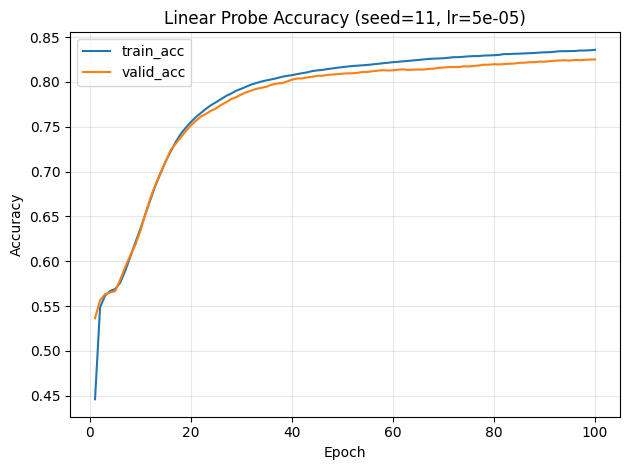

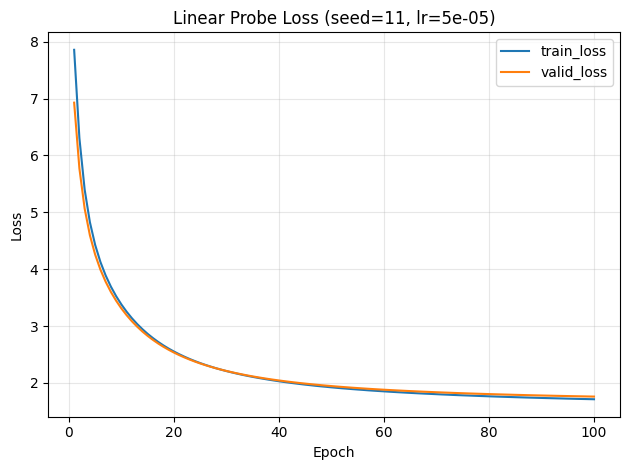

Saved best head: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results/linear_probe_best_head_seed_11.pt


predict(test): 100%|██████████| 225/225 [00:10<00:00, 21.98it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results/linear_probe_seed_11_pred.csv

Seed 22 | Staging data

====== Training Linear Probe (seed=22, lr=5e-05) ======
Epoch 01/100 | train_loss=7.8422 valid_loss=6.9276 | train_acc=0.4208 valid_acc=0.5135
Epoch 02/100 | train_loss=6.2908 valid_loss=5.7829 | train_acc=0.5401 valid_acc=0.5488
Epoch 03/100 | train_loss=5.3880 valid_loss=5.0842 | train_acc=0.5607 valid_acc=0.5583
Epoch 04/100 | train_loss=4.8145 valid_loss=4.6185 | train_acc=0.5664 valid_acc=0.5617
Epoch 05/100 | train_loss=4.4174 valid_loss=4.2802 | train_acc=0.5694 valid_acc=0.5643
Epoch 06/100 | train_loss=4.1197 valid_loss=4.0166 | train_acc=0.5763 valid_acc=0.5752
Epoch 07/100 | train_loss=3.8824 valid_loss=3.8016 | train_acc=0.5896 valid_acc=0.5891
Epoch 08/100 | train_loss=3.6854 valid_loss=3.6197 | train_acc=0.6056 valid_acc=0.6063
Epoch 09/100 | train_loss=3.5173 valid_loss=3.4631 | train_acc=0.6206 valid_acc=0.6214
Epoch 10/100 | train_loss=3

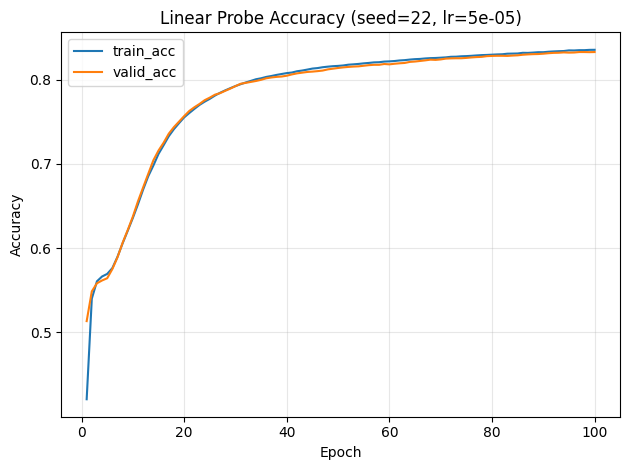

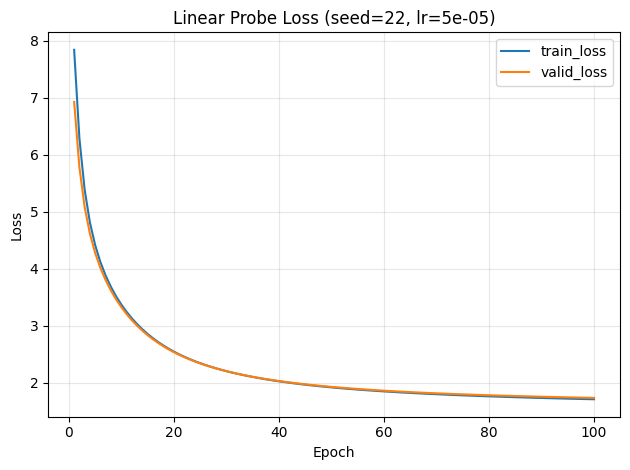

Saved best head: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results/linear_probe_best_head_seed_22.pt


predict(test): 100%|██████████| 225/225 [00:10<00:00, 21.90it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results/linear_probe_seed_22_pred.csv

Seed 33 | Staging data

====== Training Linear Probe (seed=33, lr=5e-05) ======
Epoch 01/100 | train_loss=7.8482 valid_loss=6.9208 | train_acc=0.4055 valid_acc=0.5215
Epoch 02/100 | train_loss=6.3017 valid_loss=5.7731 | train_acc=0.5458 valid_acc=0.5528
Epoch 03/100 | train_loss=5.4006 valid_loss=5.0730 | train_acc=0.5627 valid_acc=0.5585
Epoch 04/100 | train_loss=4.8271 valid_loss=4.6075 | train_acc=0.5678 valid_acc=0.5618
Epoch 05/100 | train_loss=4.4298 valid_loss=4.2711 | train_acc=0.5699 valid_acc=0.5640
Epoch 06/100 | train_loss=4.1321 valid_loss=4.0100 | train_acc=0.5730 valid_acc=0.5715
Epoch 07/100 | train_loss=3.8943 valid_loss=3.7968 | train_acc=0.5852 valid_acc=0.5879
Epoch 08/100 | train_loss=3.6976 valid_loss=3.6174 | train_acc=0.6014 valid_acc=0.6070
Epoch 09/100 | train_loss=3.5296 valid_loss=3.4632 | train_acc=0.6175 valid_acc=0.6232
Epoch 10/100 | train_loss=3

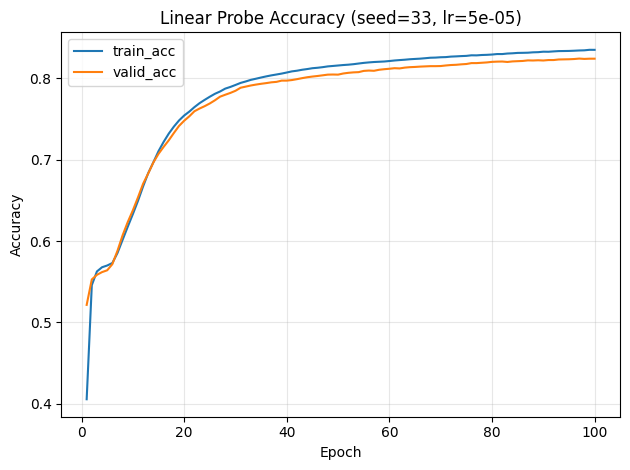

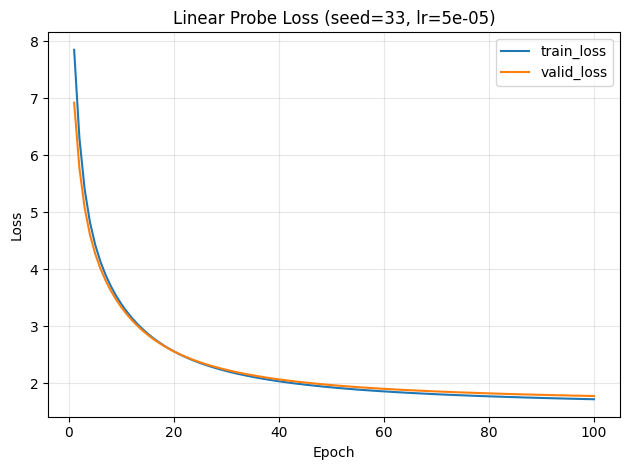

Saved best head: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results/linear_probe_best_head_seed_33.pt


predict(test): 100%|██████████| 225/225 [00:10<00:00, 21.63it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results/linear_probe_seed_33_pred.csv

Seed 44 | Staging data

====== Training Linear Probe (seed=44, lr=5e-05) ======
Epoch 01/100 | train_loss=7.8347 valid_loss=6.9093 | train_acc=0.4236 valid_acc=0.5021
Epoch 02/100 | train_loss=6.2906 valid_loss=5.7616 | train_acc=0.5293 valid_acc=0.5457
Epoch 03/100 | train_loss=5.3911 valid_loss=5.0625 | train_acc=0.5561 valid_acc=0.5600
Epoch 04/100 | train_loss=4.8193 valid_loss=4.5983 | train_acc=0.5652 valid_acc=0.5654
Epoch 05/100 | train_loss=4.4223 valid_loss=4.2623 | train_acc=0.5691 valid_acc=0.5679
Epoch 06/100 | train_loss=4.1239 valid_loss=4.0020 | train_acc=0.5740 valid_acc=0.5777
Epoch 07/100 | train_loss=3.8867 valid_loss=3.7897 | train_acc=0.5872 valid_acc=0.5949
Epoch 08/100 | train_loss=3.6898 valid_loss=3.6108 | train_acc=0.6025 valid_acc=0.6124
Epoch 09/100 | train_loss=3.5220 valid_loss=3.4569 | train_acc=0.6189 valid_acc=0.6278
Epoch 10/100 | train_loss=3

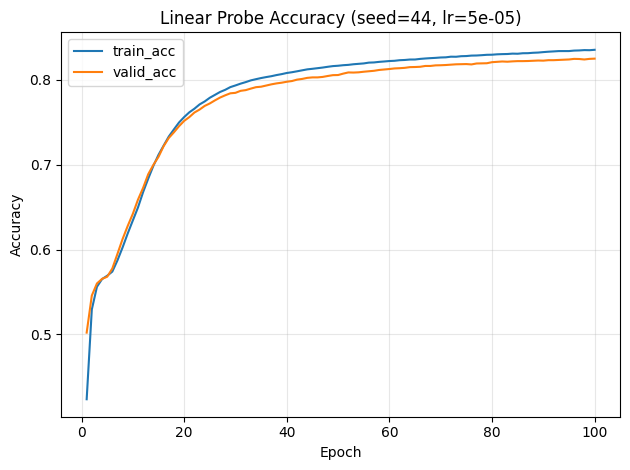

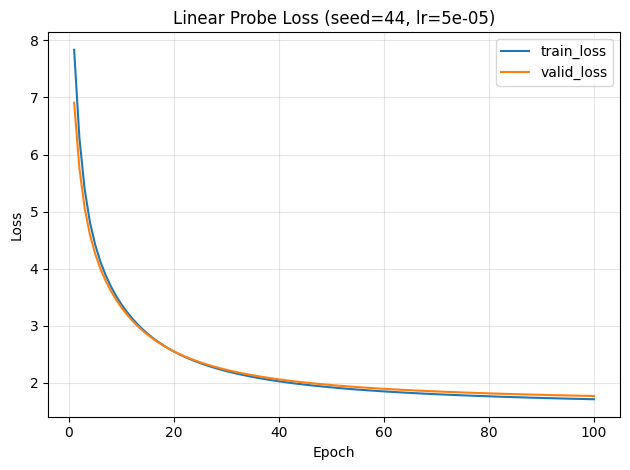

Saved best head: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results/linear_probe_best_head_seed_44.pt


predict(test): 100%|██████████| 225/225 [00:10<00:00, 21.50it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results/linear_probe_seed_44_pred.csv

Seed 55 | Staging data

====== Training Linear Probe (seed=55, lr=5e-05) ======
Epoch 01/100 | train_loss=7.8608 valid_loss=6.9296 | train_acc=0.4006 valid_acc=0.5317
Epoch 02/100 | train_loss=6.3086 valid_loss=5.7684 | train_acc=0.5397 valid_acc=0.5589
Epoch 03/100 | train_loss=5.4013 valid_loss=5.0580 | train_acc=0.5590 valid_acc=0.5661
Epoch 04/100 | train_loss=4.8246 valid_loss=4.5858 | train_acc=0.5649 valid_acc=0.5693
Epoch 05/100 | train_loss=4.4262 valid_loss=4.2454 | train_acc=0.5685 valid_acc=0.5734
Epoch 06/100 | train_loss=4.1274 valid_loss=3.9818 | train_acc=0.5751 valid_acc=0.5834
Epoch 07/100 | train_loss=3.8900 valid_loss=3.7674 | train_acc=0.5886 valid_acc=0.5961
Epoch 08/100 | train_loss=3.6935 valid_loss=3.5870 | train_acc=0.6048 valid_acc=0.6111
Epoch 09/100 | train_loss=3.5257 valid_loss=3.4321 | train_acc=0.6196 valid_acc=0.6282
Epoch 10/100 | train_loss=3

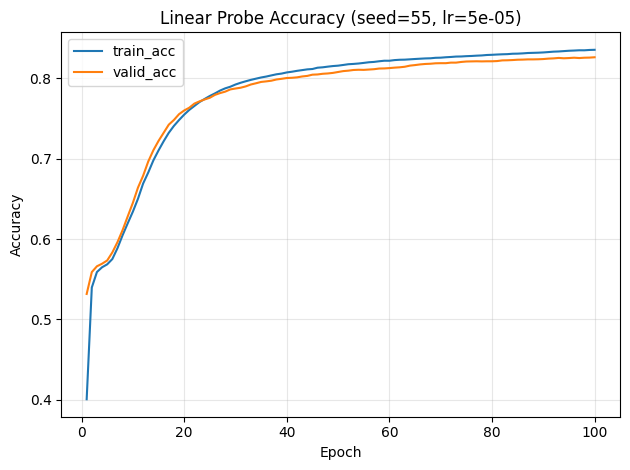

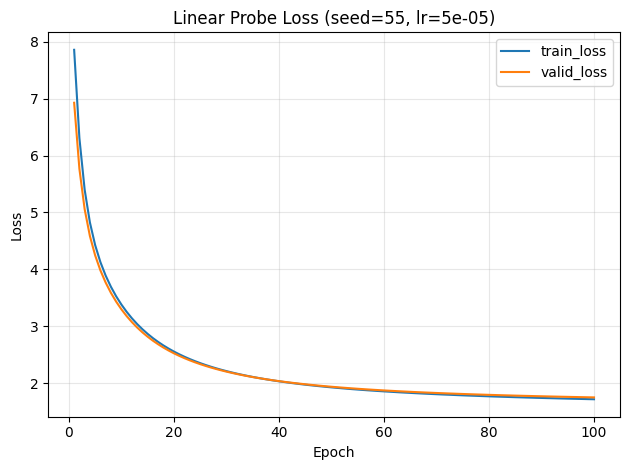

Saved best head: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results/linear_probe_best_head_seed_55.pt


predict(test): 100%|██████████| 225/225 [00:10<00:00, 20.64it/s]

Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results/linear_probe_seed_55_pred.csv

Done. Training + prediction artifacts stored for all seeds.


In [ ]:
import os
import json
import csv
import ast
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import clip

# -----------------------------
# Config
# -----------------------------
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
RESULT_DIR = DRIVE_BASE_DIR / "LinearProbe_results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_BASE_DIR = Path("/content")

SEEDS = [11, 22, 33, 44, 55]

LABEL_LIB_PATH = DRIVE_BASE_DIR / "label_library.json"

BATCH_SIZE = 16
EPOCHS = 100
LEARNING_RATE = 5e-5

single_attrs = ["category", "sub_category"]
multi_attrs  = ["color", "material", "pattern"]

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

# -----------------------------
# Utilities
# -----------------------------
def stage_split_images(seed: int, split: str) -> Path:
    """
    Copy images for a given seed & split from Drive to local /content.
    """
    src = DRIVE_BASE_DIR / f"seed_{seed}" / split / "images"
    dst = LOCAL_BASE_DIR / f"seed_{seed}_{split}_images"

    if not src.exists():
        raise FileNotFoundError(f"Missing source images: {src}")

    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)
    return dst

def parse_list_cell(x):
    s = "" if pd.isna(x) else str(x).strip()
    if s == "[]":
        return []
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(t).strip().strip("'").strip('"') for t in v]
        return [str(v).strip()]
    except Exception:
        return [t.strip() for t in s.split(",") if t.strip()]

def build_dataframe(seed: int, split: str, image_dir: Path) -> pd.DataFrame:
    """
    Build dataframe with absolute image paths. Uses image_id as key.
    """
    csv_path = DRIVE_BASE_DIR / f"seed_{seed}" / split / f"{split}.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing split CSV: {csv_path}")

    df = pd.read_csv(csv_path)
    df["path"] = df["image_id"].astype(str) + ".jpg"
    df["path"] = df["path"].apply(lambda n: str(image_dir / n))
    return df

# -----------------------------
# 1) Load label library
# -----------------------------
if not LABEL_LIB_PATH.exists():
    raise FileNotFoundError(f"label_library.json not found: {LABEL_LIB_PATH}")

with LABEL_LIB_PATH.open("r", encoding="utf-8-sig") as f:
    label_lib = json.load(f)

label2idx_single = {a: {lab: i for i, lab in enumerate(label_lib[a])} for a in single_attrs}
label2idx_multi  = {a: {lab: i for i, lab in enumerate(label_lib[a])} for a in multi_attrs}
idx2label_single = {a: {i: lab for lab, i in label2idx_single[a].items()} for a in single_attrs}
multi_keys = {a: list(label2idx_multi[a].keys()) for a in multi_attrs}

# -----------------------------
# 2) CLIP backbone (frozen)
# -----------------------------
clip_model, preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False

feat_dim = clip_model.visual.output_dim

@torch.no_grad()
def encode_images(x):
    feats = clip_model.encode_image(x.to(device, non_blocking=True))
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.float()

# -----------------------------
# 3) Dataset / Loader
# -----------------------------
class FashionSet(torch.utils.data.Dataset):
    """
    Returns:
      img_tensor, y_single(dict), y_multi(dict), image_id(str)
    """
    def __init__(self, frame: pd.DataFrame):
        self.f = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.f)

    def __getitem__(self, i):
        r = self.f.iloc[i]
        img = preprocess(Image.open(r["path"]).convert("RGB"))

        y_single = {}
        for a in single_attrs:
            y = r.get(a)
            if pd.isna(y) or str(y).strip() == "":
                y_single[a] = -1
            else:
                y_single[a] = label2idx_single[a][str(y)]

        y_multi = {}
        for a in multi_attrs:
            labs = parse_list_cell(r.get(a))
            vec = torch.zeros(len(label_lib[a]), dtype=torch.float32)
            for lab in labs:
                j = label2idx_multi[a].get(lab)
                if j is not None:
                    vec[j] = 1.0
            if len(labs) == 0 and (pd.isna(r.get(a)) or str(r.get(a)).strip() in ("", "[]")):
                vec = torch.full_like(vec, -1.0)
            y_multi[a] = vec

        return img, y_single, y_multi, str(r["image_id"])

def collate_fn(batch):
    imgs = torch.stack([b[0] for b in batch], dim=0)
    y_single = {a: torch.tensor([b[1][a] for b in batch], dtype=torch.long) for a in single_attrs}
    y_multi  = {a: torch.stack([b[2][a] for b in batch], dim=0) for a in multi_attrs}
    image_ids = [b[3] for b in batch]
    return imgs, y_single, y_multi, image_ids

def make_loader(df, shuffle):
    ds = FashionSet(df)
    return torch.utils.data.DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=2 if device == "cuda" else 0,
        pin_memory=(device == "cuda"),
        collate_fn=collate_fn
    )

# -----------------------------
# 4) Heads + Losses
# -----------------------------
def make_heads():
    return nn.ModuleDict({
        "single": nn.ModuleDict({a: nn.Linear(feat_dim, len(label_lib[a])) for a in single_attrs}),
        "multi":  nn.ModuleDict({a: nn.Linear(feat_dim, len(label_lib[a])) for a in multi_attrs}),
    }).to(device)

ce  = nn.CrossEntropyLoss(ignore_index=-1, label_smoothing=0.05)
bce = nn.BCEWithLogitsLoss(reduction="none")

def train_or_eval_epoch(heads, loader, optimizer=None):
    train_mode = optimizer is not None
    heads.train() if train_mode else heads.eval()

    total_loss = 0.0
    correct = {a: 0 for a in single_attrs}
    count = {a: 0 for a in single_attrs}

    for imgs, y_s, y_m, _ids in loader:
        feats = encode_images(imgs)
        loss = 0.0

        # single-label
        for a in single_attrs:
            logits = heads["single"][a](feats)
            y = y_s[a].to(device)
            loss = loss + ce(logits, y)

            with torch.no_grad():
                pred = logits.argmax(dim=-1)
                m = (y != -1)
                correct[a] += int((pred[m] == y[m]).sum().item())
                count[a] += int(m.sum().item())

        # multi-label
        for a in multi_attrs:
            logits = heads["multi"][a](feats)
            y = y_m[a].to(device)
            mask = (y != -1.0).float()
            l = bce(logits, torch.clamp(y, 0, 1))
            l = (l * mask).sum() / torch.clamp(mask.sum(), min=1.0)
            loss = loss + l

        if train_mode:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item())

    mean_loss = total_loss / max(1, len(loader))
    accs = {a: (correct[a] / count[a] if count[a] > 0 else np.nan) for a in single_attrs}
    mean_acc = float(np.nanmean(list(accs.values())))
    return mean_loss, mean_acc

# -----------------------------
# 5) Inference
# -----------------------------
@torch.no_grad()
def infer_single_batch(heads, feats):
    out_single, out_multi = {}, {}
    for a in single_attrs:
        logits = heads["single"][a](feats)
        out_single[a] = logits.argmax(dim=-1).cpu().numpy()
    for a in multi_attrs:
        logits = heads["multi"][a](feats)
        out_multi[a] = torch.sigmoid(logits).cpu().numpy()
    return out_single, out_multi

def probs_to_labels(attr, probs, thresh=0.5):
    idxs = [j for j, p in enumerate(probs) if p >= thresh]
    if not idxs:
        idxs = [int(np.argmax(probs))]
    return [multi_keys[attr][j] for j in idxs]

def predict_split(df, heads, thresh=0.5):
    loader = make_loader(df, shuffle=False)
    rows = []
    processed = 0

    for imgs, _ys, _ym, image_ids in tqdm(loader, desc="predict(test)"):
        feats = encode_images(imgs)
        s_out, m_out = infer_single_batch(heads, feats)
        bs = feats.shape[0]

        for i in range(bs):
            row = {"image_id": image_ids[i]}
            for a in single_attrs:
                row[a] = idx2label_single[a][int(s_out[a][i])]
            for a in multi_attrs:
                row[a] = str(probs_to_labels(a, m_out[a][i], thresh=thresh))
            rows.append(row)

        processed += bs

    return pd.DataFrame(rows)

# -----------------------------
# Run training + inference for all seeds
# -----------------------------
seed_artifacts = {}

for seed in SEEDS:
    print(f"\n===============================")
    print(f"Seed {seed} | Staging data")
    print(f"===============================")

    train_img_dir = stage_split_images(seed, "train")
    valid_img_dir = stage_split_images(seed, "valid")
    test_img_dir  = stage_split_images(seed, "test")

    train_df = build_dataframe(seed, "train", train_img_dir)
    valid_df = build_dataframe(seed, "valid", valid_img_dir)
    test_df  = build_dataframe(seed, "test",  test_img_dir)

    train_loader = make_loader(train_df, shuffle=True)
    valid_loader = make_loader(valid_df, shuffle=False)

    heads = make_heads()
    opt = optim.AdamW(heads.parameters(), lr=LEARNING_RATE, weight_decay=0.02)

    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []
    best_valid = -1.0
    best_state = None

    print(f"\n====== Training Linear Probe (seed={seed}, lr={LEARNING_RATE}) ======")
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_or_eval_epoch(heads, train_loader, optimizer=opt)
        va_loss, va_acc = train_or_eval_epoch(heads, valid_loader, optimizer=None)

        train_losses.append(tr_loss)
        valid_losses.append(va_loss)
        train_accs.append(tr_acc)
        valid_accs.append(va_acc)

        if va_acc > best_valid:
            best_valid = va_acc
            best_state = {k: v.detach().cpu() for k, v in heads.state_dict().items()}

        print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={tr_loss:.4f} valid_loss={va_loss:.4f} | train_acc={tr_acc:.4f} valid_acc={va_acc:.4f}")

    # Plot curves (show only)
    epochs_axis = list(range(1, EPOCHS + 1))

    plt.figure()
    plt.plot(epochs_axis, train_accs, label="train_acc")
    plt.plot(epochs_axis, valid_accs, label="valid_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Linear Probe Accuracy (seed={seed}, lr={LEARNING_RATE:.0e})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(epochs_axis, train_losses, label="train_loss")
    plt.plot(epochs_axis, valid_losses, label="valid_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Linear Probe Loss (seed={seed}, lr={LEARNING_RATE:.0e})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Save best head
    best_head_path = RESULT_DIR / f"linear_probe_best_head_seed_{seed}.pt"
    torch.save(
        {
            "state_dict": best_state,
            "seed": seed,
            "best_valid_acc": float(best_valid),
            "model": "ViT-B/32",
            "lr": float(LEARNING_RATE),
            "epochs": int(EPOCHS),
        },
        best_head_path
    )
    print("Saved best head:", best_head_path)

    # Load best state into a fresh heads module for inference
    best_heads = make_heads()
    best_heads.load_state_dict(best_state)
    best_heads.to(device).eval()

    # Predict on test
    test_pred_df = predict_split(test_df, best_heads, thresh=0.5)
    pred_csv_path = RESULT_DIR / f"linear_probe_seed_{seed}_pred.csv"
    test_pred_df.to_csv(pred_csv_path, index=False, encoding="utf-8")
    print("Saved predictions:", pred_csv_path)

    # Cache artifacts for evaluation cell
    seed_artifacts[seed] = {
        "best_head_path": str(best_head_path),
        "pred_csv_path": str(pred_csv_path),
        "gt_csv_path": str(DRIVE_BASE_DIR / f"seed_{seed}" / "test" / "test.csv"),
    }

print("\nDone. Training + prediction artifacts stored for all seeds.")

In [ ]:
import json
import ast
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch
import clip

# -----------------------------
# Config
# -----------------------------
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
RESULT_DIR = DRIVE_BASE_DIR / "LinearProbe_results"

SEEDS = [11, 22, 33, 44, 55]

single_attrs = ["category", "sub_category"]
multi_attrs  = ["color", "material", "pattern"]

device = "cuda" if torch.cuda.is_available() else "cpu"

# Use frozen CLIP text encoder for semantic similarity
clip_model, _ = clip.load("ViT-B/32", device=device)
clip_model.eval()

# -----------------------------
# Helpers
# -----------------------------
def is_missing(x):
    if pd.isna(x):
        return True
    if isinstance(x, str) and x.strip() == "":
        return True
    return False

def parse_list_cell(x):
    s = "" if pd.isna(x) else str(x).strip()
    if s == "[]":
        return []
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(t).strip().strip("'").strip('"') for t in v]
        return [str(v).strip()]
    except Exception:
        return [t.strip() for t in s.split(",") if t.strip()]

def relaxed_match(a, b):
    return 1.0 if (set(a) & set(b)) else 0.0

@torch.no_grad()
def embed_text_batch(texts):
    toks = clip.tokenize(texts).to(device)
    feats = clip_model.encode_text(toks)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats

_embed_cache = {}
def get_text_embed(label):
    key = str(label).strip().lower()
    if key == "":
        return None
    if key not in _embed_cache:
        _embed_cache[key] = embed_text_batch([key])
    return _embed_cache[key]

def semantic_sim_single(gt_label, pred_label):
    a = get_text_embed(gt_label)
    b = get_text_embed(pred_label)
    if a is None or b is None:
        return np.nan
    return float((a @ b.T).item())

def semantic_sim_multilabel(gt_labels, pred_labels):
    gt = [g for g in gt_labels if str(g).strip()]
    pr = [p for p in pred_labels if str(p).strip()]
    if len(gt) == 0:
        return np.nan
    if len(pr) == 0:
        return 0.0
    gt_feats = torch.cat([get_text_embed(g) for g in gt if get_text_embed(g) is not None], dim=0)
    pr_feats = torch.cat([get_text_embed(p) for p in pr if get_text_embed(p) is not None], dim=0)
    if gt_feats.numel() == 0:
        return np.nan
    if pr_feats.numel() == 0:
        return 0.0
    sims = gt_feats @ pr_feats.T
    return float(sims.max(dim=1).values.mean().item())

def evaluate_one_seed(gt_csv: Path, pred_csv: Path):
    gt = pd.read_csv(gt_csv)
    pred = pd.read_csv(pred_csv)

    needed = ["image_id"] + single_attrs + multi_attrs
    for c in needed:
        if c not in gt.columns:
            raise ValueError(f"GT missing column: {c}")
        if c not in pred.columns:
            raise ValueError(f"PRED missing column: {c}")

    df = gt.merge(pred, on="image_id", suffixes=("_gt", "_pred"), how="inner")

    report = {"single": {}, "multi": {}}

    # Single-label
    for attr in single_attrs:
        gcol, pcol = f"{attr}_gt", f"{attr}_pred"
        mask = ~df[gcol].apply(is_missing)
        if mask.sum() == 0:
            continue

        y_true = df.loc[mask, gcol].astype(str).tolist()
        y_pred = df.loc[mask, pcol].astype(str).tolist()

        acc = accuracy_score(y_true, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )

        sems = [semantic_sim_single(t, p) for t, p in zip(y_true, y_pred)]
        sems = [s for s in sems if not np.isnan(s)]
        sem_mean = float(np.mean(sems)) if sems else float("nan")

        report["single"][attr] = {
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "semantic_similarity_clip": float(sem_mean),
        }

    # Multi-label
    for attr in multi_attrs:
        gcol, pcol = f"{attr}_gt", f"{attr}_pred"
        gt_lists = df[gcol].apply(parse_list_cell)
        pr_lists = df[pcol].apply(parse_list_cell)

        mask = gt_lists.apply(lambda x: len(x) > 0)
        if mask.sum() == 0:
            continue

        gtv = gt_lists[mask].tolist()
        prv = pr_lists[mask].tolist()

        relaxed = float(np.mean([relaxed_match(g, p) for g, p in zip(gtv, prv)]))
        sems = [semantic_sim_multilabel(g, p) for g, p in zip(gtv, prv)]
        sems = [s for s in sems if not np.isnan(s)]
        sem = float(np.mean(sems)) if sems else float("nan")

        report["multi"][attr] = {
            "relaxed_match_acc": relaxed,
            "semantic_similarity_clip": sem,
        }

    return report

def mean_std_str(xs):
    xs = [x for x in xs if x is not None and not (isinstance(x, float) and np.isnan(x))]
    if len(xs) == 0:
        return "-"
    mu = float(np.mean(xs))
    sd = float(np.std(xs, ddof=1)) if len(xs) > 1 else 0.0
    return f"{mu:.3f} ± {sd:.3f}"

# -----------------------------
# Evaluate all seeds + save per-seed JSON
# -----------------------------
all_reports = {}
per_seed_overall_single = []

for seed in SEEDS:
    gt_csv = DRIVE_BASE_DIR / f"seed_{seed}" / "test" / "test.csv"
    pred_csv = RESULT_DIR / f"linear_probe_seed_{seed}_pred.csv"

    rep = evaluate_one_seed(gt_csv, pred_csv)
    all_reports[seed] = rep

    # Print per-seed results (detailed)
    print(f"\n===== Seed {seed} Results (Linear Probe) =====")
    for attr in single_attrs:
        if attr in rep["single"]:
            m = rep["single"][attr]
            print(f"{attr}: acc={m['accuracy']:.4f}, prec={m['precision']:.4f}, rec={m['recall']:.4f}, f1={m['f1']:.4f}, sem_sim={m['semantic_similarity_clip']:.4f}")
    for attr in multi_attrs:
        if attr in rep["multi"]:
            m = rep["multi"][attr]
            print(f"{attr}: relaxed={m['relaxed_match_acc']:.4f}, sem_sim={m['semantic_similarity_clip']:.4f}")

    # Overall single-label acc = mean(category, sub_category)
    single_accs = []
    for a in single_attrs:
        if a in rep["single"]:
            single_accs.append(rep["single"][a]["accuracy"])
    overall = float(np.mean(single_accs)) if single_accs else float("nan")
    per_seed_overall_single.append(overall)
    print(f"Overall single-label acc (mean category/sub_category): {overall:.4f}")

    # Save per-seed eval JSON
    seed_eval_path = RESULT_DIR / f"linear_probe_seed_{seed}_eval.json"
    with seed_eval_path.open("w", encoding="utf-8") as f:
        json.dump(rep, f, ensure_ascii=False, indent=2)
    print(f"Saved seed eval: {seed_eval_path}")

# -----------------------------
# Final mean ± std summary table (like your baseline table)
# -----------------------------
rows = []

# Single-label summary rows
for attr in single_attrs:
    vals_acc, vals_prec, vals_rec, vals_f1, vals_sem = [], [], [], [], []
    for seed in SEEDS:
        m = all_reports[seed]["single"].get(attr, {})
        vals_acc.append(m.get("accuracy", np.nan))
        vals_prec.append(m.get("precision", np.nan))
        vals_rec.append(m.get("recall", np.nan))
        vals_f1.append(m.get("f1", np.nan))
        vals_sem.append(m.get("semantic_similarity_clip", np.nan))

    rows.append({
        "Method": "LinearProbe",
        "Attribute Type": "Single-Label",
        "Attributes": "Category" if attr == "category" else "Subcategory",
        "Accuracy": mean_std_str(vals_acc),
        "Precision": mean_std_str(vals_prec),
        "Recall": mean_std_str(vals_rec),
        "F1": mean_std_str(vals_f1),
        "Relaxed Match": "-",
        "Semantic Similarity": mean_std_str(vals_sem),
    })

# Multi-label summary rows
for attr in multi_attrs:
    vals_relaxed, vals_sem = [], []
    for seed in SEEDS:
        m = all_reports[seed]["multi"].get(attr, {})
        vals_relaxed.append(m.get("relaxed_match_acc", np.nan))
        vals_sem.append(m.get("semantic_similarity_clip", np.nan))

    rows.append({
        "Method": "LinearProbe",
        "Attribute Type": "Multi-Label",
        "Attributes": attr.capitalize(),
        "Accuracy": "-",
        "Precision": "-",
        "Recall": "-",
        "F1": "-",
        "Relaxed Match": mean_std_str(vals_relaxed),
        "Semantic Similarity": mean_std_str(vals_sem),
    })

df_summary = pd.DataFrame(rows, columns=[
    "Method", "Attribute Type", "Attributes",
    "Accuracy", "Precision", "Recall", "F1",
    "Relaxed Match", "Semantic Similarity"
])

print("\n===== Linear Probe Summary (mean ± std over 5 seeds) =====")
print(df_summary.to_string(index=False))


===== Seed 11 Results (Linear Probe) =====
category: acc=0.9350, prec=0.9044, rec=0.8895, f1=0.8964, sem_sim=0.9887
sub_category: acc=0.7241, prec=0.3999, rec=0.3397, f1=0.3511, sem_sim=0.9488
color: relaxed=0.4196, sem_sim=0.8609
material: relaxed=0.3776, sem_sim=0.8695
pattern: relaxed=0.2537, sem_sim=0.8461
Overall single-label acc (mean category/sub_category): 0.8295
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results/linear_probe_seed_11_eval.json

===== Seed 22 Results (Linear Probe) =====
category: acc=0.9297, prec=0.9075, rec=0.8806, f1=0.8918, sem_sim=0.9878
sub_category: acc=0.7121, prec=0.3838, rec=0.3236, f1=0.3302, sem_sim=0.9459
color: relaxed=0.4176, sem_sim=0.8626
material: relaxed=0.3801, sem_sim=0.8694
pattern: relaxed=0.2459, sem_sim=0.8483
Overall single-label acc (mean category/sub_category): 0.8209
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results/linear_probe_seed_22_eval.json

===== Seed 33 Results (Linear Pro

### Prompt Tuning

device: cuda
gpu: NVIDIA A100-SXM4-40GB

Seed 11 | Prompt Tuning
Epoch 01/100 | train_loss=67.2375 valid_loss=67.2881 | train_acc=0.4496 valid_acc=0.4508
Epoch 02/100 | train_loss=67.0786 valid_loss=67.1361 | train_acc=0.4584 valid_acc=0.4565
Epoch 03/100 | train_loss=66.9267 valid_loss=66.9779 | train_acc=0.4669 valid_acc=0.4625
Epoch 04/100 | train_loss=66.7867 valid_loss=66.8459 | train_acc=0.4749 valid_acc=0.4689
Epoch 05/100 | train_loss=66.6578 valid_loss=66.7297 | train_acc=0.4819 valid_acc=0.4751
Epoch 06/100 | train_loss=66.5399 valid_loss=66.5996 | train_acc=0.4884 valid_acc=0.4817
Epoch 07/100 | train_loss=66.4314 valid_loss=66.5010 | train_acc=0.4943 valid_acc=0.4865
Epoch 08/100 | train_loss=66.3340 valid_loss=66.4128 | train_acc=0.4995 valid_acc=0.4926
Epoch 09/100 | train_loss=66.2467 valid_loss=66.3252 | train_acc=0.5043 valid_acc=0.4954
Epoch 10/100 | train_loss=66.1708 valid_loss=66.2575 | train_acc=0.5087 valid_acc=0.4990
Epoch 11/100 | train_loss=66.1040 valid_loss=

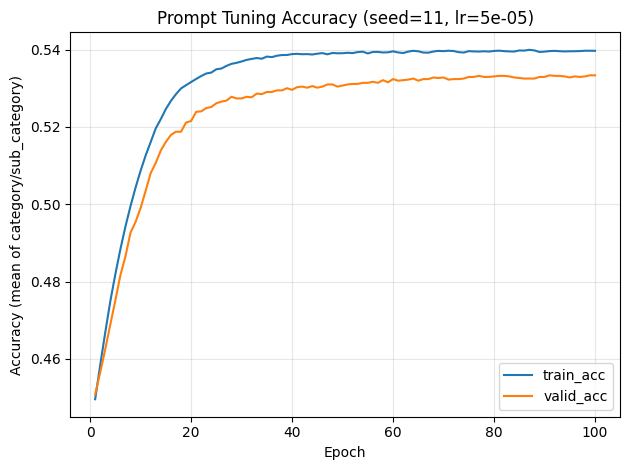

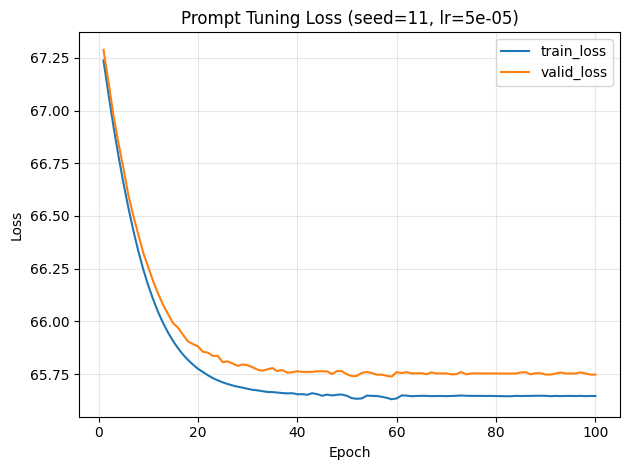

Saved best prompt weights: /content/drive/MyDrive/Thesis_Data/0111/PromptTuning_results/prompt_weights_best_seed_11.pt


predict(test): 100%|██████████| 225/225 [00:07<00:00, 29.08it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/PromptTuning_results/prompt_tuning_seed_11_pred.csv
    image_id   category sub_category  \
0  207695365       bags      satchel   
1  191191910      shoes        heels   
2  203633599      shoes        heels   
3  149586997  outerwear       jacket   
4  188192512       tops     tank top   

                                               color  \
0  ['two-tone leather', 'mulberry luxe satin', 'm...   
1  ['neon patent details', 'patent leather', 'met...   
2  ['neon patent details', 'ostrich feather', 'sa...   
3  ['denim stonewash', 'light denim blue', 'denim...   
4  ['colourful all-over print', 'psychedelic tie ...   

                                            material  \
0  ['patent-leather pale-mint leather', 'vegetari...   
1  ['patent-leather pale-mint leather', 'green le...   
2  ['signature christian louboutin red leather', ...   
3  ['distressed denim', 'denim cotton', 'denim co...   
4  ['stretch-knit viscose blend

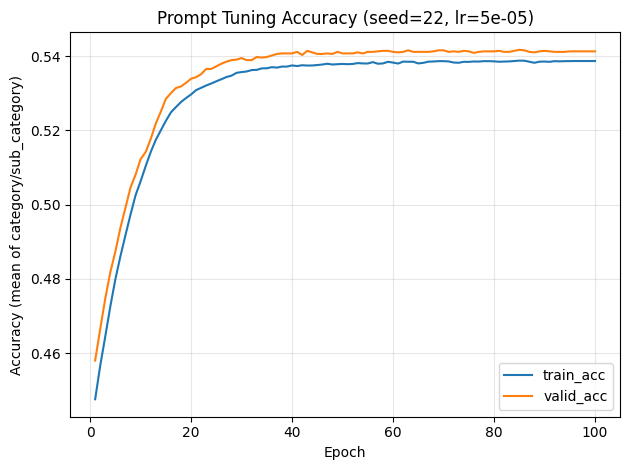

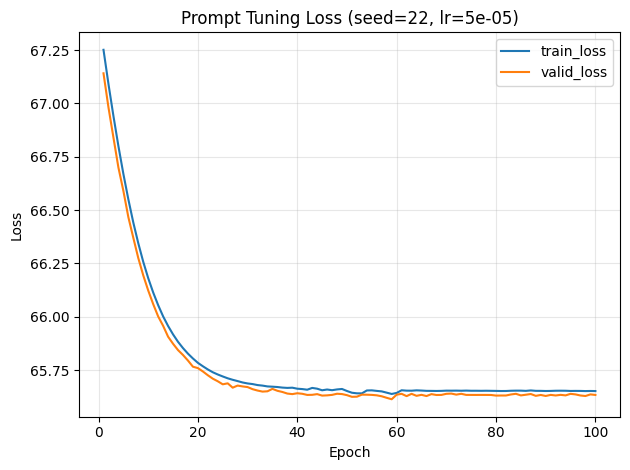

Saved best prompt weights: /content/drive/MyDrive/Thesis_Data/0111/PromptTuning_results/prompt_weights_best_seed_22.pt


predict(test): 100%|██████████| 225/225 [00:06<00:00, 32.68it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/PromptTuning_results/prompt_tuning_seed_22_pred.csv
    image_id     category  sub_category  \
0  116071366  accessories      earrings   
1  184695024  accessories        gloves   
2  150569383    outerwear   trench coat   
3  182483779        shoes      sneakers   
4  210661922        shoes  flat sandals   

                                               color  \
0  ['yellow-goldtone', 'leopard-print gold', 'leo...   
1        ['fair isle', 'fairisle', 'white or black']   
2     ['shearling', 'peacoat', 'light heather grey']   
3  ['vibrant outsoles', 'black multicolor', 'neon...   
4  ['pinko palmarola white', 'eyelet white', 'flo...   

                                            material  \
0  ['metallic core-glass bugle beads', '18k rose ...   
1  ['soft touch knit', 'hand-knit', 'alpaca-blend...   
2  ['lyocell chambray', 'wool-gabardine', 'cashme...   
3  ['velcro straps', 'neoprene-bonded wool', 'out...   
4  ['floral-p

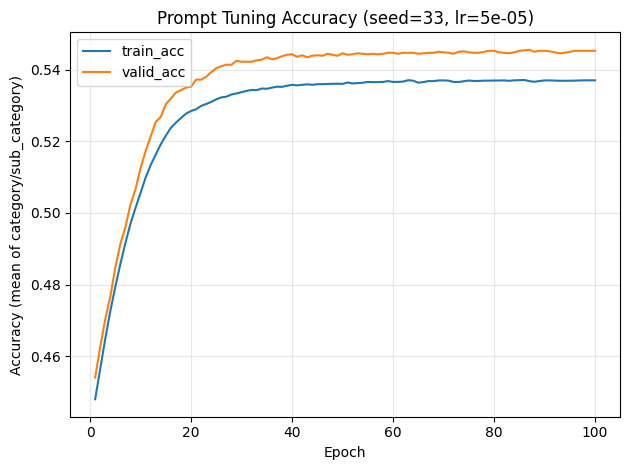

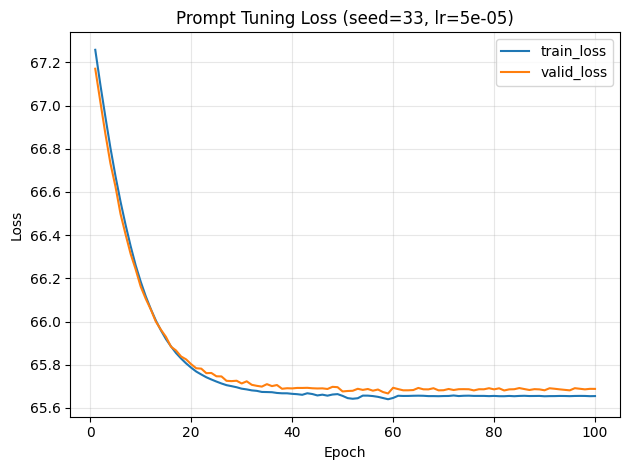

Saved best prompt weights: /content/drive/MyDrive/Thesis_Data/0111/PromptTuning_results/prompt_weights_best_seed_33.pt


predict(test): 100%|██████████| 225/225 [00:07<00:00, 31.05it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/PromptTuning_results/prompt_tuning_seed_33_pred.csv
    image_id  category         sub_category  \
0  201663921  all-body              sweater   
1  203886624      tops               blouse   
2  119048544      tops         male sweater   
3  164430783   bottoms  over-the-knee boots   
4  203503864      bags                purse   

                                               color  \
0  ['dark grey heather', 'light heather grey', 'c...   
1  ['floral black', 'floral-appliqué', 'dark flor...   
2   ['pinko black', 'deep neckline', 'patent black']   
3   ['vegan leather', 'leatherette', 'leather-look']   
4  ['snake-print-leather', 'snake embossed leathe...   

                                            material  \
0  ['light weight knit fabric', 'merino-blend kni...   
1  ['floral pattern lace', 'sheer floral-lace', '...   
2  ['leather-trim double-knit stretch-jersey', 'l...   
3  ['cotton calf leather polyester spandex el

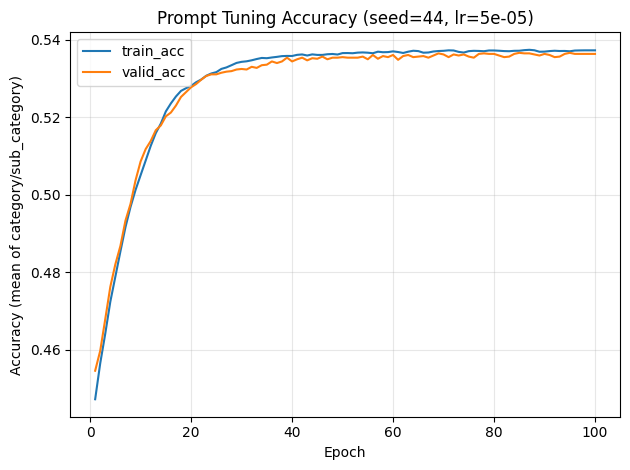

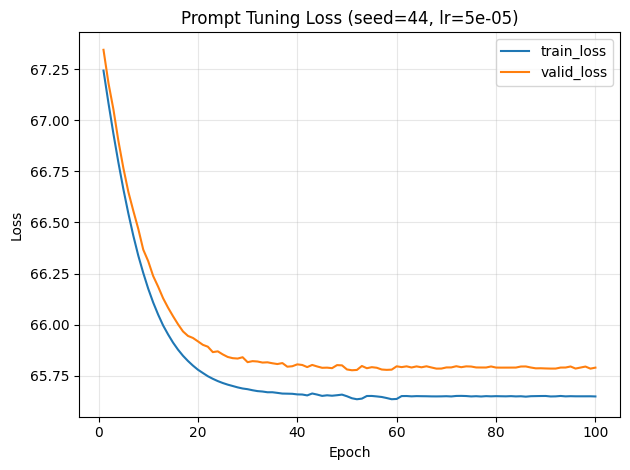

Saved best prompt weights: /content/drive/MyDrive/Thesis_Data/0111/PromptTuning_results/prompt_weights_best_seed_44.pt


predict(test): 100%|██████████| 225/225 [00:07<00:00, 31.85it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/PromptTuning_results/prompt_tuning_seed_44_pred.csv
    image_id   category  sub_category  \
0  165417203      shoes  flat sandals   
1  208305532       bags    travel bag   
2  183707802  outerwear  male sweater   
3  186956444  jewellery      earrings   
4   83772258  outerwear        romper   

                                               color  \
0  ['raffia-embellished', 'neon patent details', ...   
1  ['palm tree print', 'tropical print', 'palm le...   
2          ['honeycomb-knit', 'soft knit', 'woolen']   
3  ['yellow-goldtone', 'mirrored gold', 'antique ...   
4  ['olive-khaki', 'dark olive green', 'olive-gre...   

                                            material  \
0  ['leather-covered thick heel', 'elasticized sl...   
1  ['floral-print leather', 'tropical print', 'pa...   
2  ['french terry knit', 'dipped knit jumper', 'k...   
3               ['enamelled', 'vermeil', '14k gold']   
4  ['rayon-linen jersey',

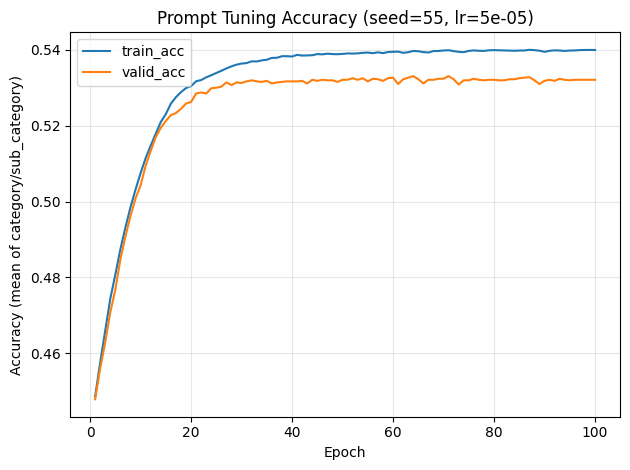

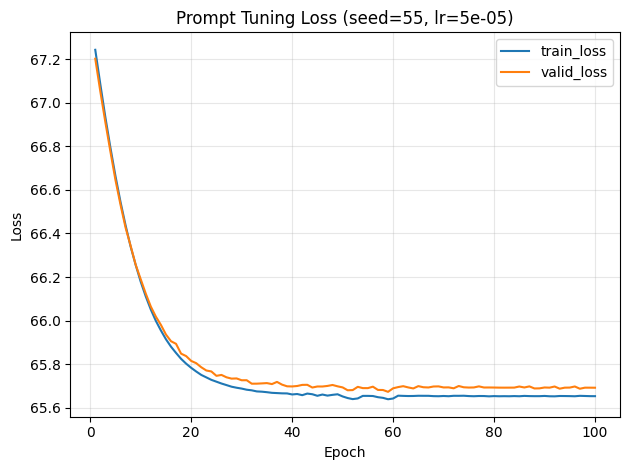

Saved best prompt weights: /content/drive/MyDrive/Thesis_Data/0111/PromptTuning_results/prompt_weights_best_seed_55.pt


predict(test): 100%|██████████| 225/225 [00:06<00:00, 32.61it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/PromptTuning_results/prompt_tuning_seed_55_pred.csv
    image_id   category  sub_category  \
0   68674292       tops  male sweater   
1  100764917  outerwear   trench coat   
2  205171420       tops        blouse   
3  179688047       tops      sneakers   
4  174221843       tops      tank top   

                                               color  \
0  ['breton stripes', 'breton-striped', 'sporty s...   
1            ['peacoat', 'pinko black', 'shearling']   
2  ['deep neckline', 'rose-beige', 'blush champag...   
3  ['japanese floral', 'floral cherry blossom', '...   
4  ['combed cotton jersey', 'yam dyed striped', '...   

                                            material  \
0  ['dipped knit jumper', 'soft jersey knit', 'fr...   
1  ['wool-gabardine', 'shearling-lined', 'toscana...   
2  ['stretch silk-blend charmeuse', 'stretch silk...   
3  ['50 cotton and 50 polyester', 'japanese cotto...   
4  ['stretch ribbed-jerse

In [ ]:
import ast
import json
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import clip


# -----------------------------
# Config
# -----------------------------
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
RESULT_DIR = DRIVE_BASE_DIR / "PromptTuning_results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_BASE_DIR = Path("/content")
SEEDS = [11, 22, 33, 44, 55]

LABEL_LIB_PATH = DRIVE_BASE_DIR / "label_library.json"

BATCH_SIZE = 16
EPOCHS = 100
LEARNING_RATE = 5e-5

PROMPTS = {
    "category":     ["a photo of a {label} item", "a fashion photo of {label}"],
    "sub_category": ["a {label}", "a {label} garment"],
    "color":        ["{label} color", "a {label} colored item"],
    "material":     ["made of {label}", "a {label} material garment"],
    "pattern":      ["{label} pattern", "a {label} print"],
}

single_attrs = ["category", "sub_category"]
multi_attrs  = ["color", "material", "pattern"]

TOPK_MULTI = {"color": 3, "material": 3, "pattern": 3}  # you can set pattern=2 if you prefer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True


# -----------------------------
# Helpers
# -----------------------------
def stage_split_images(seed: int, split: str) -> Path:
    """
    Copy images for a given seed & split from Drive to local /content for faster I/O.
    """
    src = DRIVE_BASE_DIR / f"seed_{seed}" / split / "images"
    dst = LOCAL_BASE_DIR / f"seed_{seed}_{split}_images"

    if not src.exists():
        raise FileNotFoundError(f"Missing source images: {src}")

    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)
    return dst

def parse_list_cell(x):
    s = "" if pd.isna(x) else str(x).strip()
    if s == "[]":
        return []
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(t).strip().strip("'").strip('"') for t in v]
        return [str(v).strip()]
    except Exception:
        return [t.strip() for t in s.split(",") if t.strip()]

def build_dataframe(seed: int, split: str, image_dir: Path) -> pd.DataFrame:
    """
    Build dataframe with absolute image paths using image_id as key.
    """
    csv_path = DRIVE_BASE_DIR / f"seed_{seed}" / split / f"{split}.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing split CSV: {csv_path}")

    df = pd.read_csv(csv_path)
    df["path"] = df["image_id"].astype(str) + ".jpg"
    df["path"] = df["path"].apply(lambda n: str(image_dir / n))
    return df


# -----------------------------
# Load label library
# -----------------------------
if not LABEL_LIB_PATH.exists():
    raise FileNotFoundError(f"label_library.json not found: {LABEL_LIB_PATH}")

with LABEL_LIB_PATH.open("r", encoding="utf-8-sig") as f:
    label_lib = json.load(f)

label2idx_single = {a: {lab: i for i, lab in enumerate(label_lib[a])} for a in single_attrs}
label2idx_multi  = {a: {lab: i for i, lab in enumerate(label_lib[a])} for a in multi_attrs}
idx2label_single = {a: {i: lab for lab, i in label2idx_single[a].items()} for a in single_attrs}
multi_keys = {a: list(label2idx_multi[a].keys()) for a in multi_attrs}


# -----------------------------
# CLIP backbone (frozen)
# -----------------------------
model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()
for p in model.parameters():
    p.requires_grad = False

# Use CLIP temperature scale
logit_scale = model.logit_scale.exp().detach().to(device)

@torch.no_grad()
def encode_images(x):
    feats = model.encode_image(x.to(device, non_blocking=True))
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats

@torch.no_grad()
def encode_texts(texts):
    toks = clip.tokenize(texts, truncate=True).to(device)
    tf = model.encode_text(toks)
    tf = tf / tf.norm(dim=-1, keepdim=True)
    return tf


# -----------------------------
# Build text features once (shared across seeds)
# text_feats[attr][t] = [C, d]
# -----------------------------
text_feats = {}
for attr in single_attrs + multi_attrs:
    labels = label_lib[attr]
    feats_per_template = []
    for templ in PROMPTS[attr]:
        texts = [templ.format(label=lab) for lab in labels]
        tf = encode_texts(texts)  # [C, d]
        feats_per_template.append(tf)
    text_feats[attr] = feats_per_template


# -----------------------------
# Dataset / Loader
# -----------------------------
class FashionSet(torch.utils.data.Dataset):
    """
    Returns:
      img_tensor, y_single(dict->int), y_multi(dict->tensor), image_id(str)
    """
    def __init__(self, frame: pd.DataFrame):
        self.f = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.f)

    def __getitem__(self, i):
        r = self.f.iloc[i]
        img = preprocess(Image.open(r["path"]).convert("RGB"))

        y_s = {}
        for a in single_attrs:
            y = r.get(a)
            if pd.isna(y) or str(y).strip() == "":
                y_s[a] = -1
            else:
                y_s[a] = label2idx_single[a][str(y)]

        y_m = {}
        for a in multi_attrs:
            labs = parse_list_cell(r.get(a))
            vec = torch.zeros(len(label_lib[a]), dtype=torch.float32)
            for lab in labs:
                j = label2idx_multi[a].get(lab)
                if j is not None:
                    vec[j] = 1.0
            if len(labs) == 0 and (pd.isna(r.get(a)) or str(r.get(a)).strip() in ("", "[]")):
                vec = torch.full_like(vec, -1.0)
            y_m[a] = vec

        return img, y_s, y_m, str(r["image_id"])

def collate_fn(batch):
    imgs = torch.stack([b[0] for b in batch], dim=0)
    y_single = {a: torch.tensor([b[1][a] for b in batch], dtype=torch.long) for a in single_attrs}
    y_multi  = {a: torch.stack([b[2][a] for b in batch], dim=0) for a in multi_attrs}
    image_ids = [b[3] for b in batch]
    return imgs, y_single, y_multi, image_ids

def make_loader(df, shuffle):
    ds = FashionSet(df)
    return torch.utils.data.DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=2 if device == "cuda" else 0,
        pin_memory=(device == "cuda"),
        collate_fn=collate_fn
    )


# -----------------------------
# Learnable template weights (per attr)
# -----------------------------
class PromptWeights(nn.Module):
    """
    One learnable weight per template for each attribute.
    Softmax over templates forms convex weights.
    """
    def __init__(self, prompts_dict, attrs):
        super().__init__()
        self.ws = nn.ParameterDict({
            a: nn.Parameter(torch.zeros(len(prompts_dict[a]), dtype=torch.float32))
            for a in attrs
        })

    def forward(self, attr):
        return torch.softmax(self.ws[attr], dim=0)


# -----------------------------
# Losses
# -----------------------------
ce  = nn.CrossEntropyLoss(ignore_index=-1, label_smoothing=0.05)
bce = nn.BCEWithLogitsLoss(reduction="none")


# -----------------------------
# Forward helper
# -----------------------------
def logits_from_prompts(prompt_weights: PromptWeights, img_feats: torch.Tensor, attr: str) -> torch.Tensor:
    """
    Combine template-specific text features with learned weights.
    Returns logits [B, C] for that attribute.
    """
    ws = prompt_weights(attr)  # [T]
    logits_sum = 0.0
    for t_idx, tf in enumerate(text_feats[attr]):  # tf: [C, d]
        logits_t = logit_scale * (img_feats @ tf.T)  # [B, C]
        logits_sum = logits_sum + ws[t_idx] * logits_t
    return logits_sum


def train_or_eval_epoch(prompt_weights: PromptWeights, loader, optimizer=None):
    train_mode = optimizer is not None
    prompt_weights.train() if train_mode else prompt_weights.eval()

    total_loss = 0.0
    correct = {a: 0 for a in single_attrs}
    count   = {a: 0 for a in single_attrs}

    for imgs, y_s, y_m, _ids in loader:
        feats = encode_images(imgs)
        loss = 0.0

        # single-label
        for a in single_attrs:
            logits = logits_from_prompts(prompt_weights, feats, a)
            y = y_s[a].to(device)
            loss = loss + ce(logits, y)

            with torch.no_grad():
                m = (y != -1)
                pred = logits.argmax(dim=-1)
                correct[a] += int((pred[m] == y[m]).sum().item())
                count[a] += int(m.sum().item())

        # multi-label
        for a in multi_attrs:
            logits = logits_from_prompts(prompt_weights, feats, a)
            y = y_m[a].to(device)
            mask = (y != -1.0).float()
            l = bce(logits, torch.clamp(y, 0, 1))
            l = (l * mask).sum() / torch.clamp(mask.sum(), min=1.0)
            loss = loss + l

        if train_mode:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item())

    mean_loss = total_loss / max(1, len(loader))
    accs = {a: (correct[a] / count[a] if count[a] > 0 else np.nan) for a in single_attrs}
    mean_acc = float(np.nanmean(list(accs.values())))
    return mean_loss, mean_acc


# -----------------------------
# Prediction on test
# - single: top-1
# - multi : top-k by logits
# -----------------------------
@torch.no_grad()
def predict_test(prompt_weights: PromptWeights, test_df: pd.DataFrame):
    loader = make_loader(test_df, shuffle=False)
    rows = []

    for imgs, _ys, _ym, image_ids in tqdm(loader, desc="predict(test)"):
        feats = encode_images(imgs)

        # single-label
        cat_logits = logits_from_prompts(prompt_weights, feats, "category")
        sub_logits = logits_from_prompts(prompt_weights, feats, "sub_category")
        cat_top1 = cat_logits.argmax(dim=1).cpu().tolist()
        sub_top1 = sub_logits.argmax(dim=1).cpu().tolist()

        # multi-label top-k
        topk_out = {}
        for a in multi_attrs:
            logits = logits_from_prompts(prompt_weights, feats, a)
            k = min(TOPK_MULTI[a], logits.shape[1])
            _, idx = torch.topk(logits, k=k, dim=1)
            labels = label_lib[a]
            topk_out[a] = [[labels[j] for j in row.cpu().tolist()] for row in idx]

        for i in range(len(image_ids)):
            r = {"image_id": image_ids[i]}
            r["category"] = label_lib["category"][cat_top1[i]]
            r["sub_category"] = label_lib["sub_category"][sub_top1[i]]
            for a in multi_attrs:
                r[a] = str(topk_out[a][i])
            rows.append(r)

    return pd.DataFrame(rows)


# -----------------------------
# Run all seeds: training + save best weights + predict test
# -----------------------------
seed_artifacts = {}

for seed in SEEDS:
    print(f"\n===============================")
    print(f"Seed {seed} | Prompt Tuning")
    print(f"===============================")

    # Stage images
    train_img_dir = stage_split_images(seed, "train")
    valid_img_dir = stage_split_images(seed, "valid")
    test_img_dir  = stage_split_images(seed, "test")

    # Dataframes
    train_df = build_dataframe(seed, "train", train_img_dir)
    valid_df = build_dataframe(seed, "valid", valid_img_dir)
    test_df  = build_dataframe(seed, "test",  test_img_dir)

    # Loaders
    train_loader = make_loader(train_df, shuffle=True)
    valid_loader = make_loader(valid_df, shuffle=False)

    # Prompt weights model (trainable params only)
    pw = PromptWeights(PROMPTS, single_attrs + multi_attrs).to(device)
    opt = optim.AdamW(pw.parameters(), lr=LEARNING_RATE, weight_decay=0.02)

    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []
    best_valid = -1.0
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_or_eval_epoch(pw, train_loader, optimizer=opt)
        va_loss, va_acc = train_or_eval_epoch(pw, valid_loader, optimizer=None)

        train_losses.append(tr_loss)
        valid_losses.append(va_loss)
        train_accs.append(tr_acc)
        valid_accs.append(va_acc)

        if va_acc > best_valid:
            best_valid = va_acc
            best_state = {k: v.detach().cpu() for k, v in pw.state_dict().items()}

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={tr_loss:.4f} valid_loss={va_loss:.4f} | "
            f"train_acc={tr_acc:.4f} valid_acc={va_acc:.4f}"
        )

    # Plots (show only)
    xs = list(range(1, EPOCHS + 1))

    plt.figure()
    plt.plot(xs, train_accs, label="train_acc")
    plt.plot(xs, valid_accs, label="valid_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (mean of category/sub_category)")
    plt.title(f"Prompt Tuning Accuracy (seed={seed}, lr={LEARNING_RATE:.0e})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(xs, train_losses, label="train_loss")
    plt.plot(xs, valid_losses, label="valid_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Prompt Tuning Loss (seed={seed}, lr={LEARNING_RATE:.0e})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Save best weights
    best_w_path = RESULT_DIR / f"prompt_weights_best_seed_{seed}.pt"
    torch.save(
        {
            "state_dict": best_state,
            "seed": seed,
            "best_valid_acc": float(best_valid),
            "model": "ViT-B/32",
            "lr": float(LEARNING_RATE),
            "epochs": int(EPOCHS),
            "topk_multi": TOPK_MULTI,
        },
        best_w_path
    )
    print("Saved best prompt weights:", best_w_path)

    # Predict on test using best weights
    pw_best = PromptWeights(PROMPTS, single_attrs + multi_attrs).to(device)
    pw_best.load_state_dict(best_state)
    pw_best.eval()

    pred_df = predict_test(pw_best, test_df)
    pred_csv = RESULT_DIR / f"prompt_tuning_seed_{seed}_pred.csv"
    pred_df.to_csv(pred_csv, index=False, encoding="utf-8")
    print("Saved predictions:", pred_csv)
    print(pred_df.head())

    # Cache paths for evaluation cell
    seed_artifacts[seed] = {
        "best_weights_path": str(best_w_path),
        "pred_csv_path": str(pred_csv),
        "gt_csv_path": str(DRIVE_BASE_DIR / f"seed_{seed}" / "test" / "test.csv"),
    }

print("\nDone. Prompt tuning training + predictions completed for all seeds.")

In [ ]:
import json
import ast
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch
import clip


# -----------------------------
# Config
# -----------------------------
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
RESULT_DIR = DRIVE_BASE_DIR / "PromptTuning_results"

SEEDS = [11, 22, 33, 44, 55]

single_attrs = ["category", "sub_category"]
multi_attrs  = ["color", "material", "pattern"]

device = "cuda" if torch.cuda.is_available() else "cpu"

# CLIP text encoder for semantic similarity
clip_model, _ = clip.load("ViT-B/32", device=device)
clip_model.eval()


# -----------------------------
# Helpers
# -----------------------------
def is_missing(x):
    if pd.isna(x):
        return True
    if isinstance(x, str) and x.strip() == "":
        return True
    return False

def parse_list_cell(x):
    s = "" if pd.isna(x) else str(x).strip()
    if s == "[]":
        return []
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(t).strip().strip("'").strip('"') for t in v]
        return [str(v).strip()]
    except Exception:
        return [t.strip() for t in s.split(",") if t.strip()]

def relaxed_match(a, b):
    return 1.0 if (set(a) & set(b)) else 0.0

@torch.no_grad()
def embed_text_batch(texts):
    toks = clip.tokenize(texts).to(device)
    feats = clip_model.encode_text(toks)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats

_embed_cache = {}
def get_text_embed(label):
    key = str(label).strip().lower()
    if key == "":
        return None
    if key not in _embed_cache:
        _embed_cache[key] = embed_text_batch([key])
    return _embed_cache[key]

def semantic_sim_single(gt_label, pred_label):
    a = get_text_embed(gt_label)
    b = get_text_embed(pred_label)
    if a is None or b is None:
        return np.nan
    return float((a @ b.T).item())

def semantic_sim_multilabel(gt_labels, pred_labels):
    gt = [g for g in gt_labels if str(g).strip()]
    pr = [p for p in pred_labels if str(p).strip()]
    if len(gt) == 0:
        return np.nan
    if len(pr) == 0:
        return 0.0

    gt_vecs = [get_text_embed(g) for g in gt if get_text_embed(g) is not None]
    pr_vecs = [get_text_embed(p) for p in pr if get_text_embed(p) is not None]
    if len(gt_vecs) == 0:
        return np.nan
    if len(pr_vecs) == 0:
        return 0.0

    gt_feats = torch.cat(gt_vecs, dim=0)
    pr_feats = torch.cat(pr_vecs, dim=0)
    sims = gt_feats @ pr_feats.T
    return float(sims.max(dim=1).values.mean().item())

def evaluate_one_seed(gt_csv: Path, pred_csv: Path):
    gt = pd.read_csv(gt_csv)
    pred = pd.read_csv(pred_csv)

    needed = ["image_id"] + single_attrs + multi_attrs
    for c in needed:
        if c not in gt.columns:
            raise ValueError(f"GT missing column: {c}")
        if c not in pred.columns:
            raise ValueError(f"PRED missing column: {c}")

    df = gt.merge(pred, on="image_id", suffixes=("_gt", "_pred"), how="inner")
    if len(df) == 0:
        raise ValueError("No overlapping rows by image_id.")

    report = {"single": {}, "multi": {}}

    # Single-label metrics
    for attr in single_attrs:
        gcol, pcol = f"{attr}_gt", f"{attr}_pred"
        mask = ~df[gcol].apply(is_missing)
        if mask.sum() == 0:
            continue

        y_true = df.loc[mask, gcol].astype(str).tolist()
        y_pred = df.loc[mask, pcol].astype(str).tolist()

        acc = accuracy_score(y_true, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )

        sems = [semantic_sim_single(t, p) for t, p in zip(y_true, y_pred)]
        sems = [s for s in sems if not np.isnan(s)]
        sem_mean = float(np.mean(sems)) if sems else float("nan")

        report["single"][attr] = {
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "semantic_similarity_clip": float(sem_mean),
        }

    # Multi-label metrics
    for attr in multi_attrs:
        gcol, pcol = f"{attr}_gt", f"{attr}_pred"
        gt_lists = df[gcol].apply(parse_list_cell)
        pr_lists = df[pcol].apply(parse_list_cell)

        mask = gt_lists.apply(lambda x: len(x) > 0)
        if mask.sum() == 0:
            continue

        gtv = gt_lists[mask].tolist()
        prv = pr_lists[mask].tolist()

        relaxed = float(np.mean([relaxed_match(g, p) for g, p in zip(gtv, prv)]))
        sems = [semantic_sim_multilabel(g, p) for g, p in zip(gtv, prv)]
        sems = [s for s in sems if not np.isnan(s)]
        sem = float(np.mean(sems)) if sems else float("nan")

        report["multi"][attr] = {
            "relaxed_match_acc": relaxed,
            "semantic_similarity_clip": sem,
        }

    return report

def mean_std_str(xs):
    xs = [x for x in xs if x is not None and not (isinstance(x, float) and np.isnan(x))]
    if len(xs) == 0:
        return "-"
    mu = float(np.mean(xs))
    sd = float(np.std(xs, ddof=1)) if len(xs) > 1 else 0.0
    return f"{mu:.3f} ± {sd:.3f}"


# -----------------------------
# Evaluate all seeds (print per-seed + save per-seed JSON)
# -----------------------------
all_reports = {}
per_seed_overall_single = []

for seed in SEEDS:
    gt_csv = DRIVE_BASE_DIR / f"seed_{seed}" / "test" / "test.csv"
    pred_csv = RESULT_DIR / f"prompt_tuning_seed_{seed}_pred.csv"

    rep = evaluate_one_seed(gt_csv, pred_csv)
    all_reports[seed] = rep

    print(f"\n===== Seed {seed} Results (Prompt Tuning) =====")
    for attr in single_attrs:
        if attr in rep["single"]:
            m = rep["single"][attr]
            print(
                f"{attr}: acc={m['accuracy']:.4f}, prec={m['precision']:.4f}, "
                f"rec={m['recall']:.4f}, f1={m['f1']:.4f}, sem_sim={m['semantic_similarity_clip']:.4f}"
            )

    for attr in multi_attrs:
        if attr in rep["multi"]:
            m = rep["multi"][attr]
            print(f"{attr}: relaxed={m['relaxed_match_acc']:.4f}, sem_sim={m['semantic_similarity_clip']:.4f}")

    single_accs = []
    for a in single_attrs:
        if a in rep["single"]:
            single_accs.append(rep["single"][a]["accuracy"])
    overall = float(np.mean(single_accs)) if single_accs else float("nan")
    per_seed_overall_single.append(overall)
    print(f"Overall single-label acc (mean category/sub_category): {overall:.4f}")

    seed_eval_path = RESULT_DIR / f"prompt_tuning_seed_{seed}_eval.json"
    with seed_eval_path.open("w", encoding="utf-8") as f:
        json.dump(rep, f, ensure_ascii=False, indent=2)
    print(f"Saved seed eval: {seed_eval_path}")


# -----------------------------
# Mean ± std summary table (same format as your baseline table)
# -----------------------------
rows = []

# Single-label rows
for attr in single_attrs:
    vals_acc, vals_prec, vals_rec, vals_f1, vals_sem = [], [], [], [], []
    for seed in SEEDS:
        m = all_reports[seed]["single"].get(attr, {})
        vals_acc.append(m.get("accuracy", np.nan))
        vals_prec.append(m.get("precision", np.nan))
        vals_rec.append(m.get("recall", np.nan))
        vals_f1.append(m.get("f1", np.nan))
        vals_sem.append(m.get("semantic_similarity_clip", np.nan))

    rows.append({
        "Method": "PromptTuning",
        "Attribute Type": "Single-Label",
        "Attributes": "Category" if attr == "category" else "Subcategory",
        "Accuracy": mean_std_str(vals_acc),
        "Precision": mean_std_str(vals_prec),
        "Recall": mean_std_str(vals_rec),
        "F1": mean_std_str(vals_f1),
        "Relaxed Match": "-",
        "Semantic Similarity": mean_std_str(vals_sem),
    })

# Multi-label rows
for attr in multi_attrs:
    vals_relaxed, vals_sem = [], []
    for seed in SEEDS:
        m = all_reports[seed]["multi"].get(attr, {})
        vals_relaxed.append(m.get("relaxed_match_acc", np.nan))
        vals_sem.append(m.get("semantic_similarity_clip", np.nan))

    rows.append({
        "Method": "PromptTuning",
        "Attribute Type": "Multi-Label",
        "Attributes": attr.capitalize(),
        "Accuracy": "-",
        "Precision": "-",
        "Recall": "-",
        "F1": "-",
        "Relaxed Match": mean_std_str(vals_relaxed),
        "Semantic Similarity": mean_std_str(vals_sem),
    })

df_summary = pd.DataFrame(rows, columns=[
    "Method", "Attribute Type", "Attributes",
    "Accuracy", "Precision", "Recall", "F1",
    "Relaxed Match", "Semantic Similarity"
])

print("\n===== Prompt Tuning Summary (mean ± std over 5 seeds) =====")
print(df_summary.to_string(index=False))

summary_csv = RESULT_DIR / "prompt_tuning_summary_mean_std.csv"
df_summary.to_csv(summary_csv, index=False, encoding="utf-8-sig")
print(f"\nSaved summary CSV: {summary_csv}")

final_report_path = RESULT_DIR / "prompt_tuning_5seeds_report.json"
with final_report_path.open("w", encoding="utf-8") as f:
    json.dump(
        {
            "method": "PromptTuning",
            "seeds": SEEDS,
            "detailed_reports": all_reports,
            "per_seed_overall_single_acc": per_seed_overall_single,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

print(f"Saved final report JSON: {final_report_path}")


===== Seed 11 Results (Prompt Tuning) =====
category: acc=0.7291, prec=0.6988, rec=0.7261, f1=0.6566, sem_sim=0.9551
sub_category: acc=0.3415, prec=0.2746, rec=0.3495, f1=0.2348, sem_sim=0.8877
color: relaxed=0.0058, sem_sim=0.7861
material: relaxed=0.0042, sem_sim=0.8008
pattern: relaxed=0.0117, sem_sim=0.7769
Overall single-label acc (mean category/sub_category): 0.5353
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/PromptTuning_results/prompt_tuning_seed_11_eval.json

===== Seed 22 Results (Prompt Tuning) =====
category: acc=0.7405, prec=0.7096, rec=0.7321, f1=0.6769, sem_sim=0.9562
sub_category: acc=0.3306, prec=0.2858, rec=0.3057, f1=0.2360, sem_sim=0.8858
color: relaxed=0.0064, sem_sim=0.7847
material: relaxed=0.0042, sem_sim=0.8015
pattern: relaxed=0.0097, sem_sim=0.7772
Overall single-label acc (mean category/sub_category): 0.5356
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/PromptTuning_results/prompt_tuning_seed_22_eval.json

===== Seed 33 Results (Prom

### Hybrid Tuning

device: cuda
gpu: NVIDIA A100-SXM4-40GB

Seed 11 | Staging data

====== Hybrid Tuning (seed=11, lr=5e-05) ======
Seed 11 | Epoch 01/50 | train_loss=0.7308 valid_loss=0.6015 | train_acc=0.8767 valid_acc=0.8858
Seed 11 | Epoch 02/50 | train_loss=0.5381 valid_loss=0.5203 | train_acc=0.9009 valid_acc=0.8894
Seed 11 | Epoch 03/50 | train_loss=0.4679 valid_loss=0.4662 | train_acc=0.9063 valid_acc=0.8936
Seed 11 | Epoch 04/50 | train_loss=0.4156 valid_loss=0.4232 | train_acc=0.9100 valid_acc=0.8991
Seed 11 | Epoch 05/50 | train_loss=0.3704 valid_loss=0.3887 | train_acc=0.9164 valid_acc=0.9016
Seed 11 | Epoch 06/50 | train_loss=0.3350 valid_loss=0.3635 | train_acc=0.9206 valid_acc=0.9030
Seed 11 | Epoch 07/50 | train_loss=0.3046 valid_loss=0.3376 | train_acc=0.9223 valid_acc=0.9044
Seed 11 | Epoch 08/50 | train_loss=0.2784 valid_loss=0.3195 | train_acc=0.9255 valid_acc=0.9052
Seed 11 | Epoch 09/50 | train_loss=0.2511 valid_loss=0.3054 | train_acc=0.9308 valid_acc=0.9061
Seed 11 | Epoch 10/50 |

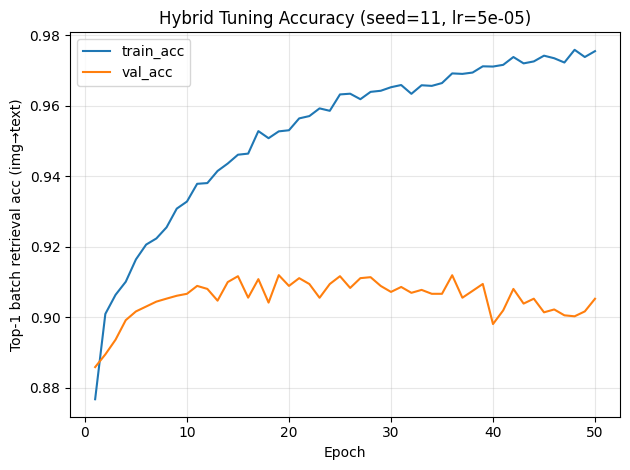

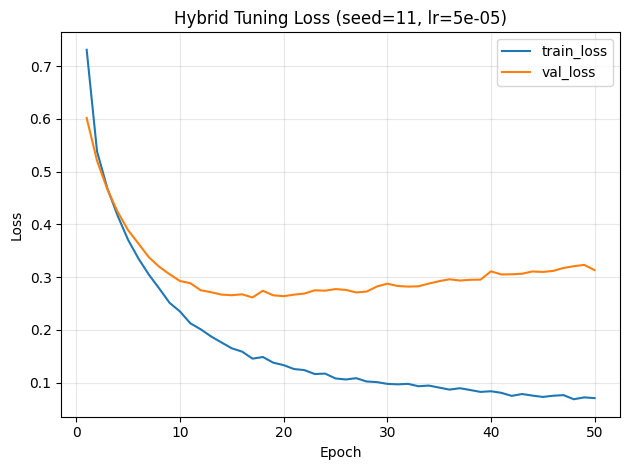


Seed 22 | Staging data

====== Hybrid Tuning (seed=22, lr=5e-05) ======
Seed 22 | Epoch 01/50 | train_loss=0.7280 valid_loss=0.5841 | train_acc=0.8812 valid_acc=0.8964
Seed 22 | Epoch 02/50 | train_loss=0.5382 valid_loss=0.5034 | train_acc=0.8973 valid_acc=0.8969
Seed 22 | Epoch 03/50 | train_loss=0.4709 valid_loss=0.4467 | train_acc=0.9048 valid_acc=0.9002
Seed 22 | Epoch 04/50 | train_loss=0.4162 valid_loss=0.4049 | train_acc=0.9078 valid_acc=0.9080
Seed 22 | Epoch 05/50 | train_loss=0.3720 valid_loss=0.3705 | train_acc=0.9164 valid_acc=0.9064
Seed 22 | Epoch 06/50 | train_loss=0.3350 valid_loss=0.3430 | train_acc=0.9199 valid_acc=0.9100
Seed 22 | Epoch 07/50 | train_loss=0.3010 valid_loss=0.3212 | train_acc=0.9230 valid_acc=0.9077
Seed 22 | Epoch 08/50 | train_loss=0.2723 valid_loss=0.3034 | train_acc=0.9290 valid_acc=0.9122
Seed 22 | Epoch 09/50 | train_loss=0.2541 valid_loss=0.2855 | train_acc=0.9299 valid_acc=0.9153
Seed 22 | Epoch 10/50 | train_loss=0.2335 valid_loss=0.2762 | t

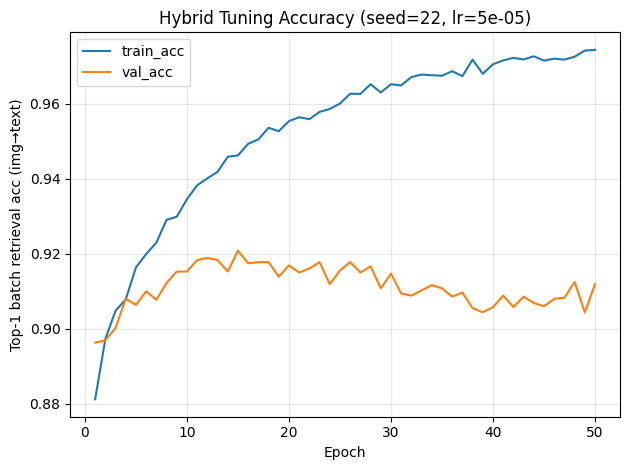

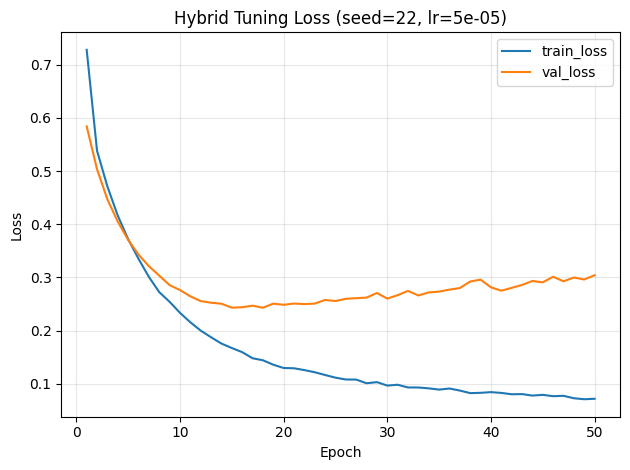


Seed 33 | Staging data

====== Hybrid Tuning (seed=33, lr=5e-05) ======
Seed 33 | Epoch 01/50 | train_loss=0.7339 valid_loss=0.6018 | train_acc=0.8788 valid_acc=0.8858
Seed 33 | Epoch 02/50 | train_loss=0.5419 valid_loss=0.5165 | train_acc=0.8945 valid_acc=0.8944
Seed 33 | Epoch 03/50 | train_loss=0.4683 valid_loss=0.4601 | train_acc=0.9056 valid_acc=0.9033
Seed 33 | Epoch 04/50 | train_loss=0.4181 valid_loss=0.4171 | train_acc=0.9103 valid_acc=0.9091
Seed 33 | Epoch 05/50 | train_loss=0.3692 valid_loss=0.3814 | train_acc=0.9168 valid_acc=0.9080
Seed 33 | Epoch 06/50 | train_loss=0.3347 valid_loss=0.3512 | train_acc=0.9189 valid_acc=0.9144
Seed 33 | Epoch 07/50 | train_loss=0.3052 valid_loss=0.3275 | train_acc=0.9245 valid_acc=0.9169
Seed 33 | Epoch 08/50 | train_loss=0.2744 valid_loss=0.3107 | train_acc=0.9303 valid_acc=0.9169
Seed 33 | Epoch 09/50 | train_loss=0.2521 valid_loss=0.2936 | train_acc=0.9313 valid_acc=0.9177
Seed 33 | Epoch 10/50 | train_loss=0.2366 valid_loss=0.2805 | t

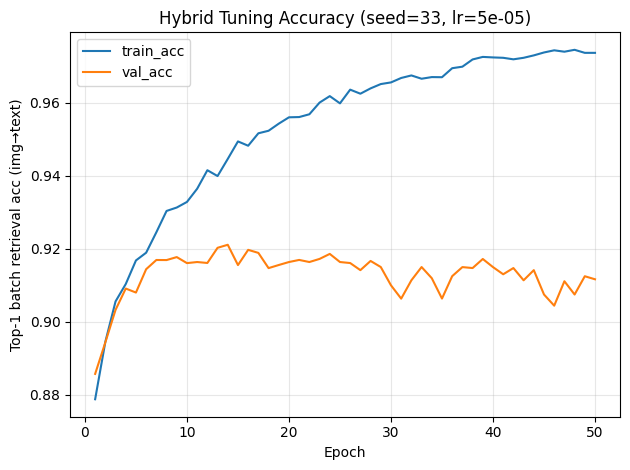

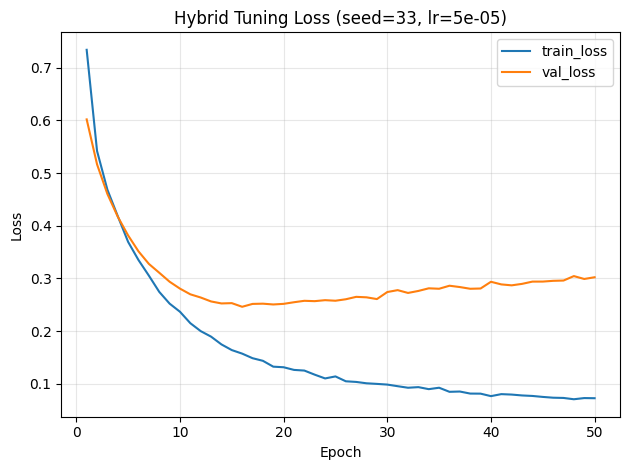


Seed 44 | Staging data

====== Hybrid Tuning (seed=44, lr=5e-05) ======
Seed 44 | Epoch 01/50 | train_loss=0.7354 valid_loss=0.5889 | train_acc=0.8776 valid_acc=0.8949
Seed 44 | Epoch 02/50 | train_loss=0.5458 valid_loss=0.5075 | train_acc=0.8945 valid_acc=0.9002
Seed 44 | Epoch 03/50 | train_loss=0.4738 valid_loss=0.4507 | train_acc=0.9014 valid_acc=0.9005
Seed 44 | Epoch 04/50 | train_loss=0.4142 valid_loss=0.4048 | train_acc=0.9106 valid_acc=0.9069
Seed 44 | Epoch 05/50 | train_loss=0.3724 valid_loss=0.3734 | train_acc=0.9153 valid_acc=0.9108
Seed 44 | Epoch 06/50 | train_loss=0.3368 valid_loss=0.3438 | train_acc=0.9195 valid_acc=0.9058
Seed 44 | Epoch 07/50 | train_loss=0.3037 valid_loss=0.3190 | train_acc=0.9229 valid_acc=0.9130
Seed 44 | Epoch 08/50 | train_loss=0.2743 valid_loss=0.2980 | train_acc=0.9282 valid_acc=0.9133
Seed 44 | Epoch 09/50 | train_loss=0.2525 valid_loss=0.2844 | train_acc=0.9321 valid_acc=0.9169
Seed 44 | Epoch 10/50 | train_loss=0.2352 valid_loss=0.2735 | t

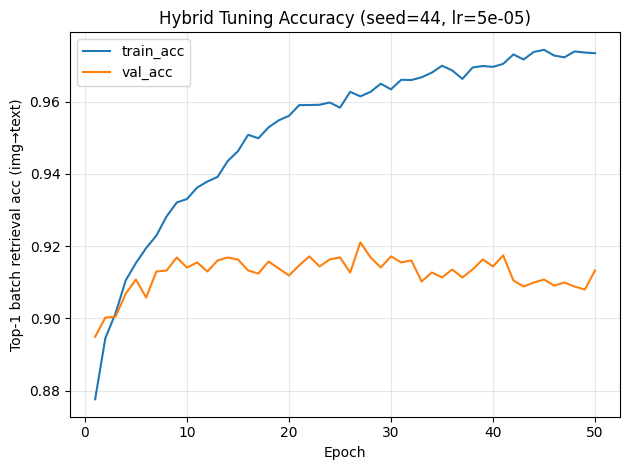

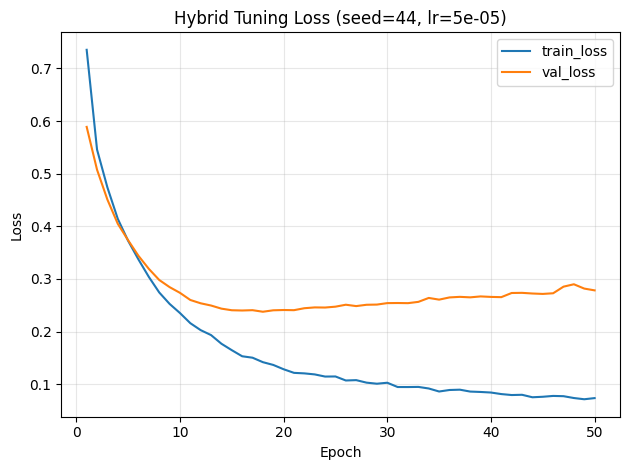


Seed 55 | Staging data

====== Hybrid Tuning (seed=55, lr=5e-05) ======
Seed 55 | Epoch 01/50 | train_loss=0.7287 valid_loss=0.5951 | train_acc=0.8769 valid_acc=0.8916
Seed 55 | Epoch 02/50 | train_loss=0.5417 valid_loss=0.5122 | train_acc=0.8966 valid_acc=0.8958
Seed 55 | Epoch 03/50 | train_loss=0.4711 valid_loss=0.4566 | train_acc=0.9057 valid_acc=0.9000
Seed 55 | Epoch 04/50 | train_loss=0.4153 valid_loss=0.4163 | train_acc=0.9103 valid_acc=0.9011
Seed 55 | Epoch 05/50 | train_loss=0.3692 valid_loss=0.3798 | train_acc=0.9146 valid_acc=0.9002
Seed 55 | Epoch 06/50 | train_loss=0.3347 valid_loss=0.3491 | train_acc=0.9207 valid_acc=0.9086
Seed 55 | Epoch 07/50 | train_loss=0.2961 valid_loss=0.3278 | train_acc=0.9267 valid_acc=0.9100
Seed 55 | Epoch 08/50 | train_loss=0.2775 valid_loss=0.3105 | train_acc=0.9273 valid_acc=0.9089
Seed 55 | Epoch 09/50 | train_loss=0.2502 valid_loss=0.2912 | train_acc=0.9316 valid_acc=0.9136
Seed 55 | Epoch 10/50 | train_loss=0.2332 valid_loss=0.2817 | t

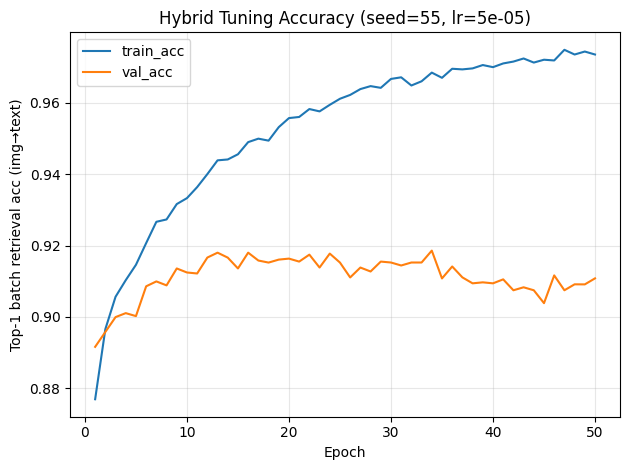

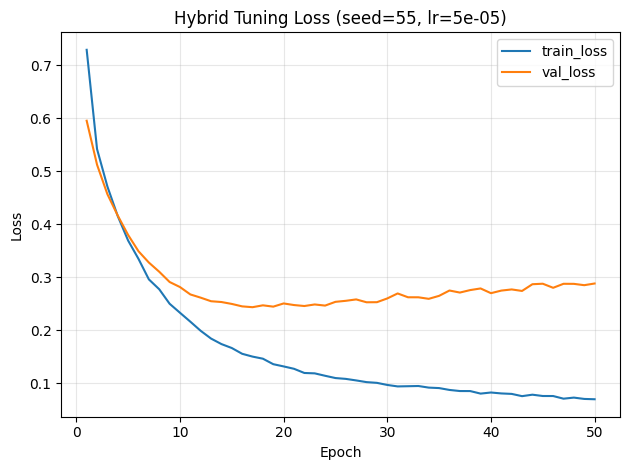


Done. Best prompt checkpoints stored for all seeds:
{11: '/content/drive/MyDrive/Thesis_Data/0111/HybridTune_results/hybrid_prompt_best_seed_11.pt', 22: '/content/drive/MyDrive/Thesis_Data/0111/HybridTune_results/hybrid_prompt_best_seed_22.pt', 33: '/content/drive/MyDrive/Thesis_Data/0111/HybridTune_results/hybrid_prompt_best_seed_33.pt', 44: '/content/drive/MyDrive/Thesis_Data/0111/HybridTune_results/hybrid_prompt_best_seed_44.pt', 55: '/content/drive/MyDrive/Thesis_Data/0111/HybridTune_results/hybrid_prompt_best_seed_55.pt'}


In [ ]:
# ============================================
# Hybrid Tuning (PromptShift) - TRAINING (5 seeds)
# - Data loading matches your LinearProbe style:
#   * copy images from Drive -> /content (local)
#   * build DataFrame with absolute paths
#   * DataLoader reads local image paths
# - Saves best prompt weights per seed to Drive
# - Optional: cleans local staged folders per seed to save space
# ============================================

import os
import json
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import clip

# -----------------------------
# Config
# -----------------------------
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
RESULT_DIR = DRIVE_BASE_DIR / "HybridTune_results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_BASE_DIR = Path("/content")

SEEDS = [11, 22, 33, 44, 55]

BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 5e-5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_DTYPE = torch.float32

print("device:", DEVICE)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

# -----------------------------
# Utilities (same style as your LinearProbe)
# -----------------------------
def stage_split_images(seed: int, split: str) -> Path:
    """
    Copy images for a given seed & split from Drive to local /content.
    Expect source: DRIVE_BASE_DIR/seed_{seed}/{split}/images/*.jpg
    Return local dir: /content/seed_{seed}_{split}_images
    """
    src = DRIVE_BASE_DIR / f"seed_{seed}" / split / "images"
    dst = LOCAL_BASE_DIR / f"seed_{seed}_{split}_images"

    if not src.exists():
        raise FileNotFoundError(f"Missing source images: {src}")

    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)
    return dst

def cleanup_staged_images(seed: int):
    """Remove staged dirs to free /content space."""
    for split in ["train", "valid", "test"]:
        d = LOCAL_BASE_DIR / f"seed_{seed}_{split}_images"
        if d.exists():
            shutil.rmtree(d)

def build_pairs_dataframe(seed: int, split: str, image_dir: Path) -> pd.DataFrame:
    """
    Read split pairs CSV:
      DRIVE_BASE_DIR/seed_{seed}/{split}/{split}_pairs.csv
    Must contain columns: image_id, filepath, description
    We create an absolute image path:
      path = image_dir / (basename(image_id) + .jpg)   (Drive staging uses <image_id>.jpg)
    If your filenames are not <image_id>.jpg, adjust below.

    Returns df with columns: image_id, path, description
    """
    csv_path = DRIVE_BASE_DIR / f"seed_{seed}" / split / f"{split}_pairs.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing pairs CSV: {csv_path}")

    df = pd.read_csv(csv_path, encoding="utf-8-sig")

    needed = {"image_id", "description"}
    for c in needed:
        if c not in df.columns:
            raise ValueError(f"Pairs CSV missing required column: {c} | file={csv_path}")

    # Build local image path. Assumes images are named "<image_id>.jpg"
    df["path"] = df["image_id"].astype(str) + ".jpg"
    df["path"] = df["path"].apply(lambda n: str(image_dir / n))

    # Keep only what we need
    out = df[["image_id", "path", "description"]].copy()
    return out

# -----------------------------
# Dataset / Loader
# -----------------------------
class PairDatasetFrame(Dataset):
    """
    frame columns:
      - path (absolute)
      - description (text)
      - image_id (optional, for debug)
    """
    def __init__(self, frame: pd.DataFrame, preprocess):
        self.f = frame.reset_index(drop=True)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.f)

    def __getitem__(self, idx):
        r = self.f.iloc[idx]
        image = Image.open(r["path"]).convert("RGB")
        image = self.preprocess(image)  # returns float tensor
        text = str(r["description"])
        return image, text

def make_loader(df: pd.DataFrame, preprocess, shuffle: bool):
    ds = PairDatasetFrame(df, preprocess)
    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=2 if DEVICE == "cuda" else 0,
        pin_memory=(DEVICE == "cuda"),
    )

# -----------------------------
# Model: frozen CLIP + PromptShift head
# -----------------------------
class PromptShift(nn.Module):
    """Learn an additive shift on text features."""
    def __init__(self, dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, dim),
        )

    def forward(self, text_feat: torch.Tensor) -> torch.Tensor:
        text_feat = text_feat.to(dtype=TORCH_DTYPE)
        shift = self.net(text_feat)
        return (text_feat + shift).to(dtype=TORCH_DTYPE)

def clip_contrastive_loss(img_feats: torch.Tensor, txt_feats: torch.Tensor, logit_scale: torch.Tensor):
    """
    CLIP-style symmetric InfoNCE.
    Returns (loss, top1_acc_img_to_text).
    """
    img = img_feats.to(dtype=TORCH_DTYPE)
    txt = txt_feats.to(dtype=TORCH_DTYPE)

    img = img / img.norm(dim=1, keepdim=True)
    txt = txt / txt.norm(dim=1, keepdim=True)

    scale = logit_scale.exp().to(dtype=TORCH_DTYPE)
    logits_per_image = scale * img @ txt.t()
    logits_per_text  = logits_per_image.t()

    targets = torch.arange(img.shape[0], device=img.device)
    loss_i = nn.functional.cross_entropy(logits_per_image, targets)
    loss_t = nn.functional.cross_entropy(logits_per_text,  targets)
    loss = (loss_i + loss_t) / 2

    preds = logits_per_image.argmax(dim=1)
    acc = (preds == targets).float().mean().item()
    return loss, acc

def run_one_seed(seed: int):
    print(f"\n===============================")
    print(f"Seed {seed} | Staging data")
    print(f"===============================")

    train_img_dir = stage_split_images(seed, "train")
    valid_img_dir = stage_split_images(seed, "valid")
    test_img_dir  = stage_split_images(seed, "test")  # not used in training; kept for consistency

    train_df = build_pairs_dataframe(seed, "train", train_img_dir)
    valid_df = build_pairs_dataframe(seed, "valid", valid_img_dir)

    # Load CLIP (frozen)
    clip_model, preprocess = clip.load("ViT-B/32", device=DEVICE, jit=False)
    clip_model = clip_model.float()
    clip_model.eval()
    for p in clip_model.parameters():
        p.requires_grad = False

    embed_dim = clip_model.text_projection.shape[1]

    # Prompt head + temperature
    prompt_weights = PromptShift(embed_dim).to(DEVICE, dtype=TORCH_DTYPE)
    logit_scale = nn.Parameter(torch.log(torch.tensor(1/0.07, dtype=TORCH_DTYPE, device=DEVICE)))

    optimizer = torch.optim.AdamW(list(prompt_weights.parameters()) + [logit_scale], lr=LEARNING_RATE)

    train_dl = make_loader(train_df, preprocess, shuffle=True)
    valid_dl = make_loader(valid_df, preprocess, shuffle=False)

    history = defaultdict(list)
    best_valid = float("-inf")
    best_state = None

    print(f"\n====== Hybrid Tuning (seed={seed}, lr={LEARNING_RATE}) ======")

    for epoch in range(1, EPOCHS + 1):
        # -------- Train --------
        clip_model.eval()
        prompt_weights.train()

        tr_loss_sum, tr_acc_sum, tr_batches = 0.0, 0.0, 0

        for images, texts in train_dl:
            images = images.to(DEVICE, non_blocking=True).to(dtype=TORCH_DTYPE)
            tokens = clip.tokenize(list(texts), truncate=True).to(DEVICE, non_blocking=True)

            with torch.no_grad():
                img_f = clip_model.encode_image(images).to(dtype=TORCH_DTYPE)
                txt_f = clip_model.encode_text(tokens).to(dtype=TORCH_DTYPE)

            txt_f = prompt_weights(txt_f)
            loss_c, acc_c = clip_contrastive_loss(img_f, txt_f, logit_scale)

            optimizer.zero_grad(set_to_none=True)
            loss_c.backward()
            optimizer.step()

            tr_loss_sum += float(loss_c.item())
            tr_acc_sum  += float(acc_c)
            tr_batches  += 1

        tr_loss = tr_loss_sum / max(1, tr_batches)
        tr_acc  = tr_acc_sum  / max(1, tr_batches)

        # -------- Valid --------
        clip_model.eval()
        prompt_weights.eval()

        va_loss_sum, va_acc_sum, va_batches = 0.0, 0.0, 0
        with torch.no_grad():
            for images, texts in valid_dl:
                images = images.to(DEVICE, non_blocking=True).to(dtype=TORCH_DTYPE)
                tokens = clip.tokenize(list(texts), truncate=True).to(DEVICE, non_blocking=True)

                img_f = clip_model.encode_image(images).to(dtype=TORCH_DTYPE)
                txt_f = clip_model.encode_text(tokens).to(dtype=TORCH_DTYPE)
                txt_f = prompt_weights(txt_f)

                loss_c, acc_c = clip_contrastive_loss(img_f, txt_f, logit_scale)

                va_loss_sum += float(loss_c.item())
                va_acc_sum  += float(acc_c)
                va_batches  += 1

        va_loss = va_loss_sum / max(1, va_batches)
        va_acc  = va_acc_sum  / max(1, va_batches)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if va_acc > best_valid:
            best_valid = va_acc
            best_state = {k: v.detach().cpu() for k, v in prompt_weights.state_dict().items()}

        print(
            f"Seed {seed} | Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={tr_loss:.4f} valid_loss={va_loss:.4f} | "
            f"train_acc={tr_acc:.4f} valid_acc={va_acc:.4f}"
        )

    # Save best prompt weights per seed
    best_path = RESULT_DIR / f"hybrid_prompt_best_seed_{seed}.pt"
    torch.save(
        {
            "seed": seed,
            "best_valid_acc": float(best_valid),
            "state_dict": best_state,
            "model": "ViT-B/32",
            "lr": float(LEARNING_RATE),
            "epochs": int(EPOCHS),
        },
        best_path
    )
    print("Saved best prompt weights:", best_path)

    # Plot curves (show only)
    epochs_axis = list(range(1, EPOCHS + 1))

    plt.figure()
    plt.plot(epochs_axis, history["train_acc"], label="train_acc")
    plt.plot(epochs_axis, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch"); plt.ylabel("Top-1 batch retrieval acc (img→text)")
    plt.title(f"Hybrid Tuning Accuracy (seed={seed}, lr={LEARNING_RATE:.0e})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    plt.figure()
    plt.plot(epochs_axis, history["train_loss"], label="train_loss")
    plt.plot(epochs_axis, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"Hybrid Tuning Loss (seed={seed}, lr={LEARNING_RATE:.0e})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    # Cleanup local staging (optional; comment out if you want to reuse within same runtime)
    cleanup_staged_images(seed)

    return str(best_path)

# -----------------------------
# Run all seeds
# -----------------------------
best_paths = {}
for seed in SEEDS:
    best_paths[seed] = run_one_seed(seed)

print("\nDone. Best prompt checkpoints stored for all seeds:")
print(best_paths)

In [ ]:
# ============================================
# Hybrid Tuning (PromptShift) - EVALUATION (5 seeds)
# - For each seed:
#   1) Load best prompt weights from Drive
#   2) Run inference on staged local test images (Drive -> /content)
#   3) Save predictions CSV per seed to Drive
#   4) Evaluate vs GT test.csv with the SAME metrics style you used:
#        * Single: accuracy/precision/recall/f1 + CLIP semantic similarity
#        * Multi: relaxed_match + CLIP semantic similarity
# - Finally prints mean ± std summary table over 5 seeds
# ============================================

import os
import json
import ast
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import torch
import torch.nn as nn
from PIL import Image
from tqdm import tqdm
import clip

# -----------------------------
# Config
# -----------------------------
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
RESULT_DIR = DRIVE_BASE_DIR / "HybridTune_results"

LOCAL_BASE_DIR = Path("/content")

SEEDS = [11, 22, 33, 44, 55]

LABEL_LIB_PATH = DRIVE_BASE_DIR / "label_library.json"

single_attrs = ["category", "sub_category"]
multi_attrs  = ["color", "material", "pattern"]

# Inference hyperparams (match your hybrid inference style)
TOPK = {"color": 3, "material": 3, "pattern": 2}
THRESH = {"color": 0.3, "material": 0.3, "pattern": 0.5}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_DTYPE = torch.float32

print("device:", DEVICE)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

# -----------------------------
# Utilities (same staging style)
# -----------------------------
def stage_split_images(seed: int, split: str) -> Path:
    src = DRIVE_BASE_DIR / f"seed_{seed}" / split / "images"
    dst = LOCAL_BASE_DIR / f"seed_{seed}_{split}_images"

    if not src.exists():
        raise FileNotFoundError(f"Missing source images: {src}")

    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)
    return dst

def cleanup_staged_images(seed: int):
    for split in ["train", "valid", "test"]:
        d = LOCAL_BASE_DIR / f"seed_{seed}_{split}_images"
        if d.exists():
            shutil.rmtree(d)

def parse_list_cell(x):
    if isinstance(x, list):
        return [str(t).strip() for t in x]
    if pd.isna(x):
        return []
    s = str(x).strip()
    if not s:
        return []
    # try python literal list
    try:
        val = ast.literal_eval(s)
        if isinstance(val, list):
            return [str(t).strip() for t in val]
    except Exception:
        pass
    # try JSON list
    try:
        val = json.loads(s)
        if isinstance(val, list):
            return [str(t).strip() for t in val]
    except Exception:
        pass
    # fallback
    if "|" in s:
        return [t.strip() for t in s.split("|") if t.strip()]
    return [t.strip() for t in s.split(",") if t.strip()]

def is_missing(x):
    if pd.isna(x):
        return True
    if isinstance(x, str) and x.strip() == "":
        return True
    return False

def relaxed_match(a, b):
    return 1.0 if (set(a) & set(b)) else 0.0

def mean_std_str(xs):
    xs = [x for x in xs if x is not None and not (isinstance(x, float) and np.isnan(x))]
    if len(xs) == 0:
        return "-"
    mu = float(np.mean(xs))
    sd = float(np.std(xs, ddof=1)) if len(xs) > 1 else 0.0
    return f"{mu:.3f} ± {sd:.3f}"

# -----------------------------
# Load label library + templates
# -----------------------------
if not LABEL_LIB_PATH.exists():
    raise FileNotFoundError(f"label_library.json not found: {LABEL_LIB_PATH}")

with LABEL_LIB_PATH.open("r", encoding="utf-8-sig") as f:
    label_library: Dict[str, List[str]] = json.load(f)

prompts: Dict[str, List[str]] = {
    "category":     ["a photo of a {label} item", "a fashion photo of {label}"],
    "sub_category": ["a {label}", "a {label} garment"],
    "color":        ["{label} color", "a {label} colored item"],
    "material":     ["made of {label}", "a {label} material garment"],
    "pattern":      ["{label} pattern", "a {label} print"],
}

# -----------------------------
# CLIP model (frozen, FP32)
# -----------------------------
clip_model, preprocess = clip.load("ViT-B/32", device=DEVICE, jit=False)
clip_model.eval()
clip_model = clip_model.float()
for p in clip_model.parameters():
    p.requires_grad = False

embed_dim = clip_model.text_projection.shape[1]

# -----------------------------
# Prompt head definition (must match training)
# -----------------------------
class PromptShift(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, dim),
        )
    def forward(self, text_feat: torch.Tensor) -> torch.Tensor:
        text_feat = text_feat.to(dtype=TORCH_DTYPE)
        return (text_feat + self.net(text_feat)).to(dtype=TORCH_DTYPE)

def load_prompt_head(weights_path: Path) -> nn.Module:
    ckpt = torch.load(weights_path, map_location="cpu")
    state = ckpt.get("state_dict", ckpt)  # allow raw state_dict if needed
    head = PromptShift(embed_dim).to(DEVICE, dtype=TORCH_DTYPE)
    head.load_state_dict(state, strict=True)
    head.eval()
    return head

@torch.no_grad()
def encode_texts_with_prompt(texts: List[str], prompt_head: nn.Module) -> torch.Tensor:
    outs = []
    bs = 128
    for i in range(0, len(texts), bs):
        toks = clip.tokenize(texts[i:i+bs], truncate=True).to(DEVICE)
        txt = clip_model.encode_text(toks).to(dtype=TORCH_DTYPE)
        txt = prompt_head(txt).to(dtype=TORCH_DTYPE)
        txt = txt / txt.norm(dim=1, keepdim=True)
        outs.append(txt)
    if not outs:
        return torch.empty(0, embed_dim, device=DEVICE, dtype=TORCH_DTYPE)
    return torch.cat(outs, dim=0)

def build_text_bank(prompt_head: nn.Module) -> Tuple[torch.Tensor, List[Tuple[str, str]]]:
    texts, meta = [], []
    for dim, labels in label_library.items():
        if dim not in prompts:
            continue
        for lab in labels:
            for tpl in prompts[dim]:
                texts.append(tpl.format(label=lab))
                meta.append((dim, lab))
    embeds = encode_texts_with_prompt(texts, prompt_head)
    return embeds, meta

@torch.no_grad()
def infer_image(image_path: str, text_bank: torch.Tensor, text_meta: List[Tuple[str, str]]) -> Dict:
    img = preprocess(Image.open(image_path).convert("RGB")).unsqueeze(0).to(DEVICE).to(dtype=TORCH_DTYPE)
    img_f = clip_model.encode_image(img).to(dtype=TORCH_DTYPE)
    img_f = img_f / img_f.norm(dim=1, keepdim=True)

    sims = (img_f @ text_bank.t()).squeeze(0).tolist()

    aggregated: Dict[str, Dict[str, float]] = {}
    for i, (dim, lab) in enumerate(text_meta):
        sc = float(sims[i])
        aggregated.setdefault(dim, {})
        if lab not in aggregated[dim] or sc > aggregated[dim][lab]:
            aggregated[dim][lab] = sc

    out = {"category": "", "sub_category": "", "color": [], "material": [], "pattern": []}

    for dim in ["category", "sub_category"]:
        if dim in aggregated and aggregated[dim]:
            out[dim] = max(aggregated[dim].items(), key=lambda x: x[1])[0]

    for dim in ["color", "material", "pattern"]:
        if dim in aggregated and aggregated[dim]:
            items = sorted(aggregated[dim].items(), key=lambda x: x[1], reverse=True)
            passed = [lab for lab, sc in items if sc >= THRESH[dim]]
            if not passed and items:
                passed = [items[0][0]]
            out[dim] = passed[:TOPK[dim]]

    return out

# -----------------------------
# Semantic similarity (same idea as your LinearProbe eval)
# -----------------------------
@torch.no_grad()
def embed_text_batch(texts: List[str]) -> torch.Tensor:
    toks = clip.tokenize(texts, truncate=True).to(DEVICE)
    feats = clip_model.encode_text(toks).float()
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats

_embed_cache = {}
def get_text_embed(label: str):
    key = str(label).strip().lower()
    if key == "":
        return None
    if key not in _embed_cache:
        _embed_cache[key] = embed_text_batch([key])
    return _embed_cache[key]

def semantic_sim_single(gt_label, pred_label):
    a = get_text_embed(gt_label)
    b = get_text_embed(pred_label)
    if a is None or b is None:
        return np.nan
    return float((a @ b.T).item())

def semantic_sim_multilabel(gt_labels, pred_labels):
    gt = [g for g in gt_labels if str(g).strip()]
    pr = [p for p in pred_labels if str(p).strip()]
    if len(gt) == 0:
        return np.nan
    if len(pr) == 0:
        return 0.0
    gt_feats = torch.cat([get_text_embed(g) for g in gt if get_text_embed(g) is not None], dim=0)
    pr_feats = torch.cat([get_text_embed(p) for p in pr if get_text_embed(p) is not None], dim=0)
    if gt_feats.numel() == 0:
        return np.nan
    if pr_feats.numel() == 0:
        return 0.0
    sims = gt_feats @ pr_feats.T
    return float(sims.max(dim=1).values.mean().item())

# -----------------------------
# Per-seed evaluation
# -----------------------------
def evaluate_one_seed(gt_csv: Path, pred_csv: Path):
    gt = pd.read_csv(gt_csv)
    pred = pd.read_csv(pred_csv)

    needed = ["image_id"] + single_attrs + multi_attrs
    for c in needed:
        if c not in gt.columns:
            raise ValueError(f"GT missing column: {c}")
        if c not in pred.columns:
            raise ValueError(f"PRED missing column: {c}")

    df = gt.merge(pred, on="image_id", suffixes=("_gt", "_pred"), how="inner")

    report = {"single": {}, "multi": {}}

    # Single-label
    for attr in single_attrs:
        gcol, pcol = f"{attr}_gt", f"{attr}_pred"
        mask = ~df[gcol].apply(is_missing)
        if mask.sum() == 0:
            continue

        y_true = df.loc[mask, gcol].astype(str).tolist()
        y_pred = df.loc[mask, pcol].astype(str).tolist()

        acc = accuracy_score(y_true, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )

        sems = [semantic_sim_single(t, p) for t, p in zip(y_true, y_pred)]
        sems = [s for s in sems if not np.isnan(s)]
        sem_mean = float(np.mean(sems)) if sems else float("nan")

        report["single"][attr] = {
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "semantic_similarity_clip": float(sem_mean),
        }

    # Multi-label
    for attr in multi_attrs:
        gcol, pcol = f"{attr}_gt", f"{attr}_pred"
        gt_lists = df[gcol].apply(parse_list_cell)
        pr_lists = df[pcol].apply(parse_list_cell)

        mask = gt_lists.apply(lambda x: len(x) > 0)
        if mask.sum() == 0:
            continue

        gtv = gt_lists[mask].tolist()
        prv = pr_lists[mask].tolist()

        relaxed = float(np.mean([relaxed_match(g, p) for g, p in zip(gtv, prv)]))
        sems = [semantic_sim_multilabel(g, p) for g, p in zip(gtv, prv)]
        sems = [s for s in sems if not np.isnan(s)]
        sem = float(np.mean(sems)) if sems else float("nan")

        report["multi"][attr] = {
            "relaxed_match_acc": relaxed,
            "semantic_similarity_clip": sem,
        }

    return report

# -----------------------------
# Run inference + evaluation for all seeds
# -----------------------------
all_reports = {}

for seed in SEEDS:
    print(f"\n===============================")
    print(f"Seed {seed} | Inference + Evaluation")
    print(f"===============================")

    # Stage test images to local
    test_img_dir = stage_split_images(seed, "test")

    # Load best prompt head
    best_ckpt_path = RESULT_DIR / f"hybrid_prompt_best_seed_{seed}.pt"
    if not best_ckpt_path.exists():
        raise FileNotFoundError(f"Missing prompt checkpoint: {best_ckpt_path}")

    prompt_head = load_prompt_head(best_ckpt_path)

    # Build text bank for this seed's prompt head
    text_bank, text_meta = build_text_bank(prompt_head)
    if text_bank.numel() == 0:
        raise ValueError("Empty text bank. Check label_library.json and prompts templates.")

    # Read GT test.csv (for image_id list) from Drive
    gt_csv = DRIVE_BASE_DIR / f"seed_{seed}" / "test" / "test.csv"
    gt_df = pd.read_csv(gt_csv, encoding="utf-8-sig")
    if "image_id" not in gt_df.columns:
        raise ValueError(f"test.csv missing image_id: {gt_csv}")

    # Inference loop
    pred_rows = []
    for image_id in tqdm(gt_df["image_id"].astype(str).tolist(), desc=f"predict(seed={seed})"):
        img_path = str(Path(test_img_dir) / f"{image_id}.jpg")
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Missing staged image: {img_path}")

        out = infer_image(img_path, text_bank, text_meta)

        pred_rows.append({
            "image_id": image_id,
            "category": out["category"],
            "sub_category": out["sub_category"],
            "color": json.dumps(out["color"], ensure_ascii=False),
            "material": json.dumps(out["material"], ensure_ascii=False),
            "pattern": json.dumps(out["pattern"], ensure_ascii=False),
        })

    pred_df = pd.DataFrame(pred_rows)

    pred_csv_path = RESULT_DIR / f"hybrid_seed_{seed}_pred.csv"
    pred_df.to_csv(pred_csv_path, index=False, encoding="utf-8")
    print("Saved predictions:", pred_csv_path)

    # Evaluate
    rep = evaluate_one_seed(gt_csv, pred_csv_path)
    all_reports[seed] = rep

    print(f"\n===== Seed {seed} Results (Hybrid Tune) =====")
    for attr in single_attrs:
        if attr in rep["single"]:
            m = rep["single"][attr]
            print(f"{attr}: acc={m['accuracy']:.4f}, prec={m['precision']:.4f}, rec={m['recall']:.4f}, f1={m['f1']:.4f}, sem_sim={m['semantic_similarity_clip']:.4f}")
    for attr in multi_attrs:
        if attr in rep["multi"]:
            m = rep["multi"][attr]
            print(f"{attr}: relaxed={m['relaxed_match_acc']:.4f}, sem_sim={m['semantic_similarity_clip']:.4f}")

    # Save per-seed eval JSON
    seed_eval_path = RESULT_DIR / f"hybrid_seed_{seed}_eval.json"
    with seed_eval_path.open("w", encoding="utf-8") as f:
        json.dump(rep, f, ensure_ascii=False, indent=2)
    print(f"Saved seed eval: {seed_eval_path}")

    # Cleanup staged images (optional)
    cleanup_staged_images(seed)

# -----------------------------
# Final mean ± std summary table
# -----------------------------
rows = []

# Single-label summary rows
for attr in single_attrs:
    vals_acc, vals_prec, vals_rec, vals_f1, vals_sem = [], [], [], [], []
    for seed in SEEDS:
        m = all_reports[seed]["single"].get(attr, {})
        vals_acc.append(m.get("accuracy", np.nan))
        vals_prec.append(m.get("precision", np.nan))
        vals_rec.append(m.get("recall", np.nan))
        vals_f1.append(m.get("f1", np.nan))
        vals_sem.append(m.get("semantic_similarity_clip", np.nan))

    rows.append({
        "Method": "HybridTune",
        "Attribute Type": "Single-Label",
        "Attributes": "Category" if attr == "category" else "Subcategory",
        "Accuracy": mean_std_str(vals_acc),
        "Precision": mean_std_str(vals_prec),
        "Recall": mean_std_str(vals_rec),
        "F1": mean_std_str(vals_f1),
        "Relaxed Match": "-",
        "Semantic Similarity": mean_std_str(vals_sem),
    })

# Multi-label summary rows
for attr in multi_attrs:
    vals_relaxed, vals_sem = [], []
    for seed in SEEDS:
        m = all_reports[seed]["multi"].get(attr, {})
        vals_relaxed.append(m.get("relaxed_match_acc", np.nan))
        vals_sem.append(m.get("semantic_similarity_clip", np.nan))

    rows.append({
        "Method": "HybridTune",
        "Attribute Type": "Multi-Label",
        "Attributes": attr.capitalize(),
        "Accuracy": "-",
        "Precision": "-",
        "Recall": "-",
        "F1": "-",
        "Relaxed Match": mean_std_str(vals_relaxed),
        "Semantic Similarity": mean_std_str(vals_sem),
    })

df_summary = pd.DataFrame(rows, columns=[
    "Method", "Attribute Type", "Attributes",
    "Accuracy", "Precision", "Recall", "F1",
    "Relaxed Match", "Semantic Similarity"
])

print("\n===== Hybrid Tune Summary (mean ± std over 5 seeds) =====")
print(df_summary.to_string(index=False))

device: cuda
gpu: NVIDIA A100-SXM4-40GB

Seed 11 | Inference + Evaluation


predict(seed=11): 100%|██████████| 3599/3599 [01:26<00:00, 41.38it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/HybridTune_results/hybrid_seed_11_pred.csv

===== Seed 11 Results (Hybrid Tune) =====
category: acc=0.7235, prec=0.6971, rec=0.7464, f1=0.6801, sem_sim=0.9490
sub_category: acc=0.4165, prec=0.3118, rec=0.3439, f1=0.2527, sem_sim=0.8980
color: relaxed=0.0056, sem_sim=0.7387
material: relaxed=0.0044, sem_sim=0.7646
pattern: relaxed=0.0061, sem_sim=0.7129
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/HybridTune_results/hybrid_seed_11_eval.json

Seed 22 | Inference + Evaluation


predict(seed=22): 100%|██████████| 3599/3599 [01:28<00:00, 40.74it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/HybridTune_results/hybrid_seed_22_pred.csv

===== Seed 22 Results (Hybrid Tune) =====
category: acc=0.7760, prec=0.7015, rec=0.7925, f1=0.7156, sem_sim=0.9568
sub_category: acc=0.3620, prec=0.2887, rec=0.3241, f1=0.2407, sem_sim=0.8944
color: relaxed=0.0042, sem_sim=0.7445
material: relaxed=0.0053, sem_sim=0.7671
pattern: relaxed=0.0033, sem_sim=0.7145
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/HybridTune_results/hybrid_seed_22_eval.json

Seed 33 | Inference + Evaluation


...

Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/HybridTune_results/hybrid_seed_33_pred.csv

===== Seed 33 Results (Hybrid Tune) =====
category: acc=0.7991, prec=0.7068, rec=0.7846, f1=0.7225, sem_sim=0.9634
sub_category: acc=0.4073, prec=0.2680, rec=0.3392, f1=0.2389, sem_sim=0.8983
color: relaxed=0.0056, sem_sim=0.7463
material: relaxed=0.0056, sem_sim=0.7691
pattern: relaxed=0.0050, sem_sim=0.7238
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/HybridTune_results/hybrid_seed_33_eval.json

Seed 44 | Inference + Evaluation


predict(seed=44): 100%|██████████| 3599/3599 [01:29<00:00, 40.28it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/HybridTune_results/hybrid_seed_44_pred.csv

===== Seed 44 Results (Hybrid Tune) =====
category: acc=0.7444, prec=0.6777, rec=0.7620, f1=0.6877, sem_sim=0.9531
sub_category: acc=0.4332, prec=0.2634, rec=0.3530, f1=0.2429, sem_sim=0.9010
color: relaxed=0.0061, sem_sim=0.7498
material: relaxed=0.0053, sem_sim=0.7673
pattern: relaxed=0.0025, sem_sim=0.7266
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/HybridTune_results/hybrid_seed_44_eval.json

Seed 55 | Inference + Evaluation


predict(seed=55): 100%|██████████| 3599/3599 [01:28<00:00, 40.66it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/HybridTune_results/hybrid_seed_55_pred.csv

===== Seed 55 Results (Hybrid Tune) =====
category: acc=0.7108, prec=0.6692, rec=0.7330, f1=0.6513, sem_sim=0.9443
sub_category: acc=0.3893, prec=0.2716, rec=0.2967, f1=0.2073, sem_sim=0.8952
color: relaxed=0.0050, sem_sim=0.7416
material: relaxed=0.0044, sem_sim=0.7694
pattern: relaxed=0.0056, sem_sim=0.7281
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/HybridTune_results/hybrid_seed_55_eval.json

===== Hybrid Tune Summary (mean ± std over 5 seeds) =====
    Method Attribute Type  Attributes      Accuracy     Precision        Recall            F1 Relaxed Match Semantic Similarity
HybridTune   Single-Label    Category 0.751 ± 0.037 0.690 ± 0.016 0.764 ± 0.025 0.691 ± 0.029             -       0.953 ± 0.007
HybridTune   Single-Label Subcategory 0.402 ± 0.027 0.281 ± 0.020 0.331 ± 0.022 0.237 ± 0.017             -       0.897 ± 0.003
HybridTune    Multi-Label       Color     

### Full-fine Tuning

device: cuda
gpu: NVIDIA A100-SXM4-40GB

Seed 11 | Staging data

====== Full Fine-Tune (seed=11, lr=1e-06) ======
Seed 11 | Epoch 01/50 | train_loss=0.4029 valid_loss=0.3049 | train_acc=0.8998 valid_acc=0.9061
Seed 11 | Epoch 02/50 | train_loss=0.2446 valid_loss=0.2714 | train_acc=0.9264 valid_acc=0.9158
Seed 11 | Epoch 03/50 | train_loss=0.2029 valid_loss=0.2559 | train_acc=0.9391 valid_acc=0.9180
Seed 11 | Epoch 04/50 | train_loss=0.1740 valid_loss=0.2455 | train_acc=0.9474 valid_acc=0.9200
Seed 11 | Epoch 05/50 | train_loss=0.1504 valid_loss=0.2427 | train_acc=0.9560 valid_acc=0.9189
Seed 11 | Epoch 06/50 | train_loss=0.1290 valid_loss=0.2395 | train_acc=0.9639 valid_acc=0.9247
Seed 11 | Epoch 07/50 | train_loss=0.1185 valid_loss=0.2385 | train_acc=0.9674 valid_acc=0.9211
Seed 11 | Epoch 08/50 | train_loss=0.1075 valid_loss=0.2361 | train_acc=0.9696 valid_acc=0.9239
Seed 11 | Epoch 09/50 | train_loss=0.0943 valid_loss=0.2377 | train_acc=0.9755 valid_acc=0.9197
Seed 11 | Epoch 10/50 

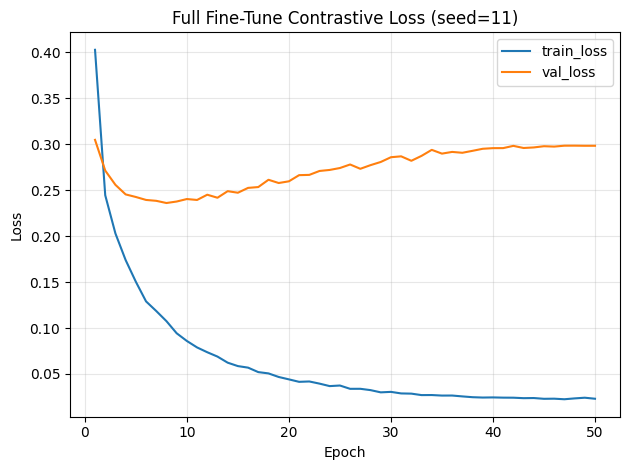

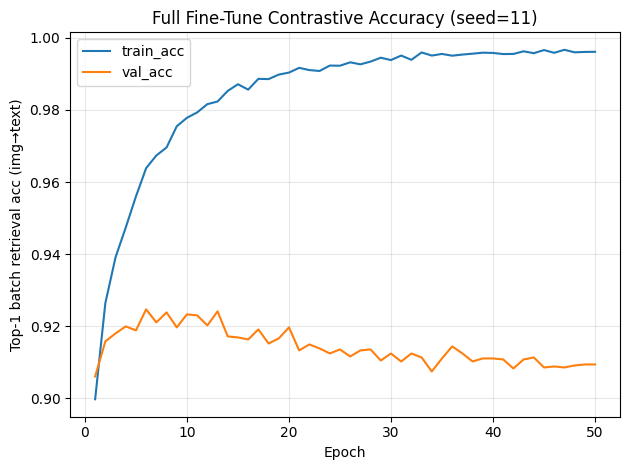


Seed 22 | Staging data

====== Full Fine-Tune (seed=22, lr=1e-06) ======
Seed 22 | Epoch 01/50 | train_loss=0.4010 valid_loss=0.2885 | train_acc=0.9008 valid_acc=0.9108
Seed 22 | Epoch 02/50 | train_loss=0.2452 valid_loss=0.2586 | train_acc=0.9260 valid_acc=0.9172
Seed 22 | Epoch 03/50 | train_loss=0.2041 valid_loss=0.2427 | train_acc=0.9385 valid_acc=0.9275
Seed 22 | Epoch 04/50 | train_loss=0.1743 valid_loss=0.2364 | train_acc=0.9473 valid_acc=0.9286
Seed 22 | Epoch 05/50 | train_loss=0.1506 valid_loss=0.2312 | train_acc=0.9569 valid_acc=0.9283
Seed 22 | Epoch 06/50 | train_loss=0.1299 valid_loss=0.2273 | train_acc=0.9630 valid_acc=0.9283
Seed 22 | Epoch 07/50 | train_loss=0.1158 valid_loss=0.2267 | train_acc=0.9692 valid_acc=0.9300
Seed 22 | Epoch 08/50 | train_loss=0.1052 valid_loss=0.2260 | train_acc=0.9716 valid_acc=0.9278
Seed 22 | Epoch 09/50 | train_loss=0.0947 valid_loss=0.2324 | train_acc=0.9749 valid_acc=0.9239
Seed 22 | Epoch 10/50 | train_loss=0.0879 valid_loss=0.2335 | 

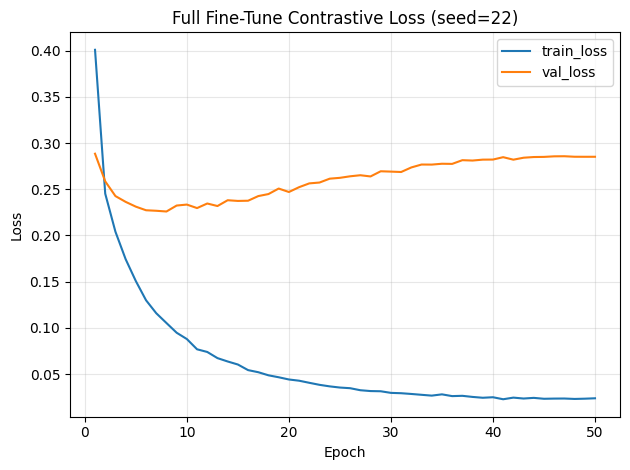

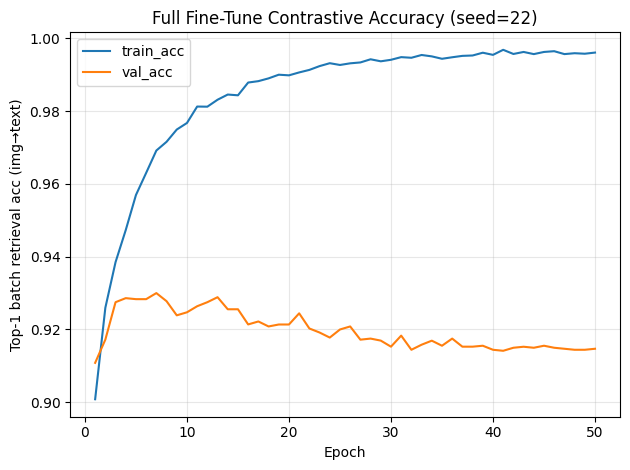


Seed 33 | Staging data

====== Full Fine-Tune (seed=33, lr=1e-06) ======
Seed 33 | Epoch 01/50 | train_loss=0.4052 valid_loss=0.2920 | train_acc=0.8988 valid_acc=0.9166
Seed 33 | Epoch 02/50 | train_loss=0.2438 valid_loss=0.2583 | train_acc=0.9284 valid_acc=0.9200
Seed 33 | Epoch 03/50 | train_loss=0.2026 valid_loss=0.2440 | train_acc=0.9410 valid_acc=0.9264
Seed 33 | Epoch 04/50 | train_loss=0.1740 valid_loss=0.2326 | train_acc=0.9482 valid_acc=0.9286
Seed 33 | Epoch 05/50 | train_loss=0.1465 valid_loss=0.2273 | train_acc=0.9565 valid_acc=0.9283
Seed 33 | Epoch 06/50 | train_loss=0.1284 valid_loss=0.2275 | train_acc=0.9645 valid_acc=0.9258
Seed 33 | Epoch 07/50 | train_loss=0.1152 valid_loss=0.2245 | train_acc=0.9708 valid_acc=0.9292
Seed 33 | Epoch 08/50 | train_loss=0.1039 valid_loss=0.2250 | train_acc=0.9716 valid_acc=0.9266
Seed 33 | Epoch 09/50 | train_loss=0.0930 valid_loss=0.2246 | train_acc=0.9743 valid_acc=0.9294
Seed 33 | Epoch 10/50 | train_loss=0.0862 valid_loss=0.2271 | 

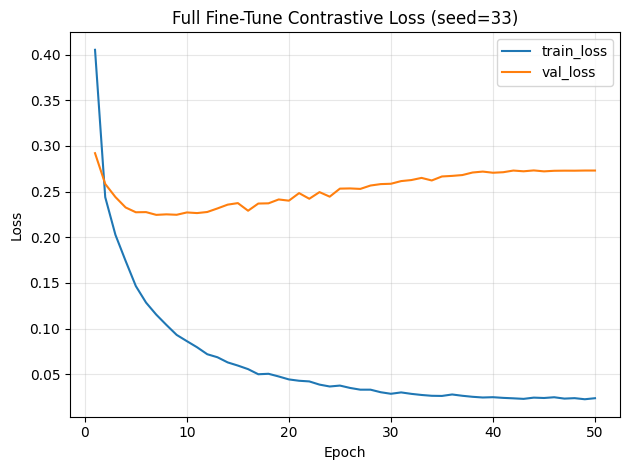

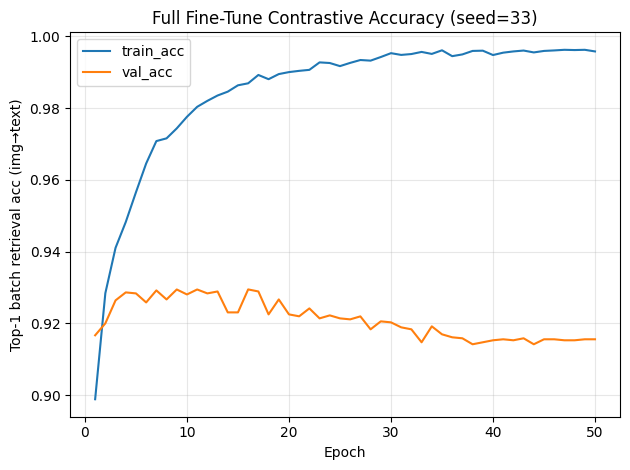


Seed 44 | Staging data

====== Full Fine-Tune (seed=44, lr=1e-06) ======
Seed 44 | Epoch 01/50 | train_loss=0.4059 valid_loss=0.2804 | train_acc=0.9001 valid_acc=0.9199
Seed 44 | Epoch 02/50 | train_loss=0.2470 valid_loss=0.2483 | train_acc=0.9254 valid_acc=0.9283
Seed 44 | Epoch 03/50 | train_loss=0.2044 valid_loss=0.2339 | train_acc=0.9393 valid_acc=0.9302
Seed 44 | Epoch 04/50 | train_loss=0.1726 valid_loss=0.2281 | train_acc=0.9493 valid_acc=0.9299
Seed 44 | Epoch 05/50 | train_loss=0.1499 valid_loss=0.2249 | train_acc=0.9581 valid_acc=0.9327
Seed 44 | Epoch 06/50 | train_loss=0.1330 valid_loss=0.2219 | train_acc=0.9619 valid_acc=0.9327
Seed 44 | Epoch 07/50 | train_loss=0.1177 valid_loss=0.2237 | train_acc=0.9668 valid_acc=0.9302
Seed 44 | Epoch 08/50 | train_loss=0.1069 valid_loss=0.2217 | train_acc=0.9706 valid_acc=0.9291
Seed 44 | Epoch 09/50 | train_loss=0.0948 valid_loss=0.2194 | train_acc=0.9751 valid_acc=0.9313
Seed 44 | Epoch 10/50 | train_loss=0.0875 valid_loss=0.2236 | 

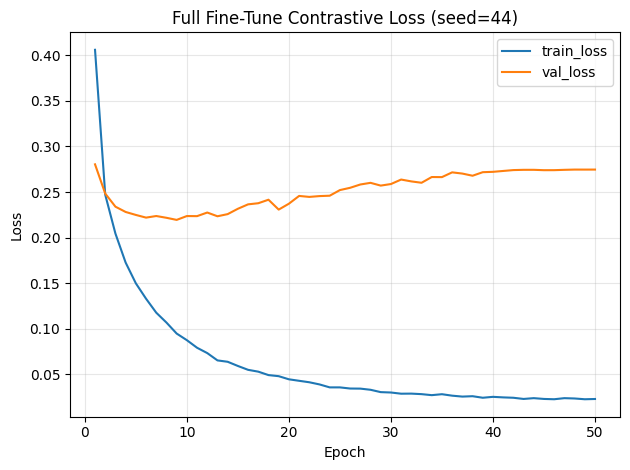

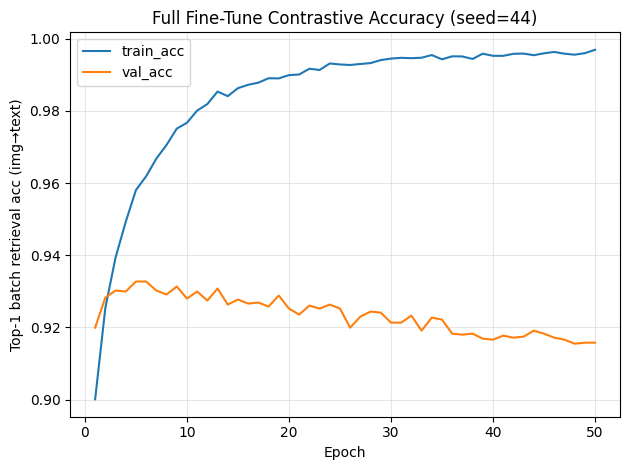


Seed 55 | Staging data

====== Full Fine-Tune (seed=55, lr=1e-06) ======
Seed 55 | Epoch 01/50 | train_loss=0.4010 valid_loss=0.2982 | train_acc=0.8996 valid_acc=0.9091
Seed 55 | Epoch 02/50 | train_loss=0.2461 valid_loss=0.2653 | train_acc=0.9262 valid_acc=0.9172
Seed 55 | Epoch 03/50 | train_loss=0.2035 valid_loss=0.2490 | train_acc=0.9378 valid_acc=0.9222
Seed 55 | Epoch 04/50 | train_loss=0.1661 valid_loss=0.2401 | train_acc=0.9530 valid_acc=0.9228
Seed 55 | Epoch 05/50 | train_loss=0.1462 valid_loss=0.2367 | train_acc=0.9575 valid_acc=0.9255
Seed 55 | Epoch 06/50 | train_loss=0.1331 valid_loss=0.2324 | train_acc=0.9599 valid_acc=0.9266
Seed 55 | Epoch 07/50 | train_loss=0.1177 valid_loss=0.2303 | train_acc=0.9679 valid_acc=0.9261
Seed 55 | Epoch 08/50 | train_loss=0.1060 valid_loss=0.2297 | train_acc=0.9698 valid_acc=0.9300
Seed 55 | Epoch 09/50 | train_loss=0.0946 valid_loss=0.2282 | train_acc=0.9751 valid_acc=0.9286
Seed 55 | Epoch 10/50 | train_loss=0.0843 valid_loss=0.2329 | 

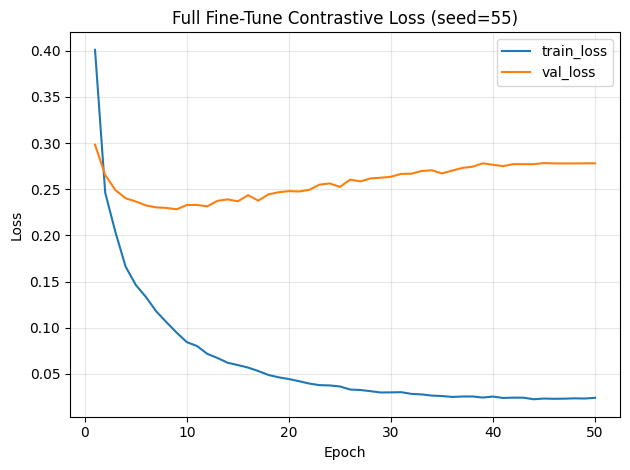

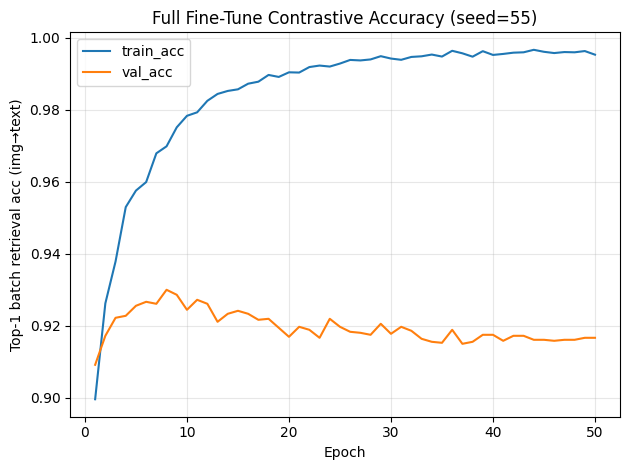


Done. Best checkpoints stored for all seeds:
{11: '/content/drive/MyDrive/Thesis_Data/0111/FullFinetune_results/full_best_seed_11.pt', 22: '/content/drive/MyDrive/Thesis_Data/0111/FullFinetune_results/full_best_seed_22.pt', 33: '/content/drive/MyDrive/Thesis_Data/0111/FullFinetune_results/full_best_seed_33.pt', 44: '/content/drive/MyDrive/Thesis_Data/0111/FullFinetune_results/full_best_seed_44.pt', 55: '/content/drive/MyDrive/Thesis_Data/0111/FullFinetune_results/full_best_seed_55.pt'}


In [ ]:
# ============================================
# Full Fine-Tuning (CLIP) - TRAINING (5 seeds)
# - Data loading matches your LinearProbe style:
#   * copy images from Drive -> /content (local)
#   * build DataFrame with absolute image paths
#   * DataLoader reads local image paths
# - Runs 5 seeds sequentially
# - Saves best checkpoint per seed to Drive
# - Optional: cleans staged folders per seed to save /content space
# Notes:
# - Assumes images are named "<image_id>.jpg" in each split/images/
# - Assumes each split has "{split}_pairs.csv" with columns:
#     image_id, filepath, description
# ============================================

import os
import json
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import clip

# -----------------------------
# Config
# -----------------------------
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
RESULT_DIR = DRIVE_BASE_DIR / "FullFinetune_results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_BASE_DIR = Path("/content")

SEEDS = [11, 22, 33, 44, 55]

BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 1e-6
GRADIENT_ACCUMULATION_STEPS = 4  # Effective batch size = BATCH_SIZE * steps

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_DTYPE = torch.float32

print("device:", DEVICE)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

# -----------------------------
# Utilities (same staging style as LinearProbe)
# -----------------------------
def stage_split_images(seed: int, split: str) -> Path:
    """
    Copy images for a given seed & split from Drive to local /content.
    Expect source: DRIVE_BASE_DIR/seed_{seed}/{split}/images/*.jpg
    Return local dir: /content/seed_{seed}_{split}_images
    """
    src = DRIVE_BASE_DIR / f"seed_{seed}" / split / "images"
    dst = LOCAL_BASE_DIR / f"seed_{seed}_{split}_images"

    if not src.exists():
        raise FileNotFoundError(f"Missing source images: {src}")

    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)
    return dst

def cleanup_staged_images(seed: int):
    """Remove staged dirs to free /content space."""
    for split in ["train", "valid", "test"]:
        d = LOCAL_BASE_DIR / f"seed_{seed}_{split}_images"
        if d.exists():
            shutil.rmtree(d)

def build_pairs_dataframe(seed: int, split: str, image_dir: Path) -> pd.DataFrame:
    """
    Read split pairs CSV:
      DRIVE_BASE_DIR/seed_{seed}/{split}/{split}_pairs.csv
    Must contain columns: image_id, filepath, description
    We create an absolute image path:
      path = image_dir / (image_id + ".jpg")
    Returns df with columns: image_id, path, description
    """
    csv_path = DRIVE_BASE_DIR / f"seed_{seed}" / split / f"{split}_pairs.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing pairs CSV: {csv_path}")

    df = pd.read_csv(csv_path, encoding="utf-8-sig")

    needed = {"image_id", "description"}
    for c in needed:
        if c not in df.columns:
            raise ValueError(f"Pairs CSV missing required column: {c} | file={csv_path}")

    # Build local absolute image path; assumes "<image_id>.jpg"
    df["path"] = df["image_id"].astype(str) + ".jpg"
    df["path"] = df["path"].apply(lambda n: str(image_dir / n))

    out = df[["image_id", "path", "description"]].copy()
    return out

# -----------------------------
# Dataset / Loader
# -----------------------------
class PairDatasetFrame(Dataset):
    """Dataset backed by a DataFrame with absolute image paths."""
    def __init__(self, frame: pd.DataFrame, preprocess):
        self.f = frame.reset_index(drop=True)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.f)

    def __getitem__(self, idx):
        r = self.f.iloc[idx]
        image = Image.open(r["path"]).convert("RGB")
        image = self.preprocess(image)
        text = str(r["description"])
        return image, text

def make_loader(df: pd.DataFrame, preprocess, shuffle: bool):
    return DataLoader(
        PairDatasetFrame(df, preprocess),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=2 if DEVICE == "cuda" else 0,
        pin_memory=(DEVICE == "cuda"),
    )

# -----------------------------
# Loss
# -----------------------------
def clip_contrastive_loss(img_feats: torch.Tensor, txt_feats: torch.Tensor, logit_scale: torch.Tensor):
    """
    CLIP-style InfoNCE with symmetric loss.
    Returns (loss, top1_acc_img_to_text).
    """
    img = img_feats.to(dtype=TORCH_DTYPE)
    txt = txt_feats.to(dtype=TORCH_DTYPE)

    img = img / img.norm(dim=1, keepdim=True)
    txt = txt / txt.norm(dim=1, keepdim=True)

    scale = logit_scale.exp().to(dtype=TORCH_DTYPE)
    logits_per_image = scale * img @ txt.t()
    logits_per_text  = logits_per_image.t()

    targets = torch.arange(img.shape[0], device=img.device)
    loss_i = nn.functional.cross_entropy(logits_per_image, targets)
    loss_t = nn.functional.cross_entropy(logits_per_text,  targets)
    loss = (loss_i + loss_t) / 2

    preds = logits_per_image.argmax(dim=1)
    acc = (preds == targets).float().mean().item()
    return loss, acc

# -----------------------------
# Train one seed
# -----------------------------
def run_one_seed(seed: int) -> str:
    print(f"\n===============================")
    print(f"Seed {seed} | Staging data")
    print(f"===============================")

    train_img_dir = stage_split_images(seed, "train")
    valid_img_dir = stage_split_images(seed, "valid")
    test_img_dir  = stage_split_images(seed, "test")  # not used in training, but keeps structure consistent

    train_df = build_pairs_dataframe(seed, "train", train_img_dir)
    valid_df = build_pairs_dataframe(seed, "valid", valid_img_dir)

    # Load CLIP and force FP32 (avoid Half/Float mismatch)
    clip_model, preprocess = clip.load("ViT-B/32", device=DEVICE, jit=False)
    clip_model = clip_model.float()

    # Make ALL parameters trainable for full fine-tuning
    for p in clip_model.parameters():
        p.requires_grad = True

    # Learnable temperature like CLIP
    logit_scale = nn.Parameter(torch.log(torch.tensor(1/0.07, dtype=TORCH_DTYPE, device=DEVICE)))

    # Optimizer and scheduler
    optimizer = torch.optim.AdamW(list(clip_model.parameters()) + [logit_scale], lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    train_dl = make_loader(train_df, preprocess, shuffle=True)
    valid_dl = make_loader(valid_df, preprocess, shuffle=False)

    history = defaultdict(list)
    best_valid = float("-inf")
    best_state = None

    print(f"\n====== Full Fine-Tune (seed={seed}, lr={LEARNING_RATE}) ======")

    for epoch in range(1, EPOCHS + 1):
        # -------- Train --------
        clip_model.train()

        tr_loss_sum, tr_acc_sum, tr_batches = 0.0, 0.0, 0
        optimizer.zero_grad(set_to_none=True)

        for batch_idx, (images, texts) in enumerate(train_dl):
            images = images.to(DEVICE, non_blocking=True).to(dtype=TORCH_DTYPE)
            tokens = clip.tokenize(list(texts), truncate=True).to(DEVICE, non_blocking=True)

            img_f = clip_model.encode_image(images).to(dtype=TORCH_DTYPE)
            txt_f = clip_model.encode_text(tokens).to(dtype=TORCH_DTYPE)

            loss_c, acc_c = clip_contrastive_loss(img_f, txt_f, logit_scale)

            # Scale loss for gradient accumulation
            loss_scaled = loss_c / GRADIENT_ACCUMULATION_STEPS
            loss_scaled.backward()

            if (batch_idx + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

            tr_loss_sum += float(loss_c.item())
            tr_acc_sum  += float(acc_c)
            tr_batches  += 1

        # Step any remaining accumulated gradients
        if len(train_dl) % GRADIENT_ACCUMULATION_STEPS != 0:
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        tr_loss = tr_loss_sum / max(1, tr_batches)
        tr_acc  = tr_acc_sum  / max(1, tr_batches)

        # -------- Valid --------
        clip_model.eval()

        va_loss_sum, va_acc_sum, va_batches = 0.0, 0.0, 0
        with torch.no_grad():
            for images, texts in valid_dl:
                images = images.to(DEVICE, non_blocking=True).to(dtype=TORCH_DTYPE)
                tokens = clip.tokenize(list(texts), truncate=True).to(DEVICE, non_blocking=True)

                img_f = clip_model.encode_image(images).to(dtype=TORCH_DTYPE)
                txt_f = clip_model.encode_text(tokens).to(dtype=TORCH_DTYPE)

                loss_c, acc_c = clip_contrastive_loss(img_f, txt_f, logit_scale)

                va_loss_sum += float(loss_c.item())
                va_acc_sum  += float(acc_c)
                va_batches  += 1

        va_loss = va_loss_sum / max(1, va_batches)
        va_acc  = va_acc_sum  / max(1, va_batches)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        # Save best by validation accuracy
        if va_acc > best_valid:
            best_valid = va_acc
            best_state = {
                "seed": seed,
                "epoch": epoch,
                "model_state_dict": {k: v.detach().cpu() for k, v in clip_model.state_dict().items()},
                "logit_scale": float(logit_scale.detach().cpu().exp().item()),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": float(va_acc),
                "val_loss": float(va_loss),
                "lr": float(LEARNING_RATE),
                "epochs": int(EPOCHS),
                "grad_accum_steps": int(GRADIENT_ACCUMULATION_STEPS),
                "model": "ViT-B/32",
            }

        print(
            f"Seed {seed} | Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={tr_loss:.4f} valid_loss={va_loss:.4f} | "
            f"train_acc={tr_acc:.4f} valid_acc={va_acc:.4f}"
        )

        scheduler.step()

    # Save best checkpoint
    best_path = RESULT_DIR / f"full_best_seed_{seed}.pt"
    torch.save(best_state, best_path)
    print("Saved best model:", best_path)

    # Plot curves (show only)
    epochs_axis = list(range(1, EPOCHS + 1))

    plt.figure()
    plt.plot(epochs_axis, history["train_loss"], label="train_loss")
    plt.plot(epochs_axis, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"Full Fine-Tune Contrastive Loss (seed={seed})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    plt.figure()
    plt.plot(epochs_axis, history["train_acc"], label="train_acc")
    plt.plot(epochs_axis, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch"); plt.ylabel("Top-1 batch retrieval acc (img→text)")
    plt.title(f"Full Fine-Tune Contrastive Accuracy (seed={seed})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    # Cleanup staged images (optional)
    cleanup_staged_images(seed)

    return str(best_path)

# -----------------------------
# Run all seeds
# -----------------------------
best_paths = {}
for seed in SEEDS:
    best_paths[seed] = run_one_seed(seed)

print("\nDone. Best checkpoints stored for all seeds:")
print(best_paths)

In [ ]:
import os
import json
import ast
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import torch
import torch.nn as nn
from PIL import Image
from tqdm import tqdm
import clip

# -----------------------------
# Config
# -----------------------------
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
RESULT_DIR = DRIVE_BASE_DIR / "FullFinetune_results"

LOCAL_BASE_DIR = Path("/content")

SEEDS = [11, 22, 33, 44, 55]

LABEL_LIB_PATH = DRIVE_BASE_DIR / "label_library.json"

single_attrs = ["category", "sub_category"]
multi_attrs  = ["color", "material", "pattern"]

# Inference policy
TOPK = {"color": 3, "material": 3, "pattern": 2}
THRESH = {"color": 0.3, "material": 0.3, "pattern": 0.5}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_DTYPE = torch.float32

print("device:", DEVICE)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

# -----------------------------
# Utilities (same staging style)
# -----------------------------
def stage_split_images(seed: int, split: str) -> Path:
    src = DRIVE_BASE_DIR / f"seed_{seed}" / split / "images"
    dst = LOCAL_BASE_DIR / f"seed_{seed}_{split}_images"

    if not src.exists():
        raise FileNotFoundError(f"Missing source images: {src}")

    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)
    return dst

def cleanup_staged_images(seed: int):
    for split in ["train", "valid", "test"]:
        d = LOCAL_BASE_DIR / f"seed_{seed}_{split}_images"
        if d.exists():
            shutil.rmtree(d)

def parse_list_cell(x):
    if isinstance(x, list):
        return [str(t).strip() for t in x]
    if pd.isna(x):
        return []
    s = str(x).strip()
    if not s:
        return []
    # try python literal list
    try:
        val = ast.literal_eval(s)
        if isinstance(val, list):
            return [str(t).strip() for t in val]
    except Exception:
        pass
    # try JSON list
    try:
        val = json.loads(s)
        if isinstance(val, list):
            return [str(t).strip() for t in val]
    except Exception:
        pass
    # fallback
    if "|" in s:
        return [t.strip() for t in s.split("|") if t.strip()]
    return [t.strip() for t in s.split(",") if t.strip()]

def is_missing(x):
    if pd.isna(x):
        return True
    if isinstance(x, str) and x.strip() == "":
        return True
    return False

def relaxed_match(a, b):
    return 1.0 if (set(a) & set(b)) else 0.0

def mean_std_str(xs):
    xs = [x for x in xs if x is not None and not (isinstance(x, float) and np.isnan(x))]
    if len(xs) == 0:
        return "-"
    mu = float(np.mean(xs))
    sd = float(np.std(xs, ddof=1)) if len(xs) > 1 else 0.0
    return f"{mu:.3f} ± {sd:.3f}"

# -----------------------------
# Load label library + prompt templates
# -----------------------------
if not LABEL_LIB_PATH.exists():
    raise FileNotFoundError(f"label_library.json not found: {LABEL_LIB_PATH}")

with LABEL_LIB_PATH.open("r", encoding="utf-8-sig") as f:
    label_library: Dict[str, List[str]] = json.load(f)

prompts: Dict[str, List[str]] = {
    "category":     ["a photo of a {label} item", "a fashion photo of {label}"],
    "sub_category": ["a {label}", "a {label} garment"],
    "color":        ["{label} color", "a {label} colored item"],
    "material":     ["made of {label}", "a {label} material garment"],
    "pattern":      ["{label} pattern", "a {label} print"],
}

# -----------------------------
# CLIP model (will load per seed checkpoint into this)
# -----------------------------
clip_model, preprocess = clip.load("ViT-B/32", device=DEVICE, jit=False)
clip_model.eval()
clip_model = clip_model.float()

@torch.no_grad()
def encode_texts(texts: List[str]) -> torch.Tensor:
    outs = []
    bs = 128
    for i in range(0, len(texts), bs):
        toks = clip.tokenize(texts[i:i+bs], truncate=True).to(DEVICE)
        txt = clip_model.encode_text(toks).to(dtype=TORCH_DTYPE)
        txt = txt / txt.norm(dim=1, keepdim=True)
        outs.append(txt)
    if not outs:
        D = clip_model.text_projection.shape[1]
        return torch.empty(0, D, device=DEVICE, dtype=TORCH_DTYPE)
    return torch.cat(outs, dim=0)

def build_text_bank() -> Tuple[torch.Tensor, List[Tuple[str, str]]]:
    texts, meta = [], []
    for dim, labels in label_library.items():
        if dim not in prompts:
            continue
        for lab in labels:
            for tpl in prompts[dim]:
                texts.append(tpl.format(label=lab))
                meta.append((dim, lab))
    embeds = encode_texts(texts)
    return embeds, meta

@torch.no_grad()
def infer_image(image_path: str, text_bank: torch.Tensor, text_meta: List[Tuple[str, str]]) -> Dict:
    img = preprocess(Image.open(image_path).convert("RGB")).unsqueeze(0).to(DEVICE).to(dtype=TORCH_DTYPE)
    img_f = clip_model.encode_image(img).to(dtype=TORCH_DTYPE)
    img_f = img_f / img_f.norm(dim=1, keepdim=True)

    sims = (img_f @ text_bank.t()).squeeze(0).tolist()

    aggregated: Dict[str, Dict[str, float]] = {}
    for i, (dim, lab) in enumerate(text_meta):
        sc = float(sims[i])
        aggregated.setdefault(dim, {})
        if lab not in aggregated[dim] or sc > aggregated[dim][lab]:
            aggregated[dim][lab] = sc

    out = {"category": "", "sub_category": "", "color": [], "material": [], "pattern": []}

    for dim in ["category", "sub_category"]:
        if dim in aggregated and aggregated[dim]:
            out[dim] = max(aggregated[dim].items(), key=lambda x: x[1])[0]

    for dim in ["color", "material", "pattern"]:
        if dim in aggregated and aggregated[dim]:
            items = sorted(aggregated[dim].items(), key=lambda x: x[1], reverse=True)
            passed = [lab for lab, sc in items if sc >= THRESH[dim]]
            if not passed and items:
                passed = [items[0][0]]
            out[dim] = passed[:TOPK[dim]]

    return out

# -----------------------------
# Semantic similarity (same style as your LinearProbe eval)
# -----------------------------
@torch.no_grad()
def embed_text_batch(texts: List[str]) -> torch.Tensor:
    toks = clip.tokenize(texts, truncate=True).to(DEVICE)
    feats = clip_model.encode_text(toks).float()
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats

_embed_cache = {}
def get_text_embed(label: str):
    key = str(label).strip().lower()
    if key == "":
        return None
    if key not in _embed_cache:
        _embed_cache[key] = embed_text_batch([key])
    return _embed_cache[key]

def semantic_sim_single(gt_label, pred_label):
    a = get_text_embed(gt_label)
    b = get_text_embed(pred_label)
    if a is None or b is None:
        return np.nan
    return float((a @ b.T).item())

def semantic_sim_multilabel(gt_labels, pred_labels):
    gt = [g for g in gt_labels if str(g).strip()]
    pr = [p for p in pred_labels if str(p).strip()]
    if len(gt) == 0:
        return np.nan
    if len(pr) == 0:
        return 0.0
    gt_feats = torch.cat([get_text_embed(g) for g in gt if get_text_embed(g) is not None], dim=0)
    pr_feats = torch.cat([get_text_embed(p) for p in pr if get_text_embed(p) is not None], dim=0)
    if gt_feats.numel() == 0:
        return np.nan
    if pr_feats.numel() == 0:
        return 0.0
    sims = gt_feats @ pr_feats.T
    return float(sims.max(dim=1).values.mean().item())

# -----------------------------
# Per-seed evaluation helper
# -----------------------------
def evaluate_one_seed(gt_csv: Path, pred_csv: Path):
    gt = pd.read_csv(gt_csv, encoding="utf-8-sig")
    pred = pd.read_csv(pred_csv, encoding="utf-8-sig")

    needed = ["image_id"] + single_attrs + multi_attrs
    for c in needed:
        if c not in gt.columns:
            raise ValueError(f"GT missing column: {c}")
        if c not in pred.columns:
            raise ValueError(f"PRED missing column: {c}")

    df = gt.merge(pred, on="image_id", suffixes=("_gt", "_pred"), how="inner")

    report = {"single": {}, "multi": {}}

    # Single-label
    for attr in single_attrs:
        gcol, pcol = f"{attr}_gt", f"{attr}_pred"
        mask = ~df[gcol].apply(is_missing)
        if mask.sum() == 0:
            continue

        y_true = df.loc[mask, gcol].astype(str).tolist()
        y_pred = df.loc[mask, pcol].astype(str).tolist()

        acc = accuracy_score(y_true, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )

        sems = [semantic_sim_single(t, p) for t, p in zip(y_true, y_pred)]
        sems = [s for s in sems if not np.isnan(s)]
        sem_mean = float(np.mean(sems)) if sems else float("nan")

        report["single"][attr] = {
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "semantic_similarity_clip": float(sem_mean),
        }

    # Multi-label
    for attr in multi_attrs:
        gcol, pcol = f"{attr}_gt", f"{attr}_pred"
        gt_lists = df[gcol].apply(parse_list_cell)
        pr_lists = df[pcol].apply(parse_list_cell)

        mask = gt_lists.apply(lambda x: len(x) > 0)
        if mask.sum() == 0:
            continue

        gtv = gt_lists[mask].tolist()
        prv = pr_lists[mask].tolist()

        relaxed = float(np.mean([relaxed_match(g, p) for g, p in zip(gtv, prv)]))
        sems = [semantic_sim_multilabel(g, p) for g, p in zip(gtv, prv)]
        sems = [s for s in sems if not np.isnan(s)]
        sem = float(np.mean(sems)) if sems else float("nan")

        report["multi"][attr] = {
            "relaxed_match_acc": relaxed,
            "semantic_similarity_clip": sem,
        }

    return report

# -----------------------------
# Run inference + evaluation for all seeds
# -----------------------------
all_reports = {}

for seed in SEEDS:
    print(f"\n===============================")
    print(f"Seed {seed} | Inference + Evaluation")
    print(f"===============================")

    # Stage test images to local
    test_img_dir = stage_split_images(seed, "test")

    # Load best checkpoint for this seed
    ckpt_path = RESULT_DIR / f"full_best_seed_{seed}.pt"
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location="cpu")
    clip_model.load_state_dict(ckpt["model_state_dict"], strict=True)
    clip_model = clip_model.float().to(DEVICE).eval()

    # Clear embedding cache per seed (optional)
    _embed_cache.clear()

    # Build text bank under the fine-tuned model
    text_bank, text_meta = build_text_bank()
    if text_bank.numel() == 0:
        raise ValueError("Empty text bank. Check label_library.json and prompts templates.")

    # Read GT test.csv (for image_id list) from Drive
    gt_csv = DRIVE_BASE_DIR / f"seed_{seed}" / "test" / "test.csv"
    gt_df = pd.read_csv(gt_csv, encoding="utf-8-sig")
    if "image_id" not in gt_df.columns:
        raise ValueError(f"test.csv missing image_id: {gt_csv}")

    # Inference loop
    pred_rows = []
    for image_id in tqdm(gt_df["image_id"].astype(str).tolist(), desc=f"predict(seed={seed})"):
        img_path = str(Path(test_img_dir) / f"{image_id}.jpg")
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Missing staged image: {img_path}")

        out = infer_image(img_path, text_bank, text_meta)

        pred_rows.append({
            "image_id": image_id,
            "category": out["category"],
            "sub_category": out["sub_category"],
            "color": json.dumps(out["color"], ensure_ascii=False),
            "material": json.dumps(out["material"], ensure_ascii=False),
            "pattern": json.dumps(out["pattern"], ensure_ascii=False),
        })

    pred_df = pd.DataFrame(pred_rows)

    pred_csv_path = RESULT_DIR / f"full_seed_{seed}_pred.csv"
    pred_df.to_csv(pred_csv_path, index=False, encoding="utf-8")
    print("Saved predictions:", pred_csv_path)

    # Evaluate
    rep = evaluate_one_seed(gt_csv, pred_csv_path)
    all_reports[seed] = rep

    print(f"\n===== Seed {seed} Results (Full Fine-Tune) =====")
    for attr in single_attrs:
        if attr in rep["single"]:
            m = rep["single"][attr]
            print(f"{attr}: acc={m['accuracy']:.4f}, prec={m['precision']:.4f}, rec={m['recall']:.4f}, f1={m['f1']:.4f}, sem_sim={m['semantic_similarity_clip']:.4f}")
    for attr in multi_attrs:
        if attr in rep["multi"]:
            m = rep["multi"][attr]
            print(f"{attr}: relaxed={m['relaxed_match_acc']:.4f}, sem_sim={m['semantic_similarity_clip']:.4f}")

    # Save per-seed eval JSON
    seed_eval_path = RESULT_DIR / f"full_seed_{seed}_eval.json"
    with seed_eval_path.open("w", encoding="utf-8") as f:
        json.dump(rep, f, ensure_ascii=False, indent=2)
    print(f"Saved seed eval: {seed_eval_path}")

    # Cleanup staged images (optional)
    cleanup_staged_images(seed)

# -----------------------------
# Final mean ± std summary table
# -----------------------------
rows = []

for attr in single_attrs:
    vals_acc, vals_prec, vals_rec, vals_f1, vals_sem = [], [], [], [], []
    for seed in SEEDS:
        m = all_reports[seed]["single"].get(attr, {})
        vals_acc.append(m.get("accuracy", np.nan))
        vals_prec.append(m.get("precision", np.nan))
        vals_rec.append(m.get("recall", np.nan))
        vals_f1.append(m.get("f1", np.nan))
        vals_sem.append(m.get("semantic_similarity_clip", np.nan))

    rows.append({
        "Method": "FullFineTune",
        "Attribute Type": "Single-Label",
        "Attributes": "Category" if attr == "category" else "Subcategory",
        "Accuracy": mean_std_str(vals_acc),
        "Precision": mean_std_str(vals_prec),
        "Recall": mean_std_str(vals_rec),
        "F1": mean_std_str(vals_f1),
        "Relaxed Match": "-",
        "Semantic Similarity": mean_std_str(vals_sem),
    })

for attr in multi_attrs:
    vals_relaxed, vals_sem = [], []
    for seed in SEEDS:
        m = all_reports[seed]["multi"].get(attr, {})
        vals_relaxed.append(m.get("relaxed_match_acc", np.nan))
        vals_sem.append(m.get("semantic_similarity_clip", np.nan))

    rows.append({
        "Method": "FullFineTune",
        "Attribute Type": "Multi-Label",
        "Attributes": attr.capitalize(),
        "Accuracy": "-",
        "Precision": "-",
        "Recall": "-",
        "F1": "-",
        "Relaxed Match": mean_std_str(vals_relaxed),
        "Semantic Similarity": mean_std_str(vals_sem),
    })

df_summary = pd.DataFrame(rows, columns=[
    "Method", "Attribute Type", "Attributes",
    "Accuracy", "Precision", "Recall", "F1",
    "Relaxed Match", "Semantic Similarity"
])

print("\n===== Full Fine-Tune Summary (mean ± std over 5 seeds) =====")
print(df_summary.to_string(index=False))

device: cuda
gpu: NVIDIA A100-SXM4-40GB

Seed 11 | Inference + Evaluation


predict(seed=11): 100%|██████████| 3599/3599 [01:27<00:00, 41.32it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/FullFinetune_results/full_seed_11_pred.csv

===== Seed 11 Results (Full Fine-Tune) =====
category: acc=0.8108, prec=0.7211, rec=0.8069, f1=0.7138, sem_sim=0.9382
sub_category: acc=0.3645, prec=0.2683, rec=0.3381, f1=0.2277, sem_sim=0.8094
color: relaxed=0.0122, sem_sim=0.6280
material: relaxed=0.0097, sem_sim=0.5869
pattern: relaxed=0.0044, sem_sim=0.4541
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/FullFinetune_results/full_seed_11_eval.json

Seed 22 | Inference + Evaluation


predict(seed=22): 100%|██████████| 3599/3599 [01:28<00:00, 40.89it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/FullFinetune_results/full_seed_22_pred.csv

===== Seed 22 Results (Full Fine-Tune) =====
category: acc=0.8136, prec=0.7231, rec=0.7904, f1=0.6996, sem_sim=0.9393
sub_category: acc=0.3576, prec=0.2807, rec=0.3369, f1=0.2370, sem_sim=0.8046
color: relaxed=0.0097, sem_sim=0.6295
material: relaxed=0.0125, sem_sim=0.5792
pattern: relaxed=0.0061, sem_sim=0.4538
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/FullFinetune_results/full_seed_22_eval.json

Seed 33 | Inference + Evaluation


...

Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/FullFinetune_results/full_seed_33_pred.csv

===== Seed 33 Results (Full Fine-Tune) =====
category: acc=0.7316, prec=0.6435, rec=0.7474, f1=0.6288, sem_sim=0.9083
sub_category: acc=0.3220, prec=0.2787, rec=0.3293, f1=0.2198, sem_sim=0.7730
color: relaxed=0.0111, sem_sim=0.6006
material: relaxed=0.0092, sem_sim=0.5483
pattern: relaxed=0.0047, sem_sim=0.4262
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/FullFinetune_results/full_seed_33_eval.json

Seed 44 | Inference + Evaluation


predict(seed=44): 100%|██████████| 3599/3599 [01:28<00:00, 40.69it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/FullFinetune_results/full_seed_44_pred.csv

===== Seed 44 Results (Full Fine-Tune) =====
category: acc=0.8516, prec=0.7560, rec=0.8216, f1=0.7438, sem_sim=0.9517
sub_category: acc=0.3559, prec=0.2809, rec=0.3665, f1=0.2483, sem_sim=0.8200
color: relaxed=0.0078, sem_sim=0.6454
material: relaxed=0.0128, sem_sim=0.5971
pattern: relaxed=0.0033, sem_sim=0.4656
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/FullFinetune_results/full_seed_44_eval.json

Seed 55 | Inference + Evaluation


predict(seed=55): 100%|██████████| 3599/3599 [01:28<00:00, 40.58it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/FullFinetune_results/full_seed_55_pred.csv

===== Seed 55 Results (Full Fine-Tune) =====
category: acc=0.8205, prec=0.7071, rec=0.7981, f1=0.7083, sem_sim=0.9395
sub_category: acc=0.3384, prec=0.2842, rec=0.3375, f1=0.2294, sem_sim=0.7973
color: relaxed=0.0108, sem_sim=0.6160
material: relaxed=0.0136, sem_sim=0.5713
pattern: relaxed=0.0031, sem_sim=0.4373
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/FullFinetune_results/full_seed_55_eval.json

===== Full Fine-Tune Summary (mean ± std over 5 seeds) =====
      Method Attribute Type  Attributes      Accuracy     Precision        Recall            F1 Relaxed Match Semantic Similarity
FullFineTune   Single-Label    Category 0.806 ± 0.044 0.710 ± 0.041 0.793 ± 0.028 0.699 ± 0.043             -       0.935 ± 0.016
FullFineTune   Single-Label Subcategory 0.348 ± 0.017 0.279 ± 0.006 0.342 ± 0.014 0.232 ± 0.011             -       0.801 ± 0.018
FullFineTune    Multi-Label   

### Two-Stage Linear Probe

In [ ]:
# ============================================================
# Cell 0 — Install + Runtime check (run once)
# ============================================================
import os
import json
import math
import random
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

import clip
from datasets import load_dataset

# ============================================================
# Cell 1 — Config
# ============================================================
DATASET_ID = "fnauman/fashion-second-hand-front-only-rgb"
SPLIT_NAME = "train"

# Five seeds
SEEDS = [11, 22, 33, 44, 55]

# Where to store results
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
OUTPUT_ROOT = DRIVE_BASE_DIR / "TwoStage_LP_results"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

MAX_PER_COLOR_STAGE1 = 200
MIN_SAMPLES_PER_COLOR = 20

# Stage 1 hyperparams (visual fine-tune)
STAGE1_BATCH_SIZE = 32
STAGE1_EPOCHS = 150
STAGE1_LR = 5e-6
STAGE1_WEIGHT_DECAY = 0.02
STAGE1_GRAD_CLIP = 1.0

# Stage 2 hyperparams (linear probe)
STAGE2_BATCH_SIZE = 64
STAGE2_EPOCHS = 100
STAGE2_LR = 5e-4
STAGE2_WEIGHT_DECAY = 0.02

# Data split ratios for the main dataset (Stage 2)
TRAIN_RATIO = 0.80
VALID_RATIO = 0.10
TEST_RATIO  = 0.10

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_DTYPE = torch.float32


# ============================================================
# Load HF dataset + normalize colors + keep image_name
# ============================================================
ds = load_dataset(DATASET_ID, split=SPLIT_NAME)

cols = set(ds.column_names)
if "image" not in cols:
    raise ValueError(f"Dataset missing 'image' column. Found columns: {ds.column_names}")
if "colors" not in cols:
    raise ValueError(f"Dataset missing 'colors' column. Found columns: {ds.column_names}")

def _normalize_color_token(x: str) -> str:
    return str(x).strip().lower()

def _extract_image_name(img: Image.Image, fallback: str) -> str:
    for attr in ["filename", "path"]:
        v = getattr(img, attr, None)
        if isinstance(v, str) and v.strip():
            base = os.path.basename(v)
            return base if base else fallback
    if isinstance(getattr(img, "info", None), dict):
        for k in ["filename", "path"]:
            v = img.info.get(k)
            if isinstance(v, str) and v.strip():
                base = os.path.basename(v)
                return base if base else fallback
    return fallback

records = []
for i in tqdm(range(len(ds)), desc="Materializing metadata"):
    ex = ds[i]
    img = ex["image"]
    color_list = ex["colors"]

    # Ensure list
    if color_list is None:
        color_list = []
    if not isinstance(color_list, list):
        color_list = [color_list]

    # Normalize all colors, do NOT restrict to a predefined list
    color_list = [_normalize_color_token(c) for c in color_list if str(c).strip()]
    color_list = [c for c in color_list if c]  # drop empty

    # Primary label for single-label training
    primary_color = color_list[0] if len(color_list) > 0 else ""

    image_name = _extract_image_name(img, fallback=f"hf_{i}.png")
    image_id = os.path.splitext(image_name)[0]

    records.append({
        "hf_index": i,
        "image_id": image_id,
        "image_name": image_name,
        "colors": color_list,
        "primary_color": primary_color,
    })

meta = pd.DataFrame(records)

# Keep only rows with at least one color label
meta = meta[meta["primary_color"].astype(str).str.len() > 0].reset_index(drop=True)

# Optional: drop extremely rare colors to stabilize training
if MIN_SAMPLES_PER_COLOR > 1:
    vc = meta["primary_color"].value_counts()
    keep = vc[vc >= MIN_SAMPLES_PER_COLOR].index.tolist()
    meta = meta[meta["primary_color"].isin(keep)].reset_index(drop=True)

# Build the full color class set dynamically
ALL_COLORS = sorted(meta["primary_color"].unique().tolist())

print("Usable rows (has color labels):", len(meta))
print("Num color classes:", len(ALL_COLORS))
print("Top-20 colors by frequency:")
print(meta["primary_color"].value_counts().head(20))
print(meta.head())


# ============================================================
# Utilities: splits, datasets, loaders
# ============================================================
def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def stratified_split_df(df: pd.DataFrame, label_col: str, valid_ratio: float, seed: int):
    """
    Stratified split by label_col: returns (train_df, valid_df)
    """
    rng = np.random.RandomState(seed)
    train_parts, valid_parts = [], []
    for lab, grp in df.groupby(label_col):
        idx = np.arange(len(grp))
        rng.shuffle(idx)
        v = int(round(len(idx) * valid_ratio))
        valid_idx, train_idx = idx[:v], idx[v:]
        g = grp.reset_index(drop=True)
        valid_parts.append(g.loc[valid_idx])
        train_parts.append(g.loc[train_idx])
    return pd.concat(train_parts, ignore_index=True), pd.concat(valid_parts, ignore_index=True)

def split_train_valid_test(df: pd.DataFrame, seed: int):
    """
    Random split (not stratified) for stage-2 pipeline.
    Ratios must remain 80/10/10 per your constraint.
    """
    rng = np.random.RandomState(seed)
    idx = np.arange(len(df))
    rng.shuffle(idx)
    n = len(df)
    n_train = int(round(TRAIN_RATIO * n))
    n_valid = int(round(VALID_RATIO * n))
    n_test  = n - n_train - n_valid
    tr = df.iloc[idx[:n_train]].reset_index(drop=True)
    va = df.iloc[idx[n_train:n_train+n_valid]].reset_index(drop=True)
    te = df.iloc[idx[n_train+n_valid:]].reset_index(drop=True)
    return tr, va, te

# CLIP load
clip_model, preprocess = clip.load("ViT-B/32", device=DEVICE, jit=False)
clip_model = clip_model.float()
clip_model.eval()

@torch.no_grad()
def encode_image_batch(model, images_tensor: torch.Tensor) -> torch.Tensor:
    feats = model.encode_image(images_tensor.to(DEVICE))
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.float()

class HFColorDataset(torch.utils.data.Dataset):
    """
    Loads images from HF dataset by hf_index; returns:
      image_tensor, label_index, image_id
    """
    def __init__(self, hf_ds, frame: pd.DataFrame, class_to_idx: Dict[str, int]):
        self.ds = hf_ds
        self.f = frame.reset_index(drop=True)
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.f)

    def __getitem__(self, i):
        r = self.f.iloc[i]
        ex = self.ds[int(r["hf_index"])]
        img = ex["image"].convert("RGB")
        x = preprocess(img)  # tensor float
        y = self.class_to_idx[str(r["primary_color"])]
        return x, torch.tensor(y, dtype=torch.long), str(r["image_id"])

def make_loader(ds, batch_size: int, shuffle: bool):
    return torch.utils.data.DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=2 if torch.cuda.is_available() else 0,
        pin_memory=torch.cuda.is_available(),
        drop_last=False
    )

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00013.parquet:   0%|          | 0.00/374M [00:00<?, ?B/s]

data/train-00001-of-00013.parquet:   0%|          | 0.00/173M [00:00<?, ?B/s]

data/train-00002-of-00013.parquet:   0%|          | 0.00/202M [00:00<?, ?B/s]

data/train-00003-of-00013.parquet:   0%|          | 0.00/200M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/256M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28248 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3390 [00:00<?, ? examples/s]

Materializing metadata: 100%|██████████| 28248/28248 [01:51<00:00, 254.05it/s]


Usable rows (has color labels): 22662
Num color classes: 79
Top-20 colors by frequency:
primary_color
['black']             4011
['blue']              3317
['white']             2139
['grey']              1502
['beige']             1238
['pink']              1191
['green']              922
['black', 'white']     865
['red']                773
['blue', 'white']      768
['brown']              516
['white', 'black']     457
['purple']             423
['white', 'blue']      394
['multicolor']         357
['yellow']             291
['orange']             254
['black', 'grey']      186
['grey', 'black']      143
['red', 'white']       122
Name: count, dtype: int64
   hf_index image_id image_name               colors      primary_color
0         0     hf_0   hf_0.png           [['pink']]           ['pink']
1         1     hf_1   hf_1.png  [['blue', 'white']]  ['blue', 'white']
2         2     hf_2   hf_2.png          [['black']]          ['black']
3         3     hf_3   hf_3.png            [

In [ ]:
# Cell (Stage 1) — Color Fine-tune (TARGET_COLORS) for 5 seeds
import ast
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import clip

# -----------------------------
# Stage-1 settings
# -----------------------------
TARGET_COLORS = ["black", "blue", "denim", "floral", "gold", "grey", "pink", "red", "white", "yellow"]

COLOR_ALIASES = {
    "gray": "grey",
    "silver": "grey",
    "navy": "blue",
    "flower": "floral",
    "flowers": "floral",
    "jean": "denim",
    "jeans": "denim",
    "golden": "gold",
}

STAGE1_DIR = OUTPUT_ROOT / "stage1_color_finetune"
STAGE1_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Helper: parse list-like string and pick first label
# -----------------------------
def normalize_primary_color_cell(x) -> str:
    """
    Converts values like:
      "['black']" -> "black"
      "['black','white']" -> "black"
      [] / "[]" / NaN -> ""
      "black" -> "black"
    """
    if pd.isna(x):
        return ""
    if isinstance(x, list):
        toks = x
    else:
        s = str(x).strip()
        if not s:
            return ""
        # Try parse python literal list: "['black']"
        try:
            v = ast.literal_eval(s)
            toks = v if isinstance(v, list) else [v]
        except Exception:
            # Fallback: treat it as a single token
            toks = [s]

    toks = [str(t).strip().lower() for t in toks if str(t).strip()]
    if not toks:
        return ""
    c = toks[0]
    c = COLOR_ALIASES.get(c, c)
    return c

# -----------------------------
# Build Stage-1 meta subset
# -----------------------------
meta_s1 = meta.copy()

# IMPORTANT: your meta["primary_color"] is list-string like "['black']"
meta_s1["primary_color"] = meta_s1["primary_color"].apply(normalize_primary_color_cell)

# Drop empty
meta_s1 = meta_s1[meta_s1["primary_color"].astype(str).str.len() > 0].reset_index(drop=True)

# Keep only target colors (skip non-matching)
meta_s1 = meta_s1[meta_s1["primary_color"].isin(TARGET_COLORS)].reset_index(drop=True)

# Enforce min samples per class (optional)
if MIN_SAMPLES_PER_COLOR > 1 and len(meta_s1) > 0:
    vc = meta_s1["primary_color"].value_counts()
    keep = vc[vc >= MIN_SAMPLES_PER_COLOR].index.tolist()
    meta_s1 = meta_s1[meta_s1["primary_color"].isin(keep)].reset_index(drop=True)

print("\nStage-1 remaining label counts (after parsing + target filter + min-count):")
print(meta_s1["primary_color"].value_counts())

if len(meta_s1) == 0:
    raise ValueError(
        "meta_s1 is empty after normalization + filtering.\n"
        "This usually means TARGET_COLORS do not exist in the dataset after parsing.\n"
        "Check meta_s1['primary_color'].value_counts() before filtering if needed."
    )

# Optional cap per class
if MAX_PER_COLOR_STAGE1 is not None and MAX_PER_COLOR_STAGE1 > 0:
    parts = []
    for c in TARGET_COLORS:
        grp = meta_s1[meta_s1["primary_color"] == c]
        if len(grp) == 0:
            continue
        parts.append(grp.sample(n=min(len(grp), MAX_PER_COLOR_STAGE1), random_state=0))
    if len(parts) == 0:
        raise ValueError("No target colors survived filtering. Cannot sample per class.")
    meta_s1 = pd.concat(parts, ignore_index=True)

# Final class list (only those that exist after filtering)
stage1_classes = sorted(meta_s1["primary_color"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(stage1_classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

print("\nStage-1 classes actually used:", stage1_classes)
print("Stage-1 usable rows:", len(meta_s1))

# -----------------------------
# Stage-1 training helpers
# -----------------------------
def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def train_one_epoch_stage1(model, head, loader, optimizer, grad_clip: float):
    model.train()
    head.train()

    ce = nn.CrossEntropyLoss()
    total_loss = 0.0
    correct = 0
    count = 0

    for images, y, _ids in tqdm(loader, desc="stage1/train", leave=False):
        images = images.to(DEVICE, non_blocking=True).to(dtype=TORCH_DTYPE)
        y = y.to(DEVICE, non_blocking=True)

        feats = model.encode_image(images).to(dtype=TORCH_DTYPE)
        feats = feats / feats.norm(dim=-1, keepdim=True)

        logits = head(feats)
        loss = ce(logits, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        if grad_clip is not None and grad_clip > 0:
            nn.utils.clip_grad_norm_(list(model.parameters()) + list(head.parameters()), grad_clip)

        optimizer.step()

        total_loss += float(loss.item())
        pred = logits.argmax(dim=-1)
        correct += int((pred == y).sum().item())
        count += int(y.numel())

    return total_loss / max(1, len(loader)), (correct / max(1, count))

@torch.no_grad()
def eval_one_epoch_stage1(model, head, loader):
    model.eval()
    head.eval()

    ce = nn.CrossEntropyLoss()
    total_loss = 0.0
    correct = 0
    count = 0

    for images, y, _ids in tqdm(loader, desc="stage1/valid", leave=False):
        images = images.to(DEVICE, non_blocking=True).to(dtype=TORCH_DTYPE)
        y = y.to(DEVICE, non_blocking=True)

        feats = model.encode_image(images).to(dtype=TORCH_DTYPE)
        feats = feats / feats.norm(dim=-1, keepdim=True)

        logits = head(feats)
        loss = ce(logits, y)

        total_loss += float(loss.item())
        pred = logits.argmax(dim=-1)
        correct += int((pred == y).sum().item())
        count += int(y.numel())

    return total_loss / max(1, len(loader)), (correct / max(1, count))

# -----------------------------
# Run Stage-1 for all seeds
# -----------------------------
stage1_best_paths = {}

for seed in SEEDS:
    print(f"\n===============================")
    print(f"Stage-1 | Seed {seed}")
    print(f"===============================")

    set_all_seeds(seed)

    # Stratified train/valid split
    tr_df, va_df = stratified_split_df(meta_s1, label_col="primary_color", valid_ratio=0.10, seed=seed)

    train_ds = HFColorDataset(ds, tr_df, class_to_idx)
    valid_ds = HFColorDataset(ds, va_df, class_to_idx)

    train_dl = make_loader(train_ds, batch_size=STAGE1_BATCH_SIZE, shuffle=True)
    valid_dl = make_loader(valid_ds, batch_size=STAGE1_BATCH_SIZE, shuffle=False)

    # Fresh CLIP init per seed
    clip_model_s1, _ = clip.load("ViT-B/32", device=DEVICE, jit=False)
    clip_model_s1 = clip_model_s1.float()

    # Fine-tune visual tower; freeze text tower (robust across CLIP variants)
    for p in clip_model_s1.parameters():
        p.requires_grad = True  # start from "all trainable"

    # Freeze text transformer blocks (Module)
    if hasattr(clip_model_s1, "transformer"):
        for p in clip_model_s1.transformer.parameters():
            p.requires_grad = False

    # Freeze token embedding (Module)
    if hasattr(clip_model_s1, "token_embedding"):
        try:
            for p in clip_model_s1.token_embedding.parameters():
                p.requires_grad = False
        except AttributeError:
            # In case token_embedding is not a Module (rare), just skip safely
            pass

    # Freeze final layer norm on text side (Module)
    if hasattr(clip_model_s1, "ln_final"):
        for p in clip_model_s1.ln_final.parameters():
            p.requires_grad = False

    # Freeze text projection (Parameter, NOT a Module)
    if hasattr(clip_model_s1, "text_projection"):
        # text_projection is typically nn.Parameter in OpenAI CLIP
        if isinstance(clip_model_s1.text_projection, torch.nn.Parameter):
            clip_model_s1.text_projection.requires_grad = False
        else:
            # If some CLIP fork wraps it as a Module, handle that too
            try:
                for p in clip_model_s1.text_projection.parameters():
                    p.requires_grad = False
            except AttributeError:
                pass


    feat_dim = clip_model_s1.visual.output_dim
    head = nn.Linear(feat_dim, len(stage1_classes)).to(DEVICE, dtype=TORCH_DTYPE)

    optimizer = optim.AdamW(
        list(filter(lambda p: p.requires_grad, clip_model_s1.parameters())) + list(head.parameters()),
        lr=STAGE1_LR,
        weight_decay=STAGE1_WEIGHT_DECAY
    )

    best_valid_acc = float("-inf")
    best_state = None

    for epoch in range(1, STAGE1_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch_stage1(clip_model_s1, head, train_dl, optimizer, STAGE1_GRAD_CLIP)
        va_loss, va_acc = eval_one_epoch_stage1(clip_model_s1, head, valid_dl)

        if va_acc > best_valid_acc:
            best_valid_acc = va_acc
            best_state = {
                "seed": seed,
                "stage": 1,
                "classes": stage1_classes,
                "class_to_idx": class_to_idx,
                "best_valid_acc": float(best_valid_acc),
                "epoch": epoch,
                "clip_state_dict": {k: v.detach().cpu() for k, v in clip_model_s1.state_dict().items()},
                "head_state_dict": {k: v.detach().cpu() for k, v in head.state_dict().items()},
            }

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d}/{STAGE1_EPOCHS} | train_loss={tr_loss:.4f} valid_loss={va_loss:.4f} | train_acc={tr_acc:.4f} valid_acc={va_acc:.4f}")

    ckpt_path = STAGE1_DIR / f"stage1_color_best_seed_{seed}.pt"
    torch.save(best_state, ckpt_path)
    stage1_best_paths[seed] = str(ckpt_path)
    print("Saved Stage-1 best checkpoint:", ckpt_path)

print("\nStage-1 done. Best checkpoints:")
print(stage1_best_paths)


Stage-1 remaining label counts (after parsing + target filter + min-count):
primary_color
black     5597
blue      4577
white     3486
grey      1894
pink      1394
red        988
yellow     343
Name: count, dtype: int64

Stage-1 classes actually used: ['black', 'blue', 'grey', 'pink', 'red', 'white', 'yellow']
Stage-1 usable rows: 1400

Stage-1 | Seed 11


Epoch 001/150 | train_loss=1.8697 valid_loss=1.7374 | train_acc=0.5063 valid_acc=0.7857


Epoch 010/150 | train_loss=1.4057 valid_loss=1.4611 | train_acc=0.9937 valid_acc=0.9000


Epoch 020/150 | train_loss=1.3607 valid_loss=1.4264 | train_acc=1.0000 valid_acc=0.8857


Epoch 030/150 | train_loss=1.3252 valid_loss=1.3894 | train_acc=1.0000 valid_acc=0.9214


...

Epoch 110/150 | train_loss=1.0780 valid_loss=1.2083 | train_acc=1.0000 valid_acc=0.8714


Epoch 120/150 | train_loss=1.0488 valid_loss=1.1822 | train_acc=1.0000 valid_acc=0.8714


Epoch 130/150 | train_loss=1.0200 valid_loss=1.1586 | train_acc=1.0000 valid_acc=0.8786


Epoch 140/150 | train_loss=0.9916 valid_loss=1.1339 | train_acc=1.0000 valid_acc=0.8714


Epoch 150/150 | train_loss=0.9637 valid_loss=1.1149 | train_acc=1.0000 valid_acc=0.8571
Saved Stage-1 best checkpoint: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage1_color_finetune/stage1_color_best_seed_55.pt

Stage-1 done. Best checkpoints:
{11: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage1_color_finetune/stage1_color_best_seed_11.pt', 22: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage1_color_finetune/stage1_color_best_seed_22.pt', 33: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage1_color_finetune/stage1_color_best_seed_33.pt', 44: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage1_color_finetune/stage1_color_best_seed_44.pt', 55: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage1_color_finetune/stage1_color_best_seed_55.pt'}


device: cuda
gpu: NVIDIA A100-SXM4-40GB

Seed 11 | Linear Probe


Epoch 01/100 | train_loss=1.5310 valid_loss=1.2428 | train_acc=0.6174 valid_acc=0.6365


Epoch 02/100 | train_loss=1.1638 valid_loss=1.0654 | train_acc=0.6325 valid_acc=0.6559


Epoch 03/100 | train_loss=1.0534 valid_loss=0.9933 | train_acc=0.6475 valid_acc=0.6682


Epoch 04/100 | train_loss=1.0025 valid_loss=0.9483 | train_acc=0.6618 valid_acc=0.6824


...

Epoch 96/100 | train_loss=0.7356 valid_loss=0.7105 | train_acc=0.7178 valid_acc=0.7295


Epoch 97/100 | train_loss=0.7359 valid_loss=0.7105 | train_acc=0.7178 valid_acc=0.7295


Epoch 98/100 | train_loss=0.7352 valid_loss=0.7105 | train_acc=0.7177 valid_acc=0.7295


Epoch 99/100 | train_loss=0.7343 valid_loss=0.7105 | train_acc=0.7178 valid_acc=0.7295


Epoch 100/100 | train_loss=0.7367 valid_loss=0.7105 | train_acc=0.7178 valid_acc=0.7295
Saved Stage-2 best head: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_11.pt


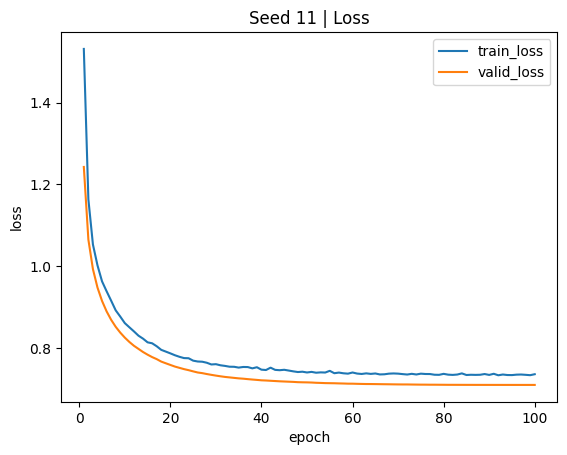

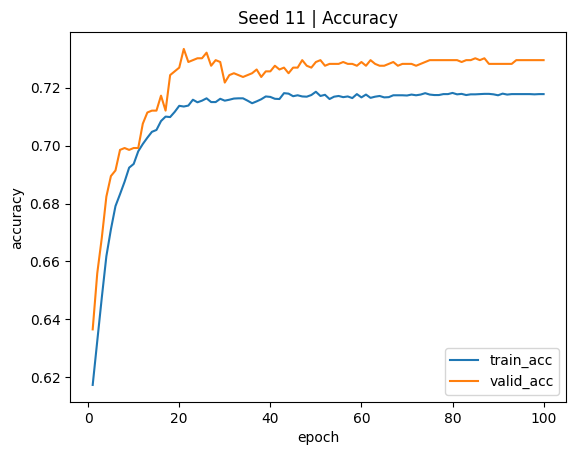

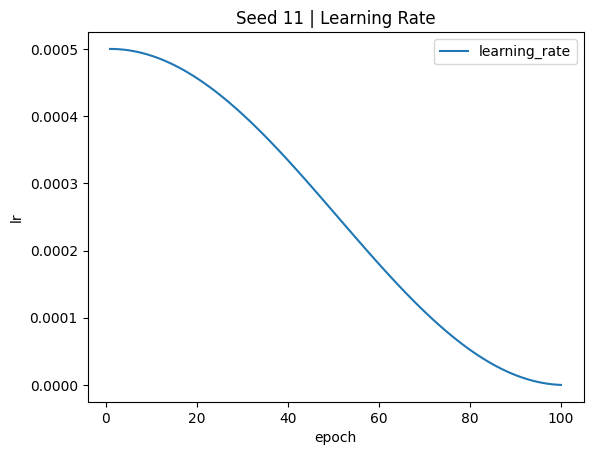


Seed 22 | Linear Probe


Epoch 01/100 | train_loss=1.5717 valid_loss=1.2728 | train_acc=0.6565 valid_acc=0.7043


Epoch 02/100 | train_loss=1.1095 valid_loss=0.9971 | train_acc=0.6972 valid_acc=0.7184


Epoch 03/100 | train_loss=0.9262 valid_loss=0.8810 | train_acc=0.7106 valid_acc=0.7293


Epoch 04/100 | train_loss=0.8406 valid_loss=0.8215 | train_acc=0.7230 valid_acc=0.7351


...

Epoch 96/100 | train_loss=0.5798 valid_loss=0.6220 | train_acc=0.7926 valid_acc=0.7729


Epoch 97/100 | train_loss=0.5798 valid_loss=0.6220 | train_acc=0.7926 valid_acc=0.7729


Epoch 98/100 | train_loss=0.5799 valid_loss=0.6220 | train_acc=0.7926 valid_acc=0.7729


Epoch 99/100 | train_loss=0.5796 valid_loss=0.6220 | train_acc=0.7926 valid_acc=0.7729


Epoch 100/100 | train_loss=0.5798 valid_loss=0.6220 | train_acc=0.7926 valid_acc=0.7729
Saved Stage-2 best head: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_22.pt


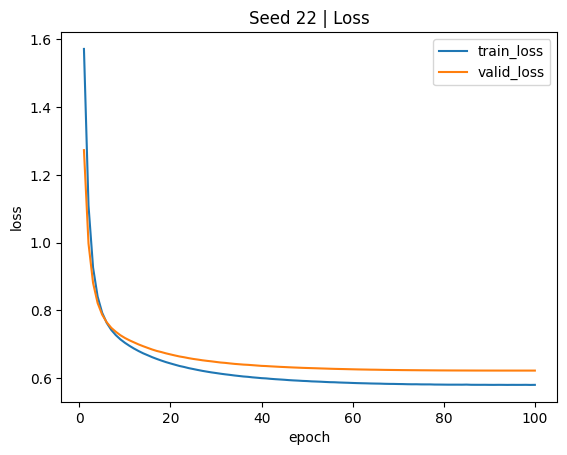

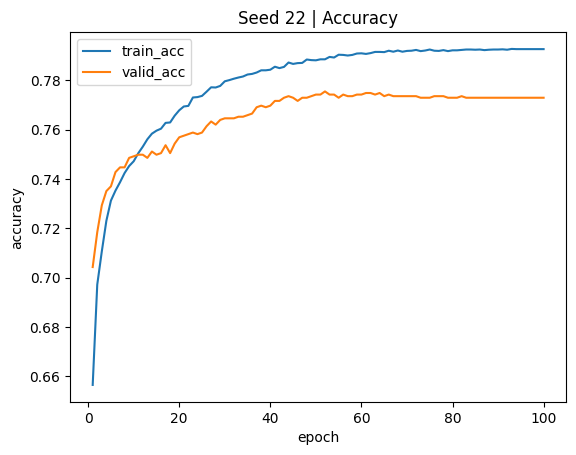

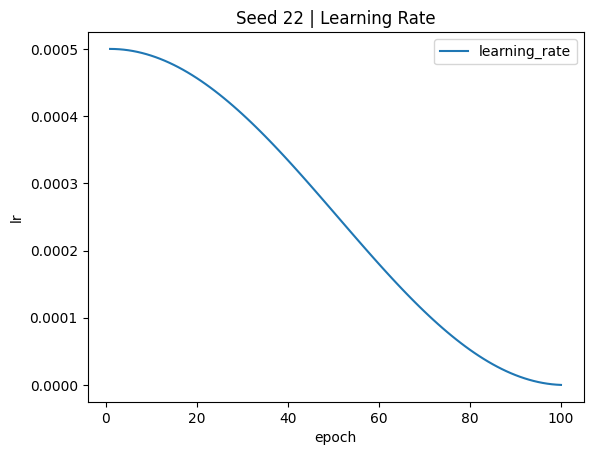


Seed 33 | Linear Probe


Epoch 01/100 | train_loss=1.5126 valid_loss=1.2472 | train_acc=0.6295 valid_acc=0.6478


Epoch 02/100 | train_loss=1.1136 valid_loss=1.0604 | train_acc=0.6492 valid_acc=0.6537


Epoch 03/100 | train_loss=0.9937 valid_loss=0.9863 | train_acc=0.6649 valid_acc=0.6656


Epoch 04/100 | train_loss=0.9374 valid_loss=0.9442 | train_acc=0.6817 valid_acc=0.6800


...

Epoch 96/100 | train_loss=0.6838 valid_loss=0.7045 | train_acc=0.7477 valid_acc=0.7352


Epoch 97/100 | train_loss=0.6846 valid_loss=0.7045 | train_acc=0.7477 valid_acc=0.7352


Epoch 98/100 | train_loss=0.6842 valid_loss=0.7045 | train_acc=0.7476 valid_acc=0.7352


Epoch 99/100 | train_loss=0.6836 valid_loss=0.7045 | train_acc=0.7476 valid_acc=0.7352


Epoch 100/100 | train_loss=0.6833 valid_loss=0.7045 | train_acc=0.7476 valid_acc=0.7352
Saved Stage-2 best head: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_33.pt


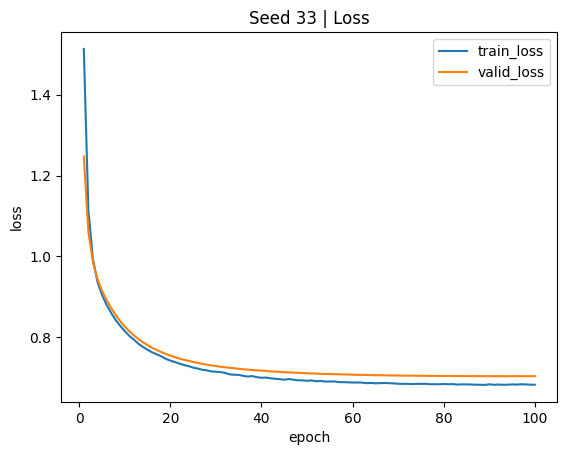

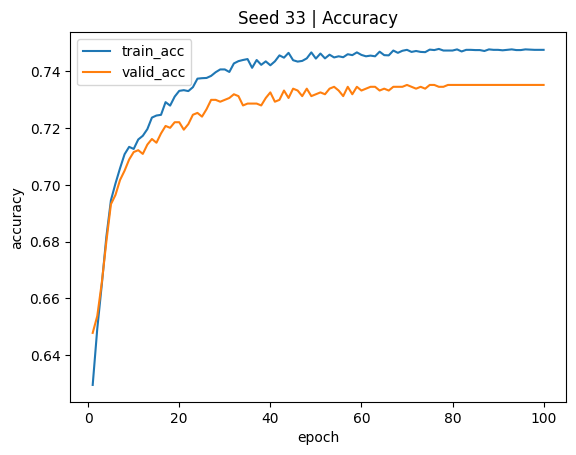

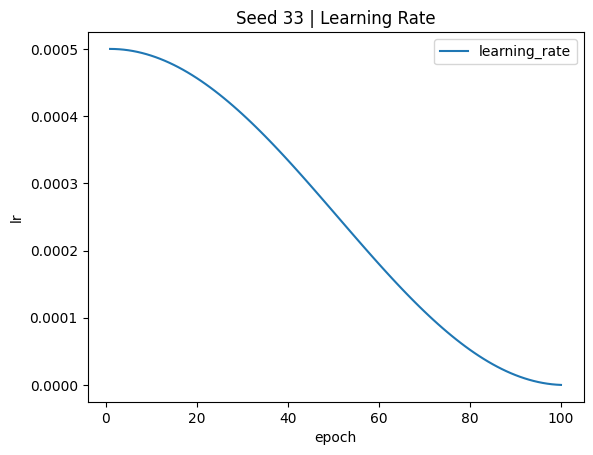


Seed 44 | Linear Probe


Epoch 01/100 | train_loss=1.5622 valid_loss=1.2544 | train_acc=0.6756 valid_acc=0.7042


Epoch 02/100 | train_loss=1.1166 valid_loss=0.9727 | train_acc=0.7060 valid_acc=0.7204


Epoch 03/100 | train_loss=0.9257 valid_loss=0.8449 | train_acc=0.7203 valid_acc=0.7340


Epoch 04/100 | train_loss=0.8316 valid_loss=0.7787 | train_acc=0.7327 valid_acc=0.7450


...

Epoch 96/100 | train_loss=0.5840 valid_loss=0.5859 | train_acc=0.7929 valid_acc=0.7942


Epoch 97/100 | train_loss=0.5835 valid_loss=0.5859 | train_acc=0.7930 valid_acc=0.7942


Epoch 98/100 | train_loss=0.5838 valid_loss=0.5859 | train_acc=0.7929 valid_acc=0.7942


Epoch 99/100 | train_loss=0.5837 valid_loss=0.5859 | train_acc=0.7929 valid_acc=0.7942


Epoch 100/100 | train_loss=0.5847 valid_loss=0.5859 | train_acc=0.7929 valid_acc=0.7942
Saved Stage-2 best head: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_44.pt


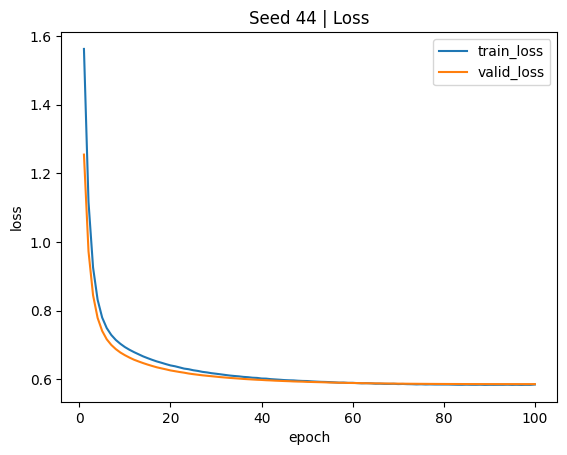

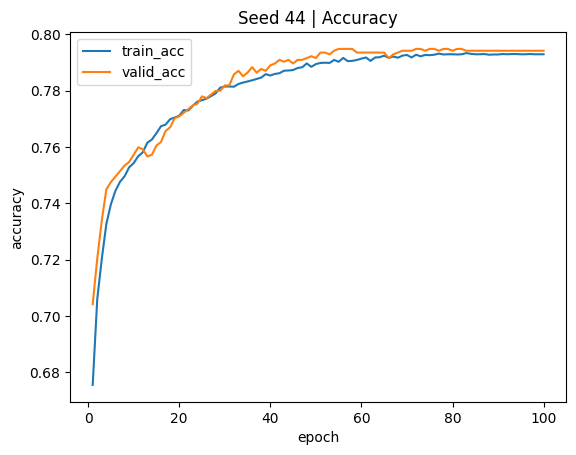

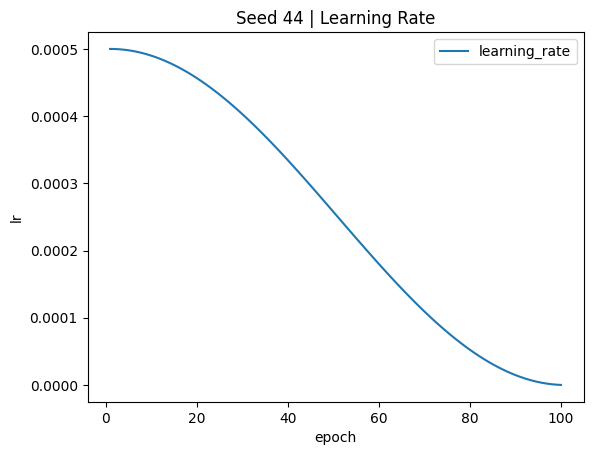


Seed 55 | Linear Probe


Epoch 01/100 | train_loss=1.6458 valid_loss=1.4594 | train_acc=0.5378 valid_acc=0.5527


Epoch 02/100 | train_loss=1.3594 valid_loss=1.2935 | train_acc=0.5893 valid_acc=0.6126


Epoch 03/100 | train_loss=1.2380 valid_loss=1.2062 | train_acc=0.6180 valid_acc=0.6271


Epoch 04/100 | train_loss=1.1613 valid_loss=1.1407 | train_acc=0.6287 valid_acc=0.6377


...

Epoch 96/100 | train_loss=0.7992 valid_loss=0.8249 | train_acc=0.7012 valid_acc=0.7154


Epoch 97/100 | train_loss=0.7993 valid_loss=0.8249 | train_acc=0.7012 valid_acc=0.7154


Epoch 98/100 | train_loss=0.7992 valid_loss=0.8249 | train_acc=0.7012 valid_acc=0.7154


Epoch 99/100 | train_loss=0.7995 valid_loss=0.8249 | train_acc=0.7012 valid_acc=0.7154


Epoch 100/100 | train_loss=0.7995 valid_loss=0.8249 | train_acc=0.7012 valid_acc=0.7154
Saved Stage-2 best head: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_55.pt


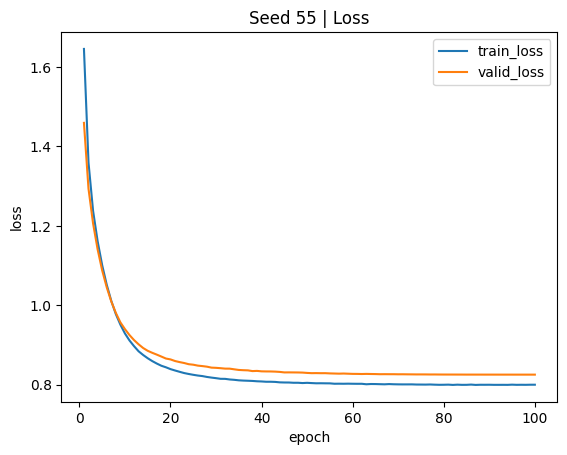

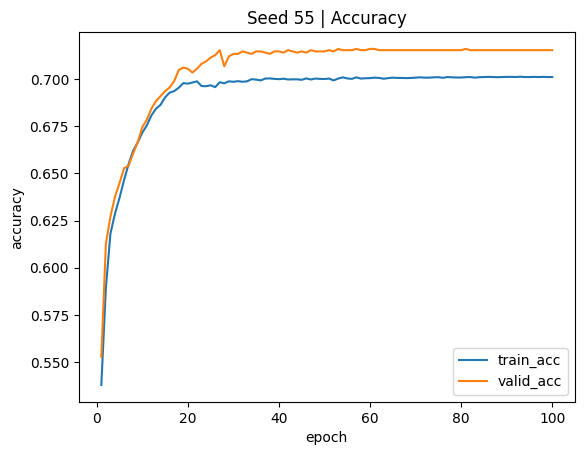

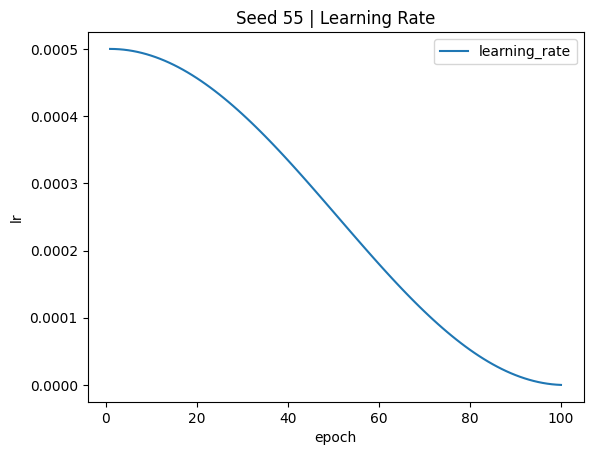


Stage-2 training done. Best head checkpoints:
{11: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_11.pt', 22: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_22.pt', 33: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_33.pt', 44: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_44.pt', 55: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_55.pt'}

Stage-2 history files:
{11: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_11_train_history.json', 22: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_22_train_history.json', 33: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_33_tra

In [ ]:
# ============================================================
# Stage 2 — Linear Probe Training (5 seeds) + LR charts
# Data source:
#   - Drive split folders: /content/drive/MyDrive/Thesis_Data/0111/seed_{seed}/{train|valid|test}
#   - Images are copied to /content/seed_{seed}_{split}_images for faster I/O
# Model source:
#   - Backbone weights come from Stage-1 checkpoints:
#       OUTPUT_ROOT/stage1_color_finetune/stage1_color_best_seed_{seed}.pt
# ============================================================

import os
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import clip

# -----------------------------
# Config
# -----------------------------
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
OUTPUT_ROOT = DRIVE_BASE_DIR / "TwoStage_LP_results"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

STAGE1_DIR = OUTPUT_ROOT / "stage1_color_finetune"
STAGE2_DIR = OUTPUT_ROOT / "stage2_linearprobe"
STAGE2_DIR.mkdir(parents=True, exist_ok=True)

SEEDS = [11, 22, 33, 44, 55]

# Split CSV columns (adjust if your CSV uses different names)
ID_COL = "image_id"
COLOR_COL = "color"

# Stage-2 hyperparams (reuse your config if already defined)
BATCH_SIZE = STAGE2_BATCH_SIZE
EPOCHS = STAGE2_EPOCHS
LR = STAGE2_LR
WEIGHT_DECAY = STAGE2_WEIGHT_DECAY

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_DTYPE = torch.float32

print("device:", DEVICE)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

# -----------------------------
# Utilities: staging (Drive -> /content)
# -----------------------------
LOCAL_BASE_DIR = Path("/content")

def stage_split_images(seed: int, split: str) -> Path:
    """
    Copy images for a given seed & split from Drive to local /content.
    Matches your original workflow using cp -r.
    """
    src = DRIVE_BASE_DIR / f"seed_{seed}" / split / "images"
    dst = LOCAL_BASE_DIR / f"seed_{seed}_{split}_images"

    if not src.exists():
        raise FileNotFoundError(f"Missing source images: {src}")

    # Refresh local folder to avoid stale files
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)
    return dst

def build_split_df(seed: int, split: str, image_dir: Path) -> pd.DataFrame:
    """
    Reads split CSV and attaches an absolute local image path.
    Expected CSV has at least [image_id] and [COLOR_COL].
    """
    csv_path = DRIVE_BASE_DIR / f"seed_{seed}" / split / f"{split}.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing split CSV: {csv_path}")

    df = pd.read_csv(csv_path, encoding="utf-8-sig")

    if ID_COL not in df.columns:
        raise ValueError(f"{csv_path} missing required column: {ID_COL}")
    if COLOR_COL not in df.columns:
        raise ValueError(
            f"{csv_path} missing required column: {COLOR_COL}. "
            f"Set COLOR_COL to the correct column name."
        )

    # Build local absolute path (assumes image file is <image_id>.jpg)
    df["path"] = df[ID_COL].astype(str).str.strip() + ".jpg"
    df["path"] = df["path"].apply(lambda n: str(image_dir / n))
    return df

# -----------------------------
# Dataset / Loader
# -----------------------------
clip_ref, preprocess = clip.load("ViT-B/32", device=DEVICE, jit=False)
clip_ref = clip_ref.float().eval()

@torch.no_grad()
def encode_images(backbone, x):
    feats = backbone.encode_image(x.to(DEVICE, non_blocking=True))
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.float()

class ColorSplitDataset(torch.utils.data.Dataset):
    """
    Returns:
      image_tensor, label_index, image_id(str)
    """
    def __init__(self, frame: pd.DataFrame, class_to_idx: dict):
        self.f = frame.reset_index(drop=True)
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.f)

    def __getitem__(self, i):
        r = self.f.iloc[i]
        img_path = r["path"]

        # Safety: allow missing file extension mismatch diagnosis early
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Missing image file: {img_path}")

        img = preprocess(Image.open(img_path).convert("RGB"))
        lab = str(r[COLOR_COL]).strip().lower()
        y = self.class_to_idx[lab]
        return img, torch.tensor(y, dtype=torch.long), str(r[ID_COL])

def make_loader(ds, shuffle: bool):
    return torch.utils.data.DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=2 if DEVICE == "cuda" else 0,
        pin_memory=(DEVICE == "cuda"),
        drop_last=False,
    )

# -----------------------------
# Training/eval epoch
# -----------------------------
def train_or_eval_epoch_lp(backbone, head, loader, optimizer=None):
    train_mode = optimizer is not None
    backbone.eval()
    head.train() if train_mode else head.eval()

    ce = nn.CrossEntropyLoss()
    total_loss = 0.0
    correct = 0
    count = 0

    for images, y, _ids in tqdm(
        loader,
        desc=("stage2/train" if train_mode else "stage2/valid"),
        leave=False
    ):
        images = images.to(DEVICE, non_blocking=True).to(dtype=TORCH_DTYPE)
        y = y.to(DEVICE, non_blocking=True)

        feats = encode_images(backbone, images).to(dtype=TORCH_DTYPE)
        logits = head(feats)
        loss = ce(logits, y)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item())
        pred = logits.argmax(dim=-1)
        correct += int((pred == y).sum().item())
        count += int(y.numel())

    return total_loss / max(1, len(loader)), (correct / max(1, count))

def plot_seed_curves(seed: int, hist: dict):
    epochs = np.arange(1, len(hist["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, hist["train_loss"], label="train_loss")
    plt.plot(epochs, hist["valid_loss"], label="valid_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"Seed {seed} | Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, hist["train_acc"], label="train_acc")
    plt.plot(epochs, hist["valid_acc"], label="valid_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(f"Seed {seed} | Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, hist["lr"], label="learning_rate")
    plt.xlabel("epoch")
    plt.ylabel("lr")
    plt.title(f"Seed {seed} | Learning Rate")
    plt.legend()
    plt.show()

# -----------------------------
# Main loop: 5 seeds
# -----------------------------
stage2_best_head_paths = {}
stage2_hist_paths = {}

for seed in SEEDS:
    print("\n===============================")
    print(f"Seed {seed} | Linear Probe")
    print("===============================")

    # 1) Stage images to /content (exactly your intended data source)
    train_img_dir = stage_split_images(seed, "train")
    valid_img_dir = stage_split_images(seed, "valid")
    test_img_dir  = stage_split_images(seed, "test")  # not used in this cell, but staged for consistency

    # 2) Read split CSVs and attach local paths
    train_df = build_split_df(seed, "train", train_img_dir)
    valid_df = build_split_df(seed, "valid", valid_img_dir)

    # Normalize labels to lowercase to avoid mismatch
    train_df[COLOR_COL] = train_df[COLOR_COL].astype(str).str.strip().str.lower()
    valid_df[COLOR_COL] = valid_df[COLOR_COL].astype(str).str.strip().str.lower()

    # 3) Load Stage-1 checkpoint for this seed (backbone + class list)
    stage1_ckpt_path = STAGE1_DIR / f"stage1_color_best_seed_{seed}.pt"
    ckpt = torch.load(stage1_ckpt_path, map_location="cpu")

    stage1_classes = ckpt.get("classes", None)
    if stage1_classes is None:
        # Fallback: derive from training split if Stage-1 did not save classes
        stage1_classes = sorted(train_df[COLOR_COL].unique().tolist())

    class_to_idx = {c: i for i, c in enumerate(stage1_classes)}
    idx_to_class = {i: c for c, i in class_to_idx.items()}

    # Filter to Stage-1 classes only (safety)
    train_df = train_df[train_df[COLOR_COL].isin(stage1_classes)].reset_index(drop=True)
    valid_df = valid_df[valid_df[COLOR_COL].isin(stage1_classes)].reset_index(drop=True)

    if len(train_df) == 0 or len(valid_df) == 0:
        raise ValueError(
            f"Seed {seed}: empty train/valid after filtering to Stage-1 classes. "
            f"Check your split CSV label values vs Stage-1 classes."
        )

    # 4) Build datasets/loaders
    train_ds = ColorSplitDataset(train_df, class_to_idx)
    valid_ds = ColorSplitDataset(valid_df, class_to_idx)

    train_dl = make_loader(train_ds, shuffle=True)
    valid_dl = make_loader(valid_ds, shuffle=False)

    # 5) Load Stage-1 backbone weights
    backbone, _ = clip.load("ViT-B/32", device=DEVICE, jit=False)
    backbone = backbone.float()
    backbone.load_state_dict(ckpt["clip_state_dict"], strict=True)

    for p in backbone.parameters():
        p.requires_grad = False
    backbone.eval()

    # 6) Train linear head
    feat_dim = backbone.visual.output_dim
    head = nn.Linear(feat_dim, len(stage1_classes)).to(DEVICE, dtype=TORCH_DTYPE)

    optimizer = optim.AdamW(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    hist = {"train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": [], "lr": []}

    best_valid_acc = float("-inf")
    best_head_state = None

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_or_eval_epoch_lp(backbone, head, train_dl, optimizer=optimizer)
        va_loss, va_acc = train_or_eval_epoch_lp(backbone, head, valid_dl, optimizer=None)

        hist["train_loss"].append(tr_loss)
        hist["valid_loss"].append(va_loss)
        hist["train_acc"].append(tr_acc)
        hist["valid_acc"].append(va_acc)
        hist["lr"].append(float(optimizer.param_groups[0]["lr"]))

        if va_acc > best_valid_acc:
            best_valid_acc = va_acc
            best_head_state = {k: v.detach().cpu() for k, v in head.state_dict().items()}

        # Print every epoch to match your format
        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={tr_loss:.4f} valid_loss={va_loss:.4f} | "
            f"train_acc={tr_acc:.4f} valid_acc={va_acc:.4f}"
        )

        scheduler.step()

    # 7) Save best head checkpoint for inference cell
    best_head_path = STAGE2_DIR / f"stage2_lp_best_head_seed_{seed}.pt"
    torch.save(
        {
            "seed": seed,
            "classes": stage1_classes,
            "feat_dim": int(feat_dim),
            "best_valid_acc": float(best_valid_acc),
            "head_state_dict": best_head_state,
        },
        best_head_path
    )
    stage2_best_head_paths[seed] = str(best_head_path)
    print("Saved Stage-2 best head:", best_head_path)

    # 8) Save history
    hist_path = STAGE2_DIR / f"stage2_seed_{seed}_train_history.json"
    with hist_path.open("w", encoding="utf-8") as f:
        json.dump(hist, f, ensure_ascii=False, indent=2)
    stage2_hist_paths[seed] = str(hist_path)

    # 9) Plot curves (loss/acc/lr)
    plot_seed_curves(seed, hist)

print("\nStage-2 training done. Best head checkpoints:")
print(stage2_best_head_paths)
print("\nStage-2 history files:")
print(stage2_hist_paths)

## rerun stage 2

In [ ]:
# ============================================================
# Stage 2 — Old-style Visual Inject + Feature Interpolation (Safe)
# - Keep your existing train/valid/test splits and image folders
# - Load Stage-1 checkpoint, but ONLY inject VISUAL weights (strict=False)
# - Build TWO backbones:
#     (1) base CLIP visual (f0)
#     (2) stage1-injected CLIP visual (f1)
# - Train heads on blended features: f = (1-alpha)*f0 + alpha*f1
# - Auto-select alpha by best valid score for each seed
# - Save best heads checkpoint per seed (includes label_lib + alpha)
# ============================================================

import os
import json
import ast
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import clip

# -----------------------------
# Config
# -----------------------------
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
OUTPUT_ROOT = DRIVE_BASE_DIR / "TwoStage_LP_results"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

STAGE1_DIR = OUTPUT_ROOT / "stage1_color_finetune"
STAGE2_DIR = OUTPUT_ROOT / "stage2_linearprobe_visual_inject_interp"
STAGE2_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_BASE_DIR = Path("/content")
SEEDS = [11, 22, 33, 44, 55]

LABEL_LIB_PATH = DRIVE_BASE_DIR / "label_library.json"

ID_COL = "image_id"
single_attrs = ["category", "sub_category"]
multi_attrs  = ["color", "material", "pattern"]

# Heads-only training hyperparams (recommended)
BATCH_SIZE = 64
EPOCHS = 60
LR = 5e-4
WEIGHT_DECAY = 0.02

# Loss weights: protect single-label performance, downweight multi tasks
W_CAT = 1.0
W_SUB = 1.0
W_MULTI = 0.15

# Candidate alphas for interpolation
ALPHA_CANDIDATES = [0.0, 0.2, 0.5, 0.8, 1.0]  # 0.0=base only, 1.0=stage1 only

# Early stopping
PATIENCE = 10
MIN_DELTA = 1e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

# -----------------------------
# Utilities
# -----------------------------
def parse_list_cell(x):
    s = "" if pd.isna(x) else str(x).strip()
    if s in ("", "[]"):
        return []
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(t).strip().strip("'").strip('"').lower() for t in v if str(t).strip()]
        return [str(v).strip().lower()] if str(v).strip() else []
    except Exception:
        parts = [t.strip().lower() for t in s.split(",")]
        return [p for p in parts if p]

def get_local_split_dir(seed: int, split: str) -> Path:
    d = LOCAL_BASE_DIR / f"seed_{seed}_{split}_images"
    if not d.exists():
        raise FileNotFoundError(f"Local staged folder not found: {d}")
    return d

def build_dataframe(seed: int, split: str, image_dir: Path) -> pd.DataFrame:
    csv_path = DRIVE_BASE_DIR / f"seed_{seed}" / split / f"{split}.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing split CSV: {csv_path}")

    df = pd.read_csv(csv_path, encoding="utf-8-sig")
    if ID_COL not in df.columns:
        raise ValueError(f"{csv_path} missing required column: {ID_COL}")

    required = [ID_COL] + single_attrs + multi_attrs
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{csv_path} missing columns: {missing}")

    df[ID_COL] = df[ID_COL].astype(str).str.strip()
    df["path"] = (df[ID_COL] + ".jpg").apply(lambda n: str(image_dir / n))

    # normalize single labels
    for a in single_attrs:
        df[a] = df[a].astype(str).str.strip().str.lower()
        df.loc[df[a].isin(["", "nan"]), a] = ""

    return df

# -----------------------------
# Load label library
# -----------------------------
if not LABEL_LIB_PATH.exists():
    raise FileNotFoundError(f"label_library.json not found: {LABEL_LIB_PATH}")

with LABEL_LIB_PATH.open("r", encoding="utf-8-sig") as f:
    label_lib = json.load(f)

label2idx_single = {a: {lab: i for i, lab in enumerate(label_lib[a])} for a in single_attrs}
label2idx_multi  = {a: {lab: i for i, lab in enumerate(label_lib[a])} for a in multi_attrs}

# -----------------------------
# Dataset / Loader
# -----------------------------
_, preprocess = clip.load("ViT-B/32", device=DEVICE, jit=False)

class FashionSet(torch.utils.data.Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.f = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.f)

    def __getitem__(self, i):
        r = self.f.iloc[i]
        img_path = r["path"]
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Missing image file: {img_path}")

        img = preprocess(Image.open(img_path).convert("RGB"))

        y_single = {}
        for a in single_attrs:
            v = str(r.get(a, "")).strip().lower()
            if v == "":
                y_single[a] = -1
            else:
                y_single[a] = label2idx_single[a].get(v, -1)

        y_multi = {}
        for a in multi_attrs:
            raw = r.get(a, "")
            if pd.isna(raw) or str(raw).strip() in ("", "[]"):
                vec = torch.full((len(label_lib[a]),), -1.0, dtype=torch.float32)
            else:
                labs = parse_list_cell(raw)
                vec = torch.zeros((len(label_lib[a]),), dtype=torch.float32)
                for lab in labs:
                    j = label2idx_multi[a].get(lab)
                    if j is not None:
                        vec[j] = 1.0
            y_multi[a] = vec

        return img, y_single, y_multi

def collate_fn(batch):
    imgs = torch.stack([b[0] for b in batch], dim=0)
    y_single = {a: torch.tensor([b[1][a] for b in batch], dtype=torch.long) for a in single_attrs}
    y_multi  = {a: torch.stack([b[2][a] for b in batch], dim=0) for a in multi_attrs}
    return imgs, y_single, y_multi

def make_loader(df, shuffle):
    ds = FashionSet(df)
    return torch.utils.data.DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=2 if DEVICE == "cuda" else 0,
        pin_memory=(DEVICE == "cuda"),
        collate_fn=collate_fn,
        drop_last=False
    )

# -----------------------------
# Heads
# -----------------------------
def make_heads(feat_dim: int):
    return nn.ModuleDict({
        "single": nn.ModuleDict({a: nn.Linear(feat_dim, len(label_lib[a])) for a in single_attrs}),
        "multi":  nn.ModuleDict({a: nn.Linear(feat_dim, len(label_lib[a])) for a in multi_attrs}),
    }).to(DEVICE)

bce = nn.BCEWithLogitsLoss(reduction="none")
ce_cat = nn.CrossEntropyLoss(ignore_index=-1)
ce_sub = nn.CrossEntropyLoss(ignore_index=-1)

# -----------------------------
# Load Stage1 ckpt -> extract ONLY visual weights (old-style)
# -----------------------------
def extract_visual_state_dict_from_stage1_ckpt(ckpt: dict) -> dict:
    """
    Your stage1 ckpt currently stores:
      ckpt["clip_state_dict"] = full CLIP state_dict
    We extract only keys under "visual."
    """
    if "visual" in ckpt and isinstance(ckpt["visual"], dict):
        # already visual-only format (old style)
        return ckpt["visual"]

    if "clip_state_dict" not in ckpt:
        raise KeyError("Stage1 checkpoint missing 'clip_state_dict' (and no 'visual').")

    full_sd = ckpt["clip_state_dict"]
    visual_sd = {}
    for k, v in full_sd.items():
        if k.startswith("visual."):
            visual_sd[k[len("visual."):]] = v
    if len(visual_sd) == 0:
        raise ValueError("Could not find 'visual.' keys inside stage1 clip_state_dict.")
    return visual_sd

# -----------------------------
# Feature encoding: base + stage1 visual, then interpolate
# -----------------------------
@torch.no_grad()
def encode_visual(model, x):
    feats = model.encode_image(x.to(DEVICE, non_blocking=True)).float()
    feats = feats / feats.norm(dim=-1, keepdim=True).clamp(min=1e-6)
    return feats

@torch.no_grad()
def encode_interp(base_model, tuned_model, x, alpha: float):
    f0 = encode_visual(base_model, x)
    f1 = encode_visual(tuned_model, x)
    f  = (1.0 - alpha) * f0 + alpha * f1
    f  = f / f.norm(dim=-1, keepdim=True).clamp(min=1e-6)
    return f

def epoch_run(base_model, tuned_model, heads, loader, alpha: float, optimizer=None):
    train_mode = optimizer is not None
    base_model.eval()
    tuned_model.eval()
    heads.train() if train_mode else heads.eval()

    total_loss = 0.0
    correct = {a: 0 for a in single_attrs}
    count   = {a: 0 for a in single_attrs}

    for imgs, y_s, y_m in tqdm(loader, desc=("train" if train_mode else "valid"), leave=False):
        imgs = imgs.to(DEVICE, non_blocking=True)
        feats = encode_interp(base_model, tuned_model, imgs, alpha)

        loss = 0.0

        # single-label
        logits_cat = heads["single"]["category"](feats)
        y_cat = y_s["category"].to(DEVICE, non_blocking=True)
        l_cat = ce_cat(logits_cat, y_cat)
        loss = loss + W_CAT * l_cat

        logits_sub = heads["single"]["sub_category"](feats)
        y_sub = y_s["sub_category"].to(DEVICE, non_blocking=True)
        l_sub = ce_sub(logits_sub, y_sub)
        loss = loss + W_SUB * l_sub

        # accuracy tracking
        with torch.no_grad():
            # category
            pred = logits_cat.argmax(dim=-1)
            m = (y_cat != -1)
            correct["category"] += int((pred[m] == y_cat[m]).sum().item())
            count["category"]   += int(m.sum().item())
            # sub_category
            pred = logits_sub.argmax(dim=-1)
            m = (y_sub != -1)
            correct["sub_category"] += int((pred[m] == y_sub[m]).sum().item())
            count["sub_category"]   += int(m.sum().item())

        # multi-label (masked BCE)
        for a in multi_attrs:
            logits = heads["multi"][a](feats)
            y = y_m[a].to(DEVICE, non_blocking=True)
            mask = (y != -1.0).float()
            lmat = bce(logits, torch.clamp(y, 0, 1))
            den = torch.clamp(mask.sum(), min=1.0)
            l = (lmat * mask).sum() / den
            loss = loss + W_MULTI * l

        if train_mode:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        total_loss += float(loss.detach().cpu().item())

    mean_loss = total_loss / max(1, len(loader))
    accs = {a: (correct[a] / count[a] if count[a] > 0 else np.nan) for a in single_attrs}
    mean_acc = float(np.nanmean(list(accs.values())))
    return mean_loss, mean_acc, accs

# -----------------------------
# Train per seed, auto-select alpha
# -----------------------------
for seed in SEEDS:
    print("\n===============================")
    print(f"Seed {seed} | Stage-2 (visual inject + interp, old-style safe)")
    print("===============================")

    # data (keep your existing split folders)
    train_dir = get_local_split_dir(seed, "train")
    valid_dir = get_local_split_dir(seed, "valid")
    test_dir  = get_local_split_dir(seed, "test")

    train_df = build_dataframe(seed, "train", train_dir)
    valid_df = build_dataframe(seed, "valid", valid_dir)
    _ = build_dataframe(seed, "test",  test_dir)  # just sanity check exists

    train_loader = make_loader(train_df, shuffle=True)
    valid_loader = make_loader(valid_df, shuffle=False)

    # base model (f0)
    base_model, _ = clip.load("ViT-B/32", device=DEVICE, jit=False)
    base_model = base_model.float().eval()
    for p in base_model.parameters():
        p.requires_grad = False

    # tuned visual model (f1): start from base, then inject visual weights from stage1 ckpt
    tuned_model, _ = clip.load("ViT-B/32", device=DEVICE, jit=False)
    tuned_model = tuned_model.float().eval()
    for p in tuned_model.parameters():
        p.requires_grad = False

    stage1_ckpt_path = STAGE1_DIR / f"stage1_color_best_seed_{seed}.pt"
    ckpt_s1 = torch.load(stage1_ckpt_path, map_location="cpu")
    visual_sd = extract_visual_state_dict_from_stage1_ckpt(ckpt_s1)
    missing, unexpected = tuned_model.visual.load_state_dict(visual_sd, strict=False)
    print(f"[visual load] missing={len(missing)} unexpected={len(unexpected)} (strict=False)")

    feat_dim = tuned_model.visual.output_dim
    best_overall = -1.0
    best_alpha = None
    best_state = None
    best_epoch = None

    # sweep alpha candidates, pick best by valid mean(single acc)
    for alpha in ALPHA_CANDIDATES:
        print(f"\n--- Alpha sweep: alpha={alpha:.2f} ---")
        heads = make_heads(feat_dim)
        opt = optim.AdamW(heads.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

        best_valid = -1.0
        best_local_state = None
        best_local_epoch = 0
        bad = 0

        for epoch in range(1, EPOCHS + 1):
            tr_loss, tr_acc, _ = epoch_run(base_model, tuned_model, heads, train_loader, alpha, optimizer=opt)
            va_loss, va_acc, va_accs = epoch_run(base_model, tuned_model, heads, valid_loader, alpha, optimizer=None)

            print(
                f"alpha={alpha:.2f} | Epoch {epoch:03d}/{EPOCHS} | "
                f"train_loss={tr_loss:.4f} valid_loss={va_loss:.4f} | "
                f"train_acc={tr_acc:.4f} valid_acc={va_acc:.4f} | "
                f"valid_acc(category)={va_accs['category']:.4f} valid_acc(sub_category)={va_accs['sub_category']:.4f}"
            )

            if va_acc > best_valid + MIN_DELTA:
                best_valid = va_acc
                best_local_state = {k: v.detach().cpu() for k, v in heads.state_dict().items()}
                best_local_epoch = epoch
                bad = 0
            else:
                bad += 1
                if bad >= PATIENCE:
                    print(f"Early stop (alpha={alpha:.2f}) at epoch {epoch}, best_epoch={best_local_epoch}, best_valid={best_valid:.4f}")
                    break

        # compare across alphas
        if best_valid > best_overall:
            best_overall = best_valid
            best_alpha = float(alpha)
            best_state = best_local_state
            best_epoch = int(best_local_epoch)

    # save best for this seed
    out_path = STAGE2_DIR / f"stage2_5head_best_seed_{seed}.pt"
    torch.save(
        {
            "state_dict": best_state,
            "seed": seed,
            "best_valid_acc": float(best_overall),
            "best_epoch": int(best_epoch),
            "alpha": float(best_alpha),
            "alpha_candidates": ALPHA_CANDIDATES,
            "model": "ViT-B/32",
            "lr": float(LR),
            "epochs": int(EPOCHS),
            "label_lib": label_lib,
            "single_attrs": single_attrs,
            "multi_attrs": multi_attrs,
            "notes": "Stage2-only: old-style visual inject (strict=False) + feature interpolation to reduce negative transfer.",
        },
        out_path
    )
    print(f"\n[Seed {seed}] BEST alpha={best_alpha:.2f}, best_valid={best_overall:.4f}, saved: {out_path}")

device: cuda
gpu: NVIDIA A100-SXM4-40GB

Seed 11 | Stage-2 (visual inject + interp, old-style safe)
[visual load] missing=0 unexpected=0 (strict=False)

--- Alpha sweep: alpha=0.00 ---


alpha=0.00 | Epoch 001/60 | train_loss=5.5332 valid_loss=4.4749 | train_acc=0.5015 valid_acc=0.5654 | valid_acc(category)=0.7669 valid_acc(sub_category)=0.3640


alpha=0.00 | Epoch 002/60 | train_loss=3.9503 valid_loss=3.5106 | train_acc=0.5844 valid_acc=0.6048 | valid_acc(category)=0.7749 valid_acc(sub_category)=0.4346


alpha=0.00 | Epoch 003/60 | train_loss=3.2046 valid_loss=2.9277 | train_acc=0.6353 valid_acc=0.6557 | valid_acc(category)=0.8083 valid_acc(sub_category)=0.5032


alpha=0.00 | Epoch 004/60 | train_loss=2.7169 valid_loss=2.5266 | train_acc=0.6891 valid_acc=0.7044 | valid_acc(category)=0.8461 valid_acc(sub_category)=0.5627


...

alpha=0.00 | Epoch 009/60 | train_loss=1.6575 valid_loss=1.6246 | train_acc=0.7985 valid_acc=0.7944 | valid_acc(category)=0.9150 valid_acc(sub_category)=0.6738


alpha=0.00 | Epoch 010/60 | train_loss=1.5630 valid_loss=1.5426 | train_acc=0.8055 valid_acc=0.8016 | valid_acc(category)=0.9189 valid_acc(sub_category)=0.6844


alpha=0.00 | Epoch 011/60 | train_loss=1.4859 valid_loss=1.4761 | train_acc=0.8098 valid_acc=0.8063 | valid_acc(category)=0.9211 valid_acc(sub_category)=0.6916


alpha=0.00 | Epoch 012/60 | train_loss=1.4221 valid_loss=1.4210 | train_acc=0.8132 valid_acc=0.8102 | valid_acc(category)=0.9228 valid_acc(sub_category)=0.6977


KeyboardInterrupt: 

### less epochs

In [ ]:
# ============================================================
# Stage 2 — Old-style Visual Inject + Feature Interpolation (Safe)
# - Keep your existing train/valid/test splits and image folders
# - Load Stage-1 checkpoint, but ONLY inject VISUAL weights (strict=False)
# - Build TWO backbones:
#     (1) base CLIP visual (f0)
#     (2) stage1-injected CLIP visual (f1)
# - Train heads on blended features: f = (1-alpha)*f0 + alpha*f1
# - Auto-select alpha by best valid score for each seed
# - Save best heads checkpoint per seed (includes label_lib + alpha)
# ============================================================

import os
import json
import ast
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import clip

# -----------------------------
# Config
# -----------------------------
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
OUTPUT_ROOT = DRIVE_BASE_DIR / "TwoStage_LP_results"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

STAGE1_DIR = OUTPUT_ROOT / "stage1_color_finetune"
STAGE2_DIR = OUTPUT_ROOT / "stage2_linearprobe_visual_inject_interp"
STAGE2_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_BASE_DIR = Path("/content")
SEEDS = [11, 22, 33, 44, 55]

LABEL_LIB_PATH = DRIVE_BASE_DIR / "label_library.json"

ID_COL = "image_id"
single_attrs = ["category", "sub_category"]
multi_attrs  = ["color", "material", "pattern"]

# Heads-only training hyperparams (recommended)
BATCH_SIZE = 64
EPOCHS = 20
LR = 5e-4
WEIGHT_DECAY = 0.02

# Loss weights: protect single-label performance, downweight multi tasks
W_CAT = 1.0
W_SUB = 1.0
W_MULTI = 0.15

# Candidate alphas for interpolation
ALPHA_CANDIDATES = [0.0]

# Early stopping
PATIENCE = 10
MIN_DELTA = 1e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

# -----------------------------
# Utilities
# -----------------------------
def parse_list_cell(x):
    s = "" if pd.isna(x) else str(x).strip()
    if s in ("", "[]"):
        return []
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(t).strip().strip("'").strip('"').lower() for t in v if str(t).strip()]
        return [str(v).strip().lower()] if str(v).strip() else []
    except Exception:
        parts = [t.strip().lower() for t in s.split(",")]
        return [p for p in parts if p]

def get_local_split_dir(seed: int, split: str) -> Path:
    d = LOCAL_BASE_DIR / f"seed_{seed}_{split}_images"
    if not d.exists():
        raise FileNotFoundError(f"Local staged folder not found: {d}")
    return d

def build_dataframe(seed: int, split: str, image_dir: Path) -> pd.DataFrame:
    csv_path = DRIVE_BASE_DIR / f"seed_{seed}" / split / f"{split}.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing split CSV: {csv_path}")

    df = pd.read_csv(csv_path, encoding="utf-8-sig")
    if ID_COL not in df.columns:
        raise ValueError(f"{csv_path} missing required column: {ID_COL}")

    required = [ID_COL] + single_attrs + multi_attrs
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{csv_path} missing columns: {missing}")

    df[ID_COL] = df[ID_COL].astype(str).str.strip()
    df["path"] = (df[ID_COL] + ".jpg").apply(lambda n: str(image_dir / n))

    # normalize single labels
    for a in single_attrs:
        df[a] = df[a].astype(str).str.strip().str.lower()
        df.loc[df[a].isin(["", "nan"]), a] = ""

    return df

# -----------------------------
# Load label library
# -----------------------------
if not LABEL_LIB_PATH.exists():
    raise FileNotFoundError(f"label_library.json not found: {LABEL_LIB_PATH}")

with LABEL_LIB_PATH.open("r", encoding="utf-8-sig") as f:
    label_lib = json.load(f)

label2idx_single = {a: {lab: i for i, lab in enumerate(label_lib[a])} for a in single_attrs}
label2idx_multi  = {a: {lab: i for i, lab in enumerate(label_lib[a])} for a in multi_attrs}

# -----------------------------
# Dataset / Loader
# -----------------------------
_, preprocess = clip.load("ViT-B/32", device=DEVICE, jit=False)

class FashionSet(torch.utils.data.Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.f = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.f)

    def __getitem__(self, i):
        r = self.f.iloc[i]
        img_path = r["path"]
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Missing image file: {img_path}")

        img = preprocess(Image.open(img_path).convert("RGB"))

        y_single = {}
        for a in single_attrs:
            v = str(r.get(a, "")).strip().lower()
            if v == "":
                y_single[a] = -1
            else:
                y_single[a] = label2idx_single[a].get(v, -1)

        y_multi = {}
        for a in multi_attrs:
            raw = r.get(a, "")
            if pd.isna(raw) or str(raw).strip() in ("", "[]"):
                vec = torch.full((len(label_lib[a]),), -1.0, dtype=torch.float32)
            else:
                labs = parse_list_cell(raw)
                vec = torch.zeros((len(label_lib[a]),), dtype=torch.float32)
                for lab in labs:
                    j = label2idx_multi[a].get(lab)
                    if j is not None:
                        vec[j] = 1.0
            y_multi[a] = vec

        return img, y_single, y_multi

def collate_fn(batch):
    imgs = torch.stack([b[0] for b in batch], dim=0)
    y_single = {a: torch.tensor([b[1][a] for b in batch], dtype=torch.long) for a in single_attrs}
    y_multi  = {a: torch.stack([b[2][a] for b in batch], dim=0) for a in multi_attrs}
    return imgs, y_single, y_multi

def make_loader(df, shuffle):
    ds = FashionSet(df)
    return torch.utils.data.DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=2 if DEVICE == "cuda" else 0,
        pin_memory=(DEVICE == "cuda"),
        collate_fn=collate_fn,
        drop_last=False
    )

# -----------------------------
# Heads
# -----------------------------
def make_heads(feat_dim: int):
    return nn.ModuleDict({
        "single": nn.ModuleDict({a: nn.Linear(feat_dim, len(label_lib[a])) for a in single_attrs}),
        "multi":  nn.ModuleDict({a: nn.Linear(feat_dim, len(label_lib[a])) for a in multi_attrs}),
    }).to(DEVICE)

bce = nn.BCEWithLogitsLoss(reduction="none")
ce_cat = nn.CrossEntropyLoss(ignore_index=-1)
ce_sub = nn.CrossEntropyLoss(ignore_index=-1)

# -----------------------------
# Load Stage1 ckpt -> extract ONLY visual weights (old-style)
# -----------------------------
def extract_visual_state_dict_from_stage1_ckpt(ckpt: dict) -> dict:
    """
    Your stage1 ckpt currently stores:
      ckpt["clip_state_dict"] = full CLIP state_dict
    We extract only keys under "visual."
    """
    if "visual" in ckpt and isinstance(ckpt["visual"], dict):
        # already visual-only format (old style)
        return ckpt["visual"]

    if "clip_state_dict" not in ckpt:
        raise KeyError("Stage1 checkpoint missing 'clip_state_dict' (and no 'visual').")

    full_sd = ckpt["clip_state_dict"]
    visual_sd = {}
    for k, v in full_sd.items():
        if k.startswith("visual."):
            visual_sd[k[len("visual."):]] = v
    if len(visual_sd) == 0:
        raise ValueError("Could not find 'visual.' keys inside stage1 clip_state_dict.")
    return visual_sd

# -----------------------------
# Feature encoding: base + stage1 visual, then interpolate
# -----------------------------
@torch.no_grad()
def encode_visual(model, x):
    feats = model.encode_image(x.to(DEVICE, non_blocking=True)).float()
    feats = feats / feats.norm(dim=-1, keepdim=True).clamp(min=1e-6)
    return feats

@torch.no_grad()
def encode_interp(base_model, tuned_model, x, alpha: float):
    f0 = encode_visual(base_model, x)
    f1 = encode_visual(tuned_model, x)
    f  = (1.0 - alpha) * f0 + alpha * f1
    f  = f / f.norm(dim=-1, keepdim=True).clamp(min=1e-6)
    return f

def epoch_run(base_model, tuned_model, heads, loader, alpha: float, optimizer=None):
    train_mode = optimizer is not None
    base_model.eval()
    tuned_model.eval()
    heads.train() if train_mode else heads.eval()

    total_loss = 0.0
    correct = {a: 0 for a in single_attrs}
    count   = {a: 0 for a in single_attrs}

    for imgs, y_s, y_m in tqdm(loader, desc=("train" if train_mode else "valid"), leave=False):
        imgs = imgs.to(DEVICE, non_blocking=True)
        feats = encode_interp(base_model, tuned_model, imgs, alpha)

        loss = 0.0

        # single-label
        logits_cat = heads["single"]["category"](feats)
        y_cat = y_s["category"].to(DEVICE, non_blocking=True)
        l_cat = ce_cat(logits_cat, y_cat)
        loss = loss + W_CAT * l_cat

        logits_sub = heads["single"]["sub_category"](feats)
        y_sub = y_s["sub_category"].to(DEVICE, non_blocking=True)
        l_sub = ce_sub(logits_sub, y_sub)
        loss = loss + W_SUB * l_sub

        # accuracy tracking
        with torch.no_grad():
            # category
            pred = logits_cat.argmax(dim=-1)
            m = (y_cat != -1)
            correct["category"] += int((pred[m] == y_cat[m]).sum().item())
            count["category"]   += int(m.sum().item())
            # sub_category
            pred = logits_sub.argmax(dim=-1)
            m = (y_sub != -1)
            correct["sub_category"] += int((pred[m] == y_sub[m]).sum().item())
            count["sub_category"]   += int(m.sum().item())

        # multi-label (masked BCE)
        for a in multi_attrs:
            logits = heads["multi"][a](feats)
            y = y_m[a].to(DEVICE, non_blocking=True)
            mask = (y != -1.0).float()
            lmat = bce(logits, torch.clamp(y, 0, 1))
            den = torch.clamp(mask.sum(), min=1.0)
            l = (lmat * mask).sum() / den
            loss = loss + W_MULTI * l

        if train_mode:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        total_loss += float(loss.detach().cpu().item())

    mean_loss = total_loss / max(1, len(loader))
    accs = {a: (correct[a] / count[a] if count[a] > 0 else np.nan) for a in single_attrs}
    mean_acc = float(np.nanmean(list(accs.values())))
    return mean_loss, mean_acc, accs

# -----------------------------
# Train per seed, auto-select alpha
# -----------------------------
for seed in SEEDS:
    print("\n===============================")
    print(f"Seed {seed} | Stage-2 (visual inject + interp, old-style safe)")
    print("===============================")

    # data (keep your existing split folders)
    train_dir = get_local_split_dir(seed, "train")
    valid_dir = get_local_split_dir(seed, "valid")
    test_dir  = get_local_split_dir(seed, "test")

    train_df = build_dataframe(seed, "train", train_dir)
    valid_df = build_dataframe(seed, "valid", valid_dir)
    _ = build_dataframe(seed, "test",  test_dir)  # just sanity check exists

    train_loader = make_loader(train_df, shuffle=True)
    valid_loader = make_loader(valid_df, shuffle=False)

    # base model (f0)
    base_model, _ = clip.load("ViT-B/32", device=DEVICE, jit=False)
    base_model = base_model.float().eval()
    for p in base_model.parameters():
        p.requires_grad = False

    # tuned visual model (f1): start from base, then inject visual weights from stage1 ckpt
    tuned_model, _ = clip.load("ViT-B/32", device=DEVICE, jit=False)
    tuned_model = tuned_model.float().eval()
    for p in tuned_model.parameters():
        p.requires_grad = False

    stage1_ckpt_path = STAGE1_DIR / f"stage1_color_best_seed_{seed}.pt"
    ckpt_s1 = torch.load(stage1_ckpt_path, map_location="cpu")
    visual_sd = extract_visual_state_dict_from_stage1_ckpt(ckpt_s1)
    missing, unexpected = tuned_model.visual.load_state_dict(visual_sd, strict=False)
    print(f"[visual load] missing={len(missing)} unexpected={len(unexpected)} (strict=False)")

    feat_dim = tuned_model.visual.output_dim
    best_overall = -1.0
    best_alpha = None
    best_state = None
    best_epoch = None

    # sweep alpha candidates, pick best by valid mean(single acc)
    for alpha in ALPHA_CANDIDATES:
        print(f"\n--- Alpha sweep: alpha={alpha:.2f} ---")
        heads = make_heads(feat_dim)
        opt = optim.AdamW(heads.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

        best_valid = -1.0
        best_local_state = None
        best_local_epoch = 0
        bad = 0

        for epoch in range(1, EPOCHS + 1):
            tr_loss, tr_acc, _ = epoch_run(base_model, tuned_model, heads, train_loader, alpha, optimizer=opt)
            va_loss, va_acc, va_accs = epoch_run(base_model, tuned_model, heads, valid_loader, alpha, optimizer=None)

            print(
                f"alpha={alpha:.2f} | Epoch {epoch:03d}/{EPOCHS} | "
                f"train_loss={tr_loss:.4f} valid_loss={va_loss:.4f} | "
                f"train_acc={tr_acc:.4f} valid_acc={va_acc:.4f} | "
                f"valid_acc(category)={va_accs['category']:.4f} valid_acc(sub_category)={va_accs['sub_category']:.4f}"
            )

            if va_acc > best_valid + MIN_DELTA:
                best_valid = va_acc
                best_local_state = {k: v.detach().cpu() for k, v in heads.state_dict().items()}
                best_local_epoch = epoch
                bad = 0
            else:
                bad += 1
                if bad >= PATIENCE:
                    print(f"Early stop (alpha={alpha:.2f}) at epoch {epoch}, best_epoch={best_local_epoch}, best_valid={best_valid:.4f}")
                    break

        # compare across alphas
        if best_valid > best_overall:
            best_overall = best_valid
            best_alpha = float(alpha)
            best_state = best_local_state
            best_epoch = int(best_local_epoch)

    # save best for this seed
    out_path = STAGE2_DIR / f"stage2_5head_best_seed_{seed}.pt"
    torch.save(
        {
            "state_dict": best_state,
            "seed": seed,
            "best_valid_acc": float(best_overall),
            "best_epoch": int(best_epoch),
            "alpha": float(best_alpha),
            "alpha_candidates": ALPHA_CANDIDATES,
            "model": "ViT-B/32",
            "lr": float(LR),
            "epochs": int(EPOCHS),
            "label_lib": label_lib,
            "single_attrs": single_attrs,
            "multi_attrs": multi_attrs,
            "notes": "Stage2-only: old-style visual inject (strict=False) + feature interpolation to reduce negative transfer.",
        },
        out_path
    )
    print(f"\n[Seed {seed}] BEST alpha={best_alpha:.2f}, best_valid={best_overall:.4f}, saved: {out_path}")

device: cuda
gpu: NVIDIA A100-SXM4-40GB


Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor



Seed 11 | Stage-2 (visual inject + interp, old-style safe)
[visual load] missing=0 unexpected=0 (strict=False)

--- Alpha sweep: alpha=0.00 ---


alpha=0.00 | Epoch 001/20 | train_loss=5.5380 valid_loss=4.4827 | train_acc=0.5056 valid_acc=0.5613 | valid_acc(category)=0.7638 valid_acc(sub_category)=0.3587


alpha=0.00 | Epoch 002/20 | train_loss=3.9576 valid_loss=3.5173 | train_acc=0.5859 valid_acc=0.6016 | valid_acc(category)=0.7716 valid_acc(sub_category)=0.4315


...

alpha=0.00 | Epoch 016/20 | train_loss=1.2543 valid_loss=1.2599 | train_acc=0.8232 valid_acc=0.8156 | valid_acc(category)=0.9255 valid_acc(sub_category)=0.7058


alpha=0.00 | Epoch 017/20 | train_loss=1.2249 valid_loss=1.2351 | train_acc=0.8252 valid_acc=0.8181 | valid_acc(category)=0.9266 valid_acc(sub_category)=0.7096


alpha=0.00 | Epoch 018/20 | train_loss=1.1992 valid_loss=1.2130 | train_acc=0.8271 valid_acc=0.8206 | valid_acc(category)=0.9269 valid_acc(sub_category)=0.7144


alpha=0.00 | Epoch 019/20 | train_loss=1.1763 valid_loss=1.1943 | train_acc=0.8289 valid_acc=0.8222 | valid_acc(category)=0.9280 valid_acc(sub_category)=0.7163


alpha=0.00 | Epoch 020/20 | train_loss=1.1562 valid_loss=1.1766 | train_acc=0.8310 valid_acc=0.8234 | valid_acc(category)=0.9286 valid_acc(sub_category)=0.7183

[Seed 55] BEST alpha=0.00, best_valid=0.8234, saved: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe_visual_inject_interp/stage2_5head_best_seed_55.pt


In [ ]:
# ============================================================
# Inference + Evaluation (5 seeds) — Improved pipeline
# - Loads Stage-1 backbone per seed
# - Loads best Stage-2 heads per seed (from improved training)
# - Runs inference on local test images
# ============================================================

import os
import json
import ast
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score

import torch
import torch.nn as nn
import clip

# -----------------------------
# Config
# -----------------------------
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
OUTPUT_ROOT = DRIVE_BASE_DIR / "TwoStage_LP_results"

STAGE1_DIR = OUTPUT_ROOT / "stage1_color_finetune"
STAGE2_DIR = OUTPUT_ROOT / "stage2_linearprobe_visual_inject_interp"

RESULT_DIR = DRIVE_BASE_DIR / "LinearProbe_results_improved"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_BASE_DIR = Path("/content")
SEEDS = [11, 22, 33, 44, 55]

ID_COL = "image_id"
single_attrs = ["category", "sub_category"]
multi_attrs  = ["color", "material", "pattern"]

# Multi-label decoding
thr_map   = {"color": 0.30, "material": 0.30, "pattern": 0.50}
max_k_map = {"color": 3, "material": 3, "pattern": 2}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

# -----------------------------
# Helpers
# -----------------------------
def get_local_test_dir(seed: int) -> Path:
    d = LOCAL_BASE_DIR / f"seed_{seed}_test_images"
    if not d.exists():
        raise FileNotFoundError(f"Local test folder not found: {d}")
    return d

def parse_list_cell(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, list):
        return [str(t).strip().lower() for t in x if str(t).strip()]
    s = str(x).strip()
    if s in ("", "[]"):
        return []
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(t).strip().lower() for t in v if str(t).strip()]
        return [str(v).strip().lower()] if str(v).strip() else []
    except Exception:
        if "," in s:
            parts = [p.strip().lower() for p in s.split(",")]
            return [p for p in parts if p]
        return [s.lower()]

def relaxed_match(a_list, b_list):
    return 1.0 if (set(a_list) & set(b_list)) else 0.0

def probs_to_labels(attr, probs, label_keys, thr_map, max_k_map):
    thr = float(thr_map[attr])
    max_k = int(max_k_map[attr])
    idxs = np.where(probs >= thr)[0].tolist()
    idxs = sorted(idxs, key=lambda j: float(probs[j]), reverse=True)[:max_k]
    if not idxs:
        idxs = [int(np.argmax(probs))]
    return [label_keys[int(j)] for j in idxs]

def build_test_df(seed: int, image_dir: Path) -> pd.DataFrame:
    csv_path = DRIVE_BASE_DIR / f"seed_{seed}" / "test" / "test.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing test CSV: {csv_path}")

    df = pd.read_csv(csv_path, encoding="utf-8-sig")
    if ID_COL not in df.columns:
        raise ValueError(f"{csv_path} missing required column: {ID_COL}")

    missing_cols = [c for c in (single_attrs + multi_attrs) if c not in df.columns]
    if missing_cols:
        raise ValueError(f"{csv_path} missing columns: {missing_cols}")

    df[ID_COL] = df[ID_COL].astype(str).str.strip()
    df["path"] = (df[ID_COL] + ".jpg").apply(lambda n: str(image_dir / n))

    # Normalize GT
    for a in single_attrs:
        df[a] = df[a].astype(str).str.strip().str.lower()
    for a in multi_attrs:
        df[a] = df[a].apply(parse_list_cell)

    return df

def mean_std(xs):
    xs = [x for x in xs if x is not None and not (isinstance(x, float) and np.isnan(x))]
    mu = float(np.mean(xs)) if xs else float("nan")
    sd = float(np.std(xs, ddof=1)) if len(xs) > 1 else 0.0
    return mu, sd

# -----------------------------
# Optional: CLIP text encoder for semantic similarity
# -----------------------------
clip_text_model, _ = clip.load("ViT-B/32", device=DEVICE, jit=False)
clip_text_model = clip_text_model.float().eval()

@torch.no_grad()
def embed_text_batch(texts):
    toks = clip.tokenize(texts, truncate=True).to(DEVICE)
    feats = clip_text_model.encode_text(toks).float()
    feats = feats / feats.norm(dim=-1, keepdim=True).clamp(min=1e-6)
    return feats

_embed_cache = {}
def get_text_embed(label: str):
    key = str(label).strip().lower()
    if not key:
        return None
    if key not in _embed_cache:
        _embed_cache[key] = embed_text_batch([key])
    return _embed_cache[key]

def semantic_sim_single(gt_label, pred_label):
    a = get_text_embed(gt_label)
    b = get_text_embed(pred_label)
    if a is None or b is None:
        return np.nan
    return float((a @ b.T).item())

def semantic_sim_multilabel(gt_labels, pred_labels):
    gt = [g for g in gt_labels if str(g).strip()]
    pr = [p for p in pred_labels if str(p).strip()]
    if len(gt) == 0:
        return np.nan
    if len(pr) == 0:
        return 0.0
    gt_feats = torch.cat([get_text_embed(g) for g in gt], dim=0)
    pr_feats = torch.cat([get_text_embed(p) for p in pr], dim=0)
    sims = gt_feats @ pr_feats.T
    return float(sims.max(dim=1).values.mean().item())

# -----------------------------
# Heads builder
# -----------------------------
def make_heads(feat_dim: int, label_lib: dict):
    return nn.ModuleDict({
        "single": nn.ModuleDict({a: nn.Linear(feat_dim, len(label_lib[a])) for a in single_attrs}),
        "multi":  nn.ModuleDict({a: nn.Linear(feat_dim, len(label_lib[a])) for a in multi_attrs}),
    }).to(DEVICE)

# -----------------------------
# Image encoder + inference
# -----------------------------
_, preprocess = clip.load("ViT-B/32", device=DEVICE, jit=False)

@torch.no_grad()
def encode_images(backbone, x):
    feats = backbone.encode_image(x.to(DEVICE, non_blocking=True)).float()
    feats = feats / feats.norm(dim=-1, keepdim=True).clamp(min=1e-6)
    return feats

@torch.no_grad()
def infer_batch(heads, feats):
    out_single, out_multi = {}, {}
    for a in single_attrs:
        logits = heads["single"][a](feats)
        out_single[a] = logits.argmax(dim=-1).detach().cpu().numpy()
    for a in multi_attrs:
        logits = heads["multi"][a](feats)
        out_multi[a] = torch.sigmoid(logits).detach().cpu().numpy()
    return out_single, out_multi

class TestSet(torch.utils.data.Dataset):
    def __init__(self, frame):
        self.f = frame.reset_index(drop=True)
    def __len__(self):
        return len(self.f)
    def __getitem__(self, i):
        r = self.f.iloc[i]
        p = r["path"]
        if not os.path.exists(p):
            raise FileNotFoundError(f"Missing image file: {p}")
        img = preprocess(Image.open(p).convert("RGB"))
        return img, str(r[ID_COL])

def make_loader(df, batch_size=128):
    ds = TestSet(df)
    return torch.utils.data.DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2 if DEVICE == "cuda" else 0,
        pin_memory=(DEVICE == "cuda"),
        drop_last=False,
    )

@torch.no_grad()
def predict_df(seed, test_df, backbone, heads, label_lib):
    idx2label_single = {a: {i: lab for i, lab in enumerate(label_lib[a])} for a in single_attrs}
    multi_keys = {a: [lab for lab in label_lib[a]] for a in multi_attrs}

    loader = make_loader(test_df, batch_size=128)
    rows = []

    for imgs, ids in tqdm(loader, desc=f"predict(seed={seed})"):
        feats = encode_images(backbone, imgs)
        s_out, m_out = infer_batch(heads, feats)
        bs = feats.shape[0]

        for i in range(bs):
            row = {ID_COL: ids[i]}
            for a in single_attrs:
                row[a] = idx2label_single[a][int(s_out[a][i])]
            for a in multi_attrs:
                labs = probs_to_labels(a, m_out[a][i], multi_keys[a], thr_map, max_k_map)
                row[a] = str(labs)
            rows.append(row)

    return pd.DataFrame(rows, columns=[ID_COL] + single_attrs + multi_attrs)

# -----------------------------
# Metric computation
# -----------------------------
def evaluate_seed(test_df, pred_df):
    df = test_df.merge(pred_df, on=ID_COL, how="inner", suffixes=("_gt", "_pred"))

    rep = {"single": {}, "multi": {}}

    # single-label
    for a in single_attrs:
        y_true = df[f"{a}_gt"].astype(str).str.strip().str.lower().tolist()
        y_pred = df[f"{a}_pred"].astype(str).str.strip().str.lower().tolist()

        acc = accuracy_score(y_true, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )

        sems = [semantic_sim_single(t, p) for t, p in zip(y_true, y_pred)]
        sems = [s for s in sems if not np.isnan(s)]
        sem = float(np.mean(sems)) if sems else float("nan")

        rep["single"][a] = {
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "semantic_similarity_clip": float(sem),
        }

    # multi-label
    for a in multi_attrs:
        gt_lists = df[f"{a}_gt"].apply(lambda x: x if isinstance(x, list) else parse_list_cell(x))
        pr_lists = df[f"{a}_pred"].apply(parse_list_cell)

        mask = gt_lists.apply(lambda x: len(x) > 0)
        gtv = gt_lists[mask].tolist()
        prv = pr_lists[mask].tolist()

        relaxed = float(np.mean([relaxed_match(g, p) for g, p in zip(gtv, prv)])) if len(gtv) > 0 else float("nan")

        sems = [semantic_sim_multilabel(g, p) for g, p in zip(gtv, prv)] if len(gtv) > 0 else []
        sems = [s for s in sems if not np.isnan(s)]
        sem = float(np.mean(sems)) if sems else float("nan")

        rep["multi"][a] = {
            "relaxed_match_acc": float(relaxed),
            "semantic_similarity_clip": float(sem),
        }

    overall_single_acc = float(np.mean([rep["single"][a]["accuracy"] for a in single_attrs]))
    rep["overall_single_acc_mean"] = overall_single_acc
    return rep

# -----------------------------
# Run 5 seeds
# -----------------------------
all_reports = {}
all_label_libs = {}

for seed in SEEDS:
    print("\n===============================")
    print(f"Seed {seed} | Inference + Evaluation (Improved)")
    print("===============================")

    # Load Stage-1 backbone per seed
    stage1_ckpt_path = STAGE1_DIR / f"stage1_color_best_seed_{seed}.pt"
    ckpt_s1 = torch.load(stage1_ckpt_path, map_location="cpu")

    backbone, _ = clip.load("ViT-B/32", device=DEVICE, jit=False)
    backbone = backbone.float()
    backbone.load_state_dict(ckpt_s1["clip_state_dict"], strict=True)
    backbone.eval()
    for p in backbone.parameters():
        p.requires_grad = False

    feat_dim = backbone.visual.output_dim

    # Load Stage-2 best heads per seed
    heads_path = STAGE2_DIR / f"stage2_5head_best_seed_{seed}.pt"
    ckpt_h = torch.load(heads_path, map_location="cpu")

    if "label_lib" not in ckpt_h:
        raise KeyError(f"Checkpoint missing 'label_lib': {heads_path}")
    if "state_dict" not in ckpt_h:
        raise KeyError(f"Checkpoint missing 'state_dict': {heads_path}")

    label_lib = ckpt_h["label_lib"]
    all_label_libs[seed] = label_lib

    heads = make_heads(feat_dim, label_lib)
    heads.load_state_dict(ckpt_h["state_dict"], strict=True)
    heads.to(DEVICE).eval()

    # Build test df from local images
    test_dir = get_local_test_dir(seed)
    test_df = build_test_df(seed, test_dir)

    # Predict
    pred_df = predict_df(seed, test_df[[ID_COL, "path"]].copy(), backbone, heads, label_lib)
    pred_csv_path = RESULT_DIR / f"linear_probe_seed_{seed}_pred.csv"
    pred_df.to_csv(pred_csv_path, index=False, encoding="utf-8-sig")

    # Evaluate
    rep = evaluate_seed(test_df, pred_df)
    all_reports[seed] = rep

    print(f"\n===== Seed {seed} Results (Improved Linear Probe) =====")
    for a in single_attrs:
        m = rep["single"][a]
        print(f"{a}: acc={m['accuracy']:.4f}, prec={m['precision']:.4f}, rec={m['recall']:.4f}, f1={m['f1']:.4f}, sem_sim={m['semantic_similarity_clip']:.4f}")
    for a in multi_attrs:
        m = rep["multi"][a]
        print(f"{a}: relaxed={m['relaxed_match_acc']:.4f}, sem_sim={m['semantic_similarity_clip']:.4f}")
    print(f"Overall single-label acc (mean category/sub_category): {rep['overall_single_acc_mean']:.4f}")

    eval_path = RESULT_DIR / f"linear_probe_seed_{seed}_eval.json"
    with eval_path.open("w", encoding="utf-8-sig") as f:
        json.dump(rep, f, ensure_ascii=False, indent=2)

    print("Saved:", pred_csv_path)
    print("Saved:", eval_path)

# -----------------------------
# Summary (mean ± std over 5 seeds) + per-seed long-form
# -----------------------------
seed_rows = []
for seed in SEEDS:
    rep = all_reports[seed]

    seed_rows.append({
        "seed": seed,
        "attr_type": "overall",
        "attr": "overall_single_acc_mean",
        "metric": "accuracy",
        "value": rep["overall_single_acc_mean"],
    })

    for a in single_attrs:
        for m in ["accuracy", "precision", "recall", "f1", "semantic_similarity_clip"]:
            seed_rows.append({
                "seed": seed,
                "attr_type": "single",
                "attr": a,
                "metric": m,
                "value": rep["single"][a][m],
            })

    for a in multi_attrs:
        for m in ["relaxed_match_acc", "semantic_similarity_clip"]:
            seed_rows.append({
                "seed": seed,
                "attr_type": "multi",
                "attr": a,
                "metric": m,
                "value": rep["multi"][a][m],
            })

df_per_seed = pd.DataFrame(seed_rows)
per_seed_path = RESULT_DIR / "linear_probe_5seeds_per_seed_metrics.csv"
df_per_seed.to_csv(per_seed_path, index=False, encoding="utf-8-sig")
print("\nSaved per-seed metrics:", per_seed_path)

summary_rows = []

# overall
vals = [all_reports[s]["overall_single_acc_mean"] for s in SEEDS]
mu, sd = mean_std(vals)
summary_rows.append({
    "Attribute Type": "Overall",
    "Attributes": "overall_single_acc_mean",
    "Accuracy": f"{mu:.3f} ± {sd:.3f}",
    "Precision": "-",
    "Recall": "-",
    "F1": "-",
    "Relaxed Match": "-",
    "Semantic Similarity": "-",
})

# single
for a in single_attrs:
    vals_acc  = [all_reports[s]["single"][a]["accuracy"] for s in SEEDS]
    vals_prec = [all_reports[s]["single"][a]["precision"] for s in SEEDS]
    vals_rec  = [all_reports[s]["single"][a]["recall"] for s in SEEDS]
    vals_f1   = [all_reports[s]["single"][a]["f1"] for s in SEEDS]
    vals_sem  = [all_reports[s]["single"][a]["semantic_similarity_clip"] for s in SEEDS]

    mu, sd = mean_std(vals_acc);  acc_str  = f"{mu:.3f} ± {sd:.3f}"
    mu, sd = mean_std(vals_prec); prec_str = f"{mu:.3f} ± {sd:.3f}"
    mu, sd = mean_std(vals_rec);  rec_str  = f"{mu:.3f} ± {sd:.3f}"
    mu, sd = mean_std(vals_f1);   f1_str   = f"{mu:.3f} ± {sd:.3f}"
    mu, sd = mean_std(vals_sem);  sem_str  = f"{mu:.3f} ± {sd:.3f}"

    summary_rows.append({
        "Attribute Type": "Single-Label",
        "Attributes": a,
        "Accuracy": acc_str,
        "Precision": prec_str,
        "Recall": rec_str,
        "F1": f1_str,
        "Relaxed Match": "-",
        "Semantic Similarity": sem_str,
    })

# multi
for a in multi_attrs:
    vals_rel = [all_reports[s]["multi"][a]["relaxed_match_acc"] for s in SEEDS]
    vals_sem = [all_reports[s]["multi"][a]["semantic_similarity_clip"] for s in SEEDS]
    mu, sd = mean_std(vals_rel); rel_str = f"{mu:.3f} ± {sd:.3f}"
    mu, sd = mean_std(vals_sem); sem_str = f"{mu:.3f} ± {sd:.3f}"

    summary_rows.append({
        "Attribute Type": "Multi-Label",
        "Attributes": a,
        "Accuracy": "-",
        "Precision": "-",
        "Recall": "-",
        "F1": "-",
        "Relaxed Match": rel_str,
        "Semantic Similarity": sem_str,
    })

df_summary = pd.DataFrame(summary_rows, columns=[
    "Attribute Type", "Attributes",
    "Accuracy", "Precision", "Recall", "F1",
    "Relaxed Match", "Semantic Similarity"
])

summary_path = RESULT_DIR / "linear_probe_5seeds_summary_mean_std.csv"
df_summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("\n===== Improved Linear Probe Summary (mean ± std over 5 seeds) =====")
print(df_summary.to_string(index=False))
print("Saved mean±std summary:", summary_path)

device: cuda
gpu: NVIDIA A100-SXM4-40GB

Seed 11 | Inference + Evaluation (Improved)


predict(seed=11): 100%|██████████| 29/29 [00:07<00:00,  3.66it/s]



===== Seed 11 Results (Improved Linear Probe) =====
category: acc=0.1114, prec=0.0966, rec=0.1043, f1=0.0754, sem_sim=0.8362
sub_category: acc=0.0517, prec=0.0099, rec=0.0143, f1=0.0096, sem_sim=0.7674
color: relaxed=0.1359, sem_sim=0.8143
material: relaxed=0.1567, sem_sim=0.8309
pattern: relaxed=0.0625, sem_sim=0.7793
Overall single-label acc (mean category/sub_category): 0.0816
Saved: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results_improved/linear_probe_seed_11_pred.csv
Saved: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results_improved/linear_probe_seed_11_eval.json

Seed 22 | Inference + Evaluation (Improved)


predict(seed=22): 100%|██████████| 29/29 [00:07<00:00,  3.87it/s]



===== Seed 22 Results (Improved Linear Probe) =====
category: acc=0.3145, prec=0.2094, rec=0.2384, f1=0.1996, sem_sim=0.8814
sub_category: acc=0.1164, prec=0.0787, rec=0.0658, f1=0.0564, sem_sim=0.7999
color: relaxed=0.2845, sem_sim=0.8494
material: relaxed=0.2576, sem_sim=0.8499
pattern: relaxed=0.1614, sem_sim=0.8199
Overall single-label acc (mean category/sub_category): 0.2155
Saved: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results_improved/linear_probe_seed_22_pred.csv
Saved: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results_improved/linear_probe_seed_22_eval.json

Seed 33 | Inference + Evaluation (Improved)


...


===== Seed 33 Results (Improved Linear Probe) =====
category: acc=0.1398, prec=0.1478, rec=0.1560, f1=0.1096, sem_sim=0.8392
sub_category: acc=0.0378, prec=0.0220, rec=0.0283, f1=0.0137, sem_sim=0.7590
color: relaxed=0.2245, sem_sim=0.8464
material: relaxed=0.1873, sem_sim=0.8366
pattern: relaxed=0.0850, sem_sim=0.7921
Overall single-label acc (mean category/sub_category): 0.0888
Saved: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results_improved/linear_probe_seed_33_pred.csv
Saved: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results_improved/linear_probe_seed_33_eval.json

Seed 44 | Inference + Evaluation (Improved)


predict(seed=44): 100%|██████████| 29/29 [00:07<00:00,  3.84it/s]



===== Seed 44 Results (Improved Linear Probe) =====
category: acc=0.2262, prec=0.2492, rec=0.1971, f1=0.1669, sem_sim=0.8667
sub_category: acc=0.1014, prec=0.0587, rec=0.0523, f1=0.0382, sem_sim=0.7918
color: relaxed=0.3640, sem_sim=0.8692
material: relaxed=0.3173, sem_sim=0.8620
pattern: relaxed=0.1086, sem_sim=0.8017
Overall single-label acc (mean category/sub_category): 0.1638
Saved: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results_improved/linear_probe_seed_44_pred.csv
Saved: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results_improved/linear_probe_seed_44_eval.json

Seed 55 | Inference + Evaluation (Improved)


predict(seed=55): 100%|██████████| 29/29 [00:08<00:00,  3.50it/s]



===== Seed 55 Results (Improved Linear Probe) =====
category: acc=0.0789, prec=0.0805, rec=0.1025, f1=0.0610, sem_sim=0.8357
sub_category: acc=0.0383, prec=0.0083, rec=0.0140, f1=0.0073, sem_sim=0.7733
color: relaxed=0.1823, sem_sim=0.8267
material: relaxed=0.1806, sem_sim=0.8335
pattern: relaxed=0.0706, sem_sim=0.7918
Overall single-label acc (mean category/sub_category): 0.0586
Saved: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results_improved/linear_probe_seed_55_pred.csv
Saved: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results_improved/linear_probe_seed_55_eval.json

Saved per-seed metrics: /content/drive/MyDrive/Thesis_Data/0111/LinearProbe_results_improved/linear_probe_5seeds_per_seed_metrics.csv

===== Improved Linear Probe Summary (mean ± std over 5 seeds) =====
Attribute Type              Attributes      Accuracy     Precision        Recall            F1 Relaxed Match Semantic Similarity
       Overall overall_single_acc_mean 0.122 ± 0.066             -    

### only color

device: cuda
gpu: NVIDIA A100-SXM4-40GB

Seed 11 | Linear Probe


Epoch 01/100 | train_loss=1.5251 valid_loss=1.2367 | train_acc=0.6163 valid_acc=0.6352


Epoch 02/100 | train_loss=1.1567 valid_loss=1.0616 | train_acc=0.6344 valid_acc=0.6591


Epoch 03/100 | train_loss=1.0530 valid_loss=0.9914 | train_acc=0.6497 valid_acc=0.6733


Epoch 04/100 | train_loss=1.0015 valid_loss=0.9469 | train_acc=0.6644 valid_acc=0.6856


...

Epoch 96/100 | train_loss=0.7350 valid_loss=0.7104 | train_acc=0.7183 valid_acc=0.7289


Epoch 97/100 | train_loss=0.7371 valid_loss=0.7104 | train_acc=0.7183 valid_acc=0.7295


Epoch 98/100 | train_loss=0.7367 valid_loss=0.7104 | train_acc=0.7183 valid_acc=0.7295


Epoch 99/100 | train_loss=0.7344 valid_loss=0.7104 | train_acc=0.7183 valid_acc=0.7295


Epoch 100/100 | train_loss=0.7354 valid_loss=0.7104 | train_acc=0.7183 valid_acc=0.7295
Saved Stage-2 best head: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_11.pt


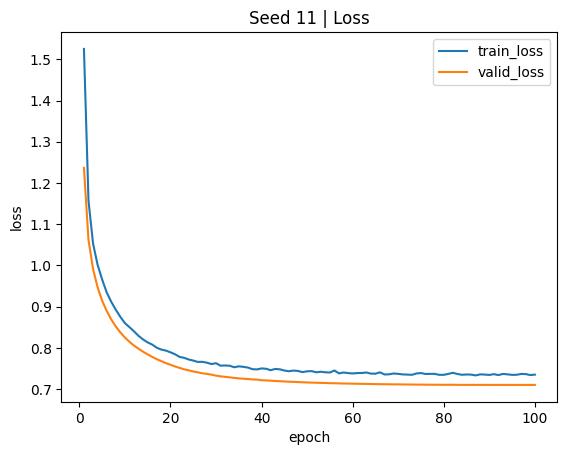

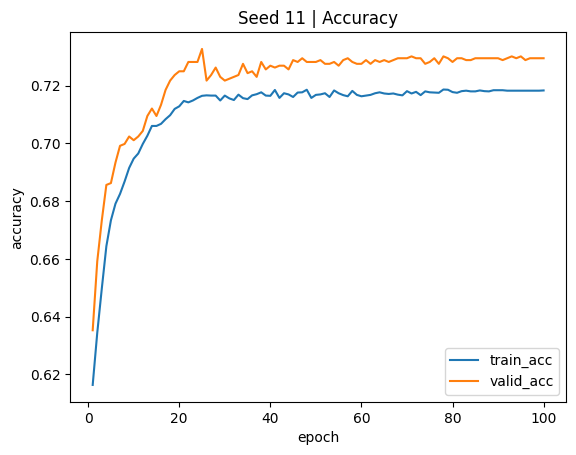

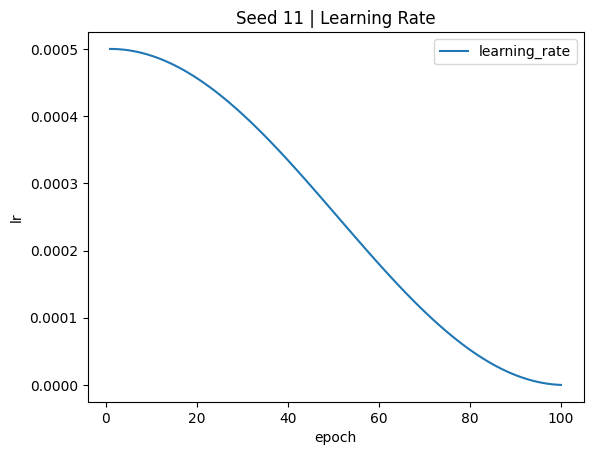


Seed 22 | Linear Probe


Epoch 01/100 | train_loss=1.5514 valid_loss=1.2604 | train_acc=0.6681 valid_acc=0.7062


Epoch 02/100 | train_loss=1.1003 valid_loss=0.9907 | train_acc=0.6984 valid_acc=0.7203


Epoch 03/100 | train_loss=0.9211 valid_loss=0.8765 | train_acc=0.7102 valid_acc=0.7267


Epoch 04/100 | train_loss=0.8368 valid_loss=0.8181 | train_acc=0.7247 valid_acc=0.7338


...

Epoch 96/100 | train_loss=0.5797 valid_loss=0.6217 | train_acc=0.7923 valid_acc=0.7729


Epoch 97/100 | train_loss=0.5798 valid_loss=0.6217 | train_acc=0.7924 valid_acc=0.7729


Epoch 98/100 | train_loss=0.5796 valid_loss=0.6217 | train_acc=0.7924 valid_acc=0.7729


Epoch 99/100 | train_loss=0.5798 valid_loss=0.6217 | train_acc=0.7924 valid_acc=0.7729


Epoch 100/100 | train_loss=0.5799 valid_loss=0.6217 | train_acc=0.7924 valid_acc=0.7729
Saved Stage-2 best head: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_22.pt


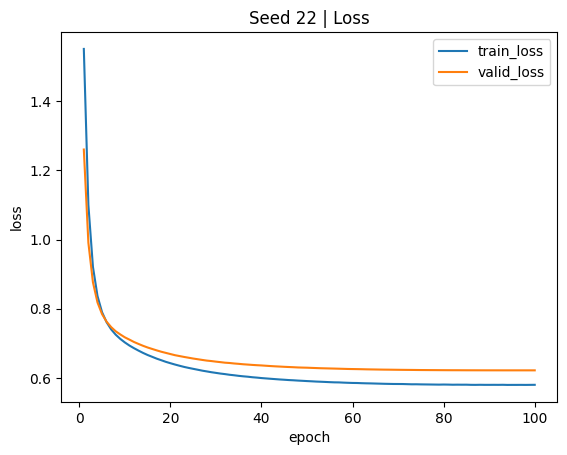

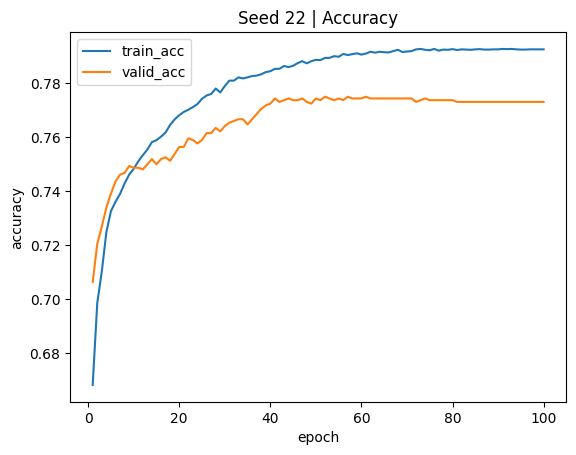

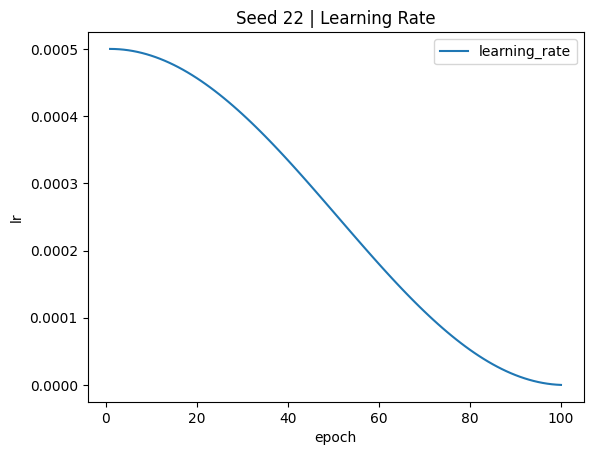


Seed 33 | Linear Probe


Epoch 01/100 | train_loss=1.5140 valid_loss=1.2493 | train_acc=0.6217 valid_acc=0.6465


Epoch 02/100 | train_loss=1.1158 valid_loss=1.0627 | train_acc=0.6474 valid_acc=0.6544


Epoch 03/100 | train_loss=0.9965 valid_loss=0.9884 | train_acc=0.6623 valid_acc=0.6656


Epoch 04/100 | train_loss=0.9401 valid_loss=0.9452 | train_acc=0.6823 valid_acc=0.6800


...

Epoch 96/100 | train_loss=0.6834 valid_loss=0.7046 | train_acc=0.7477 valid_acc=0.7352


Epoch 97/100 | train_loss=0.6828 valid_loss=0.7046 | train_acc=0.7477 valid_acc=0.7352


Epoch 98/100 | train_loss=0.6836 valid_loss=0.7046 | train_acc=0.7477 valid_acc=0.7352


Epoch 99/100 | train_loss=0.6844 valid_loss=0.7045 | train_acc=0.7477 valid_acc=0.7352


Epoch 100/100 | train_loss=0.6832 valid_loss=0.7045 | train_acc=0.7477 valid_acc=0.7352
Saved Stage-2 best head: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_33.pt


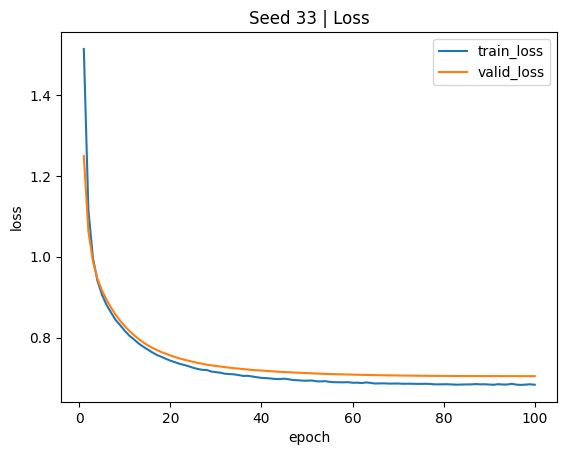

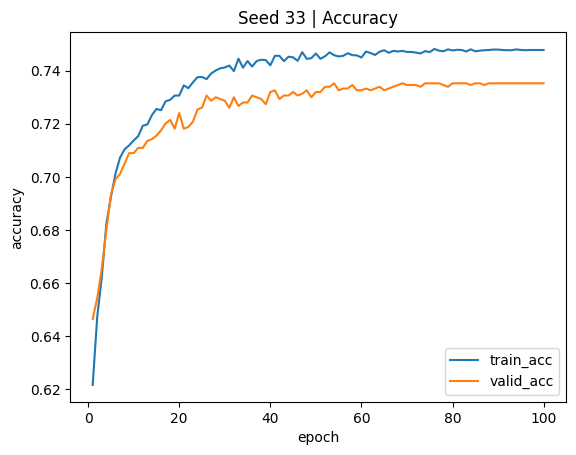

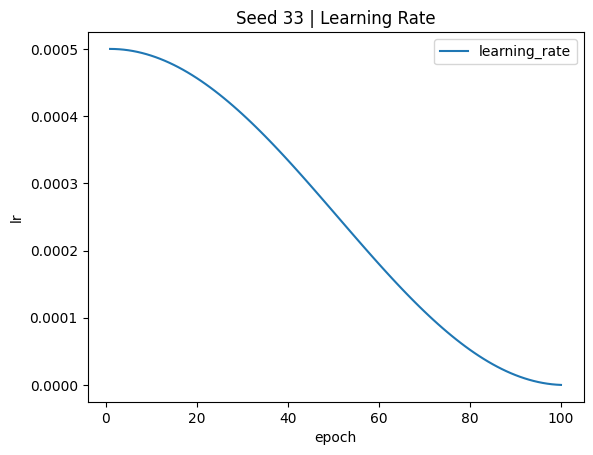


Seed 44 | Linear Probe


Epoch 01/100 | train_loss=1.5738 valid_loss=1.2651 | train_acc=0.6551 valid_acc=0.6919


Epoch 02/100 | train_loss=1.1280 valid_loss=0.9811 | train_acc=0.6985 valid_acc=0.7165


Epoch 03/100 | train_loss=0.9330 valid_loss=0.8504 | train_acc=0.7195 valid_acc=0.7346


Epoch 04/100 | train_loss=0.8361 valid_loss=0.7819 | train_acc=0.7310 valid_acc=0.7437


...

Epoch 96/100 | train_loss=0.5841 valid_loss=0.5858 | train_acc=0.7932 valid_acc=0.7942


Epoch 97/100 | train_loss=0.5841 valid_loss=0.5858 | train_acc=0.7932 valid_acc=0.7942


Epoch 98/100 | train_loss=0.5834 valid_loss=0.5858 | train_acc=0.7932 valid_acc=0.7942


Epoch 99/100 | train_loss=0.5839 valid_loss=0.5858 | train_acc=0.7932 valid_acc=0.7942


Epoch 100/100 | train_loss=0.5841 valid_loss=0.5858 | train_acc=0.7932 valid_acc=0.7942
Saved Stage-2 best head: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_44.pt


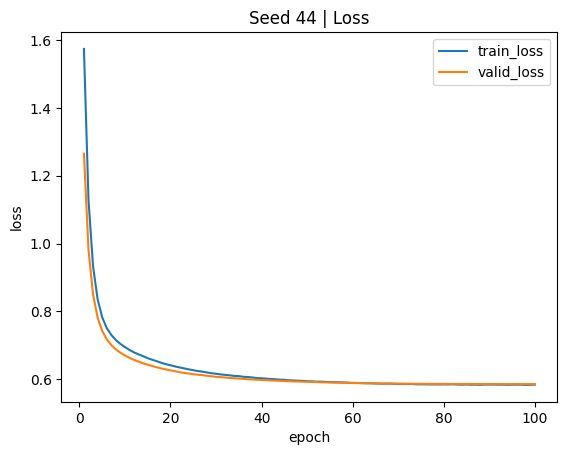

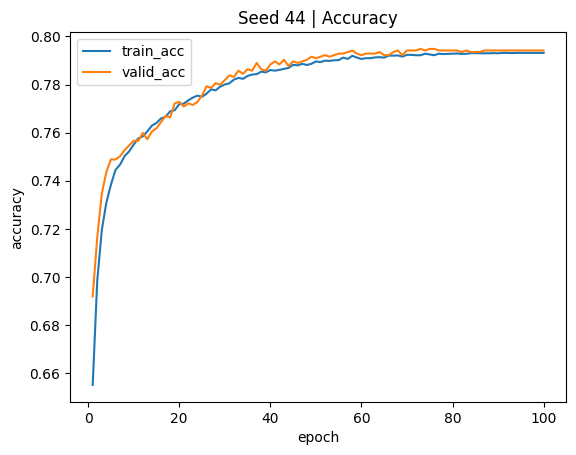

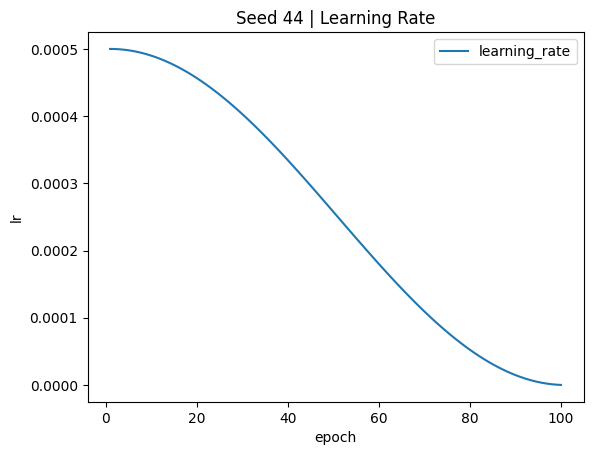


Seed 55 | Linear Probe


Epoch 01/100 | train_loss=1.6963 valid_loss=1.5014 | train_acc=0.4974 valid_acc=0.5395


Epoch 02/100 | train_loss=1.3964 valid_loss=1.3265 | train_acc=0.5822 valid_acc=0.6021


Epoch 03/100 | train_loss=1.2677 valid_loss=1.2324 | train_acc=0.6133 valid_acc=0.6252


Epoch 04/100 | train_loss=1.1858 valid_loss=1.1649 | train_acc=0.6258 valid_acc=0.6364


...

Epoch 96/100 | train_loss=0.7991 valid_loss=0.8251 | train_acc=0.7013 valid_acc=0.7161


Epoch 97/100 | train_loss=0.7994 valid_loss=0.8251 | train_acc=0.7013 valid_acc=0.7161


Epoch 98/100 | train_loss=0.7991 valid_loss=0.8251 | train_acc=0.7013 valid_acc=0.7161


Epoch 99/100 | train_loss=0.7997 valid_loss=0.8251 | train_acc=0.7013 valid_acc=0.7161


Epoch 100/100 | train_loss=0.7991 valid_loss=0.8251 | train_acc=0.7013 valid_acc=0.7161
Saved Stage-2 best head: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_55.pt


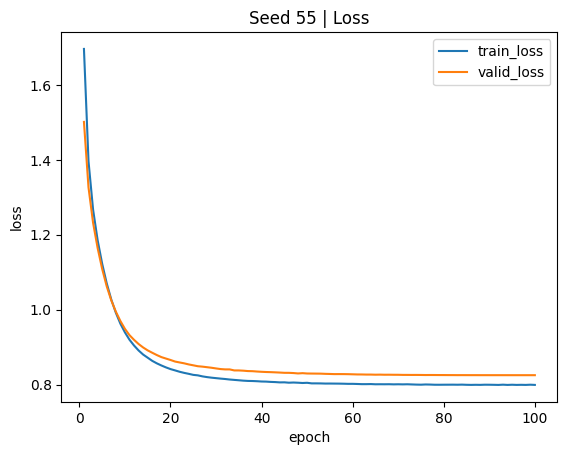

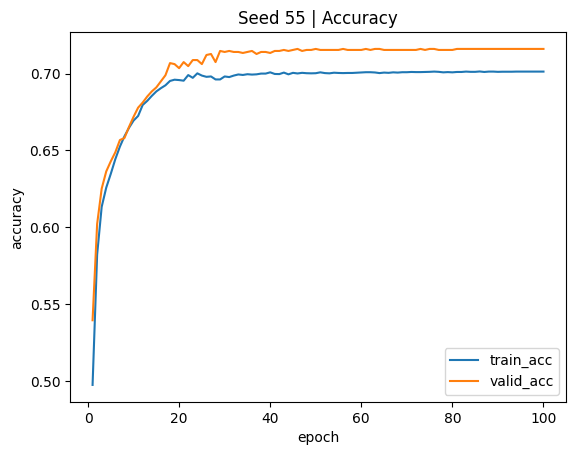

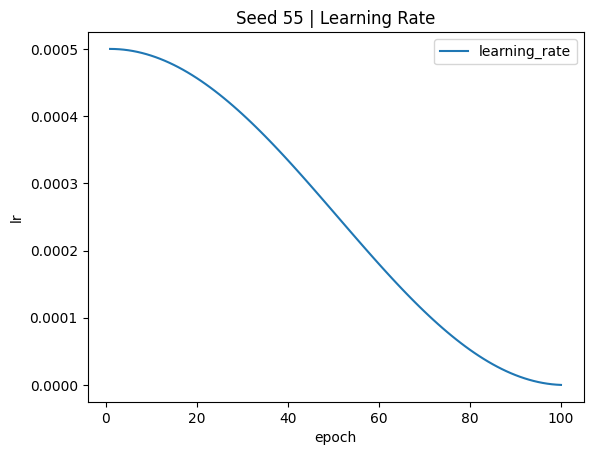


Stage-2 training done. Best head checkpoints:
{11: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_11.pt', 22: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_22.pt', 33: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_33.pt', 44: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_44.pt', 55: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_lp_best_head_seed_55.pt'}

Stage-2 history files:
{11: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_11_train_history.json', 22: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_22_train_history.json', 33: '/content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_33_tra

In [ ]:
# ============================================================
# Stage 2 — Linear Probe Training (5 seeds) + LR charts
# Data source:
#   - Local folders: /content/seed_{seed}_{train|valid|test}_images
# Model source:
#   - Backbone weights come from Stage-1 checkpoints:
#       OUTPUT_ROOT/stage1_color_finetune/stage1_color_best_seed_{seed}.pt
# Output:
#   - Saves best linear head per seed
#   - Saves per-seed training history JSON
#   - Shows LR / loss / acc charts
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import clip

# -----------------------------
# Config
# -----------------------------
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
OUTPUT_ROOT = DRIVE_BASE_DIR / "TwoStage_LP_results"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

STAGE1_DIR = OUTPUT_ROOT / "stage1_color_finetune"
STAGE2_DIR = OUTPUT_ROOT / "stage2_linearprobe"
STAGE2_DIR.mkdir(parents=True, exist_ok=True)

SEEDS = [11, 22, 33, 44, 55]

ID_COL = "image_id"
COLOR_COL = "color"

BATCH_SIZE = STAGE2_BATCH_SIZE
EPOCHS = STAGE2_EPOCHS
LR = STAGE2_LR
WEIGHT_DECAY = STAGE2_WEIGHT_DECAY

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_DTYPE = torch.float32

print("device:", DEVICE)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

# -----------------------------
# Utilities: use pre-staged local folders only
# -----------------------------
LOCAL_BASE_DIR = Path("/content")

def get_local_split_dir(seed: int, split: str) -> Path:
    """
    Use your pre-copied local folders:
      /content/seed_{seed}_{split}_images
    """
    dst = LOCAL_BASE_DIR / f"seed_{seed}_{split}_images"
    if not dst.exists():
        raise FileNotFoundError(
            f"Local staged folder not found: {dst}\n"
            f"You said you already ran cp -r. Please confirm this split was copied."
        )
    return dst

def build_split_df(seed: int, split: str, image_dir: Path) -> pd.DataFrame:
    """
    Reads split CSV and attaches an absolute local image path.
    Expected CSV has at least [image_id] and [COLOR_COL].
    """
    csv_path = DRIVE_BASE_DIR / f"seed_{seed}" / split / f"{split}.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing split CSV: {csv_path}")

    df = pd.read_csv(csv_path, encoding="utf-8-sig")

    if ID_COL not in df.columns:
        raise ValueError(f"{csv_path} missing required column: {ID_COL}")
    if COLOR_COL not in df.columns:
        raise ValueError(
            f"{csv_path} missing required column: {COLOR_COL}. "
            f"Set COLOR_COL to the correct column name."
        )

    df["path"] = df[ID_COL].astype(str).str.strip() + ".jpg"
    df["path"] = df["path"].apply(lambda n: str(image_dir / n))
    return df

# -----------------------------
# Dataset / Loader
# -----------------------------
clip_ref, preprocess = clip.load("ViT-B/32", device=DEVICE, jit=False)
clip_ref = clip_ref.float().eval()

@torch.no_grad()
def encode_images(backbone, x):
    feats = backbone.encode_image(x.to(DEVICE, non_blocking=True))
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.float()

class ColorSplitDataset(torch.utils.data.Dataset):
    """
    Returns:
      image_tensor, label_index, image_id(str)
    """
    def __init__(self, frame: pd.DataFrame, class_to_idx: dict):
        self.f = frame.reset_index(drop=True)
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.f)

    def __getitem__(self, i):
        r = self.f.iloc[i]
        img_path = r["path"]
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Missing image file: {img_path}")

        img = preprocess(Image.open(img_path).convert("RGB"))
        lab = str(r[COLOR_COL]).strip().lower()
        y = self.class_to_idx[lab]
        return img, torch.tensor(y, dtype=torch.long), str(r[ID_COL])

def make_loader(ds, shuffle: bool):
    return torch.utils.data.DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=2 if DEVICE == "cuda" else 0,
        pin_memory=(DEVICE == "cuda"),
        drop_last=False,
    )

# -----------------------------
# Training/eval epoch
# -----------------------------
def train_or_eval_epoch_lp(backbone, head, loader, optimizer=None):
    train_mode = optimizer is not None
    backbone.eval()
    head.train() if train_mode else head.eval()

    ce = nn.CrossEntropyLoss()
    total_loss = 0.0
    correct = 0
    count = 0

    for images, y, _ids in tqdm(
        loader,
        desc=("stage2/train" if train_mode else "stage2/valid"),
        leave=False
    ):
        images = images.to(DEVICE, non_blocking=True).to(dtype=TORCH_DTYPE)
        y = y.to(DEVICE, non_blocking=True)

        feats = encode_images(backbone, images).to(dtype=TORCH_DTYPE)
        logits = head(feats)
        loss = ce(logits, y)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        total_loss += float(loss.item())
        pred = logits.argmax(dim=-1)
        correct += int((pred == y).sum().item())
        count += int(y.numel())

    return total_loss / max(1, len(loader)), (correct / max(1, count))

def plot_seed_curves(seed: int, hist: dict):
    epochs = np.arange(1, len(hist["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, hist["train_loss"], label="train_loss")
    plt.plot(epochs, hist["valid_loss"], label="valid_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"Seed {seed} | Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, hist["train_acc"], label="train_acc")
    plt.plot(epochs, hist["valid_acc"], label="valid_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(f"Seed {seed} | Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, hist["lr"], label="learning_rate")
    plt.xlabel("epoch")
    plt.ylabel("lr")
    plt.title(f"Seed {seed} | Learning Rate")
    plt.legend()
    plt.show()

# -----------------------------
# Main loop: 5 seeds
# -----------------------------
stage2_best_head_paths = {}
stage2_hist_paths = {}

for seed in SEEDS:
    print("\n===============================")
    print(f"Seed {seed} | Linear Probe")
    print("===============================")

    # 1) Use pre-staged local image dirs (NO COPY)
    train_img_dir = get_local_split_dir(seed, "train")
    valid_img_dir = get_local_split_dir(seed, "valid")
    _test_img_dir  = get_local_split_dir(seed, "test")  # not used here, but validated

    # 2) Read split CSVs and attach local paths
    train_df = build_split_df(seed, "train", train_img_dir)
    valid_df = build_split_df(seed, "valid", valid_img_dir)

    train_df[COLOR_COL] = train_df[COLOR_COL].astype(str).str.strip().str.lower()
    valid_df[COLOR_COL] = valid_df[COLOR_COL].astype(str).str.strip().str.lower()

    # 3) Load Stage-1 checkpoint for this seed
    stage1_ckpt_path = STAGE1_DIR / f"stage1_color_best_seed_{seed}.pt"
    ckpt = torch.load(stage1_ckpt_path, map_location="cpu")

    stage1_classes = ckpt.get("classes", None)
    if stage1_classes is None:
        stage1_classes = sorted(train_df[COLOR_COL].unique().tolist())

    class_to_idx = {c: i for i, c in enumerate(stage1_classes)}

    # Filter to Stage-1 classes only (safety)
    train_df = train_df[train_df[COLOR_COL].isin(stage1_classes)].reset_index(drop=True)
    valid_df = valid_df[valid_df[COLOR_COL].isin(stage1_classes)].reset_index(drop=True)

    if len(train_df) == 0 or len(valid_df) == 0:
        raise ValueError(
            f"Seed {seed}: empty train/valid after filtering to Stage-1 classes. "
            f"Check your split CSV label values vs Stage-1 classes."
        )

    # 4) Build datasets/loaders
    train_ds = ColorSplitDataset(train_df, class_to_idx)
    valid_ds = ColorSplitDataset(valid_df, class_to_idx)

    train_dl = make_loader(train_ds, shuffle=True)
    valid_dl = make_loader(valid_ds, shuffle=False)

    # 5) Load Stage-1 backbone weights
    backbone, _ = clip.load("ViT-B/32", device=DEVICE, jit=False)
    backbone = backbone.float()
    backbone.load_state_dict(ckpt["clip_state_dict"], strict=True)

    for p in backbone.parameters():
        p.requires_grad = False
    backbone.eval()

    # 6) Train linear head
    feat_dim = backbone.visual.output_dim
    head = nn.Linear(feat_dim, len(stage1_classes)).to(DEVICE, dtype=TORCH_DTYPE)

    optimizer = optim.AdamW(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    hist = {"train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": [], "lr": []}

    best_valid_acc = float("-inf")
    best_head_state = None

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_or_eval_epoch_lp(backbone, head, train_dl, optimizer=optimizer)
        va_loss, va_acc = train_or_eval_epoch_lp(backbone, head, valid_dl, optimizer=None)

        hist["train_loss"].append(tr_loss)
        hist["valid_loss"].append(va_loss)
        hist["train_acc"].append(tr_acc)
        hist["valid_acc"].append(va_acc)
        hist["lr"].append(float(optimizer.param_groups[0]["lr"]))

        if va_acc > best_valid_acc:
            best_valid_acc = va_acc
            best_head_state = {k: v.detach().cpu() for k, v in head.state_dict().items()}

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={tr_loss:.4f} valid_loss={va_loss:.4f} | "
            f"train_acc={tr_acc:.4f} valid_acc={va_acc:.4f}"
        )

        scheduler.step()

    # 7) Save best head checkpoint for inference cell
    best_head_path = STAGE2_DIR / f"stage2_lp_best_head_seed_{seed}.pt"
    torch.save(
        {
            "seed": seed,
            "classes": stage1_classes,
            "feat_dim": int(feat_dim),
            "best_valid_acc": float(best_valid_acc),
            "head_state_dict": best_head_state,
        },
        best_head_path
    )
    stage2_best_head_paths[seed] = str(best_head_path)
    print("Saved Stage-2 best head:", best_head_path)

    # 8) Save history
    hist_path = STAGE2_DIR / f"stage2_seed_{seed}_train_history.json"
    with hist_path.open("w", encoding="utf-8") as f:
        json.dump(hist, f, ensure_ascii=False, indent=2)
    stage2_hist_paths[seed] = str(hist_path)

    # 9) Plot curves
    plot_seed_curves(seed, hist)

print("\nStage-2 training done. Best head checkpoints:")
print(stage2_best_head_paths)
print("\nStage-2 history files:")
print(stage2_hist_paths)

In [ ]:
# ============================================================
# Inference + Evaluation (5 seeds) + mean±std summary (COLOR ONLY)
# Data source:
#   - Local folders: /content/seed_{seed}_test_images  (pre-staged)
# Model source:
#   - Backbone from Stage-1 checkpoint per seed
#   - Best linear head from Stage-2 checkpoint per seed
# Output:
#   - Saves per-seed predictions CSV
#   - Saves per-seed eval JSON
#   - Prints per-seed results
#   - Prints summary table (mean ± std over 5 seeds)
# ============================================================

import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import torch
import torch.nn as nn
import clip

# -----------------------------
# Config
# -----------------------------
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
OUTPUT_ROOT = DRIVE_BASE_DIR / "TwoStage_LP_results"

STAGE1_DIR = OUTPUT_ROOT / "stage1_color_finetune"
STAGE2_DIR = OUTPUT_ROOT / "stage2_linearprobe"
STAGE2_DIR.mkdir(parents=True, exist_ok=True)

SEEDS = [11, 22, 33, 44, 55]

ID_COL = "image_id"
COLOR_COL = "color"

# Must match your Stage-2 training settings
BATCH_SIZE = STAGE2_BATCH_SIZE

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_DTYPE = torch.float32

print("device:", DEVICE)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True

# -----------------------------
# Utilities: use pre-staged local folder only
# -----------------------------
LOCAL_BASE_DIR = Path("/content")

def get_local_test_dir(seed: int) -> Path:
    """
    Use your pre-copied local folders:
      /content/seed_{seed}_test_images
    """
    dst = LOCAL_BASE_DIR / f"seed_{seed}_test_images"
    if not dst.exists():
        raise FileNotFoundError(
            f"Local staged folder not found: {dst}\n"
            f"Please confirm you already ran cp -r for test split."
        )
    return dst

def build_test_df(seed: int, image_dir: Path) -> pd.DataFrame:
    """
    Reads test CSV and attaches an absolute local image path.
    Expected CSV has at least [image_id] and [color].
    """
    csv_path = DRIVE_BASE_DIR / f"seed_{seed}" / "test" / "test.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing test CSV: {csv_path}")

    df = pd.read_csv(csv_path, encoding="utf-8-sig")

    if ID_COL not in df.columns:
        raise ValueError(f"{csv_path} missing required column: {ID_COL}")
    if COLOR_COL not in df.columns:
        raise ValueError(f"{csv_path} missing required column: {COLOR_COL}")

    df[ID_COL] = df[ID_COL].astype(str).str.strip()
    df[COLOR_COL] = df[COLOR_COL].astype(str).str.strip().str.lower()

    df["path"] = (df[ID_COL] + ".jpg").apply(lambda n: str(image_dir / n))
    return df

# -----------------------------
# CLIP image encoder
# -----------------------------
@torch.no_grad()
def encode_images(model, imgs):
    feats = model.encode_image(imgs.to(DEVICE, non_blocking=True)).float()
    feats = feats / feats.norm(dim=-1, keepdim=True).clamp(min=1e-6)
    return feats

# -----------------------------
# Dataset/Loader
# -----------------------------
clip_ref, preprocess = clip.load("ViT-B/32", device=DEVICE, jit=False)
clip_ref = clip_ref.float().eval()

class ColorTestSet(torch.utils.data.Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.f = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.f)

    def __getitem__(self, i):
        r = self.f.iloc[i]
        p = r["path"]
        if not os.path.exists(p):
            raise FileNotFoundError(f"Missing image file: {p}")
        img = preprocess(Image.open(p).convert("RGB"))
        return img, str(r[ID_COL]), str(r[COLOR_COL])

def make_loader(df: pd.DataFrame, batch_size: int):
    ds = ColorTestSet(df)
    return torch.utils.data.DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2 if DEVICE == "cuda" else 0,
        pin_memory=(DEVICE == "cuda"),
        drop_last=False,
    )

# -----------------------------
# CLIP text encoder for semantic similarity (optional metric)
# -----------------------------
clip_text_model, _ = clip.load("ViT-B/32", device=DEVICE, jit=False)
clip_text_model = clip_text_model.float().eval()

@torch.no_grad()
def embed_text_batch(texts):
    toks = clip.tokenize(texts, truncate=True).to(DEVICE)
    feats = clip_text_model.encode_text(toks).float()
    feats = feats / feats.norm(dim=-1, keepdim=True).clamp(min=1e-6)
    return feats

_embed_cache = {}
def get_text_embed(label: str):
    key = str(label).strip().lower()
    if not key:
        return None
    if key not in _embed_cache:
        _embed_cache[key] = embed_text_batch([key])
    return _embed_cache[key]

def semantic_sim_single(gt_label, pred_label):
    a = get_text_embed(gt_label)
    b = get_text_embed(pred_label)
    if a is None or b is None:
        return np.nan
    return float((a @ b.T).item())

# -----------------------------
# Predict
# -----------------------------
@torch.no_grad()
def predict_color(seed: int, test_df: pd.DataFrame, backbone, head, idx2label, batch_size: int):
    rows = []
    loader = make_loader(test_df, batch_size=batch_size)

    for imgs, ids, _gt_colors in tqdm(loader, desc=f"predict_color(seed={seed})"):
        imgs = imgs.to(DEVICE, non_blocking=True).to(dtype=TORCH_DTYPE)
        feats = encode_images(backbone, imgs).to(dtype=TORCH_DTYPE)
        logits = head(feats)
        pred_idx = logits.argmax(dim=-1).detach().cpu().numpy()

        for i in range(len(ids)):
            rows.append({
                ID_COL: str(ids[i]),
                "color": str(idx2label[int(pred_idx[i])]),
            })

    return pd.DataFrame(rows, columns=[ID_COL, "color"])

# -----------------------------
# Evaluate
# -----------------------------
def evaluate_color(test_df: pd.DataFrame, pred_df: pd.DataFrame):
    gt = test_df[[ID_COL, COLOR_COL]].copy()
    pr = pred_df[[ID_COL, "color"]].copy()

    gt[ID_COL] = gt[ID_COL].astype(str)
    pr[ID_COL] = pr[ID_COL].astype(str)

    df = gt.merge(pr, on=ID_COL, how="inner", suffixes=("_gt", "_pred"))

    # After merge, columns are: color_gt, color_pred
    y_true = df[f"{COLOR_COL}_gt"].astype(str).str.strip().str.lower().tolist()
    y_pred = df[f"{COLOR_COL}_pred"].astype(str).str.strip().str.lower().tolist()

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    sems = [semantic_sim_single(t, p) for t, p in zip(y_true, y_pred)]
    sems = [s for s in sems if not np.isnan(s)]
    sem = float(np.mean(sems)) if sems else float("nan")

    return {
        "color": {
            "accuracy": float(acc),
            "precision_macro": float(prec),
            "recall_macro": float(rec),
            "f1_macro": float(f1),
            "semantic_similarity_clip": float(sem),
        }
    }

def mean_std_str(xs):
    xs = [x for x in xs if x is not None and not (isinstance(x, float) and np.isnan(x))]
    if len(xs) == 0:
        return "-"
    mu = float(np.mean(xs))
    sd = float(np.std(xs, ddof=1)) if len(xs) > 1 else 0.0
    return f"{mu:.3f} ± {sd:.3f}"

# -----------------------------
# Run 5 seeds
# -----------------------------
all_reports = {}

for seed in SEEDS:
    print("\n===============================")
    print(f"Seed {seed} | Inference + Evaluation (Color LP)")
    print("===============================")

    # 1) Use local staged test folder (NO COPY)
    test_img_dir = get_local_test_dir(seed)
    test_df = build_test_df(seed, test_img_dir)

    # 2) Load Stage-1 backbone
    stage1_ckpt_path = STAGE1_DIR / f"stage1_color_best_seed_{seed}.pt"
    ckpt_s1 = torch.load(stage1_ckpt_path, map_location="cpu")

    backbone, _ = clip.load("ViT-B/32", device=DEVICE, jit=False)
    backbone = backbone.float()
    backbone.load_state_dict(ckpt_s1["clip_state_dict"], strict=True)

    for p in backbone.parameters():
        p.requires_grad = False
    backbone.eval()

    feat_dim = backbone.visual.output_dim

    # 3) Load Stage-2 best linear head checkpoint (your current format)
    head_path = STAGE2_DIR / f"stage2_lp_best_head_seed_{seed}.pt"
    ckpt_h = torch.load(head_path, map_location="cpu")

    classes = ckpt_h.get("classes", None)
    if classes is None:
        raise KeyError(f"{head_path} missing 'classes'. Please ensure Stage-2 saved classes.")

    classes = [str(c).strip().lower() for c in classes]
    class_to_idx = {c: i for i, c in enumerate(classes)}
    idx2label = {i: c for c, i in class_to_idx.items()}

    head = nn.Linear(feat_dim, len(classes)).to(DEVICE, dtype=TORCH_DTYPE)
    head.load_state_dict(ckpt_h["head_state_dict"], strict=True)
    head.eval()

    # 4) Filter test_df to Stage-2 classes only (safety)
    test_df_f = test_df[test_df[COLOR_COL].isin(classes)].reset_index(drop=True)
    if len(test_df_f) == 0:
        raise ValueError(
            f"Seed {seed}: empty test after filtering to Stage-2 classes. "
            f"Check your test.csv color values vs Stage-2 classes."
        )

    # 5) Predict
    pred_df = predict_color(
        seed=seed,
        test_df=test_df_f,
        backbone=backbone,
        head=head,
        idx2label=idx2label,
        batch_size=BATCH_SIZE,
    )

    pred_csv_path = STAGE2_DIR / f"stage2_seed_{seed}_pred_color.csv"
    pred_df.to_csv(pred_csv_path, index=False, encoding="utf-8")
    print("Saved predictions:", pred_csv_path)

    # 6) Evaluate
    rep = evaluate_color(test_df_f, pred_df)
    all_reports[seed] = rep

    m = rep["color"]
    print(f"\n===== Seed {seed} Results (Color Linear Probe) =====")
    print(
        f"color: acc={m['accuracy']:.4f}, "
        f"prec_macro={m['precision_macro']:.4f}, "
        f"recall_macro={m['recall_macro']:.4f}, "
        f"f1_macro={m['f1_macro']:.4f}, "
        f"sem_sim={m['semantic_similarity_clip']:.4f}"
    )

    eval_path = STAGE2_DIR / f"stage2_seed_{seed}_eval_color.json"
    with eval_path.open("w", encoding="utf-8") as f:
        json.dump(rep, f, ensure_ascii=False, indent=2)
    print("Saved seed eval:", eval_path)

# -----------------------------
# Summary table (mean ± std)
# -----------------------------
vals_acc  = [all_reports[s]["color"]["accuracy"] for s in SEEDS]
vals_prec = [all_reports[s]["color"]["precision_macro"] for s in SEEDS]
vals_rec  = [all_reports[s]["color"]["recall_macro"] for s in SEEDS]
vals_f1   = [all_reports[s]["color"]["f1_macro"] for s in SEEDS]
vals_sem  = [all_reports[s]["color"]["semantic_similarity_clip"] for s in SEEDS]

df_summary = pd.DataFrame([{
    "Method": "LinearProbe",
    "Attribute": "Color",
    "Accuracy": mean_std_str(vals_acc),
    "Precision (macro)": mean_std_str(vals_prec),
    "Recall (macro)": mean_std_str(vals_rec),
    "F1 (macro)": mean_std_str(vals_f1),
    "Semantic Similarity": mean_std_str(vals_sem),
}], columns=[
    "Method", "Attribute",
    "Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)",
    "Semantic Similarity"
])

print("\n===== Color Linear Probe Summary (mean ± std over 5 seeds) =====")
print(df_summary.to_string(index=False))

device: cuda
gpu: NVIDIA A100-SXM4-40GB

Seed 11 | Inference + Evaluation (Color LP)


predict_color(seed=11): 100%|██████████| 24/24 [00:03<00:00,  7.40it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_11_pred_color.csv

===== Seed 11 Results (Color Linear Probe) =====
color: acc=0.7282, prec_macro=0.6381, recall_macro=0.5260, f1_macro=0.5315, sem_sim=0.9397
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_11_eval_color.json

Seed 22 | Inference + Evaluation (Color LP)


predict_color(seed=22): 100%|██████████| 24/24 [00:03<00:00,  7.39it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_22_pred_color.csv

===== Seed 22 Results (Color Linear Probe) =====
color: acc=0.7773, prec_macro=0.6624, recall_macro=0.6260, f1_macro=0.6330, sem_sim=0.9505
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_22_eval_color.json

Seed 33 | Inference + Evaluation (Color LP)


...

Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_33_pred_color.csv

===== Seed 33 Results (Color Linear Probe) =====
color: acc=0.7412, prec_macro=0.6496, recall_macro=0.5160, f1_macro=0.5418, sem_sim=0.9424
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_33_eval_color.json

Seed 44 | Inference + Evaluation (Color LP)


predict_color(seed=44): 100%|██████████| 25/25 [00:03<00:00,  7.14it/s]


Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_44_pred_color.csv

===== Seed 44 Results (Color Linear Probe) =====
color: acc=0.7970, prec_macro=0.6948, recall_macro=0.6427, f1_macro=0.6623, sem_sim=0.9549
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_44_eval_color.json

Seed 55 | Inference + Evaluation (Color LP)


predict_color(seed=55): 100%|██████████| 25/25 [00:03<00:00,  7.21it/s]

Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_55_pred_color.csv

===== Seed 55 Results (Color Linear Probe) =====
color: acc=0.6764, prec_macro=0.2634, recall_macro=0.2987, f1_macro=0.2795, sem_sim=0.9285
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results/stage2_linearprobe/stage2_seed_55_eval_color.json

===== Color Linear Probe Summary (mean ± std over 5 seeds) =====
     Method Attribute      Accuracy Precision (macro) Recall (macro)    F1 (macro) Semantic Similarity
LinearProbe     Color 0.744 ± 0.047     0.582 ± 0.179  0.522 ± 0.137 0.530 ± 0.151       0.943 ± 0.010


## Factor

#### Load data

In [ ]:
# ============================================================
# Load data
# ============================================================

import os, ast, json, random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import clip

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score

# Seeds
SEEDS = [11, 22, 33, 44, 55]

# Drive paths (match your request)
DRIVE_BASE_DIR = Path("/content/drive/MyDrive/Thesis_Data/0111")
LABEL_LIB = DRIVE_BASE_DIR / "label_library.json"

# Local staging base
LOCAL_BASE_DIR = Path("/content")

# Output root (match notebook style but on Drive)
OUT_ROOT = DRIVE_BASE_DIR / "TwoStage_LP_results_colab"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Subfolders (per notebook structure)
(OUT_ROOT / "tables").mkdir(parents=True, exist_ok=True)

# Notebook variables (kept)
# Stage-1 (color FT / linear probe)
COLOR_FT_DIR = "/content/color_ft_data"
COLOR_FT_CSV = str(DRIVE_BASE_DIR / "color_ft.csv")  # optional
COLOR_MIN_PER_CLASS = 10
COLOR_VALID_RATIO = 0.2

COLOR_BATCH_SIZE = 8
COLOR_EPOCHS     = 150
COLOR_LR         = 1e-3
COLOR_WD         = 0.00
COLOR_LABEL_SMOOTHING = 0.00
UNFREEZE_SCOPE   = "visual"  # "visual" or "all"

# Early stopping (stage-1)
ES_MONITOR   = "acc"
ES_PATIENCE  = 10
ES_MIN_DELTA = 1e-3

# Stage-2 (linear probe)
BATCH_SIZE    = 16
EPOCHS        = 100
LEARNING_RATE = 5e-5

single_attrs = ["category", "sub_category"]
multi_attrs  = ["color", "material", "pattern"]

# Sanity: device print (your requested output style)
print("device:", device)
if device == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

# Load label library (stage-2)
if not LABEL_LIB.exists():
    raise FileNotFoundError(f"label_library.json not found: {LABEL_LIB}")

with LABEL_LIB.open("r", encoding="utf-8-sig") as f:
    label_lib = json.load(f)

label2idx_single = {a: {lab: i for i, lab in enumerate(label_lib[a])} for a in single_attrs}
label2idx_multi  = {a: {lab: i for i, lab in enumerate(label_lib[a])} for a in multi_attrs}
idx2label_single = {a: {i: lab for lab, i in label2idx_single[a].items()} for a in single_attrs}
multi_keys       = {a: list(label2idx_multi[a].keys()) for a in multi_attrs}

# Helpers (kept notebook logic, but made robust for lower/strip)
def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def parse_list_cell(x):
    """Parse list-like strings such as "['red','blue']" into a Python list of strings."""
    s = "" if pd.isna(x) else str(x).strip()
    if s in ("", "[]"):
        return []
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(t).strip().strip("'").strip('"').lower() for t in v if str(t).strip()]
        return [str(v).strip().lower()] if str(v).strip() else []
    except Exception:
        parts = [t.strip().lower() for t in s.split(",")]
        return [p for p in parts if p]

def _resolve_images_dir(maybe_root: Path) -> Path:
    """
    This function returns the correct directory to join with `{image_id}.jpg`.
    """
    if (maybe_root / "images").exists():
        return maybe_root / "images"
    return maybe_root

def _local_split_root(seed: int, split: str) -> Path:
    return LOCAL_BASE_DIR / f"seed_{seed}_{split}_images"

def build_seed_dataframe(seed: int, split: str) -> pd.DataFrame:
    """
    Match notebook's idea: attach absolute image path from local staged folder.
    CSV path: /content/drive/.../seed_{seed}/{split}/{split}.csv
    """
    csv_path = DRIVE_BASE_DIR / f"seed_{seed}" / split / f"{split}.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing split CSV: {csv_path}")

    df = pd.read_csv(csv_path, encoding="utf-8-sig")
    if "image_id" not in df.columns:
        raise ValueError(f"{csv_path} missing required column: image_id")

    # Normalize single labels to lower/strip (robust)
    for a in single_attrs:
        if a not in df.columns:
            raise ValueError(f"{csv_path} missing column: {a}")
        df[a] = df[a].astype(str).str.strip().str.lower()
        df.loc[df[a].isin(["", "nan"]), a] = ""

    # Keep raw multi columns but ensure they exist
    for a in multi_attrs:
        if a not in df.columns:
            raise ValueError(f"{csv_path} missing column: {a}")

    img_root = _resolve_images_dir(_local_split_root(seed, split))
    df["image_id"] = df["image_id"].astype(str).str.strip()
    df["path"] = (df["image_id"] + ".jpg").apply(lambda n: str(img_root / n))
    return df

# Stage-1 color FT index loader (same logic as notebook)
def list_images_in_dir(root_dir: str):
    """Walk COLOR_FT_DIR/<label>/*.{jpg,png,...} and return list of (path, color)."""
    IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    rows = []
    root = Path(root_dir)
    if not root.exists():
        return rows
    for label_dir in sorted([p for p in root.iterdir() if p.is_dir()]):
        label = label_dir.name.strip().lower()
        for img in label_dir.rglob("*"):
            if img.suffix.lower() in IMG_EXTS:
                rows.append((str(img), label))
    return rows

def load_color_ft_index():
    """Load from CSV (path,color); otherwise fallback to directory layout."""
    csv_p = Path(COLOR_FT_CSV)
    if csv_p.exists():
        df = pd.read_csv(csv_p)
        if not {"path", "color"}.issubset(df.columns):
            raise ValueError("COLOR_FT_CSV must contain columns: path,color")
        df = df[["path", "color"]].copy()
        df["path"] = df["path"].astype(str)
        df["color"] = df["color"].astype(str).str.strip().str.lower()
        return df
    pairs = list_images_in_dir(COLOR_FT_DIR)
    if not pairs:
        raise FileNotFoundError(
            "No color fine-tune data found. Provide COLOR_FT_CSV with columns (path,color) "
            "or prepare folders under /content/color_ft_data/<color>/*.jpg."
        )
    df = pd.DataFrame(pairs, columns=["path", "color"])
    df["color"] = df["color"].astype(str).str.strip().str.lower()
    return df

color_index = load_color_ft_index()
counts = color_index["color"].value_counts()
keep = set(counts[counts >= COLOR_MIN_PER_CLASS].index.tolist())
color_index = color_index[color_index["color"].isin(keep)].reset_index(drop=True)

print("[Stage-1] color classes:", color_index["color"].nunique())
print("[Stage-1] color samples:", len(color_index))
print(color_index["color"].value_counts().head(10))

# Load all seeds dataframes
seed_data = {}
for seed in SEEDS:
    print("\n===============================")
    print(f"Seed {seed} | Staging data")
    print("===============================")

    tr = build_seed_dataframe(seed, "train")
    va = build_seed_dataframe(seed, "valid")
    te = build_seed_dataframe(seed, "test")

    # Basic file existence spot-check (do not scan everything)
    for split_name, df in [("train", tr), ("valid", va), ("test", te)]:
        bad = df["path"].apply(lambda p: not os.path.exists(p)).sum()
        if bad > 0:
            raise FileNotFoundError(f"[Seed {seed}] {split_name}: {bad} images not found (check cp paths).")

    seed_data[seed] = {"train_df": tr, "valid_df": va, "test_df": te}
    print("[Stage-2] train/valid/test shapes:", tr.shape, va.shape, te.shape)

print("\nAll seeds staged and loaded into `seed_data`.")

device: cuda
gpu: NVIDIA A100-SXM4-40GB
[Stage-1] color classes: 10
[Stage-1] color samples: 1000
color
black     100
blue      100
denim     100
floral    100
gold      100
grey      100
pink      100
red       100
white     100
yellow    100
Name: count, dtype: int64

Seed 11 | Staging data
[Stage-2] train/valid/test shapes: (28792, 9) (3599, 9) (3599, 9)

Seed 22 | Staging data
[Stage-2] train/valid/test shapes: (28792, 9) (3599, 9) (3599, 9)

Seed 33 | Staging data
[Stage-2] train/valid/test shapes: (28792, 9) (3599, 9) (3599, 9)

Seed 44 | Staging data
[Stage-2] train/valid/test shapes: (28792, 9) (3599, 9) (3599, 9)

Seed 55 | Staging data
[Stage-2] train/valid/test shapes: (28792, 9) (3599, 9) (3599, 9)

All seeds staged and loaded into `seed_data`.


### Stage 1


Seed 11 | Stage-1 (Color Linear Probe)
====== Training Linear Probe (seed=11, lr=1e-03) ======


Epoch 01/150 | train_loss=2.2491 valid_loss=2.1855 | train_acc=0.3412 valid_acc=0.8150


Epoch 02/150 | train_loss=2.1301 valid_loss=2.0748 | train_acc=0.7500 valid_acc=0.8550


Epoch 03/150 | train_loss=2.0200 valid_loss=1.9720 | train_acc=0.7963 valid_acc=0.8400


Epoch 04/150 | train_loss=1.9160 valid_loss=1.8739 | train_acc=0.8425 valid_acc=0.8500


...

Epoch 24/150 | train_loss=0.8621 valid_loss=0.8792 | train_acc=0.8788 valid_acc=0.8800


Epoch 25/150 | train_loss=0.8377 valid_loss=0.8557 | train_acc=0.8825 valid_acc=0.8800


Epoch 26/150 | train_loss=0.8143 valid_loss=0.8340 | train_acc=0.8850 valid_acc=0.8800


Epoch 27/150 | train_loss=0.7924 valid_loss=0.8133 | train_acc=0.8825 valid_acc=0.8800


Epoch 28/150 | train_loss=0.7715 valid_loss=0.7936 | train_acc=0.8875 valid_acc=0.8800
[EarlyStopping] no improvement in 10 epochs on acc. Stopping at epoch 28.
Saved tuned visual backbone to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_11/best_backbone/clip_visual_color_tuned_seed_11.pt
Saved color best head to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_11/best_head/color_head_seed_11.pt


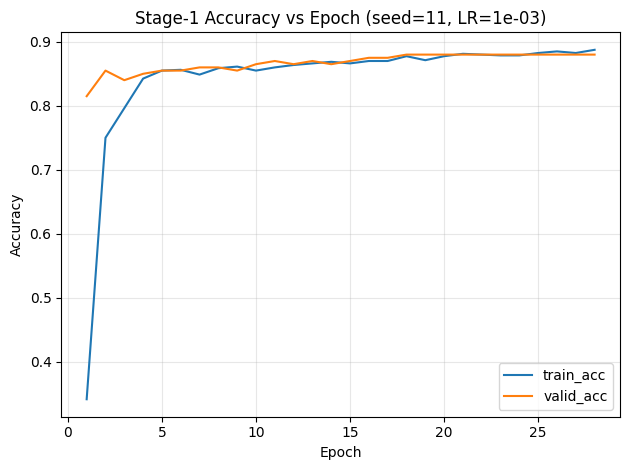

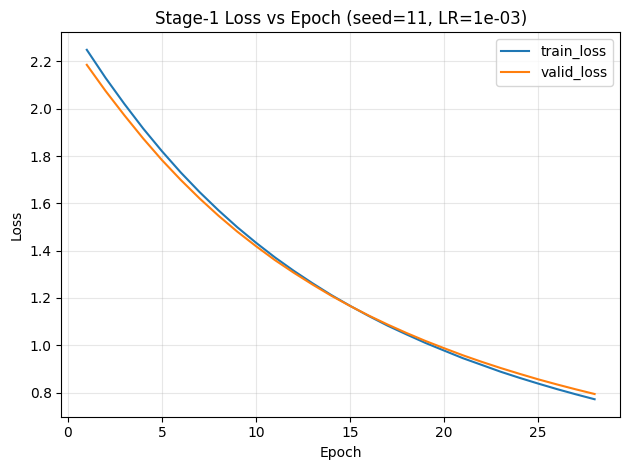


Seed 22 | Stage-1 (Color Linear Probe)
====== Training Linear Probe (seed=22, lr=1e-03) ======


Epoch 01/150 | train_loss=2.2494 valid_loss=2.1864 | train_acc=0.3550 valid_acc=0.6650


Epoch 02/150 | train_loss=2.1309 valid_loss=2.0766 | train_acc=0.7212 valid_acc=0.8450


Epoch 03/150 | train_loss=2.0210 valid_loss=1.9734 | train_acc=0.8413 valid_acc=0.8650


Epoch 04/150 | train_loss=1.9180 valid_loss=1.8771 | train_acc=0.8275 valid_acc=0.8500


...

Epoch 54/150 | train_loss=0.4710 valid_loss=0.5276 | train_acc=0.9000 valid_acc=0.9050


Epoch 55/150 | train_loss=0.4649 valid_loss=0.5221 | train_acc=0.9025 valid_acc=0.9100


Epoch 56/150 | train_loss=0.4587 valid_loss=0.5155 | train_acc=0.9025 valid_acc=0.9100


Epoch 57/150 | train_loss=0.4528 valid_loss=0.5106 | train_acc=0.9025 valid_acc=0.9100


Epoch 58/150 | train_loss=0.4472 valid_loss=0.5054 | train_acc=0.9038 valid_acc=0.9100
[EarlyStopping] no improvement in 10 epochs on acc. Stopping at epoch 58.
Saved tuned visual backbone to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_22/best_backbone/clip_visual_color_tuned_seed_22.pt
Saved color best head to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_22/best_head/color_head_seed_22.pt


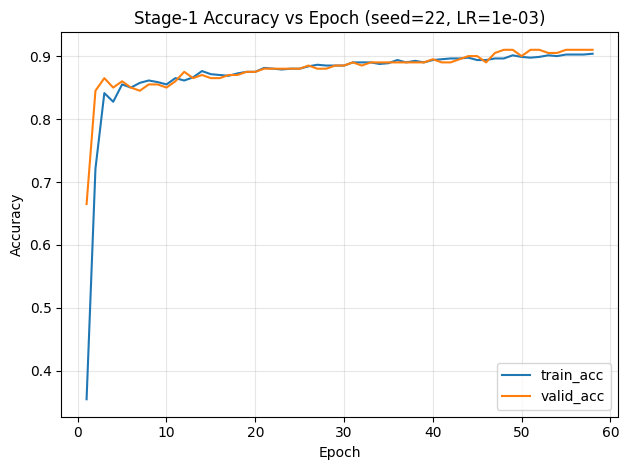

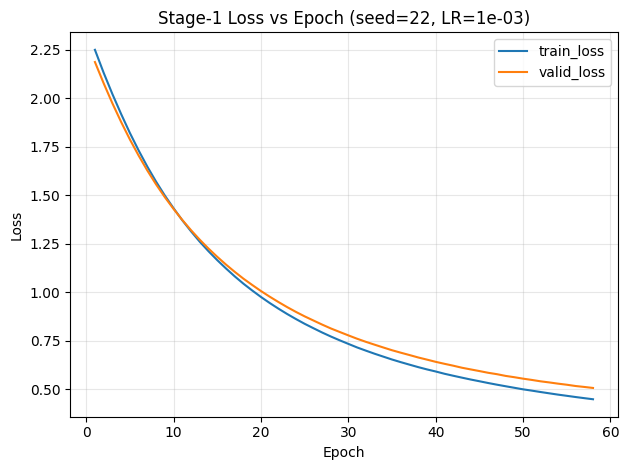


Seed 33 | Stage-1 (Color Linear Probe)
====== Training Linear Probe (seed=33, lr=1e-03) ======


Epoch 01/150 | train_loss=2.2501 valid_loss=2.1863 | train_acc=0.3287 valid_acc=0.7950


Epoch 02/150 | train_loss=2.1310 valid_loss=2.0778 | train_acc=0.8125 valid_acc=0.8100


Epoch 03/150 | train_loss=2.0210 valid_loss=1.9762 | train_acc=0.8363 valid_acc=0.8150


Epoch 04/150 | train_loss=1.9161 valid_loss=1.8798 | train_acc=0.8500 valid_acc=0.8250


...

Epoch 15/150 | train_loss=1.1626 valid_loss=1.1824 | train_acc=0.8638 valid_acc=0.8400


Epoch 16/150 | train_loss=1.1189 valid_loss=1.1422 | train_acc=0.8775 valid_acc=0.8400


Epoch 17/150 | train_loss=1.0780 valid_loss=1.1046 | train_acc=0.8775 valid_acc=0.8400


Epoch 18/150 | train_loss=1.0411 valid_loss=1.0696 | train_acc=0.8750 valid_acc=0.8400


Epoch 19/150 | train_loss=1.0061 valid_loss=1.0363 | train_acc=0.8788 valid_acc=0.8450
[EarlyStopping] no improvement in 10 epochs on acc. Stopping at epoch 19.
Saved tuned visual backbone to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_33/best_backbone/clip_visual_color_tuned_seed_33.pt
Saved color best head to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_33/best_head/color_head_seed_33.pt


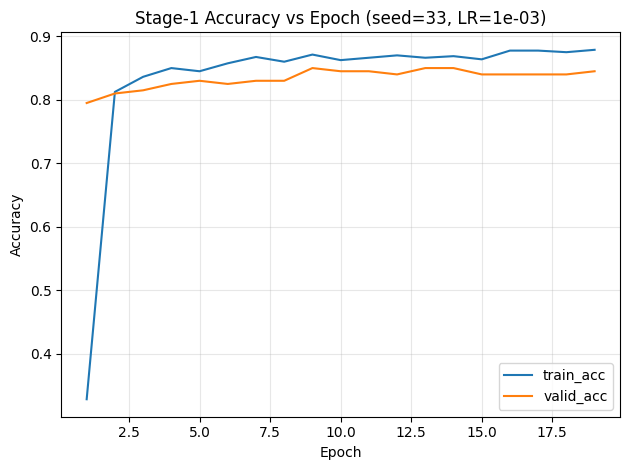

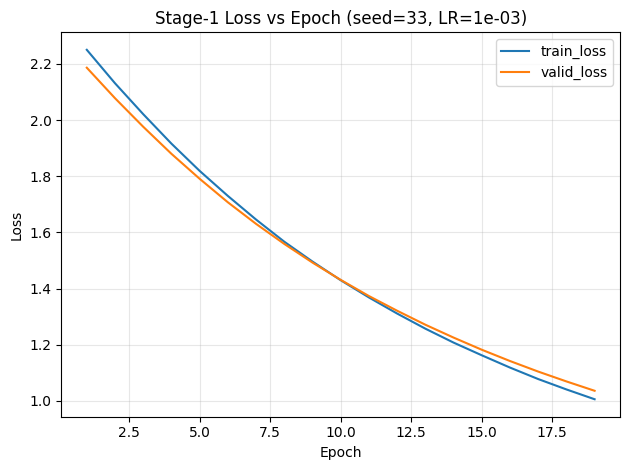


Seed 44 | Stage-1 (Color Linear Probe)
====== Training Linear Probe (seed=44, lr=1e-03) ======


Epoch 01/150 | train_loss=2.2508 valid_loss=2.1849 | train_acc=0.3187 valid_acc=0.6400


Epoch 02/150 | train_loss=2.1321 valid_loss=2.0726 | train_acc=0.7312 valid_acc=0.8500


Epoch 03/150 | train_loss=2.0238 valid_loss=1.9669 | train_acc=0.8050 valid_acc=0.8550


Epoch 04/150 | train_loss=1.9205 valid_loss=1.8689 | train_acc=0.8375 valid_acc=0.8450


...

Epoch 21/150 | train_loss=0.9520 valid_loss=0.9519 | train_acc=0.8838 valid_acc=0.8650


Epoch 22/150 | train_loss=0.9224 valid_loss=0.9239 | train_acc=0.8762 valid_acc=0.8650


Epoch 23/150 | train_loss=0.8950 valid_loss=0.8978 | train_acc=0.8812 valid_acc=0.8650


Epoch 24/150 | train_loss=0.8682 valid_loss=0.8733 | train_acc=0.8838 valid_acc=0.8650


Epoch 25/150 | train_loss=0.8437 valid_loss=0.8503 | train_acc=0.8812 valid_acc=0.8650
[EarlyStopping] no improvement in 10 epochs on acc. Stopping at epoch 25.
Saved tuned visual backbone to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_44/best_backbone/clip_visual_color_tuned_seed_44.pt
Saved color best head to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_44/best_head/color_head_seed_44.pt


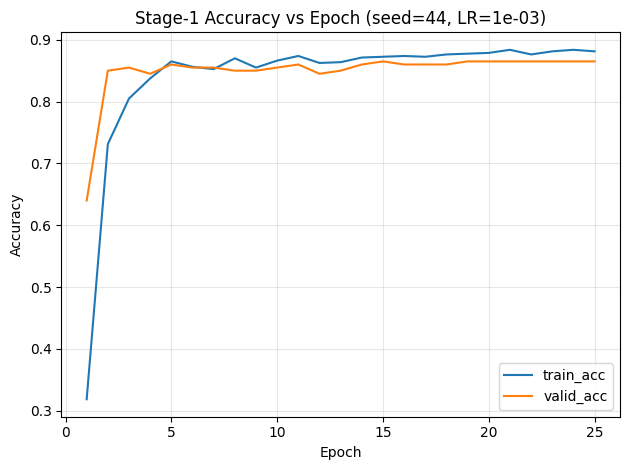

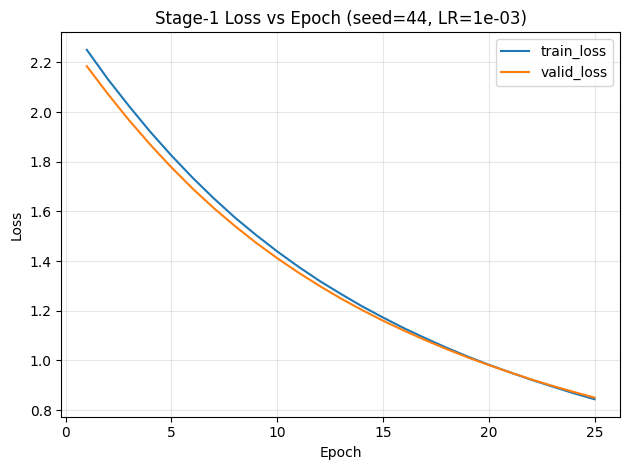


Seed 55 | Stage-1 (Color Linear Probe)
====== Training Linear Probe (seed=55, lr=1e-03) ======


Epoch 01/150 | train_loss=2.2481 valid_loss=2.1880 | train_acc=0.3337 valid_acc=0.7400


Epoch 02/150 | train_loss=2.1280 valid_loss=2.0822 | train_acc=0.7550 valid_acc=0.8200


Epoch 03/150 | train_loss=2.0176 valid_loss=1.9827 | train_acc=0.8325 valid_acc=0.8250


Epoch 04/150 | train_loss=1.9136 valid_loss=1.8887 | train_acc=0.8475 valid_acc=0.8200


...

Epoch 29/150 | train_loss=0.7375 valid_loss=0.8235 | train_acc=0.8838 valid_acc=0.8700


Epoch 30/150 | train_loss=0.7185 valid_loss=0.8065 | train_acc=0.8925 valid_acc=0.8700


Epoch 31/150 | train_loss=0.7003 valid_loss=0.7903 | train_acc=0.8925 valid_acc=0.8650


Epoch 32/150 | train_loss=0.6839 valid_loss=0.7748 | train_acc=0.8888 valid_acc=0.8700


Epoch 33/150 | train_loss=0.6678 valid_loss=0.7612 | train_acc=0.8962 valid_acc=0.8700
[EarlyStopping] no improvement in 10 epochs on acc. Stopping at epoch 33.
Saved tuned visual backbone to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_55/best_backbone/clip_visual_color_tuned_seed_55.pt
Saved color best head to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_55/best_head/color_head_seed_55.pt


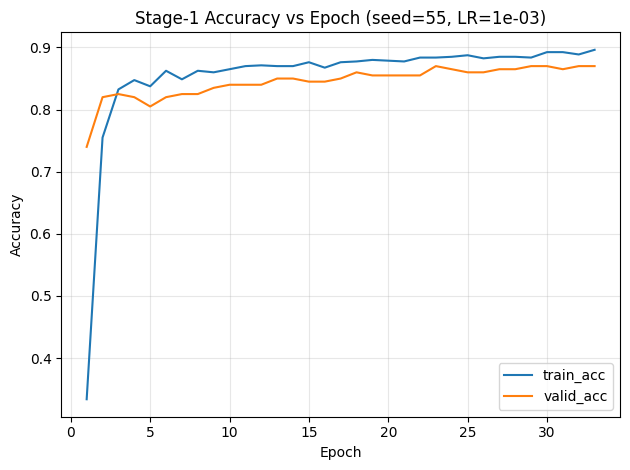

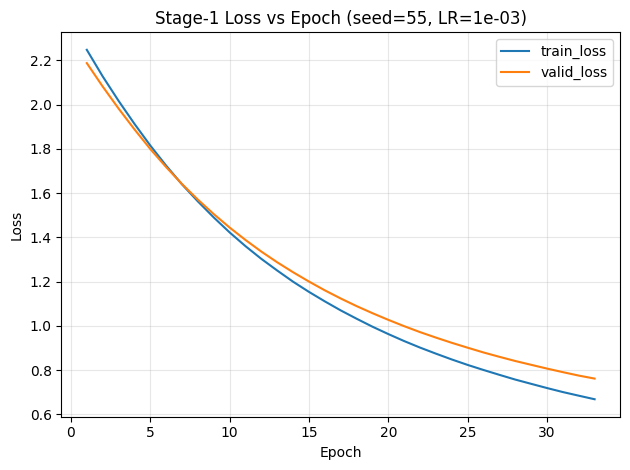


Stage-1 finished for all seeds.


In [ ]:
# ============================================================
# Stage 1: Color linear probe + learning curves + early stopping, for 5 seeds
# ============================================================

import math

def stratified_split(df, label_col="color", valid_ratio=0.2, seed=42):
    rng = np.random.RandomState(seed)
    train_parts, valid_parts = [], []
    for lab, grp in df.groupby(label_col):
        idx = np.arange(len(grp))
        rng.shuffle(idx)
        v = int(round(len(idx) * valid_ratio))
        valid_idx, train_idx = idx[:v], idx[v:]
        g = grp.reset_index(drop=True)
        valid_parts.append(g.loc[valid_idx])
        train_parts.append(g.loc[train_idx])
    return pd.concat(train_parts, ignore_index=True), pd.concat(valid_parts, ignore_index=True)

stage1_paths = {}

for seed in SEEDS:
    print("\n===============================")
    print(f"Seed {seed} | Stage-1 (Color Linear Probe)")
    print("===============================")

    set_all_seeds(seed)

    # Per-seed output folders
    seed_root = OUT_ROOT / f"seed_{seed}"
    (seed_root / "best_backbone").mkdir(parents=True, exist_ok=True)
    (seed_root / "best_head").mkdir(parents=True, exist_ok=True)
    (seed_root / "tables").mkdir(parents=True, exist_ok=True)

    FT_BACKBONE_PATH = str(seed_root / "best_backbone" / f"clip_visual_color_tuned_seed_{seed}.pt")
    COLOR_HEAD_PATH  = str(seed_root / "best_head" / f"color_head_seed_{seed}.pt")

    # Load CLIP for stage-1 (same as notebook)
    model_ft, preprocess_ft = clip.load("ViT-B/32", device=device)

    # Unfreeze scope (same as notebook, but stage-1 uses @torch.no_grad() encoder => head-only)
    if UNFREEZE_SCOPE == "visual":
        for p in model_ft.visual.parameters():
            p.requires_grad = True
        for p in model_ft.transformer.parameters():
            p.requires_grad = False
        for p in model_ft.token_embedding.parameters():
            p.requires_grad = False
        for p in model_ft.ln_final.parameters():
            p.requires_grad = False
    else:
        for p in model_ft.parameters():
            p.requires_grad = True

    model_ft.float()

    # Build dataset/loaders
    class ColorFTSet(torch.utils.data.Dataset):
        def __init__(self, frame: pd.DataFrame):
            self.f = frame.reset_index(drop=True)
            self.colors = sorted(self.f["color"].unique().tolist())
            self.c2i = {c: i for i, c in enumerate(self.colors)}
        def __len__(self):
            return len(self.f)
        def __getitem__(self, i):
            r = self.f.iloc[i]
            img = preprocess_ft(Image.open(r["path"]).convert("RGB"))
            y = self.c2i[r["color"]]
            return img, y

    # Stratified split (per seed)
    color_train, color_valid = stratified_split(color_index, valid_ratio=COLOR_VALID_RATIO, seed=seed)
    train_ds = ColorFTSet(color_train)
    valid_ds = ColorFTSet(color_valid)
    assert train_ds.colors == valid_ds.colors, "Train/valid must share same color label set."

    COLOR_CLASSES = len(train_ds.colors)
    feat_dim = model_ft.visual.output_dim
    color_head = nn.Linear(feat_dim, COLOR_CLASSES).to(device).float()

    train_loader_c = torch.utils.data.DataLoader(
        train_ds, batch_size=COLOR_BATCH_SIZE, shuffle=True,
        num_workers=2 if device == "cuda" else 0,
        pin_memory=(device == "cuda")
    )
    valid_loader_c = torch.utils.data.DataLoader(
        valid_ds, batch_size=COLOR_BATCH_SIZE, shuffle=False,
        num_workers=2 if device == "cuda" else 0,
        pin_memory=(device == "cuda")
    )

    # Loss/optim
    ce_color = nn.CrossEntropyLoss(label_smoothing=COLOR_LABEL_SMOOTHING)
    params = list(color_head.parameters()) + [p for p in model_ft.parameters() if p.requires_grad]
    opt_c = optim.AdamW(params, lr=COLOR_LR, weight_decay=COLOR_WD)

    EPS = 1e-6

    @torch.no_grad()
    def encode_images_ft(imgs):
        f = model_ft.encode_image(imgs.to(device)).float()
        denom = f.norm(dim=-1, keepdim=True).clamp(min=EPS)
        return (f / denom)

    # Train loop (kept notebook prints)
    tr_losses_c, va_losses_c = [], []
    tr_accs_c,   va_accs_c   = [], []
    best_va = -1.0
    best_state = None

    no_improve_count = 0
    if ES_MONITOR == "loss":
        best_monitor_value = float("inf")
    else:
        best_monitor_value = -float("inf")

    print(f"====== Training Linear Probe (seed={seed}, lr={COLOR_LR:.0e}) ======")
    for epoch in range(1, COLOR_EPOCHS + 1):
        # train
        model_ft.train(); color_head.train()
        total_loss, seen, correct = 0.0, 0, 0

        for imgs, y in tqdm(train_loader_c, desc=f"epoch {epoch} train", leave=False):
            feats = encode_images_ft(imgs)
            logits = color_head(feats)
            loss = ce_color(logits, y.to(device).long())

            opt_c.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
            opt_c.step()

            total_loss += float(loss.item())
            pred = logits.argmax(dim=-1).detach().cpu().numpy()
            correct += int((pred == np.array(y)).sum())
            seen += int(len(y))

        tr_losses_c.append(total_loss / max(1, len(train_loader_c)))
        tr_accs_c.append(correct / max(1, seen))

        # valid
        model_ft.eval(); color_head.eval()
        total_loss, seen, correct = 0.0, 0, 0
        with torch.no_grad():
            for imgs, y in tqdm(valid_loader_c, desc=f"epoch {epoch} valid", leave=False):
                feats = encode_images_ft(imgs)
                logits = color_head(feats)
                loss = ce_color(logits, y.to(device).long())
                total_loss += float(loss.item())
                pred = logits.argmax(dim=-1).cpu().numpy()
                correct += int((pred == np.array(y)).sum())
                seen += int(len(y))

        va_losses_c.append(total_loss / max(1, len(valid_loader_c)))
        va_accs_c.append(correct / max(1, seen))

        if va_accs_c[-1] > best_va:
            best_va = va_accs_c[-1]
            best_state = {
                "visual": {k: v.detach().cpu() for k, v in model_ft.visual.state_dict().items()},
                "color_head": {k: v.detach().cpu() for k, v in color_head.state_dict().items()},
                "colors": train_ds.colors
            }

        print(
            f"Epoch {epoch:02d}/{COLOR_EPOCHS} | "
            f"train_loss={tr_losses_c[-1]:.4f} valid_loss={va_losses_c[-1]:.4f} | "
            f"train_acc={tr_accs_c[-1]:.4f} valid_acc={va_accs_c[-1]:.4f}"
        )

        # Early stopping (same logic)
        if ES_MONITOR == "loss":
            current = va_losses_c[-1]
            improved = (best_monitor_value - current) > ES_MIN_DELTA
        else:
            current = va_accs_c[-1]
            improved = (current - best_monitor_value) > ES_MIN_DELTA

        if improved:
            best_monitor_value = current
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= ES_PATIENCE:
            print(f"[EarlyStopping] no improvement in {ES_PATIENCE} epochs on {ES_MONITOR}. Stopping at epoch {epoch}.")
            break

    # Save tuned backbone and color head
    if best_state is None:
        raise RuntimeError(f"[Seed {seed}] No valid best state captured for stage-1.")

    torch.save(best_state, FT_BACKBONE_PATH)
    torch.save({"state_dict": best_state["color_head"], "colors": best_state["colors"]}, COLOR_HEAD_PATH)
    print("Saved tuned visual backbone to:", FT_BACKBONE_PATH)
    print("Saved color best head to:", COLOR_HEAD_PATH)

    # Learning curves (save + show)
    epochs_axis = list(range(1, len(tr_losses_c) + 1))

    plt.figure()
    plt.plot(epochs_axis, tr_accs_c, label="train_acc")
    plt.plot(epochs_axis, va_accs_c, label="valid_acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title(f"Stage-1 Accuracy vs Epoch (seed={seed}, LR={COLOR_LR:.0e})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(epochs_axis, tr_losses_c, label="train_loss")
    plt.plot(epochs_axis, va_losses_c, label="valid_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"Stage-1 Loss vs Epoch (seed={seed}, LR={COLOR_LR:.0e})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.show()

    # Save curves to Drive
    curve_dir = seed_root / "tables"
    acc_png = curve_dir / f"stage1_curve_acc_seed_{seed}.png"
    loss_png = curve_dir / f"stage1_curve_loss_seed_{seed}.png"

    plt.figure()
    plt.plot(epochs_axis, tr_accs_c, label="train_acc")
    plt.plot(epochs_axis, va_accs_c, label="valid_acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title(f"Stage-1 Accuracy vs Epoch (seed={seed}, LR={COLOR_LR:.0e})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(acc_png, dpi=200)
    plt.close()

    plt.figure()
    plt.plot(epochs_axis, tr_losses_c, label="train_loss")
    plt.plot(epochs_axis, va_losses_c, label="valid_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"Stage-1 Loss vs Epoch (seed={seed}, LR={COLOR_LR:.0e})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(loss_png, dpi=200)
    plt.close()

    stage1_paths[seed] = {
        "FT_BACKBONE_PATH": FT_BACKBONE_PATH,
        "COLOR_HEAD_PATH": COLOR_HEAD_PATH
    }

print("\nStage-1 finished for all seeds.")

### Stage 2


Seed 11 | Stage-1 (Color Linear Probe)
====== Training Linear Probe (seed=11, lr=1e-03) ======


Epoch 01/150 | train_loss=2.2491 valid_loss=2.1855 | train_acc=0.3412 valid_acc=0.8150


Epoch 02/150 | train_loss=2.1301 valid_loss=2.0748 | train_acc=0.7500 valid_acc=0.8550


Epoch 03/150 | train_loss=2.0200 valid_loss=1.9720 | train_acc=0.7963 valid_acc=0.8400


Epoch 04/150 | train_loss=1.9160 valid_loss=1.8739 | train_acc=0.8425 valid_acc=0.8500


...

Epoch 24/150 | train_loss=0.8621 valid_loss=0.8792 | train_acc=0.8788 valid_acc=0.8800


Epoch 25/150 | train_loss=0.8377 valid_loss=0.8557 | train_acc=0.8825 valid_acc=0.8800


Epoch 26/150 | train_loss=0.8143 valid_loss=0.8340 | train_acc=0.8850 valid_acc=0.8800


Epoch 27/150 | train_loss=0.7924 valid_loss=0.8133 | train_acc=0.8825 valid_acc=0.8800


Epoch 28/150 | train_loss=0.7715 valid_loss=0.7936 | train_acc=0.8875 valid_acc=0.8800
[EarlyStopping] no improvement in 10 epochs on acc. Stopping at epoch 28.
Saved tuned visual backbone to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_11/best_backbone/clip_visual_color_tuned_seed_11.pt
Saved color best head to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_11/best_head/color_head_seed_11.pt


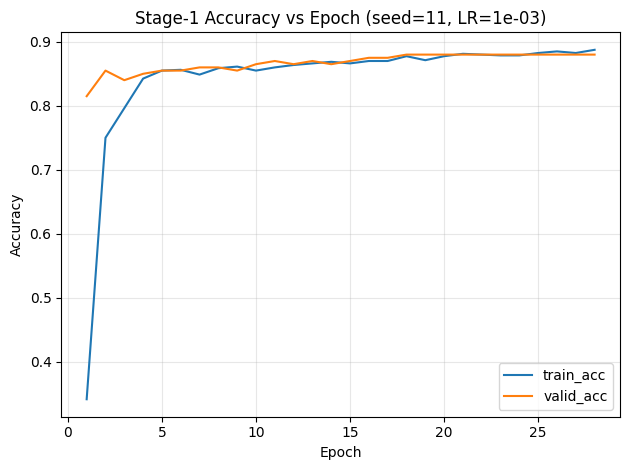

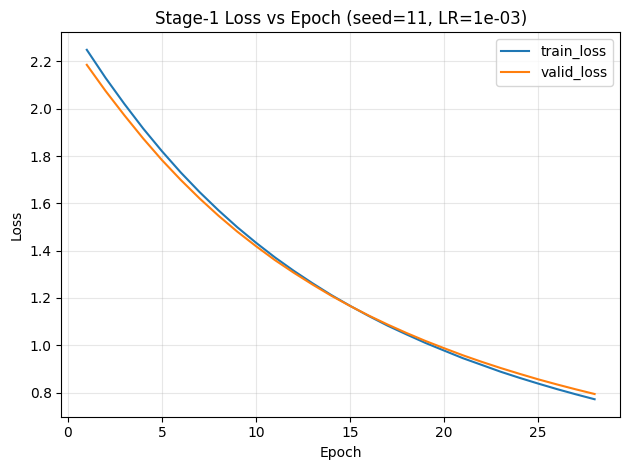


Seed 22 | Stage-1 (Color Linear Probe)
====== Training Linear Probe (seed=22, lr=1e-03) ======


Epoch 01/150 | train_loss=2.2494 valid_loss=2.1864 | train_acc=0.3550 valid_acc=0.6650


Epoch 02/150 | train_loss=2.1309 valid_loss=2.0766 | train_acc=0.7212 valid_acc=0.8450


Epoch 03/150 | train_loss=2.0210 valid_loss=1.9734 | train_acc=0.8413 valid_acc=0.8650


Epoch 04/150 | train_loss=1.9180 valid_loss=1.8771 | train_acc=0.8275 valid_acc=0.8500


...

Epoch 54/150 | train_loss=0.4710 valid_loss=0.5276 | train_acc=0.9000 valid_acc=0.9050


Epoch 55/150 | train_loss=0.4649 valid_loss=0.5221 | train_acc=0.9025 valid_acc=0.9100


Epoch 56/150 | train_loss=0.4587 valid_loss=0.5155 | train_acc=0.9025 valid_acc=0.9100


Epoch 57/150 | train_loss=0.4528 valid_loss=0.5106 | train_acc=0.9025 valid_acc=0.9100


Epoch 58/150 | train_loss=0.4472 valid_loss=0.5054 | train_acc=0.9038 valid_acc=0.9100
[EarlyStopping] no improvement in 10 epochs on acc. Stopping at epoch 58.
Saved tuned visual backbone to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_22/best_backbone/clip_visual_color_tuned_seed_22.pt
Saved color best head to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_22/best_head/color_head_seed_22.pt


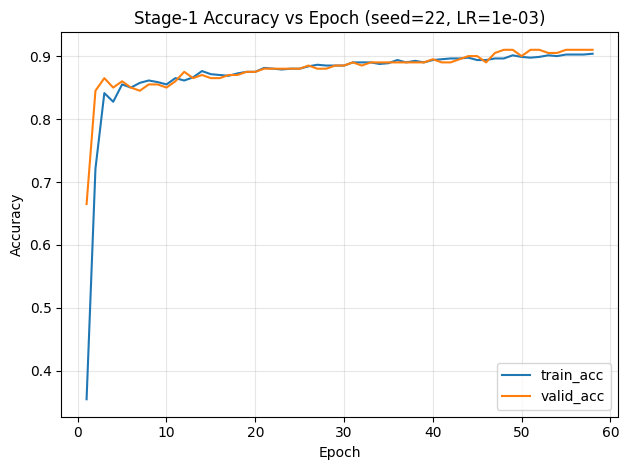

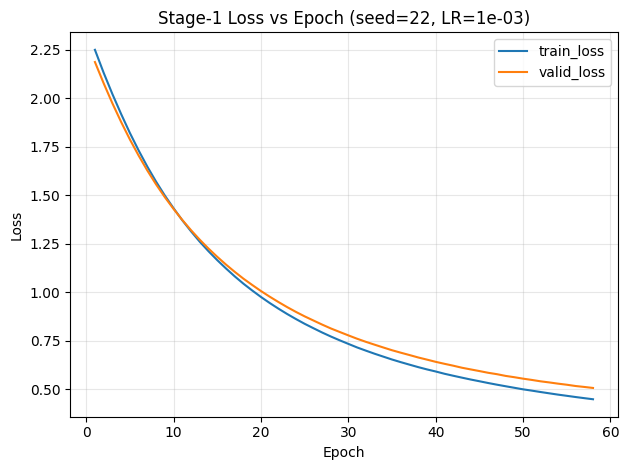


Seed 33 | Stage-1 (Color Linear Probe)
====== Training Linear Probe (seed=33, lr=1e-03) ======


Epoch 01/150 | train_loss=2.2501 valid_loss=2.1863 | train_acc=0.3287 valid_acc=0.7950


Epoch 02/150 | train_loss=2.1310 valid_loss=2.0778 | train_acc=0.8125 valid_acc=0.8100


Epoch 03/150 | train_loss=2.0210 valid_loss=1.9762 | train_acc=0.8363 valid_acc=0.8150


Epoch 04/150 | train_loss=1.9161 valid_loss=1.8798 | train_acc=0.8500 valid_acc=0.8250


...

Epoch 15/150 | train_loss=1.1626 valid_loss=1.1824 | train_acc=0.8638 valid_acc=0.8400


Epoch 16/150 | train_loss=1.1189 valid_loss=1.1422 | train_acc=0.8775 valid_acc=0.8400


Epoch 17/150 | train_loss=1.0780 valid_loss=1.1046 | train_acc=0.8775 valid_acc=0.8400


Epoch 18/150 | train_loss=1.0411 valid_loss=1.0696 | train_acc=0.8750 valid_acc=0.8400


Epoch 19/150 | train_loss=1.0061 valid_loss=1.0363 | train_acc=0.8788 valid_acc=0.8450
[EarlyStopping] no improvement in 10 epochs on acc. Stopping at epoch 19.
Saved tuned visual backbone to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_33/best_backbone/clip_visual_color_tuned_seed_33.pt
Saved color best head to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_33/best_head/color_head_seed_33.pt


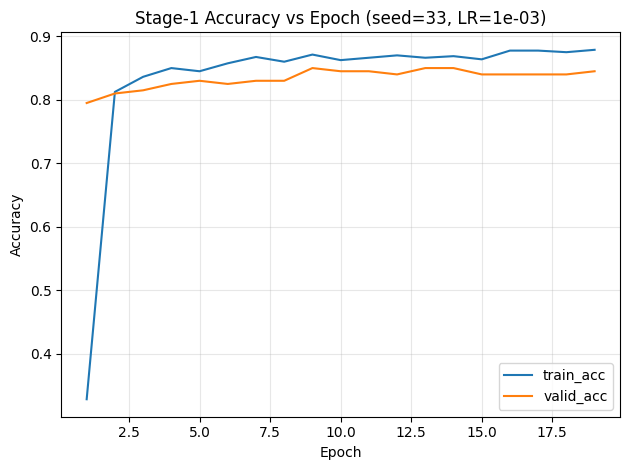

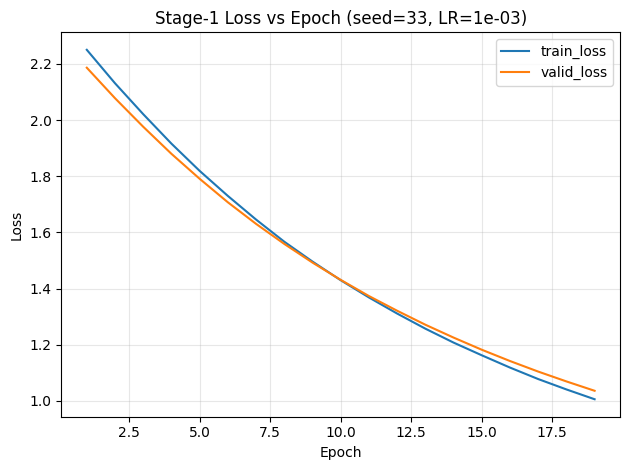


Seed 44 | Stage-1 (Color Linear Probe)
====== Training Linear Probe (seed=44, lr=1e-03) ======


Epoch 01/150 | train_loss=2.2508 valid_loss=2.1849 | train_acc=0.3187 valid_acc=0.6400


Epoch 02/150 | train_loss=2.1321 valid_loss=2.0726 | train_acc=0.7312 valid_acc=0.8500


Epoch 03/150 | train_loss=2.0238 valid_loss=1.9669 | train_acc=0.8050 valid_acc=0.8550


Epoch 04/150 | train_loss=1.9205 valid_loss=1.8689 | train_acc=0.8375 valid_acc=0.8450


...

Epoch 21/150 | train_loss=0.9520 valid_loss=0.9519 | train_acc=0.8838 valid_acc=0.8650


Epoch 22/150 | train_loss=0.9224 valid_loss=0.9239 | train_acc=0.8762 valid_acc=0.8650


Epoch 23/150 | train_loss=0.8950 valid_loss=0.8978 | train_acc=0.8812 valid_acc=0.8650


Epoch 24/150 | train_loss=0.8682 valid_loss=0.8733 | train_acc=0.8838 valid_acc=0.8650


Epoch 25/150 | train_loss=0.8437 valid_loss=0.8503 | train_acc=0.8812 valid_acc=0.8650
[EarlyStopping] no improvement in 10 epochs on acc. Stopping at epoch 25.
Saved tuned visual backbone to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_44/best_backbone/clip_visual_color_tuned_seed_44.pt
Saved color best head to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_44/best_head/color_head_seed_44.pt


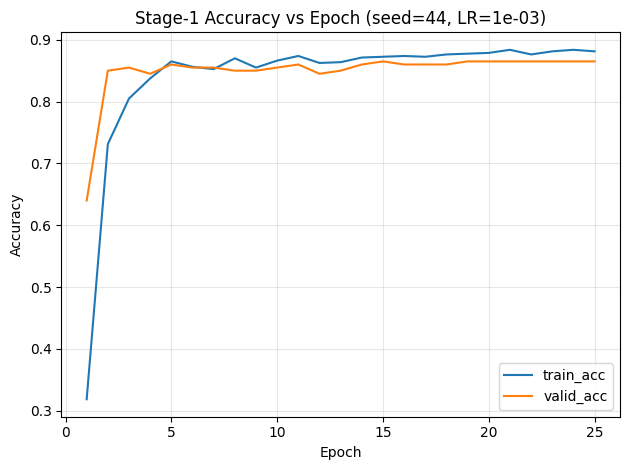

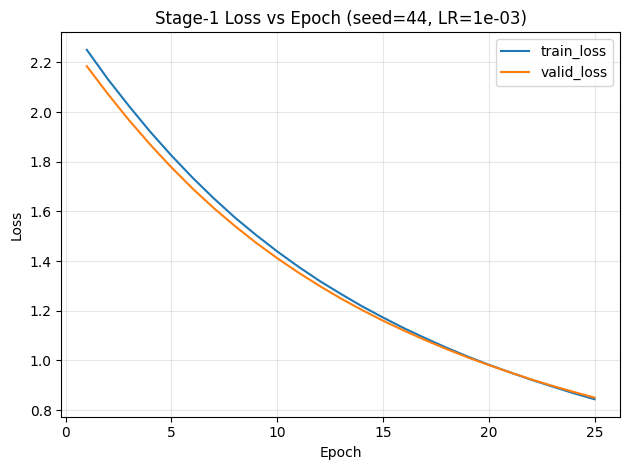


Seed 55 | Stage-1 (Color Linear Probe)
====== Training Linear Probe (seed=55, lr=1e-03) ======


Epoch 01/150 | train_loss=2.2481 valid_loss=2.1880 | train_acc=0.3337 valid_acc=0.7400


Epoch 02/150 | train_loss=2.1280 valid_loss=2.0822 | train_acc=0.7550 valid_acc=0.8200


Epoch 03/150 | train_loss=2.0176 valid_loss=1.9827 | train_acc=0.8325 valid_acc=0.8250


Epoch 04/150 | train_loss=1.9136 valid_loss=1.8887 | train_acc=0.8475 valid_acc=0.8200


...

Epoch 29/150 | train_loss=0.7375 valid_loss=0.8235 | train_acc=0.8838 valid_acc=0.8700


Epoch 30/150 | train_loss=0.7185 valid_loss=0.8065 | train_acc=0.8925 valid_acc=0.8700


Epoch 31/150 | train_loss=0.7003 valid_loss=0.7903 | train_acc=0.8925 valid_acc=0.8650


Epoch 32/150 | train_loss=0.6839 valid_loss=0.7748 | train_acc=0.8888 valid_acc=0.8700


Epoch 33/150 | train_loss=0.6678 valid_loss=0.7612 | train_acc=0.8962 valid_acc=0.8700
[EarlyStopping] no improvement in 10 epochs on acc. Stopping at epoch 33.
Saved tuned visual backbone to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_55/best_backbone/clip_visual_color_tuned_seed_55.pt
Saved color best head to: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_55/best_head/color_head_seed_55.pt


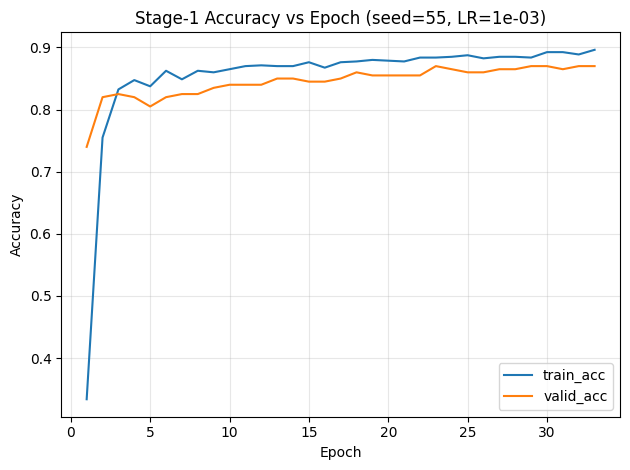

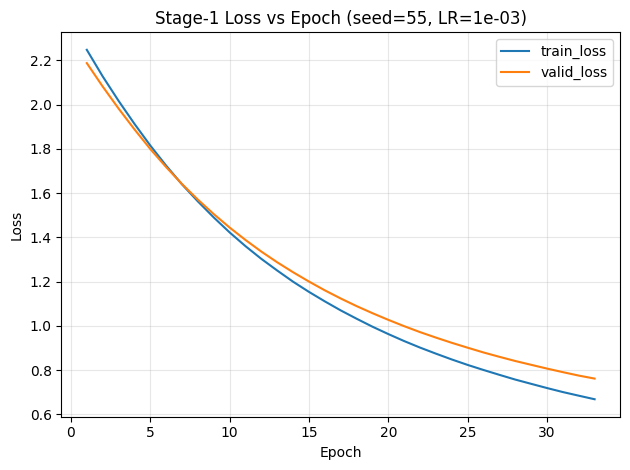


Stage-1 finished for all seeds.


In [ ]:
# ============================================================
# Stage 1: Color linear probe + learning curves + early stopping, for 5 seeds
# ============================================================

import math

def stratified_split(df, label_col="color", valid_ratio=0.2, seed=42):
    rng = np.random.RandomState(seed)
    train_parts, valid_parts = [], []
    for lab, grp in df.groupby(label_col):
        idx = np.arange(len(grp))
        rng.shuffle(idx)
        v = int(round(len(idx) * valid_ratio))
        valid_idx, train_idx = idx[:v], idx[v:]
        g = grp.reset_index(drop=True)
        valid_parts.append(g.loc[valid_idx])
        train_parts.append(g.loc[train_idx])
    return pd.concat(train_parts, ignore_index=True), pd.concat(valid_parts, ignore_index=True)

stage1_paths = {}

for seed in SEEDS:
    print("\n===============================")
    print(f"Seed {seed} | Stage-1 (Color Linear Probe)")
    print("===============================")

    set_all_seeds(seed)

    # Per-seed output folders
    seed_root = OUT_ROOT / f"seed_{seed}"
    (seed_root / "best_backbone").mkdir(parents=True, exist_ok=True)
    (seed_root / "best_head").mkdir(parents=True, exist_ok=True)
    (seed_root / "tables").mkdir(parents=True, exist_ok=True)

    FT_BACKBONE_PATH = str(seed_root / "best_backbone" / f"clip_visual_color_tuned_seed_{seed}.pt")
    COLOR_HEAD_PATH  = str(seed_root / "best_head" / f"color_head_seed_{seed}.pt")

    # Load CLIP for stage-1 (same as notebook)
    model_ft, preprocess_ft = clip.load("ViT-B/32", device=device)

    # Unfreeze scope (same as notebook, but stage-1 uses @torch.no_grad() encoder => head-only)
    if UNFREEZE_SCOPE == "visual":
        for p in model_ft.visual.parameters():
            p.requires_grad = True
        for p in model_ft.transformer.parameters():
            p.requires_grad = False
        for p in model_ft.token_embedding.parameters():
            p.requires_grad = False
        for p in model_ft.ln_final.parameters():
            p.requires_grad = False
    else:
        for p in model_ft.parameters():
            p.requires_grad = True

    model_ft.float()

    # Build dataset/loaders
    class ColorFTSet(torch.utils.data.Dataset):
        def __init__(self, frame: pd.DataFrame):
            self.f = frame.reset_index(drop=True)
            self.colors = sorted(self.f["color"].unique().tolist())
            self.c2i = {c: i for i, c in enumerate(self.colors)}
        def __len__(self):
            return len(self.f)
        def __getitem__(self, i):
            r = self.f.iloc[i]
            img = preprocess_ft(Image.open(r["path"]).convert("RGB"))
            y = self.c2i[r["color"]]
            return img, y

    # Stratified split (per seed)
    color_train, color_valid = stratified_split(color_index, valid_ratio=COLOR_VALID_RATIO, seed=seed)
    train_ds = ColorFTSet(color_train)
    valid_ds = ColorFTSet(color_valid)
    assert train_ds.colors == valid_ds.colors, "Train/valid must share same color label set."

    COLOR_CLASSES = len(train_ds.colors)
    feat_dim = model_ft.visual.output_dim
    color_head = nn.Linear(feat_dim, COLOR_CLASSES).to(device).float()

    train_loader_c = torch.utils.data.DataLoader(
        train_ds, batch_size=COLOR_BATCH_SIZE, shuffle=True,
        num_workers=2 if device == "cuda" else 0,
        pin_memory=(device == "cuda")
    )
    valid_loader_c = torch.utils.data.DataLoader(
        valid_ds, batch_size=COLOR_BATCH_SIZE, shuffle=False,
        num_workers=2 if device == "cuda" else 0,
        pin_memory=(device == "cuda")
    )

    # Loss/optim
    ce_color = nn.CrossEntropyLoss(label_smoothing=COLOR_LABEL_SMOOTHING)
    params = list(color_head.parameters()) + [p for p in model_ft.parameters() if p.requires_grad]
    opt_c = optim.AdamW(params, lr=COLOR_LR, weight_decay=COLOR_WD)

    EPS = 1e-6

    @torch.no_grad()
    def encode_images_ft(imgs):
        f = model_ft.encode_image(imgs.to(device)).float()
        denom = f.norm(dim=-1, keepdim=True).clamp(min=EPS)
        return (f / denom)

    # Train loop (kept notebook prints)
    tr_losses_c, va_losses_c = [], []
    tr_accs_c,   va_accs_c   = [], []
    best_va = -1.0
    best_state = None

    no_improve_count = 0
    if ES_MONITOR == "loss":
        best_monitor_value = float("inf")
    else:
        best_monitor_value = -float("inf")

    print(f"====== Training Linear Probe (seed={seed}, lr={COLOR_LR:.0e}) ======")
    for epoch in range(1, COLOR_EPOCHS + 1):
        # train
        model_ft.train(); color_head.train()
        total_loss, seen, correct = 0.0, 0, 0

        for imgs, y in tqdm(train_loader_c, desc=f"epoch {epoch} train", leave=False):
            feats = encode_images_ft(imgs)
            logits = color_head(feats)
            loss = ce_color(logits, y.to(device).long())

            opt_c.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
            opt_c.step()

            total_loss += float(loss.item())
            pred = logits.argmax(dim=-1).detach().cpu().numpy()
            correct += int((pred == np.array(y)).sum())
            seen += int(len(y))

        tr_losses_c.append(total_loss / max(1, len(train_loader_c)))
        tr_accs_c.append(correct / max(1, seen))

        # valid
        model_ft.eval(); color_head.eval()
        total_loss, seen, correct = 0.0, 0, 0
        with torch.no_grad():
            for imgs, y in tqdm(valid_loader_c, desc=f"epoch {epoch} valid", leave=False):
                feats = encode_images_ft(imgs)
                logits = color_head(feats)
                loss = ce_color(logits, y.to(device).long())
                total_loss += float(loss.item())
                pred = logits.argmax(dim=-1).cpu().numpy()
                correct += int((pred == np.array(y)).sum())
                seen += int(len(y))

        va_losses_c.append(total_loss / max(1, len(valid_loader_c)))
        va_accs_c.append(correct / max(1, seen))

        if va_accs_c[-1] > best_va:
            best_va = va_accs_c[-1]
            best_state = {
                "visual": {k: v.detach().cpu() for k, v in model_ft.visual.state_dict().items()},
                "color_head": {k: v.detach().cpu() for k, v in color_head.state_dict().items()},
                "colors": train_ds.colors
            }

        print(
            f"Epoch {epoch:02d}/{COLOR_EPOCHS} | "
            f"train_loss={tr_losses_c[-1]:.4f} valid_loss={va_losses_c[-1]:.4f} | "
            f"train_acc={tr_accs_c[-1]:.4f} valid_acc={va_accs_c[-1]:.4f}"
        )

        # Early stopping (same logic)
        if ES_MONITOR == "loss":
            current = va_losses_c[-1]
            improved = (best_monitor_value - current) > ES_MIN_DELTA
        else:
            current = va_accs_c[-1]
            improved = (current - best_monitor_value) > ES_MIN_DELTA

        if improved:
            best_monitor_value = current
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= ES_PATIENCE:
            print(f"[EarlyStopping] no improvement in {ES_PATIENCE} epochs on {ES_MONITOR}. Stopping at epoch {epoch}.")
            break

    # Save tuned backbone and color head
    if best_state is None:
        raise RuntimeError(f"[Seed {seed}] No valid best state captured for stage-1.")

    torch.save(best_state, FT_BACKBONE_PATH)
    torch.save({"state_dict": best_state["color_head"], "colors": best_state["colors"]}, COLOR_HEAD_PATH)
    print("Saved tuned visual backbone to:", FT_BACKBONE_PATH)
    print("Saved color best head to:", COLOR_HEAD_PATH)

    # Learning curves (save + show)
    epochs_axis = list(range(1, len(tr_losses_c) + 1))

    plt.figure()
    plt.plot(epochs_axis, tr_accs_c, label="train_acc")
    plt.plot(epochs_axis, va_accs_c, label="valid_acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title(f"Stage-1 Accuracy vs Epoch (seed={seed}, LR={COLOR_LR:.0e})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(epochs_axis, tr_losses_c, label="train_loss")
    plt.plot(epochs_axis, va_losses_c, label="valid_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"Stage-1 Loss vs Epoch (seed={seed}, LR={COLOR_LR:.0e})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.show()

    # Save curves to Drive
    curve_dir = seed_root / "tables"
    acc_png = curve_dir / f"stage1_curve_acc_seed_{seed}.png"
    loss_png = curve_dir / f"stage1_curve_loss_seed_{seed}.png"

    plt.figure()
    plt.plot(epochs_axis, tr_accs_c, label="train_acc")
    plt.plot(epochs_axis, va_accs_c, label="valid_acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title(f"Stage-1 Accuracy vs Epoch (seed={seed}, LR={COLOR_LR:.0e})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(acc_png, dpi=200)
    plt.close()

    plt.figure()
    plt.plot(epochs_axis, tr_losses_c, label="train_loss")
    plt.plot(epochs_axis, va_losses_c, label="valid_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"Stage-1 Loss vs Epoch (seed={seed}, LR={COLOR_LR:.0e})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(loss_png, dpi=200)
    plt.close()

    stage1_paths[seed] = {
        "FT_BACKBONE_PATH": FT_BACKBONE_PATH,
        "COLOR_HEAD_PATH": COLOR_HEAD_PATH
    }

print("\nStage-1 finished for all seeds.")


Seed 11 | Stage-2 (5-head Linear Probe)
[Stage-2] load tuned visual: missing= 0 unexpected= 0
====== Training Linear Probe (seed=11, lr=5e-05) ======
Epoch 01/100 | train_loss=7.8634 valid_loss=6.9306 | train_acc=0.4392 valid_acc=0.5019
Epoch 02/100 | train_loss=6.3084 valid_loss=5.7718 | train_acc=0.5273 valid_acc=0.5456
Epoch 03/100 | train_loss=5.4019 valid_loss=5.0648 | train_acc=0.5548 valid_acc=0.5595
Epoch 04/100 | train_loss=4.8254 valid_loss=4.5946 | train_acc=0.5644 valid_acc=0.5640
Epoch 05/100 | train_loss=4.4263 valid_loss=4.2554 | train_acc=0.5683 valid_acc=0.5667
Epoch 06/100 | train_loss=4.1274 valid_loss=3.9926 | train_acc=0.5748 valid_acc=0.5796
Epoch 07/100 | train_loss=3.8893 valid_loss=3.7786 | train_acc=0.5897 valid_acc=0.5931
Epoch 08/100 | train_loss=3.6921 valid_loss=3.5984 | train_acc=0.6056 valid_acc=0.6068
Epoch 09/100 | train_loss=3.5243 valid_loss=3.4439 | train_acc=0.6210 valid_acc=0.6199
Epoch 10/100 | train_loss=3.3785 valid_loss=3.3088 | train_acc=0.6

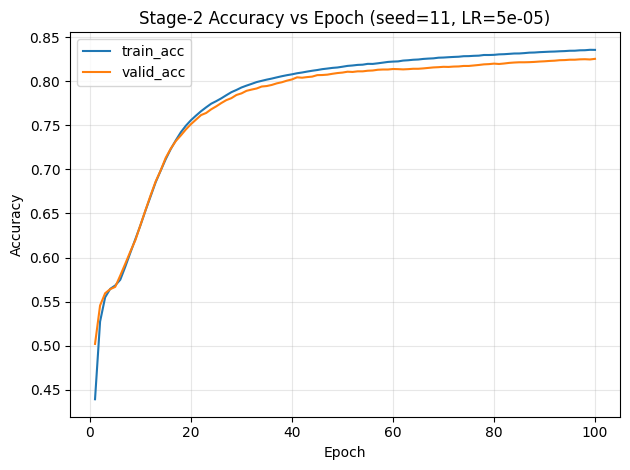

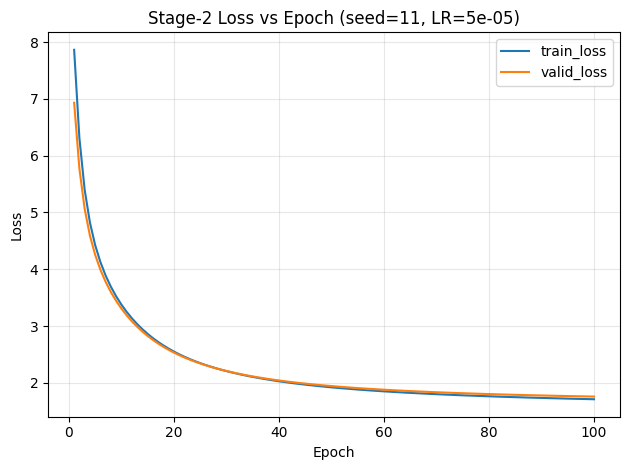


Seed 22 | Stage-2 (5-head Linear Probe)
[Stage-2] load tuned visual: missing= 0 unexpected= 0
====== Training Linear Probe (seed=22, lr=5e-05) ======
Epoch 01/100 | train_loss=7.8598 valid_loss=6.9433 | train_acc=0.3948 valid_acc=0.5003
Epoch 02/100 | train_loss=6.3031 valid_loss=5.7933 | train_acc=0.5314 valid_acc=0.5411
Epoch 03/100 | train_loss=5.3959 valid_loss=5.0910 | train_acc=0.5557 valid_acc=0.5536
Epoch 04/100 | train_loss=4.8203 valid_loss=4.6234 | train_acc=0.5644 valid_acc=0.5599
Epoch 05/100 | train_loss=4.4218 valid_loss=4.2845 | train_acc=0.5687 valid_acc=0.5632
Epoch 06/100 | train_loss=4.1234 valid_loss=4.0208 | train_acc=0.5741 valid_acc=0.5729
Epoch 07/100 | train_loss=3.8858 valid_loss=3.8048 | train_acc=0.5884 valid_acc=0.5877
Epoch 08/100 | train_loss=3.6882 valid_loss=3.6227 | train_acc=0.6045 valid_acc=0.6041
Epoch 09/100 | train_loss=3.5201 valid_loss=3.4659 | train_acc=0.6196 valid_acc=0.6189
Epoch 10/100 | train_loss=3.3747 valid_loss=3.3288 | train_acc=0.6

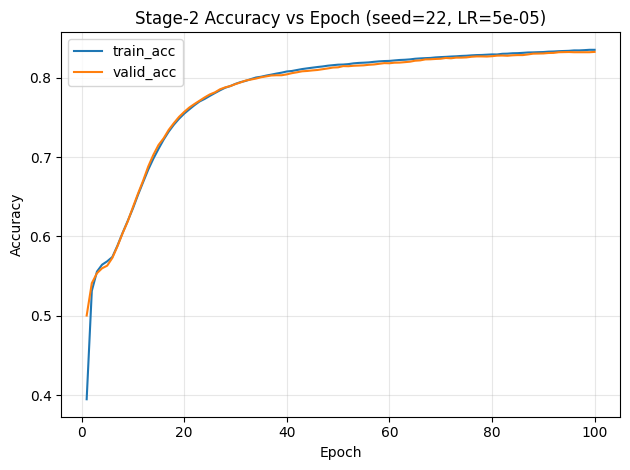

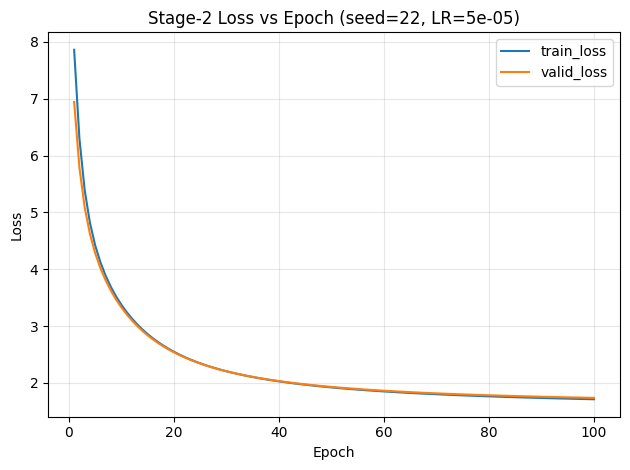


Seed 33 | Stage-2 (5-head Linear Probe)
[Stage-2] load tuned visual: missing= 0 unexpected= 0
====== Training Linear Probe (seed=33, lr=5e-05) ======
Epoch 01/100 | train_loss=7.8423 valid_loss=6.9195 | train_acc=0.4223 valid_acc=0.5150
Epoch 02/100 | train_loss=6.3008 valid_loss=5.7712 | train_acc=0.5378 valid_acc=0.5474
Epoch 03/100 | train_loss=5.3991 valid_loss=5.0706 | train_acc=0.5584 valid_acc=0.5581
Epoch 04/100 | train_loss=4.8247 valid_loss=4.6048 | train_acc=0.5660 valid_acc=0.5615
Epoch 05/100 | train_loss=4.4271 valid_loss=4.2686 | train_acc=0.5693 valid_acc=0.5638
Epoch 06/100 | train_loss=4.1296 valid_loss=4.0078 | train_acc=0.5734 valid_acc=0.5717
Epoch 07/100 | train_loss=3.8922 valid_loss=3.7949 | train_acc=0.5861 valid_acc=0.5891
Epoch 08/100 | train_loss=3.6955 valid_loss=3.6156 | train_acc=0.6021 valid_acc=0.6068
Epoch 09/100 | train_loss=3.5280 valid_loss=3.4613 | train_acc=0.6176 valid_acc=0.6235
Epoch 10/100 | train_loss=3.3823 valid_loss=3.3268 | train_acc=0.6

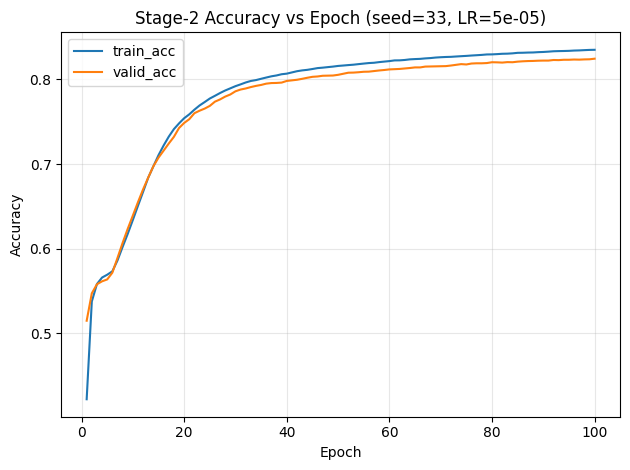

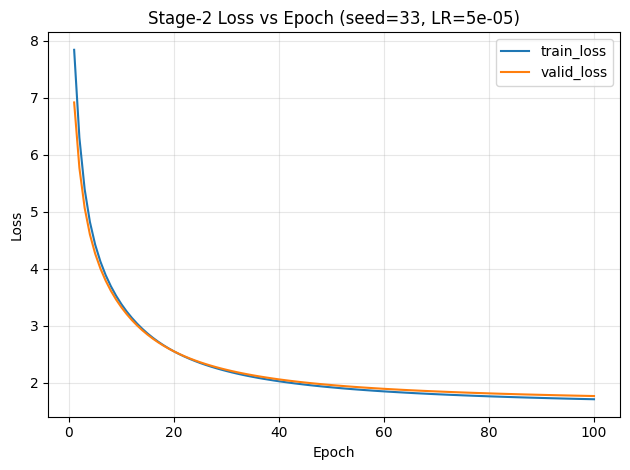


Seed 44 | Stage-2 (5-head Linear Probe)
[Stage-2] load tuned visual: missing= 0 unexpected= 0
====== Training Linear Probe (seed=44, lr=5e-05) ======
Epoch 01/100 | train_loss=7.8455 valid_loss=6.9175 | train_acc=0.3938 valid_acc=0.5054
Epoch 02/100 | train_loss=6.2986 valid_loss=5.7672 | train_acc=0.5323 valid_acc=0.5483
Epoch 03/100 | train_loss=5.3964 valid_loss=5.0656 | train_acc=0.5575 valid_acc=0.5604
Epoch 04/100 | train_loss=4.8228 valid_loss=4.6014 | train_acc=0.5656 valid_acc=0.5657
Epoch 05/100 | train_loss=4.4253 valid_loss=4.2655 | train_acc=0.5693 valid_acc=0.5678
Epoch 06/100 | train_loss=4.1269 valid_loss=4.0046 | train_acc=0.5736 valid_acc=0.5782
Epoch 07/100 | train_loss=3.8893 valid_loss=3.7921 | train_acc=0.5871 valid_acc=0.5952
Epoch 08/100 | train_loss=3.6918 valid_loss=3.6130 | train_acc=0.6026 valid_acc=0.6103
Epoch 09/100 | train_loss=3.5237 valid_loss=3.4591 | train_acc=0.6173 valid_acc=0.6267
Epoch 10/100 | train_loss=3.3783 valid_loss=3.3247 | train_acc=0.6

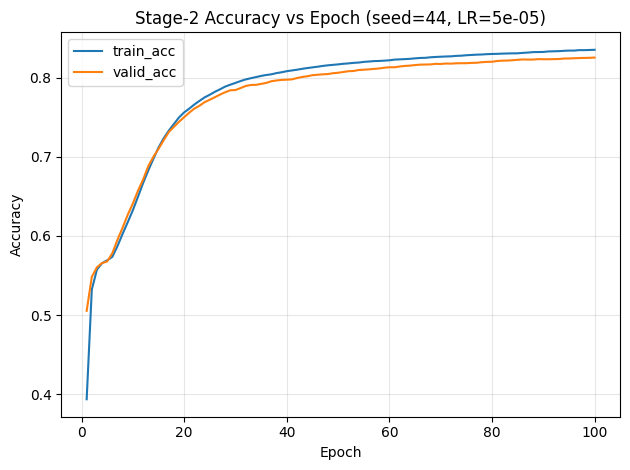

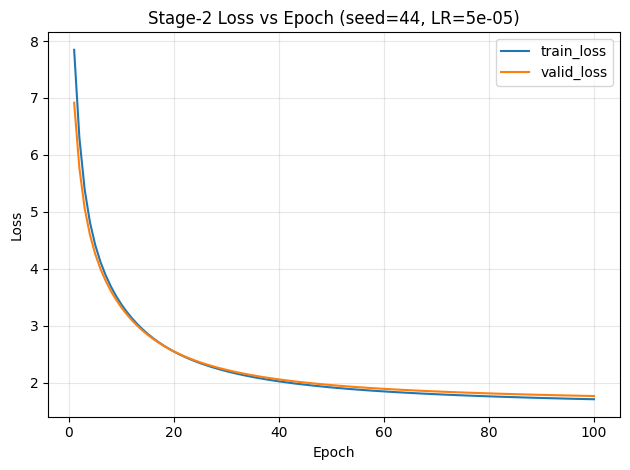


Seed 55 | Stage-2 (5-head Linear Probe)
[Stage-2] load tuned visual: missing= 0 unexpected= 0
====== Training Linear Probe (seed=55, lr=5e-05) ======
Epoch 01/100 | train_loss=7.8311 valid_loss=6.9043 | train_acc=0.3920 valid_acc=0.5188
Epoch 02/100 | train_loss=6.2893 valid_loss=5.7528 | train_acc=0.5356 valid_acc=0.5590
Epoch 03/100 | train_loss=5.3905 valid_loss=5.0493 | train_acc=0.5594 valid_acc=0.5667
Epoch 04/100 | train_loss=4.8195 valid_loss=4.5811 | train_acc=0.5651 valid_acc=0.5703
Epoch 05/100 | train_loss=4.4230 valid_loss=4.2423 | train_acc=0.5682 valid_acc=0.5729
Epoch 06/100 | train_loss=4.1257 valid_loss=3.9796 | train_acc=0.5738 valid_acc=0.5828
Epoch 07/100 | train_loss=3.8887 valid_loss=3.7654 | train_acc=0.5887 valid_acc=0.5967
Epoch 08/100 | train_loss=3.6922 valid_loss=3.5851 | train_acc=0.6047 valid_acc=0.6120
Epoch 09/100 | train_loss=3.5243 valid_loss=3.4303 | train_acc=0.6195 valid_acc=0.6288
Epoch 10/100 | train_loss=3.3789 valid_loss=3.2953 | train_acc=0.6

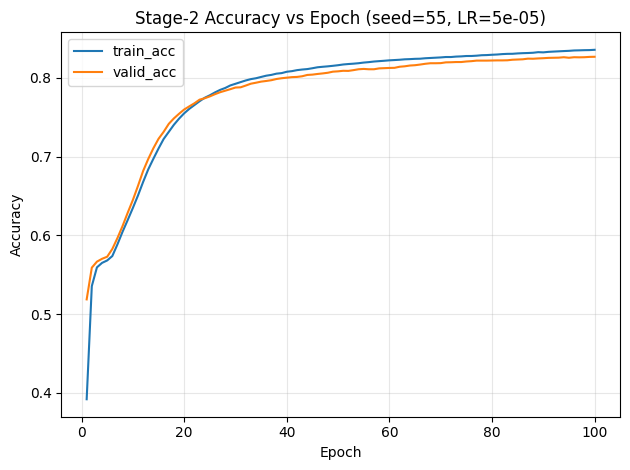

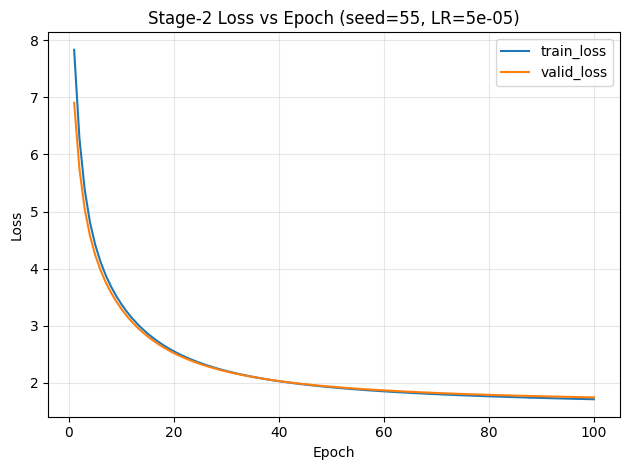


Stage-2 finished for all seeds.


In [ ]:
# ============================================================
# Stage 2: 5-attribute linear probe using Stage-1 pt + learning curves, for 5 seeds
# ============================================================

stage2_paths = {}

for seed in SEEDS:
    print("\n===============================")
    print(f"Seed {seed} | Stage-2 (5-head Linear Probe)")
    print("===============================")

    set_all_seeds(seed)

    seed_root = OUT_ROOT / f"seed_{seed}"
    (seed_root / "best_head").mkdir(parents=True, exist_ok=True)
    (seed_root / "tables").mkdir(parents=True, exist_ok=True)

    FT_BACKBONE_PATH = stage1_paths[seed]["FT_BACKBONE_PATH"]
    LP_HEADS_PATH = str(seed_root / "best_head" / f"linear_probe_best_heads_seed_{seed}.pt")

    # Reload CLIP and inject tuned visual weights
    model_lp, preprocess_lp = clip.load("ViT-B/32", device=device)
    ckpt_ft = torch.load(FT_BACKBONE_PATH, map_location="cpu")
    missing, unexpected = model_lp.visual.load_state_dict(ckpt_ft["visual"], strict=False)
    print("[Stage-2] load tuned visual:", "missing=", len(missing), "unexpected=", len(unexpected))

    # Freeze backbone
    for p in model_lp.parameters():
        p.requires_grad = False
    model_lp.eval()
    feat_dim = model_lp.visual.output_dim

    @torch.no_grad()
    def encode_images_lp(imgs):
        f = model_lp.encode_image(imgs.to(device)).float()
        denom = f.norm(dim=-1, keepdim=True).clamp(min=1e-6)
        return (f / denom)

    # Datasets/loaders for stage-2
    class FashionSet(torch.utils.data.Dataset):
        def __init__(self, frame):
            self.f = frame.reset_index(drop=True)
        def __len__(self):
            return len(self.f)
        def __getitem__(self, i):
            r = self.f.iloc[i]
            img = preprocess_lp(Image.open(r["path"]).convert("RGB"))

            y_single = {}
            for a in single_attrs:
                y = r.get(a)
                if pd.isna(y) or str(y).strip() == "":
                    y_single[a] = -1
                else:
                    y_single[a] = label2idx_single[a][str(y).strip().lower()]

            y_multi = {}
            for a in multi_attrs:
                labs = parse_list_cell(r.get(a))
                vec = torch.zeros(len(label_lib[a]), dtype=torch.float32)
                for lab in labs:
                    j = label2idx_multi[a].get(lab)
                    if j is not None:
                        vec[j] = 1.0
                if len(labs) == 0 and (pd.isna(r.get(a)) or str(r.get(a)).strip() in ("", "[]")):
                    vec = torch.full_like(vec, -1.0)
                y_multi[a] = vec

            return img, y_single, y_multi

    def make_loader(df, shuffle):
        ds = FashionSet(df)
        return torch.utils.data.DataLoader(
            ds,
            batch_size=BATCH_SIZE,
            shuffle=shuffle,
            num_workers=2 if device == "cuda" else 0,
            pin_memory=(device == "cuda"),
            drop_last=False
        )

    train_df = seed_data[seed]["train_df"]
    valid_df = seed_data[seed]["valid_df"]

    train_loader = make_loader(train_df, True)
    valid_loader = make_loader(valid_df, False)

    def make_heads():
        return nn.ModuleDict({
            "single": nn.ModuleDict({a: nn.Linear(feat_dim, len(label_lib[a])) for a in single_attrs}),
            "multi" : nn.ModuleDict({a: nn.Linear(feat_dim, len(label_lib[a])) for a in multi_attrs})
        }).to(device)

    ce  = nn.CrossEntropyLoss(ignore_index=-1, label_smoothing=0.05)
    bce = nn.BCEWithLogitsLoss(reduction="none")

    def train_or_eval_epoch(heads, loader, optimizer=None):
        train_mode = optimizer is not None
        heads.train() if train_mode else heads.eval()

        total_loss = 0.0
        correct = {a: 0 for a in single_attrs}
        count   = {a: 0 for a in single_attrs}

        for imgs, y_s, y_m in loader:
            feats = encode_images_lp(imgs)
            loss = 0.0

            # single-label
            for a in single_attrs:
                logits = heads["single"][a](feats)
                y = y_s[a].to(device).long()
                loss += ce(logits, y)

                with torch.no_grad():
                    pred = logits.argmax(dim=-1)
                    m = (y != -1)
                    correct[a] += int((pred[m] == y[m]).sum())
                    count[a]   += int(m.sum())

            # multi-label
            for a in multi_attrs:
                logits = heads["multi"][a](feats)
                y = y_m[a].to(device)
                mask = (y != -1.0).float()
                l = bce(logits, torch.clamp(y, 0, 1))
                l = (l * mask).sum() / torch.clamp(mask.sum(), min=1.0)
                loss += l

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(heads.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += float(loss.item())

        mean_loss = total_loss / max(1, len(loader))
        accs = {a: (correct[a] / count[a] if count[a] > 0 else np.nan) for a in single_attrs}
        mean_acc = float(np.nanmean(list(accs.values())))
        return mean_loss, mean_acc

    # Train (same print style as your example)
    heads = make_heads()
    opt = optim.AdamW(heads.parameters(), lr=LEARNING_RATE, weight_decay=0.02)

    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []
    best_valid = -1.0
    best_state = None

    print(f"====== Training Linear Probe (seed={seed}, lr={LEARNING_RATE:.0e}) ======")
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_or_eval_epoch(heads, train_loader, optimizer=opt)
        va_loss, va_acc = train_or_eval_epoch(heads, valid_loader, optimizer=None)

        train_losses.append(tr_loss); valid_losses.append(va_loss)
        train_accs.append(tr_acc);     valid_accs.append(va_acc)

        if va_acc > best_valid:
            best_valid = va_acc
            best_state = {k: v.detach().cpu() for k, v in heads.state_dict().items()}

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | train_loss={tr_loss:.4f} valid_loss={va_loss:.4f} | "
            f"train_acc={tr_acc:.4f} valid_acc={va_acc:.4f}"
        )

    if best_state is None:
        raise RuntimeError(f"[Seed {seed}] best_state is None in stage-2.")

    # Save best heads
    torch.save({
        "state_dict": best_state,
        "best_lr": LEARNING_RATE,
        "best_valid_acc": best_valid,
        "single_attrs": single_attrs,
        "multi_attrs": multi_attrs,
        "label_lib": label_lib,
        "backbone_ckpt": FT_BACKBONE_PATH,
    }, LP_HEADS_PATH)
    print("Saved linear probe best heads to:", LP_HEADS_PATH)

    # Learning curves (show)
    epochs_axis = list(range(1, len(train_losses) + 1))

    plt.figure()
    plt.plot(epochs_axis, train_accs, label="train_acc")
    plt.plot(epochs_axis, valid_accs, label="valid_acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title(f"Stage-2 Accuracy vs Epoch (seed={seed}, LR={LEARNING_RATE:.0e})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(epochs_axis, train_losses, label="train_loss")
    plt.plot(epochs_axis, valid_losses, label="valid_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"Stage-2 Loss vs Epoch (seed={seed}, LR={LEARNING_RATE:.0e})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.show()

    # Save curves
    curve_dir = seed_root / "tables"
    acc_png = curve_dir / f"stage2_curve_acc_seed_{seed}.png"
    loss_png = curve_dir / f"stage2_curve_loss_seed_{seed}.png"

    plt.figure()
    plt.plot(epochs_axis, train_accs, label="train_acc")
    plt.plot(epochs_axis, valid_accs, label="valid_acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title(f"Stage-2 Accuracy vs Epoch (seed={seed}, LR={LEARNING_RATE:.0e})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(acc_png, dpi=200)
    plt.close()

    plt.figure()
    plt.plot(epochs_axis, train_losses, label="train_loss")
    plt.plot(epochs_axis, valid_losses, label="valid_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"Stage-2 Loss vs Epoch (seed={seed}, LR={LEARNING_RATE:.0e})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(loss_png, dpi=200)
    plt.close()

    stage2_paths[seed] = {"LP_HEADS_PATH": LP_HEADS_PATH}

print("\nStage-2 finished for all seeds.")

### Inference + Evaluation

In [ ]:
# ============================================================
# Inference + Evaluation
# ============================================================

import json

# Pragmatic defaults
thr_map   = {"color": 0.30, "material": 0.30, "pattern": 0.50}
max_k_map = {"color": 3, "material": 3, "pattern": 2}

def probs_to_labels(attr, probs, thr_map, max_k_map):
    thr = thr_map[attr]; max_k = max_k_map[attr]
    idxs = np.where(probs >= thr)[0].tolist()
    idxs = sorted(idxs, key=lambda j: float(probs[j]), reverse=True)[:max_k]
    if not idxs:
        idxs = [int(np.argmax(probs))]
    return [multi_keys[attr][j] for j in idxs]

def is_missing(x):
    if pd.isna(x):
        return True
    if isinstance(x, str) and x.strip() == "":
        return True
    return False

def mean_std(xs):
    xs = [x for x in xs if x is not None and not (isinstance(x, float) and np.isnan(x))]
    mu = float(np.mean(xs)) if xs else float("nan")
    sd = float(np.std(xs, ddof=1)) if len(xs) > 1 else 0.0
    return mu, sd

def relaxed_match(a, b):
    return 1.0 if (set(a) & set(b)) else 0.0

all_reports = {}
pred_paths = {}

for seed in SEEDS:
    print("\n===============================")
    print(f"Seed {seed} | Inference + Evaluation")
    print("===============================")

    seed_root = OUT_ROOT / f"seed_{seed}"
    (seed_root / "clip_results").mkdir(parents=True, exist_ok=True)
    (seed_root / "tables").mkdir(parents=True, exist_ok=True)

    FT_BACKBONE_PATH = stage1_paths[seed]["FT_BACKBONE_PATH"]
    LP_HEADS_PATH = stage2_paths[seed]["LP_HEADS_PATH"]

    # Load backbone and inject tuned visual weights (same as notebook)
    model_inf, preprocess_inf = clip.load("ViT-B/32", device=device)
    ckpt_backbone = torch.load(FT_BACKBONE_PATH, map_location="cpu")
    _ = model_inf.visual.load_state_dict(ckpt_backbone["visual"], strict=False)
    for p in model_inf.parameters():
        p.requires_grad = False
    model_inf.eval()
    feat_dim = model_inf.visual.output_dim

    # Build heads + load best state
    def make_heads():
        return nn.ModuleDict({
            "single": nn.ModuleDict({a: nn.Linear(feat_dim, len(label_lib[a])) for a in single_attrs}),
            "multi" : nn.ModuleDict({a: nn.Linear(feat_dim, len(label_lib[a])) for a in multi_attrs})
        }).to(device)

    ckpt_heads = torch.load(LP_HEADS_PATH, map_location="cpu")
    heads = make_heads()
    heads.load_state_dict(ckpt_heads["state_dict"])
    heads.to(device).eval()

    @torch.no_grad()
    def encode_images(imgs):
        f = model_inf.encode_image(imgs.to(device)).float()
        denom = f.norm(dim=-1, keepdim=True).clamp(min=1e-6)
        return (f / denom)

    @torch.no_grad()
    def infer_single_batch(heads, feats):
        out_single, out_multi = {}, {}
        for a in single_attrs:
            logits = heads["single"][a](feats)
            out_single[a] = logits.argmax(dim=-1).cpu().numpy()
        for a in multi_attrs:
            logits = heads["multi"][a](feats)
            out_multi[a] = torch.sigmoid(logits).cpu().numpy()
        return out_single, out_multi

    # Inference DataLoader
    class InferSet(torch.utils.data.Dataset):
        def __init__(self, frame):
            self.f = frame.reset_index(drop=True)
        def __len__(self):
            return len(self.f)
        def __getitem__(self, i):
            r = self.f.iloc[i]
            img = preprocess_inf(Image.open(r["path"]).convert("RGB"))
            return img, str(r["image_id"])

    def make_infer_loader(df, batch_size=128):
        ds = InferSet(df)
        return torch.utils.data.DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=2 if device == "cuda" else 0,
            pin_memory=(device == "cuda"),
            drop_last=False
        )

    # Predict on test
    test_df = seed_data[seed]["test_df"].copy()
    loader = make_infer_loader(test_df, batch_size=128)

    rows = []
    for imgs, ids in tqdm(loader, desc=f"predict(seed={seed})"):
        feats = encode_images(imgs)
        s_out, m_out = infer_single_batch(heads, feats)
        bs = feats.shape[0]

        for i in range(bs):
            row = {"image_id": ids[i]}
            for a in single_attrs:
                row[a] = idx2label_single[a][int(s_out[a][i])]
            for a in multi_attrs:
                row[a] = str(probs_to_labels(a, m_out[a][i], thr_map, max_k_map))
            rows.append(row)

    pred_df = pd.DataFrame(rows, columns=["image_id"] + single_attrs + multi_attrs)
    pred_csv_path = seed_root / "clip_results" / f"linear_probe_seed_{seed}_pred.csv"
    pred_df.to_csv(pred_csv_path, index=False, encoding="utf-8-sig")
    pred_paths[seed] = str(pred_csv_path)

    # ---------------------------
    # Evaluation (match notebook metrics + add per-seed report dict)
    # ---------------------------
    @torch.no_grad()
    def embed_text_batch(texts):
        toks = clip.tokenize(texts).to(device)
        feats = model_inf.encode_text(toks).float()
        feats = feats / feats.norm(dim=-1, keepdim=True).clamp(min=1e-6)
        return feats

    _embed_cache = {}
    def get_text_embed(label):
        key = str(label).strip().lower()
        if key not in _embed_cache:
            _embed_cache[key] = embed_text_batch([key])
        return _embed_cache[key]

    def semantic_sim_single(gt_label, pred_label):
        a = get_text_embed(gt_label)
        b = get_text_embed(pred_label)
        return float((a @ b.T).item())

    def semantic_sim_multilabel(gt_labels, pred_labels):
        gt = [g for g in gt_labels if str(g).strip()]
        pr = [p for p in pred_labels if str(p).strip()]
        if len(gt) == 0:
            return np.nan
        if len(pr) == 0:
            return 0.0
        gt_feats = torch.cat([get_text_embed(g) for g in gt], dim=0)
        pr_feats = torch.cat([get_text_embed(p) for p in pr], dim=0)
        sims = gt_feats @ pr_feats.T
        return float(sims.max(dim=1).values.mean().item())

    # Prepare GT/Pred frames
    test_gt_eval = test_df[["image_id"] + single_attrs + multi_attrs].rename(
        columns={c: f"{c}_gt" for c in single_attrs + multi_attrs}
    )
    test_pr_eval = pred_df.rename(columns={c: f"{c}_pred" for c in single_attrs + multi_attrs})

    rep = {"single": {}, "multi": {}}

    # Single-label metrics
    for attr in single_attrs:
        gcol, pcol = f"{attr}_gt", f"{attr}_pred"
        mask = ~test_gt_eval[gcol].apply(is_missing)
        y_true = test_gt_eval.loc[mask, gcol].astype(str).str.strip().str.lower().tolist()
        y_pred = test_pr_eval.loc[mask, pcol].astype(str).str.strip().str.lower().tolist()

        acc = accuracy_score(y_true, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
        sems = [semantic_sim_single(t, p) for t, p in zip(y_true, y_pred)]
        sem  = float(np.mean(sems)) if len(sems) > 0 else float("nan")

        rep["single"][attr] = {
            "accuracy": float(acc),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "semantic_similarity_clip": float(sem)
        }

    # Multi-label metrics
    for attr in multi_attrs:
        gcol, pcol = f"{attr}_gt", f"{attr}_pred"
        gt_lists = test_gt_eval[gcol].apply(parse_list_cell)
        pr_lists = test_pr_eval[pcol].apply(parse_list_cell)

        mask = gt_lists.apply(lambda x: len(x) > 0)
        gtv = gt_lists[mask].tolist()
        prv = pr_lists[mask].tolist()

        relaxed = float(np.mean([relaxed_match(g, p) for g, p in zip(gtv, prv)])) if len(gtv) > 0 else float("nan")
        sems = [semantic_sim_multilabel(g, p) for g, p in zip(gtv, prv)] if len(gtv) > 0 else []
        sem  = float(np.mean(sems)) if len(sems) > 0 else float("nan")

        rep["multi"][attr] = {
            "relaxed_match_acc": float(relaxed),
            "semantic_similarity_clip": float(sem)
        }

    rep["overall_single_acc_mean"] = float(np.mean([rep["single"][a]["accuracy"] for a in single_attrs]))

    all_reports[seed] = rep

    # Print seed result block (your requested style)
    print(f"\n===== Seed {seed} Results (Linear Probe) =====")
    for a in single_attrs:
        m = rep["single"][a]
        print(f"{a}: acc={m['accuracy']:.4f}, prec={m['precision']:.4f}, rec={m['recall']:.4f}, f1={m['f1']:.4f}, sem_sim={m['semantic_similarity_clip']:.4f}")
    for a in multi_attrs:
        m = rep["multi"][a]
        print(f"{a}: relaxed={m['relaxed_match_acc']:.4f}, sem_sim={m['semantic_similarity_clip']:.4f}")
    print(f"Overall single-label acc (mean category/sub_category): {rep['overall_single_acc_mean']:.4f}")

    # Save per-seed eval json
    eval_path = seed_root / "tables" / f"linear_probe_seed_{seed}_eval.json"
    with eval_path.open("w", encoding="utf-8-sig") as f:
        json.dump(rep, f, ensure_ascii=False, indent=2)

    print("Saved predictions:", pred_csv_path)
    print("Saved seed eval:", eval_path)

# ---------------------------
# Summary (mean ± std over 5 seeds)
# ---------------------------
summary_rows = []

# Overall
vals = [all_reports[s]["overall_single_acc_mean"] for s in SEEDS]
mu, sd = mean_std(vals)
summary_rows.append({
    "Method": "LinearProbe",
    "Attribute Type": "Overall",
    "Attributes": "overall_single_acc_mean",
    "Accuracy": f"{mu:.3f} ± {sd:.3f}",
    "Precision": "-",
    "Recall": "-",
    "F1": "-",
    "Relaxed Match": "-",
    "Semantic Similarity": "-",
})

# Single-label
for a in single_attrs:
    vals_acc  = [all_reports[s]["single"][a]["accuracy"] for s in SEEDS]
    vals_prec = [all_reports[s]["single"][a]["precision"] for s in SEEDS]
    vals_rec  = [all_reports[s]["single"][a]["recall"] for s in SEEDS]
    vals_f1   = [all_reports[s]["single"][a]["f1"] for s in SEEDS]
    vals_sem  = [all_reports[s]["single"][a]["semantic_similarity_clip"] for s in SEEDS]

    mu, sd = mean_std(vals_acc);  acc_str  = f"{mu:.3f} ± {sd:.3f}"
    mu, sd = mean_std(vals_prec); prec_str = f"{mu:.3f} ± {sd:.3f}"
    mu, sd = mean_std(vals_rec);  rec_str  = f"{mu:.3f} ± {sd:.3f}"
    mu, sd = mean_std(vals_f1);   f1_str   = f"{mu:.3f} ± {sd:.3f}"
    mu, sd = mean_std(vals_sem);  sem_str  = f"{mu:.3f} ± {sd:.3f}"

    summary_rows.append({
        "Method": "LinearProbe",
        "Attribute Type": "Single-Label",
        "Attributes": a,
        "Accuracy": acc_str,
        "Precision": prec_str,
        "Recall": rec_str,
        "F1": f1_str,
        "Relaxed Match": "-",
        "Semantic Similarity": sem_str,
    })

# Multi-label
for a in multi_attrs:
    vals_rel = [all_reports[s]["multi"][a]["relaxed_match_acc"] for s in SEEDS]
    vals_sem = [all_reports[s]["multi"][a]["semantic_similarity_clip"] for s in SEEDS]
    mu, sd = mean_std(vals_rel); rel_str = f"{mu:.3f} ± {sd:.3f}"
    mu, sd = mean_std(vals_sem); sem_str = f"{mu:.3f} ± {sd:.3f}"

    summary_rows.append({
        "Method": "LinearProbe",
        "Attribute Type": "Multi-Label",
        "Attributes": a,
        "Accuracy": "-",
        "Precision": "-",
        "Recall": "-",
        "F1": "-",
        "Relaxed Match": rel_str,
        "Semantic Similarity": sem_str,
    })

df_summary = pd.DataFrame(summary_rows, columns=[
    "Method", "Attribute Type", "Attributes",
    "Accuracy", "Precision", "Recall", "F1",
    "Relaxed Match", "Semantic Similarity"
])

summary_path = OUT_ROOT / "tables" / "linear_probe_5seeds_summary_mean_std.csv"
df_summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("\n===== Linear Probe Summary (mean ± std over 5 seeds) =====")
print(df_summary.to_string(index=False))
print("Saved mean±std summary:", summary_path)

# Optional: save a single JSON with all seeds reports
all_json_path = OUT_ROOT / "tables" / "linear_probe_5seeds_all_reports.json"
with all_json_path.open("w", encoding="utf-8-sig") as f:
    json.dump(all_reports, f, ensure_ascii=False, indent=2)
print("Saved all-seeds report JSON:", all_json_path)


Seed 11 | Inference + Evaluation


predict(seed=11): 100%|██████████| 29/29 [00:06<00:00,  4.25it/s]



===== Seed 11 Results (Linear Probe) =====
category: acc=0.9353, prec=0.9047, rec=0.8897, f1=0.8966, sem_sim=0.9890
sub_category: acc=0.7241, prec=0.3999, rec=0.3398, f1=0.3512, sem_sim=0.9489
color: relaxed=0.4265, sem_sim=0.8629
material: relaxed=0.3909, sem_sim=0.8733
pattern: relaxed=0.2534, sem_sim=0.8464
Overall single-label acc (mean category/sub_category): 0.8297
Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_11/clip_results/linear_probe_seed_11_pred.csv
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_11/tables/linear_probe_seed_11_eval.json

Seed 22 | Inference + Evaluation


predict(seed=22): 100%|██████████| 29/29 [00:06<00:00,  4.23it/s]



===== Seed 22 Results (Linear Probe) =====
category: acc=0.9297, prec=0.9052, rec=0.8816, f1=0.8915, sem_sim=0.9880
sub_category: acc=0.7141, prec=0.3987, rec=0.3264, f1=0.3341, sem_sim=0.9463
color: relaxed=0.4257, sem_sim=0.8649
material: relaxed=0.3934, sem_sim=0.8727
pattern: relaxed=0.2476, sem_sim=0.8492
Overall single-label acc (mean category/sub_category): 0.8219
Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_22/clip_results/linear_probe_seed_22_pred.csv
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_22/tables/linear_probe_seed_22_eval.json

Seed 33 | Inference + Evaluation


...


===== Seed 33 Results (Linear Probe) =====
category: acc=0.9386, prec=0.9136, rec=0.8934, f1=0.9022, sem_sim=0.9895
sub_category: acc=0.7260, prec=0.4083, rec=0.3403, f1=0.3466, sem_sim=0.9497
color: relaxed=0.4507, sem_sim=0.8701
material: relaxed=0.3987, sem_sim=0.8727
pattern: relaxed=0.2462, sem_sim=0.8484
Overall single-label acc (mean category/sub_category): 0.8323
Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_33/clip_results/linear_probe_seed_33_pred.csv
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_33/tables/linear_probe_seed_33_eval.json

Seed 44 | Inference + Evaluation


predict(seed=44): 100%|██████████| 29/29 [00:06<00:00,  4.17it/s]



===== Seed 44 Results (Linear Probe) =====
category: acc=0.9372, prec=0.9168, rec=0.8915, f1=0.9027, sem_sim=0.9896
sub_category: acc=0.7219, prec=0.3987, rec=0.3406, f1=0.3441, sem_sim=0.9486
color: relaxed=0.4423, sem_sim=0.8691
material: relaxed=0.4129, sem_sim=0.8770
pattern: relaxed=0.2587, sem_sim=0.8501
Overall single-label acc (mean category/sub_category): 0.8295
Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_44/clip_results/linear_probe_seed_44_pred.csv
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_44/tables/linear_probe_seed_44_eval.json

Seed 55 | Inference + Evaluation


predict(seed=55): 100%|██████████| 29/29 [00:07<00:00,  4.10it/s]



===== Seed 55 Results (Linear Probe) =====
category: acc=0.9297, prec=0.8966, rec=0.8851, f1=0.8903, sem_sim=0.9882
sub_category: acc=0.7266, prec=0.4250, rec=0.3532, f1=0.3641, sem_sim=0.9495
color: relaxed=0.4362, sem_sim=0.8662
material: relaxed=0.3948, sem_sim=0.8719
pattern: relaxed=0.2390, sem_sim=0.8467
Overall single-label acc (mean category/sub_category): 0.8281
Saved predictions: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_55/clip_results/linear_probe_seed_55_pred.csv
Saved seed eval: /content/drive/MyDrive/Thesis_Data/0111/TwoStage_LP_results_colab/seed_55/tables/linear_probe_seed_55_eval.json

===== Linear Probe Summary (mean ± std over 5 seeds) =====
     Method Attribute Type              Attributes      Accuracy     Precision        Recall            F1 Relaxed Match Semantic Similarity
LinearProbe        Overall overall_single_acc_mean 0.828 ± 0.004             -             -             -             -                   -
LinearProbe   Sing